# Motor current and vibration dataset for various faults in an E-motor-driven centrifugal pump #
Welcome to this notebook. In this notebook a difficult problem is presented. Could you predict the failure mode of a motor with it's electrical and vibration data?<br>
Some help is given at the begin. ***At the end some assignments are given!***


For a description of the original data see: https://www.sciencedirect.com/science/article/pii/S235234092301017X?via%3Dihub

To download an excel with a more detailed overview of the data: https://github.com/bbozon/DataScience/blob/main/measurement%20overview.xlsx <br>
(click the download button at the right )

I've added a fourier transform of the original data (the data is translated to the frequency domain).
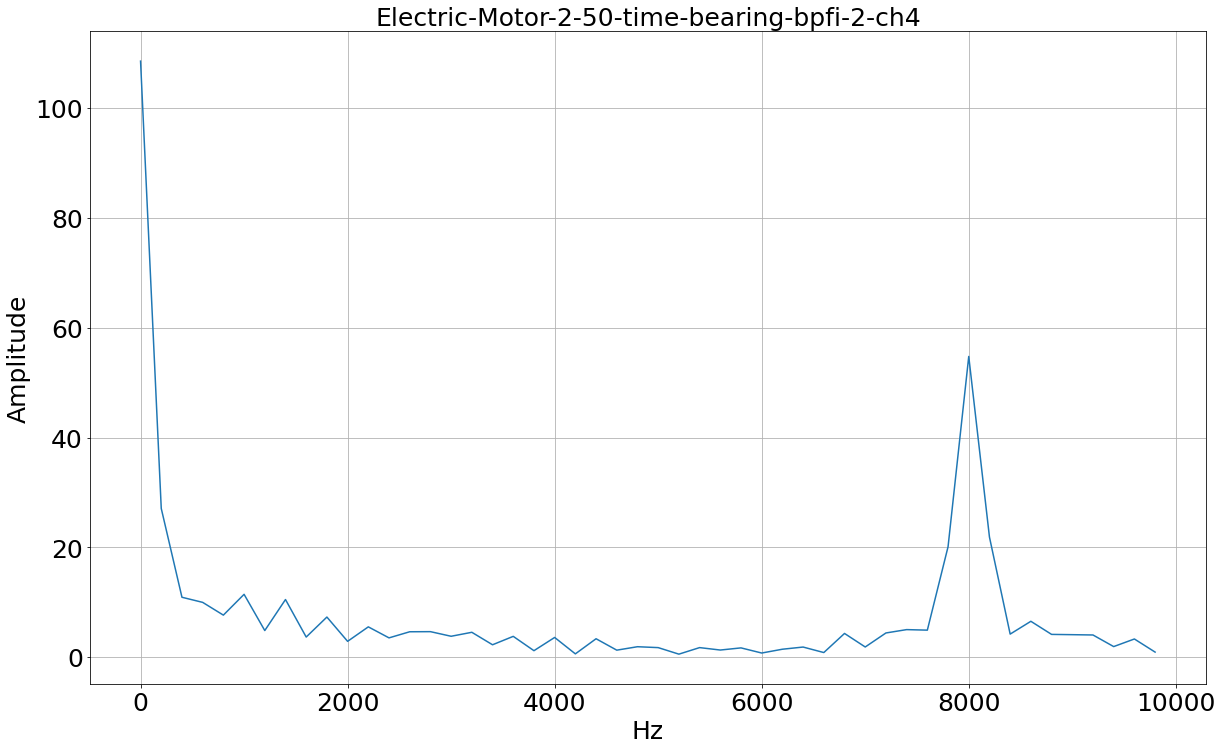

In the example below the frequency data is added as extra columns.

Written by Bart Bozon, please copy & use as you would like.

In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/bbozon/DataScience/refs/heads/main/motor_data_electrical_and_vibration_time_and_frequency.csv'
df = pd.read_csv(url)
# df.head(20)
df

,num,file_name,motor_type,measurement_type,percentage_rated_speed,failure_mode,channels,0.0 [s],5e-05 [s],0.0001 [s],...,8000.0 [Hz],8200.0 [Hz],8400.0 [Hz],8600.0 [Hz],8800.0 [Hz],9000.0 [Hz],9200.0 [Hz],9400.0 [Hz],9600.0 [Hz],9800.0 [Hz]
0,0,Electric-Motor-2-100-time-bearing-bpfi-1-ch1,2,Electric,100,bearing-bpfi-1,ch1,12.538880,11.504028,11.892352,...,0.460920,0.505890,0.491107,0.478344,0.464159,0.460195,0.455085,0.445983,0.442841,0.444571
1,1,Electric-Motor-2-100-time-bearing-bpfi-1-ch2,2,Electric,100,bearing-bpfi-1,ch2,13.997547,14.728688,14.463031,...,0.281560,0.178401,0.175755,0.158460,0.148352,0.140856,0.131986,0.131468,0.136013,0.136019
2,2,Electric-Motor-2-100-time-bearing-bpfi-1-ch3,2,Electric,100,bearing-bpfi-1,ch3,-25.848821,-25.387859,-25.563526,...,0.486832,0.399209,0.327249,0.328707,0.322791,0.323270,0.323412,0.317095,0.311970,0.311122
3,3,Electric-Motor-2-100-time-bearing-bpfi-1-ch4,2,Electric,100,bearing-bpfi-1,ch4,-126.612758,-54.756134,-44.005587,...,8.222805,12.140835,7.765923,5.993686,4.849380,5.181368,5.188414,4.162534,3.393596,3.880727
4,4,Electric-Motor-2-100-time-bearing-bpfi-1-ch5,2,Electric,100,bearing-bpfi-1,ch5,280.423727,297.966561,280.213054,...,7.933788,2.230050,3.447050,2.596825,2.126454,1.815192,1.717921,1.534892,1.157102,0.935014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7657,7657,Vibration-Motor-4-70-time-unbalance-pump-3-ch1,4,Vibration,70,unbalance-pump-3,ch1,0.431913,0.030839,0.331461,...,0.097905,0.086127,0.037719,0.082455,0.158598,0.113416,0.132084,0.233835,0.108244,0.111489
7658,7658,Vibration-Motor-4-70-time-unbalance-pump-3-ch2,4,Vibration,70,unbalance-pump-3,ch2,0.121140,-0.163805,-0.110310,...,0.033157,0.028357,0.039017,0.006492,0.041775,0.060323,0.103699,0.192294,0.322833,0.419497
7659,7659,Vibration-Motor-4-70-time-unbalance-pump-3-ch3,4,Vibration,70,unbalance-pump-3,ch3,0.379044,-0.513494,0.479150,...,0.015550,0.018630,0.070879,0.121620,0.029988,0.030370,0.065686,0.152170,0.254682,0.550237
7660,7660,Vibration-Motor-4-70-time-unbalance-pump-3-ch4,4,Vibration,70,unbalance-pump-3,ch4,-0.211090,-0.318730,-0.272679,...,0.048559,0.015695,0.018430,0.011283,0.008598,0.009770,0.021162,0.016608,0.015716,0.030339


In [2]:
df.columns

Index(['num', 'file_name', 'motor_type', 'measurement_type',
       'percentage_rated_speed', 'failure_mode', 'channels', '0.0 [s]',
       '5e-05 [s]', '0.0001 [s]',
       ...
       '8000.0 [Hz]', '8200.0 [Hz]', '8400.0 [Hz]', '8600.0 [Hz]',
       '8800.0 [Hz]', '9000.0 [Hz]', '9200.0 [Hz]', '9400.0 [Hz]',
       '9600.0 [Hz]', '9800.0 [Hz]'],
      dtype='object', length=157)

We'll try a simple model on a subset of the problem, we will look at motor 2 at 50% rated speed. We will use the vibration data of channel 3 as feature set.

This is just an attempt. I bet YOU can do better...

1) Investigate the data in more detail. <br>
2) Can you get better results with a different selection of your input? E.g. different motor, different type of data (vibration/electrical), different measurement point (ch1-ch2-ch3-...)?<br>
3a) Read: https://medium.com/analytics-vidhya/categorical-encoding-with-pandas-get-dummies-d6f1ae6a3e06 <br>
3b) Can you get better results with "get_dummies"? So combining more data?<br>
4) Can you get better results with the time data set? <br>
4) Can you get better results with other models?<br>

You do not have to do the items sequentially, better yet, you can combine them. Do keep note of all your different results! It'easy to loose track...  


Step 1: analyzing the data

The frist theng i noticed was the dataset is realy small and comes from dirfferent fyles. eatch motor has 6 current chanels and 6 vibration channels. all this data belongs to one motor at the same time so this data all needs to be in the same row

In [3]:
import pandas as pd
import re

def process_and_clean_motor_data(df):
    print(f"📥 Originele grootte: {df.shape}")

    # --- STAP 1: Logische kolomnamen maken (Prefixes) ---
    def get_col_prefix(row):
        m_type = str(row['measurement_type'])
        
        # --- DE FIX: 'ch' strippen ---
        # Haal de waarde op (bijv. 'ch3' of 3)
        raw_ch = str(row['channels']) # Let op: check of je kolom 'channels' of 'channel' heet
        
        # Gebruik regex om alleen de cijfers te vinden
        # Dit werkt voor 'ch3', 'channel-3', '3', etc.
        match = re.search(r'(\d+)', raw_ch)
        if match:
            ch = int(match.group(1))
        else:
            return f"Unknown_Ch_{raw_ch}" # Fallback als er geen getal is

        # De logica voor de namen
        if 'Electric' in m_type:
            if 1 <= ch <= 3: return f"Current_Ph{ch}"
            if 4 <= ch <= 6: return f"Voltage_Ph{ch-3}"
        elif 'Vibration' in m_type:
            return f"Vib_Sens{ch}"
        return f"Unknown_Ch{ch}"

    # Pas toe op elke rij
    # Zorg dat axis=1 staat zodat hij per rij werkt
    df['col_prefix'] = df.apply(get_col_prefix, axis=1)

    # --- STAP 2: Data Pivoten ---
    # Unieke sleutel per experiment: Motor + Snelheid + Fout
    group_cols = ['motor_type', 'percentage_rated_speed', 'failure_mode']
    
    freq_cols = [c for c in df.columns if '[Hz]' in c]
    
    print(f"🔄 Samenvoegen van rijen naar 1 rij o.b.v. {group_cols}...")
    
    df_pivot = df.pivot_table(
        index=group_cols,       
        columns='col_prefix',   
        values=freq_cols,       
        aggfunc='first'
    )

    # Kolommen platslaan
    df_pivot.columns = [f"{col[1]}_{col[0]}" for col in df_pivot.columns]
    
    df_final = df_pivot.reset_index()

    # --- STAP 3: Failure Mode Opschonen ---
    # "bearing-bpfi-1" -> "bearing-bpfi"
    def clean_failure_label(val):
        return re.sub(r'-\d+$', '', str(val))

    df_final['failure_mode_cleaned'] = df_final['failure_mode'].apply(clean_failure_label)

    print(f"✅ Klaar! Nieuwe grootte: {df_final.shape}")
    return df_final

# --- GEBRUIK ---
df_wide = process_and_clean_motor_data(df.copy())
df_wide.head(50)

📥 Originele grootte: (7662, 157)
🔄 Samenvoegen van rijen naar 1 rij o.b.v. ['motor_type', 'percentage_rated_speed', 'failure_mode']...
✅ Klaar! Nieuwe grootte: (118, 554)


,motor_type,percentage_rated_speed,failure_mode,Current_Ph1_0.0 [Hz],Current_Ph2_0.0 [Hz],Current_Ph3_0.0 [Hz],Vib_Sens1_0.0 [Hz],Vib_Sens2_0.0 [Hz],Vib_Sens3_0.0 [Hz],Vib_Sens4_0.0 [Hz],...,Current_Ph3_9800.0 [Hz],Vib_Sens1_9800.0 [Hz],Vib_Sens2_9800.0 [Hz],Vib_Sens3_9800.0 [Hz],Vib_Sens4_9800.0 [Hz],Vib_Sens5_9800.0 [Hz],Voltage_Ph1_9800.0 [Hz],Voltage_Ph2_9800.0 [Hz],Voltage_Ph3_9800.0 [Hz],failure_mode_cleaned
0,2,50,bearing-bpfi-1,10.770253,12.509463,23.280789,0.041058,0.018262,0.004547,0.012667,...,0.023437,0.030906,0.029306,0.000425,0.003822,0.011182,1.341122,1.898672,0.162844,bearing-bpfi
1,2,50,bearing-bpfi-2,4.502600,18.699810,21.785153,0.001730,0.002416,0.005624,0.001287,...,0.018900,0.040022,0.018551,0.000765,0.008571,0.004136,0.934688,1.958151,2.061394,bearing-bpfi
2,2,50,bearing-bpfi-3,22.693504,15.470816,8.478259,NaN,NaN,NaN,NaN,...,0.091113,NaN,NaN,NaN,NaN,NaN,0.327269,2.639039,0.416005,bearing-bpfi
3,2,50,bearing-bpfo-1,19.382642,21.509869,0.581089,0.001320,0.010221,0.003306,0.002559,...,0.090858,0.019681,0.003297,0.000614,0.008209,0.009943,3.598286,0.685198,2.781163,bearing-bpfo
4,2,50,bearing-bpfo-2,22.866790,4.058911,18.294994,0.019472,0.007485,0.002025,0.016527,...,0.015580,0.022969,0.012961,0.000341,0.002442,0.006595,2.590624,0.429982,3.927980,bearing-bpfo
5,2,50,bearing-bpfo-3,19.065174,3.160004,21.411064,0.008269,0.009528,0.000499,0.002808,...,0.016914,0.009639,0.029749,0.000454,0.006100,0.004399,0.477473,2.459171,1.663991,bearing-bpfo
6,2,50,bearing-bsf,7.474028,16.434507,22.537934,0.006858,0.019305,0.003913,0.009080,...,0.024519,0.019236,0.076941,0.001373,0.006831,0.004454,1.922390,2.227355,1.760098,bearing-bsf
7,2,50,bearing-contaminated,9.031575,14.307437,23.305383,0.002493,0.010620,0.002357,0.008214,...,0.006744,0.015785,0.016587,0.001141,0.006351,0.008313,0.167871,0.623278,2.202970,bearing-contaminated
8,2,50,bearing-pump-1,12.811555,11.600963,23.213894,0.004002,0.001986,0.004273,0.022264,...,0.021475,0.027008,0.029609,0.003108,0.009650,0.035365,2.968256,4.224489,4.213499,bearing-pump
9,2,50,bearing-pump-2,23.722884,15.763910,8.101140,0.015865,0.010058,0.005773,0.027204,...,0.080363,0.012239,0.014584,0.002186,0.019066,0.028441,0.725097,0.432743,0.329339,bearing-pump


The dataset is to small


In [4]:
import pandas as pd
import re

def custom_motor_data_merger(df):
    print(f"📥 Original dataset size: {df.shape}")

    # --- STEP 1: PREPARATION (Cleaning Group Columns) ---
    # Ensure that data types match so '100' (string) and 100 (int) are treated as the same group.
    df['percentage_rated_speed'] = pd.to_numeric(df['percentage_rated_speed'], errors='coerce').fillna(0).astype(int)
    df['motor_type'] = df['motor_type'].astype(str).str.strip()
    df['failure_mode'] = df['failure_mode'].astype(str).str.strip()

    # --- STEP 2: CREATE LOGICAL COLUMN PREFIXES ---
    # This defines the new column names (e.g., Current_Ph1, Vib_Sens1) based on channel info.
    def get_col_prefix(row):
        m_type = str(row['measurement_type'])
        
        # Robustly extract channel number from string (e.g., 'ch1' -> 1)
        raw_ch = str(row['channels'])
        match = re.search(r'(\d+)', raw_ch)
        ch = int(match.group(1)) if match else 0
        
        if 'Electric' in m_type:
            if 1 <= ch <= 3: return f"Current_Ph{ch}"
            if 4 <= ch <= 6: return f"Voltage_Ph{ch-3}"
        elif 'Vibration' in m_type:
            return f"Vib_Sens{ch}"
        return f"Unknown_Ch_{ch}"

    df['col_prefix'] = df.apply(get_col_prefix, axis=1)

    # --- STEP 3: CUSTOM MERGE FUNCTION (The Logic You Requested) ---
    
    # Define the columns that identify a unique experiment
    group_cols = ['motor_type', 'percentage_rated_speed', 'failure_mode']
    
    # Identify the frequency columns (data to keep)
    freq_cols = [c for c in df.columns if '[Hz]' in c]
    
    print(f"\n🔄 Starting custom merge process...")
    print(f"   Grouping by: {group_cols}")

    # List to store the successfully merged rows
    merged_rows = []
    
    # Iterate through each unique group (equivalent to "finding all rows with same data")
    # grouped is an iterator of (key, dataframe_slice)
    grouped = df.groupby(group_cols)
    
    params_processed = 0
    errors_log = []

    for group_keys, group_df in grouped:
        params_processed += 1
        
        # CHECK: Does this group have exactly 11 measurements?
        # (6 Electrical + 5 Vibration)
        if len(group_df) != 11:
            # Log the error and SKIP this group
            error_msg = f"❌ Mismatch found! Group {group_keys} has {len(group_df)} rows (expected 11). Skipping..."
            print(error_msg)
            errors_log.append(error_msg)
            continue 
        
        # If we are here, we have exactly 11 rows. Let's merge them.
        
        # 1. Create the base dictionary with the group info (Motor, Speed, Failure)
        # group_keys is a tuple: (motor_type, speed, failure_mode)
        new_row = {
            'motor_type': group_keys[0],
            'percentage_rated_speed': group_keys[1],
            'failure_mode': group_keys[2]
        }
        
        # 2. Flatten the data
        # For each row in this group (which represents 1 sensor), grab the Hz data
        for _, row in group_df.iterrows():
            prefix = row['col_prefix'] # e.g., "Current_Ph1"
            
            # Add all frequency columns to the new_row with the prefix
            for freq_col in freq_cols:
                new_col_name = f"{prefix}_{freq_col}"
                new_row[new_col_name] = row[freq_col]
        
        # 3. Add the complete merged row to our list
        merged_rows.append(new_row)

    # --- STEP 4: CREATE FINAL DATAFRAME ---
    df_final = pd.DataFrame(merged_rows)

    # --- STEP 5: CLEAN FAILURE LABEL (Post-Merge) ---
    # Remove the trailing number (e.g., "bearing-bpfi-1" -> "bearing-bpfi")
    if not df_final.empty:
        df_final['failure_mode_cleaned'] = df_final['failure_mode'].apply(lambda x: re.sub(r'-\d+$', '', str(x)))

    print(f"\n✅ Process Completed.")
    print(f"   - Groups processed: {params_processed}")
    print(f"   - Valid experiments (11 rows): {len(df_final)}")
    print(f"   - Incomplete experiments dropped: {len(errors_log)}")
    
    if len(errors_log) > 0:
        print("\n⚠️ Summary of dropped data:")
        for log in errors_log[:5]: # Print first 5 errors
            print(f"   {log}")
        if len(errors_log) > 5:
            print(f"   ... and {len(errors_log) - 5} more.")

    return df_final

# --- USAGE ---
df_wide = custom_motor_data_merger(df.copy())
df_wide.head()

📥 Original dataset size: (7662, 157)

🔄 Starting custom merge process...
   Grouping by: ['motor_type', 'percentage_rated_speed', 'failure_mode']
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfi-1') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfi-2') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfi-3') has 36 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfo-1') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfo-2') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bpfo-3') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-bsf') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50), 'bearing-contaminated') has 66 rows (expected 11). Skipping...
❌ Mismatch found! Group ('2', np.int64(50),

""


This is not working, i got 6 times as mutch data. and malualy it looks like the data repeeds 6 times based on file names



In [5]:
import pandas as pd
import numpy as np

# Assumption: df is already loaded
# df = pd.read_csv(...)

# 1. Settings
chunk_size = 1277
n_chunks = 6
total_rows = len(df)

print(f"Total number of rows: {total_rows}")

if total_rows != chunk_size * n_chunks:
    print(f"⚠️ Warning: The dataset length ({total_rows}) is not exactly {chunk_size} * {n_chunks}.")
else:
    print(f"✅ The dataset is exactly {n_chunks} times {chunk_size} long.")

    # 2. Split (And remove 'num' if present)
    # We first check if 'num' exists to avoid errors
    cols_to_drop = ["num"] if "num" in df.columns else []
    
    chunks = [
        df.drop(cols_to_drop, axis=1)
          .iloc[i*chunk_size : (i+1)*chunk_size]
          .reset_index(drop=True) 
        for i in range(n_chunks)
    ]

    # 3. Compare with the first block (Chunk 0)
    print("\n--- Comparison with the first block (Chunk 0) ---")
    all_identical = True
    
    for i in range(1, n_chunks):
        is_equal = chunks[0].equals(chunks[i])
        if is_equal:
            print(f"Chunk {i}: EXACT COPY of Chunk 0")
        else:
            all_identical = False
            print(f"Chunk {i}: Differs from Chunk 0")
            
            # 4. Where are the differences?
            # NOTE THE CHANGE BELOW:
            # We loop over chunks[0].columns, NOT over df.columns
            # Otherwise it crashes on the dropped 'num' column.
            
            diff_cols = []
            for col in chunks[0].columns:
                # We fill NaN with a placeholder to prevent errors during comparison
                c1 = chunks[0][col].fillna('NAN')
                c2 = chunks[i][col].fillna('NAN')
                
                if not (c1 == c2).all():
                    diff_cols.append(col)
            
            print(f"   -> Different columns: {diff_cols[:5]} {'...' if len(diff_cols)>5 else ''}")
            
            # Check specifically the filename or channel if it still exists
            if 'file_name' in chunks[0].columns:
                print(f"   -> Example file_name Chunk 0: {chunks[0]['file_name'].iloc[0]}")
                print(f"   -> Example file_name Chunk {i}: {chunks[i]['file_name'].iloc[0]}")

    if all_identical:
        print("\nCONCLUSION: Your dataset consists of 6 identical copies (Duplicates!).")
    else:
        print("\nCONCLUSION: The blocks are NOT identical. Probably these are the 6 different channels (Sensors) pasted one after another.")

Total number of rows: 7662
✅ The dataset is exactly 6 times 1277 long.

--- Comparison with the first block (Chunk 0) ---
Chunk 1: Differs from Chunk 0
   -> Different columns: ['0.0 [s]', '5e-05 [s]', '0.0001 [s]', '0.00015 [s]', '0.0002 [s]'] ...
   -> Example file_name Chunk 0: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
   -> Example file_name Chunk 1: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
Chunk 2: Differs from Chunk 0
   -> Different columns: ['0.0 [s]', '5e-05 [s]', '0.0001 [s]', '0.00015 [s]', '0.0002 [s]'] ...
   -> Example file_name Chunk 0: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
   -> Example file_name Chunk 2: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
Chunk 3: Differs from Chunk 0
   -> Different columns: ['0.0 [s]', '5e-05 [s]', '0.0001 [s]', '0.00015 [s]', '0.0002 [s]'] ...
   -> Example file_name Chunk 0: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
   -> Example file_name Chunk 3: Electric-Motor-2-100-time-bearing-bpfi-1-ch1
Chunk 4: Differs from Chunk 0

The data was not saved in astructured way. There are 6 times the same datafile but the data is not structured. after reading the documentatnion the vibrations and the electrical measurements aren't made at the same time. this meens that is isn't reccomended to combine the data. making the measurements at the same time woul be smart.

This means the best approatch is to make 2 different types of datasetes 1 for vibrations and one for electrical. This data should't be in the same data set as the are compleaty different types of inputs. this means atleast 2 different models need to be made. one for vibration and one for electrical. All the cnallens need to be combinend becouse more realaided data could worck bettern


In [6]:
import pandas as pd
import numpy as np
import re

def reshape_sensor_data_by_channels(df_input, sensor_type_label, num_channels):
    """
    Splits a sensor dataframe into a fixed number of channels (chunks) 
    and merges them horizontally.
    
    Logic: chunk_size = total_rows / num_channels
    """
    total_rows = len(df_input)
    
    # 1. Calculate chunk size based on fixed number of channels
    if total_rows % num_channels != 0:
        print(f"⚠️ Warning: {sensor_type_label} total rows ({total_rows}) is not divisible by {num_channels} channels!")
        print("   - Data might be incomplete or contain extra rows.")
        return None
        
    chunk_size = total_rows // num_channels
    
    print(f"\n🔄 Processing {sensor_type_label}...")
    print(f"   - Total rows: {total_rows}")
    print(f"   - Number of Channels: {num_channels}")
    print(f"   - Calculated Chunk Size (rows per experiment): {chunk_size}")

    processed_chunks = []

    for i in range(num_channels):
        # Calculate start and end index for this channel
        start = i * chunk_size
        end = (i + 1) * chunk_size
        
        # Slice the chunk and reset index to allow horizontal stacking
        chunk = df_input.iloc[start:end].reset_index(drop=True)
        
        # --- Determine Channel Name ---
        # We assume the data is sorted by channel (e.g. first chunk is Ch1, second is Ch2)
        ch_num = i + 1
        
        # Define Prefix based on Sensor Type and Channel Number
        prefix = f"Unknown_{ch_num}"
        
        if sensor_type_label == 'Electric':
            if 1 <= ch_num <= 3: prefix = f"Current_Ph{ch_num}"
            elif 4 <= ch_num <= 6: prefix = f"Voltage_Ph{ch_num-3}"
        elif sensor_type_label == 'Vibration':
            prefix = f"Vib_Sens{ch_num}"
            
        # --- Rename Frequency Columns ---
        # Select frequency columns (containing '[Hz]')
        freq_cols = [c for c in chunk.columns if '[Hz]' in c]
        
        # Rename map: "8600 [Hz]" -> "Current_Ph1_8600 [Hz]"
        rename_map = {col: f"{prefix}_{col}" for col in freq_cols}
        chunk_renamed = chunk[freq_cols].rename(columns=rename_map)
        
        # --- Keep Metadata (Only for the first chunk) ---
        # We attach experiment metadata only once (to chunk 0)
        if i == 0:
            meta_cols = ['motor_type', 'percentage_rated_speed', 'failure_mode']
            existing_meta = [c for c in meta_cols if c in chunk.columns]
            chunk_renamed = pd.concat([chunk[existing_meta], chunk_renamed], axis=1)
        
        processed_chunks.append(chunk_renamed)

    # 2. Merge all chunks horizontally
    df_wide = pd.concat(processed_chunks, axis=1)
    
    # 3. Clean Failure Label
    if 'failure_mode' in df_wide.columns:
        df_wide['failure_mode_cleaned'] = df_wide['failure_mode'].apply(lambda x: re.sub(r'-\d+$', '', str(x)))

    print(f"✅ {sensor_type_label} Done. Final Shape: {df_wide.shape}")
    return df_wide

# ==========================================
# MAIN EXECUTION
# ==========================================

print("✂️ Splitting original dataset into Electric and Vibration...")

# Filter for Electric and Vibration data
# (Ensure you have 'measurement_type' column in your df)
df_elec_raw = df[df['measurement_type'].astype(str).str.contains('Electric')].copy()
df_vib_raw = df[df['measurement_type'].astype(str).str.contains('Vibration|Vib')].copy()

# Process separately using the FIXED number of channels
# Electric has 6 channels (3 Current + 3 Voltage)
df_electric_wide = reshape_sensor_data_by_channels(df_elec_raw, 'Electric', num_channels=6)


# Vibration has 5 channels
df_vibration_wide = reshape_sensor_data_by_channels(df_vib_raw, 'Vibration', num_channels=5)
df_vibration_wide.head()


✂️ Splitting original dataset into Electric and Vibration...

🔄 Processing Electric...
   - Total rows: 4212
   - Number of Channels: 6
   - Calculated Chunk Size (rows per experiment): 702
✅ Electric Done. Final Shape: (702, 304)

🔄 Processing Vibration...
   - Total rows: 3450
   - Number of Channels: 5
   - Calculated Chunk Size (rows per experiment): 690
✅ Vibration Done. Final Shape: (690, 254)


,motor_type,percentage_rated_speed,failure_mode,Vib_Sens1_0.0 [Hz],Vib_Sens1_200.0 [Hz],Vib_Sens1_400.0 [Hz],Vib_Sens1_600.0 [Hz],Vib_Sens1_800.0 [Hz],Vib_Sens1_1000.0 [Hz],Vib_Sens1_1200.0 [Hz],...,Vib_Sens5_8200.0 [Hz],Vib_Sens5_8400.0 [Hz],Vib_Sens5_8600.0 [Hz],Vib_Sens5_8800.0 [Hz],Vib_Sens5_9000.0 [Hz],Vib_Sens5_9200.0 [Hz],Vib_Sens5_9400.0 [Hz],Vib_Sens5_9600.0 [Hz],Vib_Sens5_9800.0 [Hz],failure_mode_cleaned
0,2,100,bearing-bpfi-1,0.102406,0.097114,0.172634,0.085280,0.071897,0.041703,0.033151,...,0.056253,0.018905,0.056872,0.093878,0.087288,0.134659,0.196723,0.031713,0.349908,bearing-bpfi
1,2,100,bearing-bpfi-1,0.056012,0.049236,0.100579,0.019016,0.022166,0.046443,0.073759,...,0.065967,0.050749,0.038186,0.016489,0.030652,0.046997,0.058968,0.122549,0.141163,bearing-bpfi
2,2,100,bearing-bpfi-1,0.002978,0.004505,0.001381,0.001446,0.002041,0.000854,0.000471,...,0.055204,0.050008,0.027001,0.042231,0.106748,0.176237,0.275421,0.330042,0.387148,bearing-bpfi
3,2,100,bearing-bpfi-1,0.093728,0.250284,0.105898,0.211629,0.233356,0.039552,0.059785,...,0.017228,0.022184,0.011022,0.018812,0.003555,0.005326,0.007922,0.010839,0.028048,bearing-bpfi
4,2,100,bearing-bpfi-1,0.040506,0.091685,0.083341,0.082393,0.093080,0.036486,0.140359,...,0.002534,0.006990,0.015166,0.032320,0.025474,0.022026,0.029086,0.013710,0.020399,bearing-bpfi


In [7]:
df_electric_wide.head()

,motor_type,percentage_rated_speed,failure_mode,Current_Ph1_0.0 [Hz],Current_Ph1_200.0 [Hz],Current_Ph1_400.0 [Hz],Current_Ph1_600.0 [Hz],Current_Ph1_800.0 [Hz],Current_Ph1_1000.0 [Hz],Current_Ph1_1200.0 [Hz],...,Voltage_Ph3_8200.0 [Hz],Voltage_Ph3_8400.0 [Hz],Voltage_Ph3_8600.0 [Hz],Voltage_Ph3_8800.0 [Hz],Voltage_Ph3_9000.0 [Hz],Voltage_Ph3_9200.0 [Hz],Voltage_Ph3_9400.0 [Hz],Voltage_Ph3_9600.0 [Hz],Voltage_Ph3_9800.0 [Hz],failure_mode_cleaned
0,2,100,bearing-bpfi-1,16.844882,11.017908,7.581837,4.750075,3.553856,2.753421,2.087308,...,0.169730,0.127879,0.135281,0.135524,0.137395,0.137086,0.136517,0.136614,0.137682,bearing-bpfi
1,2,100,bearing-bpfi-1,51.842045,4.700772,3.144240,1.677475,1.092655,0.606622,0.648515,...,0.172859,0.261897,0.283127,0.284731,0.283419,0.280658,0.281498,0.285978,0.283711,bearing-bpfi
2,2,100,bearing-bpfi-1,32.810528,11.792757,4.657621,3.130682,2.492576,2.163947,1.481775,...,0.294364,0.370167,0.399167,0.404343,0.408604,0.405398,0.402287,0.406693,0.405432,bearing-bpfi
3,2,100,bearing-bpfi-1,471.044105,87.533989,48.966827,28.212239,18.734087,16.238956,14.663059,...,2.757560,5.010071,4.187282,3.704862,3.173169,3.172140,3.050549,2.548063,2.517912,bearing-bpfi
4,2,100,bearing-bpfi-1,529.581744,73.521096,29.291336,18.952707,14.305417,10.414943,10.092820,...,26.005557,4.851801,4.451199,4.473785,3.760167,2.719860,3.252422,3.974944,3.448348,bearing-bpfi


## Adding features to the dataset

1. Total Energy (RMS) per Channel

What is it: The sum of all frequencies.

Why: A defective bearing simply generates more noise (vibration) than a healthy bearing. A defective winding often draws more current.

How: Sum all columns of a single sensor (e.g., Current_Ph1_...).

2. Imbalance

What is it: The difference between the 3 phases (for Electric) or between sensors (for Vibration).

Why:

Electric: A motor should draw equal current on all 3 phases. If Phase 1 is much higher than Phase 2, there is a broken winding (short circuit).

Vibration: If the motor vibrates much harder on the left side than on the right side, there is misalignment or a loose foot.

How: Calculate the standard deviation (std) between the totals of Ph1, Ph2, and Ph3.

3. Harmonics

What is it: The vibration/current at specific multiples of the rotational speed (1x, 2x, 3x RPM).

Why:

Unbalance: Shaft unbalance is almost always seen as a huge peak at 1x the rotational speed.

Misalignment: Misalignment is often seen at 2x the rotational speed.

Bearing faults: These are often found at very specific, high frequencies (e.g., 1000 Hz+), not at the rotational speed.

How: Find the column closest to the rotational speed (e.g., 50Hz or 60Hz or RPM/60) and make that a separate feature.

4. THD (Total Harmonic Distortion)

What is it: How "polluted" or distorted is the signal?

Why: A healthy current is a perfect sine wave (only 50Hz). A broken motor (e.g., broken rotor bar) creates various "noise" or distortion at other frequencies.

How: The ratio between the energy in the harmonics and the total energy.

5. Peak-to-Average Ratio (Crest Factor)

What is it: How high is the highest peak compared to the average?

Why: Bearing damage often starts with short, sharp ticks (high peaks). The average vibration level remains low, but the peaks shoot up. This is the earliest warning for bearing damage.

In [8]:
import numpy as np
import pandas as pd

def add_physics_features(df, sensor_type):
    """
    Voegt slimme features toe op basis van natuurkunde.
    Werkt voor zowel 'Electric' als 'Vibration' dataframes.
    """
    print(f"🛠️ Adding features for {sensor_type}...")
    df_new = df.copy()
    
    # Lijst van sensoren (Ph1-3 of Sens1-5) bepalen
    prefixes = set([c.split('_')[0] + '_' + c.split('_')[1] for c in df.columns if '[Hz]' in c])
    
    # 1. RMS (Totale Energie) per sensor
    for prefix in prefixes:
        # Pak alle frequentie-kolommen van deze sensor
        cols = [c for c in df.columns if prefix in c and '[Hz]' in c]
        if not cols: continue
        
        # Sommeer de waarden (benadering van RMS in frequentiedomein)
        df_new[f'{prefix}_Total_Energy'] = df[cols].sum(axis=1)
        
        # 2. Max Peak (Hoogste uitschieter)
        df_new[f'{prefix}_Max_Peak'] = df[cols].max(axis=1)

    # 3. Imbalance (Alleen nuttig als er meerdere fases/sensoren zijn)
    # We zoeken naar groepen (bijv Current_Ph1, Current_Ph2...)
    if sensor_type == 'Electric':
        # Stroom Onbalans
        current_cols = [f'Current_Ph{i}_Total_Energy' for i in [1, 2, 3] if f'Current_Ph{i}_Total_Energy' in df_new.columns]
        if len(current_cols) == 3:
            # Std dev tussen de 3 fases (hoeveel wijken ze van elkaar af?)
            df_new['Current_Imbalance'] = df_new[current_cols].std(axis=1)
            
        # Spanning Onbalans
        volt_cols = [f'Voltage_Ph{i}_Total_Energy' for i in [1, 2, 3] if f'Voltage_Ph{i}_Total_Energy' in df_new.columns]
        if len(volt_cols) == 3:
            df_new['Voltage_Imbalance'] = df_new[volt_cols].std(axis=1)

    elif sensor_type == 'Vibration':
        # Vibratie "Spread" (verschil tussen hoogste en laagste sensor)
        vib_energy_cols = [c for c in df_new.columns if 'Vib_Sens' in c and 'Total_Energy' in c]
        if vib_energy_cols:
            df_new['Vibration_Spread'] = df_new[vib_energy_cols].max(axis=1) - df_new[vib_energy_cols].min(axis=1)

    print(f"✅ Added features. New shape: {df_new.shape}")
    return df_new


df_elec_feat = add_physics_features(df_electric_wide, 'Electric')
df_vib_feat = add_physics_features(df_vibration_wide, 'Vibration')
df_elec_feat

🛠️ Adding features for Electric...
✅ Added features. New shape: (702, 318)
🛠️ Adding features for Vibration...
✅ Added features. New shape: (690, 265)


,motor_type,percentage_rated_speed,failure_mode,Current_Ph1_0.0 [Hz],Current_Ph1_200.0 [Hz],Current_Ph1_400.0 [Hz],Current_Ph1_600.0 [Hz],Current_Ph1_800.0 [Hz],Current_Ph1_1000.0 [Hz],Current_Ph1_1200.0 [Hz],...,Voltage_Ph1_Total_Energy,Voltage_Ph1_Max_Peak,Current_Ph2_Total_Energy,Current_Ph2_Max_Peak,Voltage_Ph3_Total_Energy,Voltage_Ph3_Max_Peak,Current_Ph3_Total_Energy,Current_Ph3_Max_Peak,Current_Imbalance,Voltage_Imbalance
0,2,100,bearing-bpfi-1,16.844882,11.017908,7.581837,4.750075,3.553856,2.753421,2.087308,...,72.161964,48.689995,75.895806,50.842342,73.840198,49.519742,78.993370,17.780857,1.778977,1.813811
1,2,100,bearing-bpfi-1,51.842045,4.700772,3.144240,1.677475,1.092655,0.606622,0.648515,...,77.521134,34.906611,70.015295,14.658978,80.552853,35.505291,71.768497,50.952289,1.239390,1.848166
2,2,100,bearing-bpfi-1,32.810528,11.792757,4.657621,3.130682,2.492576,2.163947,1.481775,...,74.664883,14.344981,73.146586,39.847548,79.404483,15.772612,79.286774,32.146591,4.103566,4.968668
3,2,100,bearing-bpfi-1,471.044105,87.533989,48.966827,28.212239,18.734087,16.238956,14.663059,...,804.903621,546.246817,1023.135681,336.029420,813.356591,546.665723,938.541324,466.395461,51.345425,65.706617
4,2,100,bearing-bpfi-1,529.581744,73.521096,29.291336,18.952707,14.305417,10.414943,10.092820,...,849.296133,160.477676,933.570657,235.985768,853.293298,160.659705,841.743328,533.168365,56.260970,82.615024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,4,70,unbalance-pump-3,15.503819,11.039261,4.921610,3.253176,2.195596,1.889345,1.765054,...,67.923933,57.327009,70.210427,50.403484,74.698037,46.317956,72.136164,31.124378,5.184614,4.045249
698,4,70,unbalance-pump-3,42.587994,8.040932,3.525129,2.394691,1.611167,1.379697,1.259695,...,75.881375,40.028028,74.279232,47.542021,70.584747,49.304839,72.001717,28.679788,2.417017,2.654121
699,4,70,unbalance-pump-3,243.437124,45.686875,23.111063,9.719343,7.362535,13.379208,12.581485,...,452.309194,224.551934,478.780613,173.581885,421.251002,141.873729,524.143756,312.506273,23.088996,18.549598
700,4,70,unbalance-pump-3,67.141284,52.502574,26.618254,22.455590,17.484960,11.888059,4.722133,...,525.011758,328.203517,503.160741,336.578402,457.522150,338.374379,320.415737,57.259904,93.389381,105.389291


In [9]:
import os
import sys

current_dir = os.getcwd()
path_to_add = os.path.abspath(os.path.join(current_dir, '../Week_02/Classification'))
if path_to_add not in sys.path:
    sys.path.append(path_to_add)

from ModelEvaluator import ClassificationEvaluator

2025-12-10 19:40:48.608235: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-10 19:40:48.746307: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-10 19:40:50.638606: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [10]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

def run_full_diagnostic_pipeline(df, dataset_name):
    """
    Runs the complete 3-stage Predictive Maintenance pipeline:
    1. Detection (Binary: Normal vs Faulty)
    2. Specific Fault Detection (Binary per fault type: Target vs Rest) - EXPANDED
    """
    print(f"\n{'#'*60}")
    print(f"🏁 START PIPELINE FOR: {dataset_name.upper()}")
    print(f"{'#'*60}")

    if df is None or df.empty:
        print("⚠️ DataFrame is empty or None. Skipping.")
        return

    # Identify columns to potentially drop
    freq_cols = [col for col in df.columns if '[Hz]' in col]

    # Clean Failure Mode Labels (for consistency)
    if 'failure_mode_cleaned' not in df.columns:
        df['failure_mode_cleaned'] = df['failure_mode'].apply(lambda x: re.sub(r'-\d+$', '', str(x)))
    
    # Store all evaluators to summarize later
    all_evaluators = []

    # ======================================================
    # STAGE 1: GLOBAL FAULT DETECTION (Binary: OK vs NOK)
    # ======================================================
    print(f"\n--- [Stage 1] Global Detection: Is the machine faulty? ---")
    
    # Create Binary Target: 0 = Healthy/Normal, 1 = Any Fault
    df['is_faulty'] = df['failure_mode'].apply(lambda x: 0 if 'normal' in str(x).lower() or 'healthy' in str(x).lower() else 1)
    
    # Setup Evaluator
    eval_detect = ClassificationEvaluator(name=f"{dataset_name}_Global_Detection")
    all_evaluators.append(eval_detect) # Add to summary list
    
    # --- ADD OPTIONS ---
    # Option 1: All features (including thousands of Hz columns)
    eval_detect.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"]
    )
    
    # Option 2: Drop Frequency columns (Use only Physics/Stat features)
    # Only works if you actually calculated physics features earlier!
    eval_detect.add_option(
        scaling=True, 
        dummies=True, 
        cols_to_drop=["failure_mode", "failure_mode_cleaned"] + freq_cols
    )

    # --- ADD MODELS (3 Types) ---
    
    # Model 1: XGBoost (Gradient Boosting)
    eval_detect.add_model(
        name='XGBoost',
        model=XGBClassifier(eval_metric='logloss', n_jobs=-1, random_state=42),
        params={
            'n_estimators': [100],
            'max_depth': [3, 6],
            'scale_pos_weight': [1, 5] # Handle imbalance
        }
    )

    # Model 2: RandomForest (Bagging)
    eval_detect.add_model(
        name='RandomForest',
        model=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        params={
            'n_estimators': [100, 200],
            'max_depth': [10, None],
            'min_samples_leaf': [1, 2]
        }
    )

    # Model 3: Logistic Regression (Linear Baseline)
    eval_detect.add_model(
        name='LogReg',
        model=LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42),
        params={
            'C': [0.1, 1, 10]
        }
    )
    
    # Run Stage 1
    eval_detect.run_experiments(
        df, 
        target_col='is_faulty', 
        scoring=['f1', 'precision', 'recall', 'accuracy'], 
        refit='f1'
    )
    
    # Show results
    eval_detect.plot_confusion_matrix(metric_for_selection='f1')

    # ======================================================
    # STAGE 2: SPECIFIC FAULT DETECTION (One-vs-Rest)
    # ======================================================
    print(f"\n--- [Stage 2] Specific Fault Detection (Per Fault Type) ---")
    
    # Identify unique fault types (excluding normal/healthy)
    unique_faults = [f for f in df['failure_mode_cleaned'].unique() 
                     if 'normal' not in str(f).lower() and 'healthy' not in str(f).lower()]
    
    print(f"   Identified Fault Types: {unique_faults}")

    for fault_type in unique_faults:
        print(f"\n   >> Training Binary Models for: '{fault_type}' (Optimizing Precision)")
        
        # Create specific binary target: 1 = THIS fault, 0 = Anything else
        col_name = f"is_{fault_type}"
        df[col_name] = df['failure_mode_cleaned'].apply(lambda x: 1 if x == fault_type else 0)
        
        # Check sufficient data
        pos_samples = df[col_name].sum()
        if pos_samples < 10:
            print(f"      ⚠️ Skipping {fault_type}: Too few positive samples ({pos_samples})")
            continue

        # Setup Evaluator
        eval_spec = ClassificationEvaluator(name=f"Detection_{fault_type}", random_state=42)
        all_evaluators.append(eval_spec) # Add to summary list

        # --- 1. ADD OPTIONS ---
        # Prevent leakage by dropping target columns
        drop_cols_spec = ["failure_mode", "failure_mode_cleaned", "is_faulty"] + \
                         [c for c in df.columns if c.startswith("is_") and c != col_name]

        # Option A: Full Feature Set (Physics + Frequencies)
        eval_spec.add_option(
            scaling=True, 
            dummies=True, 
            cols_to_drop=drop_cols_spec
        )
        
        # Option B: Reduced Feature Set (No Frequencies) - Faster
        eval_spec.add_option(
            scaling=True, 
            dummies=True, 
            cols_to_drop=drop_cols_spec + freq_cols
        )
        
        # Option C: PCA Reduced (Good for NNs on high dim data)
        eval_spec.add_option(
            scaling=True, 
            dummies=True, 
            cols_to_drop=drop_cols_spec,
            pca=True,
            n_components=0.95
        )

        # --- 2. CALCULATE IMBALANCE ---
        neg, pos = np.bincount(df[col_name])
        scale_weight = neg / pos if pos > 0 else 1
        print(f"      Imbalance Ratio: 1:{scale_weight:.1f}")

        # --- 3. ADD MACHINE LEARNING MODELS ---

        # XGBoost (Strong baseline)
        eval_spec.add_model(
            name='XGBoost',
            model=XGBClassifier(eval_metric='logloss', scale_pos_weight=scale_weight, n_jobs=-1, random_state=42),
            params={
                'n_estimators': [100, 200], 
                'max_depth': [3, 6],
                'learning_rate': [0.1, 0.01]
            }
        )

        # Random Forest (Robust, with class_weight)
        eval_spec.add_model(
            name='RandomForest',
            model=RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
            params={
                'n_estimators': [100, 200], 
                'max_depth': [10, 20, None],
                'min_samples_leaf': [1, 2]
            }
        )

        # Logistic Regression (Linear baseline, often surprisingly good for precision)
        eval_spec.add_model(
            name='LogReg',
            model=LogisticRegression(class_weight='balanced', solver='liblinear', max_iter=1000, random_state=42),
            params={'C': [0.1, 1, 10]}
        )

        # KNN (Non-linear, distance based)
        eval_spec.add_model(
            name='KNN',
            model=KNeighborsClassifier(n_jobs=-1),
            params={'n_neighbors': [3, 5, 7], 'weights': ['uniform', 'distance']}
        )

        # --- 4. ADD NEURAL NETWORKS (Complex Architectures) ---
        
        # NN Medium: Good balance
        eval_spec.add_neural_network(
            name='NN_Medium',
            layers=[(64, 'relu'), (32, 'relu'), (16, 'relu')],
            epochs=40,
            batch_size=32,
            patience=5
        )

        # NN Complex: Deeper network for complex patterns
        eval_spec.add_neural_network(
            name='NN_Complex',
            layers=[(128, 'relu'), (64, 'relu'), (32, 'relu'), (16, 'relu')],
            epochs=50,
            batch_size=32,
            patience=5
        )
        
        # NN Wide: Wider layers to capture many features (useful if PCA is off)
        eval_spec.add_neural_network(
            name='NN_Wide',
            layers=[(256, 'relu'), (128, 'relu'), (64, 'relu')],
            epochs=50,
            batch_size=64,
            patience=5
        )

        # --- 5. RUN EXPERIMENT ---
        # Refit on 'precision' as requested to minimize false positives
        eval_spec.run_experiments(
            df, 
            target_col=col_name, 
            scoring=['precision', 'f1', 'recall', 'accuracy'], 
            refit='precision' 
        )
        
        # --- 6. VISUALIZE ---
        print(f"      >> Best results for {fault_type}:")
        eval_spec.print_results(sort_by='precision', top_n=3)
        
        # Plot confusion matrix of the best model (precision optimized)
        eval_spec.plot_confusion_matrix(metric_for_selection='precision')
        
        # Check NN Learning Curves
        # eval_spec.plot_learning_curve() 

    # ======================================================
    # FINAL SUMMARY
    # ======================================================
    print(f"\n{'='*60}")
    print(f"📊 FINAL SUMMARY: ALL EXPERIMENTS FOR {dataset_name.upper()}")
    print(f"{'='*60}")
    
    summary_rows = []
    
    for evaluator in all_evaluators:
        # Get all results for this evaluator as a dataframe
        # This includes all models, options and metrics
        df_res = evaluator._create_results_df()
        if df_res.empty: continue
        
        # Add a column to identify which task this was (e.g. "Global_Detection" or "Detection_bearing")
        df_res['Task'] = evaluator.name
        
        summary_rows.append(df_res)
    
    if summary_rows:
        df_summary = pd.concat(summary_rows, ignore_index=True)
        
        # Sort by Task and F1 Score (descending)
        if 'f1' in df_summary.columns:
            df_summary = df_summary.sort_values(by=['Task', 'f1'], ascending=[True, False])
        
        print("\n--- Top Model per Task (Sorted by F1 Score) ---")
        # Get the best model for each task (highest F1)
        best_per_task = df_summary.loc[df_summary.groupby('Task')['f1'].idxmax()]
        
        # Select relevant columns
        cols_to_show = ['Task', 'Model', 'Config', 'f1', 'precision', 'recall', 'accuracy']
        cols_to_show = [c for c in cols_to_show if c in df_summary.columns]
        
        print(best_per_task[cols_to_show].to_string(index=False))
        
        # --- Visualization: Bar Plot of Best F1 per Task ---
        plt.figure(figsize=(12, 6))
        sns.barplot(data=best_per_task, y='Task', x='f1', hue='Model', dodge=False, palette='viridis')
        plt.title(f'Best Model Performance (F1 Score) per Task - {dataset_name}')
        plt.xlabel('F1 Score')
        plt.xlim(0, 1.05)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
        
    else:
        print("No results collected.")



############################################################
🏁 START PIPELINE FOR: ELECTRIC_SIGNALS
############################################################

--- [Stage 1] Global Detection: Is the machine faulty? ---

🚀 START EXPERIMENT: ELECTRIC_SIGNALS_GLOBAL_DETECTION
📊 Target Column: 'is_faulty'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: f1=0.9263
   ✅ RandomForest: f1=0.9304
   ✅ LogReg: f1=0.7907

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: f1=0.9281
   ✅ RandomForest: f1=0.9251
   ✅ LogReg: f1=0.6575

🏁 Experiments for Electric_Signals_Global_Detection completed!


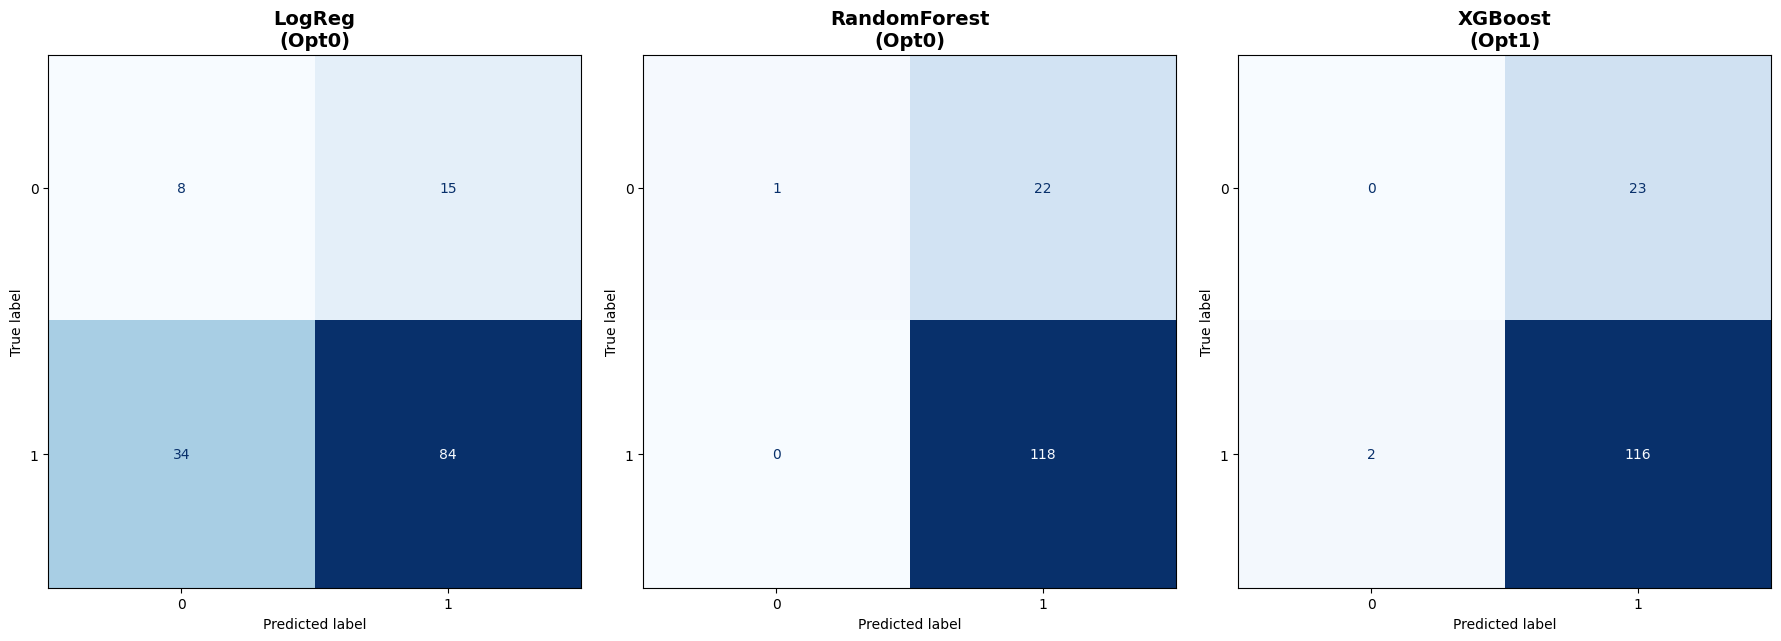


--- [Stage 2] Specific Fault Detection (Per Fault Type) ---
   Identified Fault Types: ['bearing-bpfi', 'bearing-bpfo', 'bearing-bsf', 'bearing-contaminated', 'bearing-pump', 'broken-rotor-bar', 'impeller', 'loose-foot-motor', 'loose-foot-pump', 'new-motor', 'soft-foot', 'stator-short', 'align-angular', 'align-combination', 'align-parallel', 'bent-shaft', 'cavitation-discharge', 'cavitation-suction', 'coupling', 'coupling-2D', 'unbalance-motor', 'unbalance-pump']

   >> Training Binary Models for: 'bearing-bpfi' (Optimizing Precision)
      Imbalance Ratio: 1:12.0

🚀 START EXPERIMENT: DETECTION_BEARING-BPFI
📊 Target Column: 'is_bearing-bpfi'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0913
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0962
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...


I0000 00:00:1765392110.915489  797865 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9692 MB memory:  -> device: 0, name: NVIDIA RTX A3000 12GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
2025-12-10 19:41:52.942402: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f05ec01cc00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-10 19:41:52.942453: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A3000 12GB Laptop GPU, Compute Capability 8.6
2025-12-10 19:41:52.962715: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-10 19:41:53.116703: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-12-10 19:41:53.200520: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:20

   ✅ NN_Medium: accuracy=0.9291 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...


2025-12-10 19:41:59.780728: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 19:41:59.780791: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 19:41:59.780828: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 19:41:59.780841: I external/l

   ✅ NN_Complex: accuracy=0.9291 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...


...

   ✅ NN_Wide: accuracy=0.9291 (Stopped at epoch 7)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1164
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1089
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9291 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9291 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9291 (Stopped at epoch 6)

--- ⚙️ Processing Opt2_S1_D1_PCA ---
   ✅ XGBoost: precision=0.0729
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1169
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9291 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...


2025-12-10 19:42:49.055894: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 19:42:49.534966: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1356', 16 bytes spill stores, 16 bytes spill loads

2025-12-10 19:42:49.585986: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1356', 16 bytes spill stores, 16 bytes spill loads

2025-12-10 19:42:49.750437: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1356', 396 b

   ✅ NN_Complex: accuracy=0.9291 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Wide...


2025-12-10 19:42:55.181941: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 19:42:55.181991: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 19:42:55.879743: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_212', 92 bytes spill stores, 92 bytes spill loads

2025-12-10 19:42:55.994194: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

   ✅ NN_Wide: accuracy=0.9291 (Stopped at epoch 8)

🏁 Experiments for Detection_bearing-bpfi completed!
      >> Best results for bearing-bpfi:

=== [Detection_bearing-bpfi] Top 3 Results (Sorted by precision) ===
  Model                   Config Option_ID  precision     f1  recall  accuracy  learning_rate  max_depth  n_estimators  min_samples_leaf   C  n_neighbors weights params
 LogReg Opt2 (Scale:Yes PCA:Yes)      Opt2     0.1169 0.1968  0.6361    0.6277            NaN        NaN           NaN               NaN 0.1          NaN     NaN    NaN
XGBoost  Opt1 (Scale:Yes PCA:No)      Opt1     0.1164 0.1658  0.5722    0.8681           0.01        6.0         200.0               NaN NaN          NaN     NaN    NaN
 LogReg  Opt1 (Scale:Yes PCA:No)      Opt1     0.1089 0.1919  0.8139    0.5188            NaN        NaN           NaN               NaN 0.1          NaN     NaN    NaN


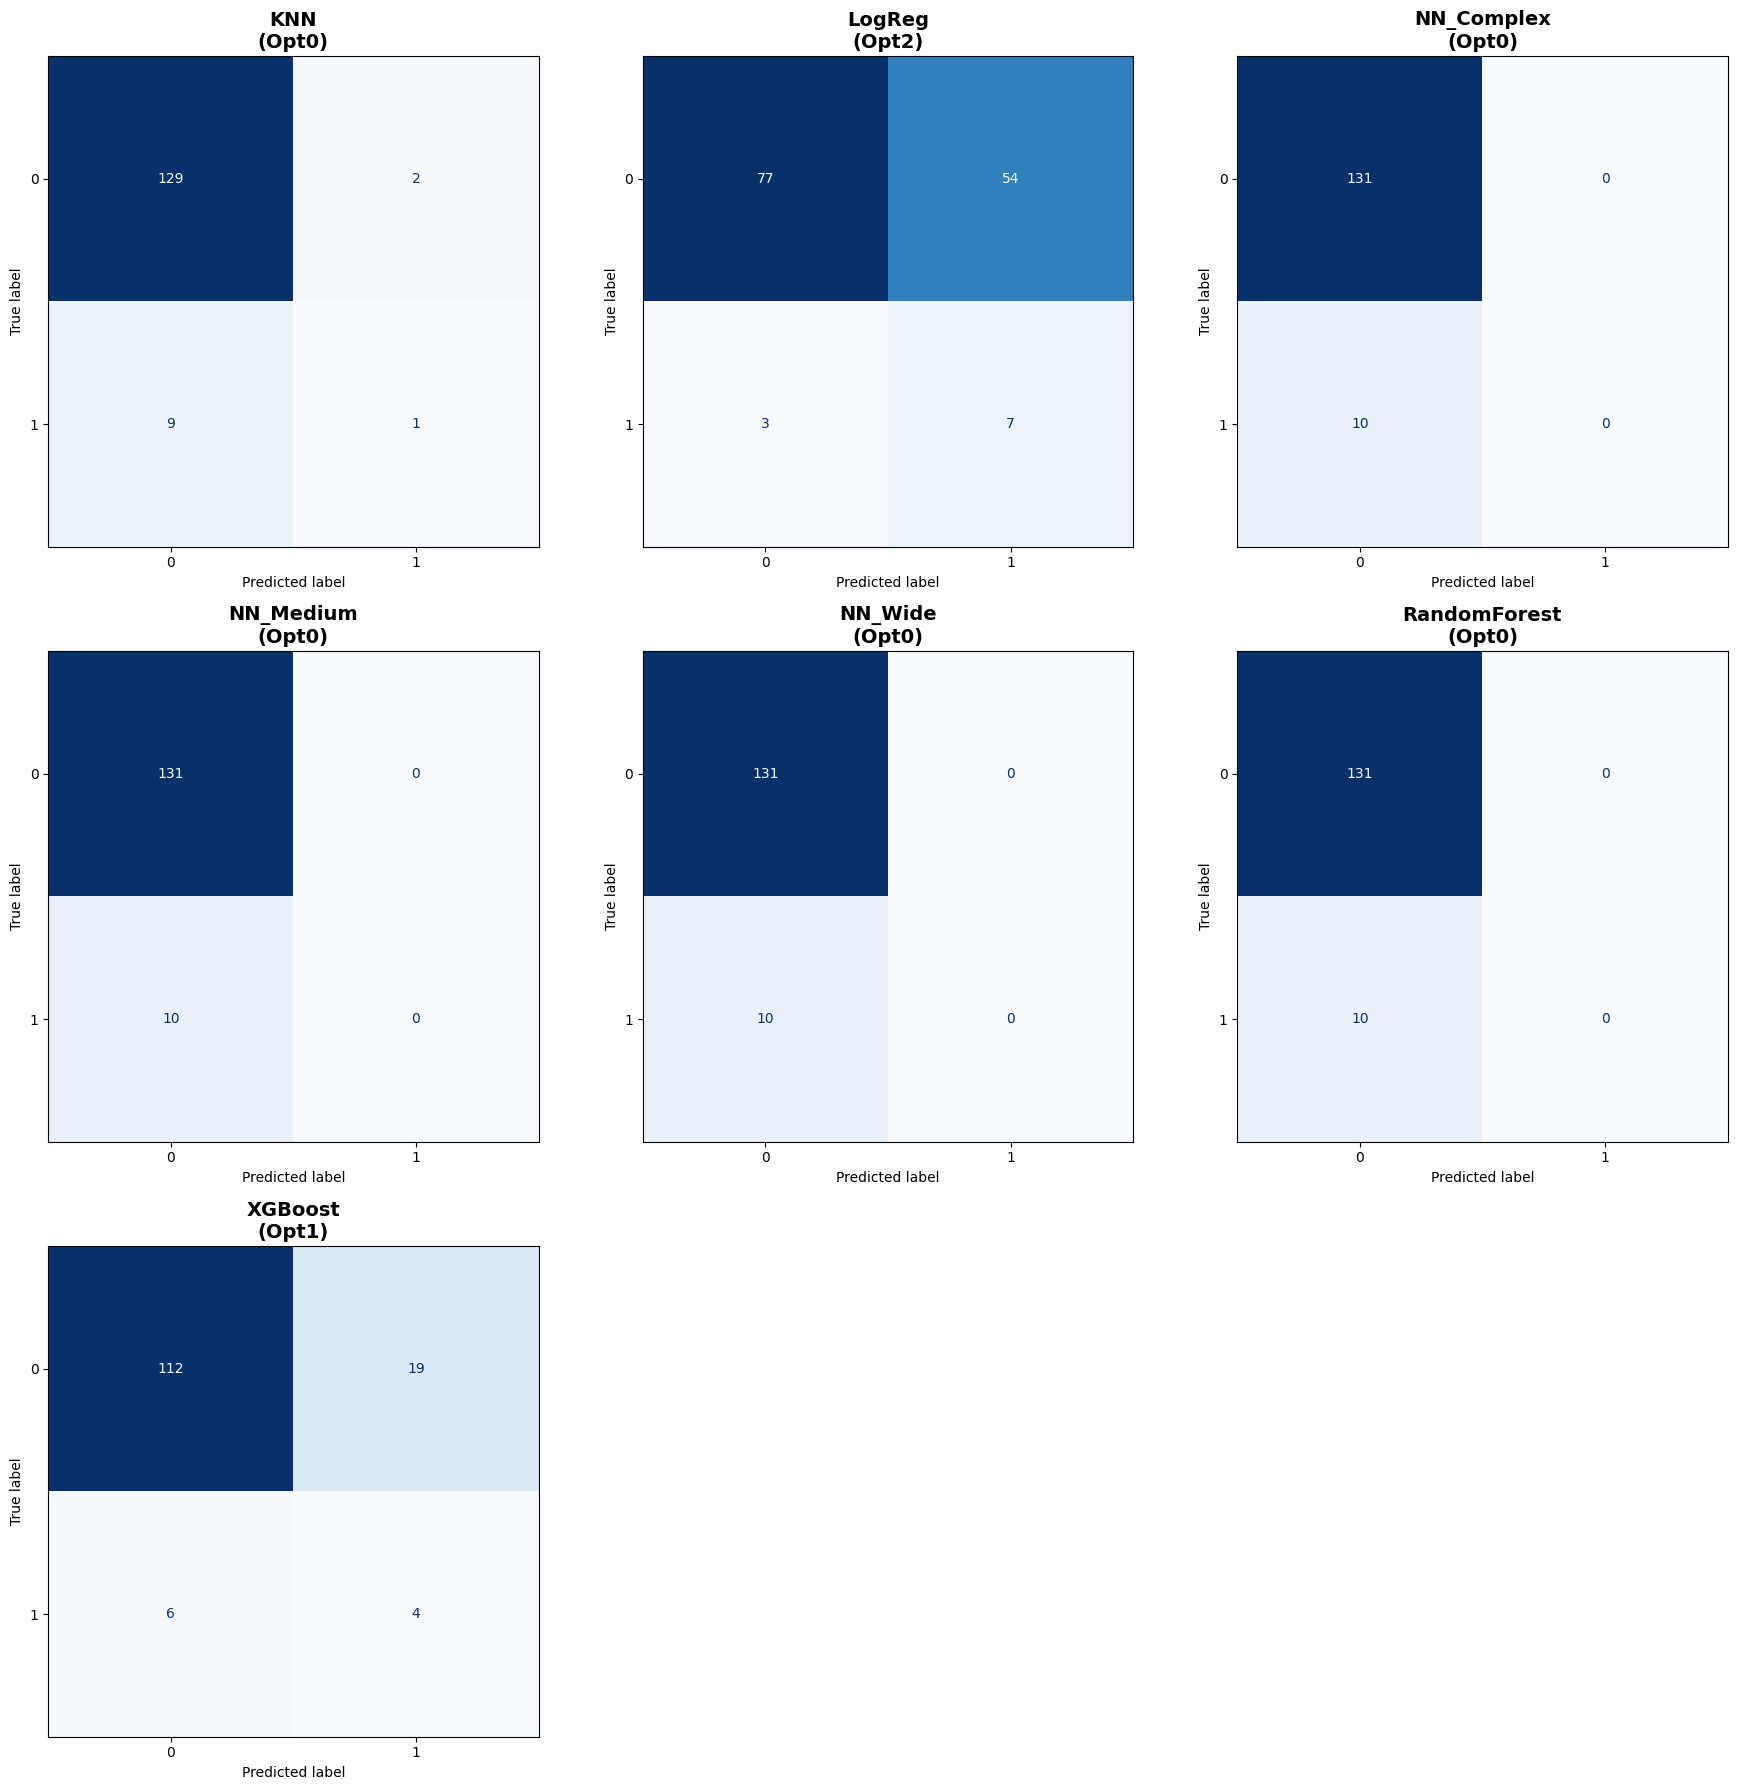


   >> Training Binary Models for: 'bearing-bpfo' (Optimizing Precision)
      Imbalance Ratio: 1:12.0

🚀 START EXPERIMENT: DETECTION_BEARING-BPFO
📊 Target Column: 'is_bearing-bpfo'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.1334
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1124
   ✅ KNN: precision=0.2000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9291 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9291 (Stopped at epoch 6)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9291 (Stopped at epoch 7)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0879
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1154
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9291 (Stopped at epoch 16)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9291 (Stopped at epoch 16)
   🧠 Training Neura

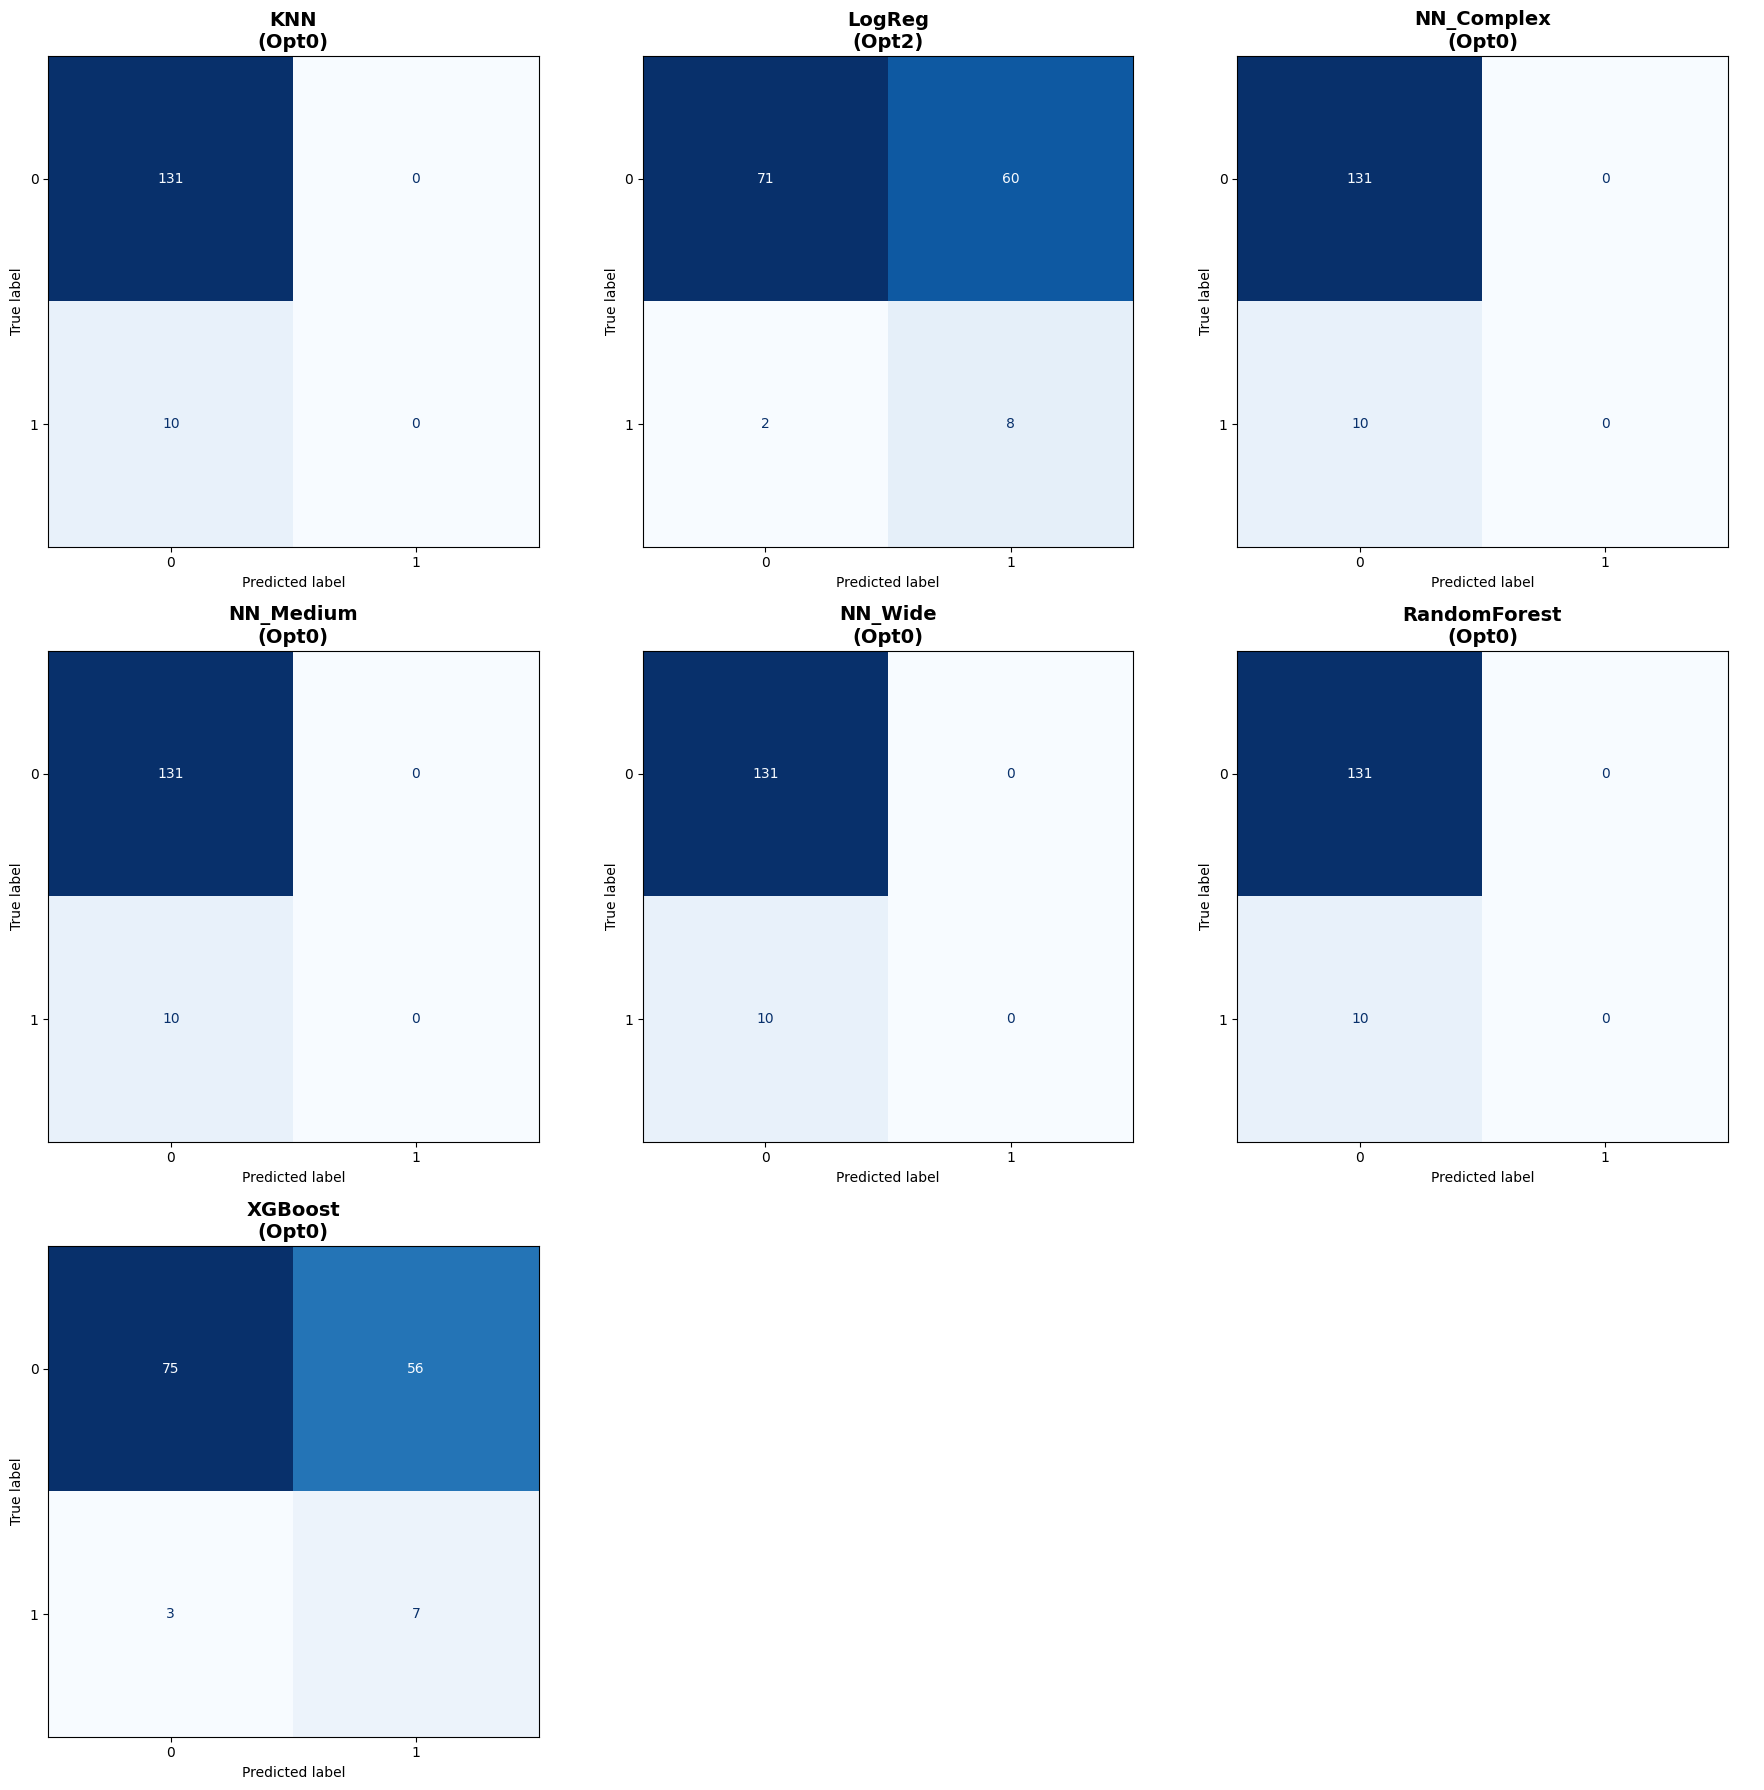


   >> Training Binary Models for: 'bearing-bsf' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_BEARING-BSF
📊 Target Column: 'is_bearing-bsf'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0167
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0417
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9787 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0084
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0261
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 7)
   🧠 Training Neural Net

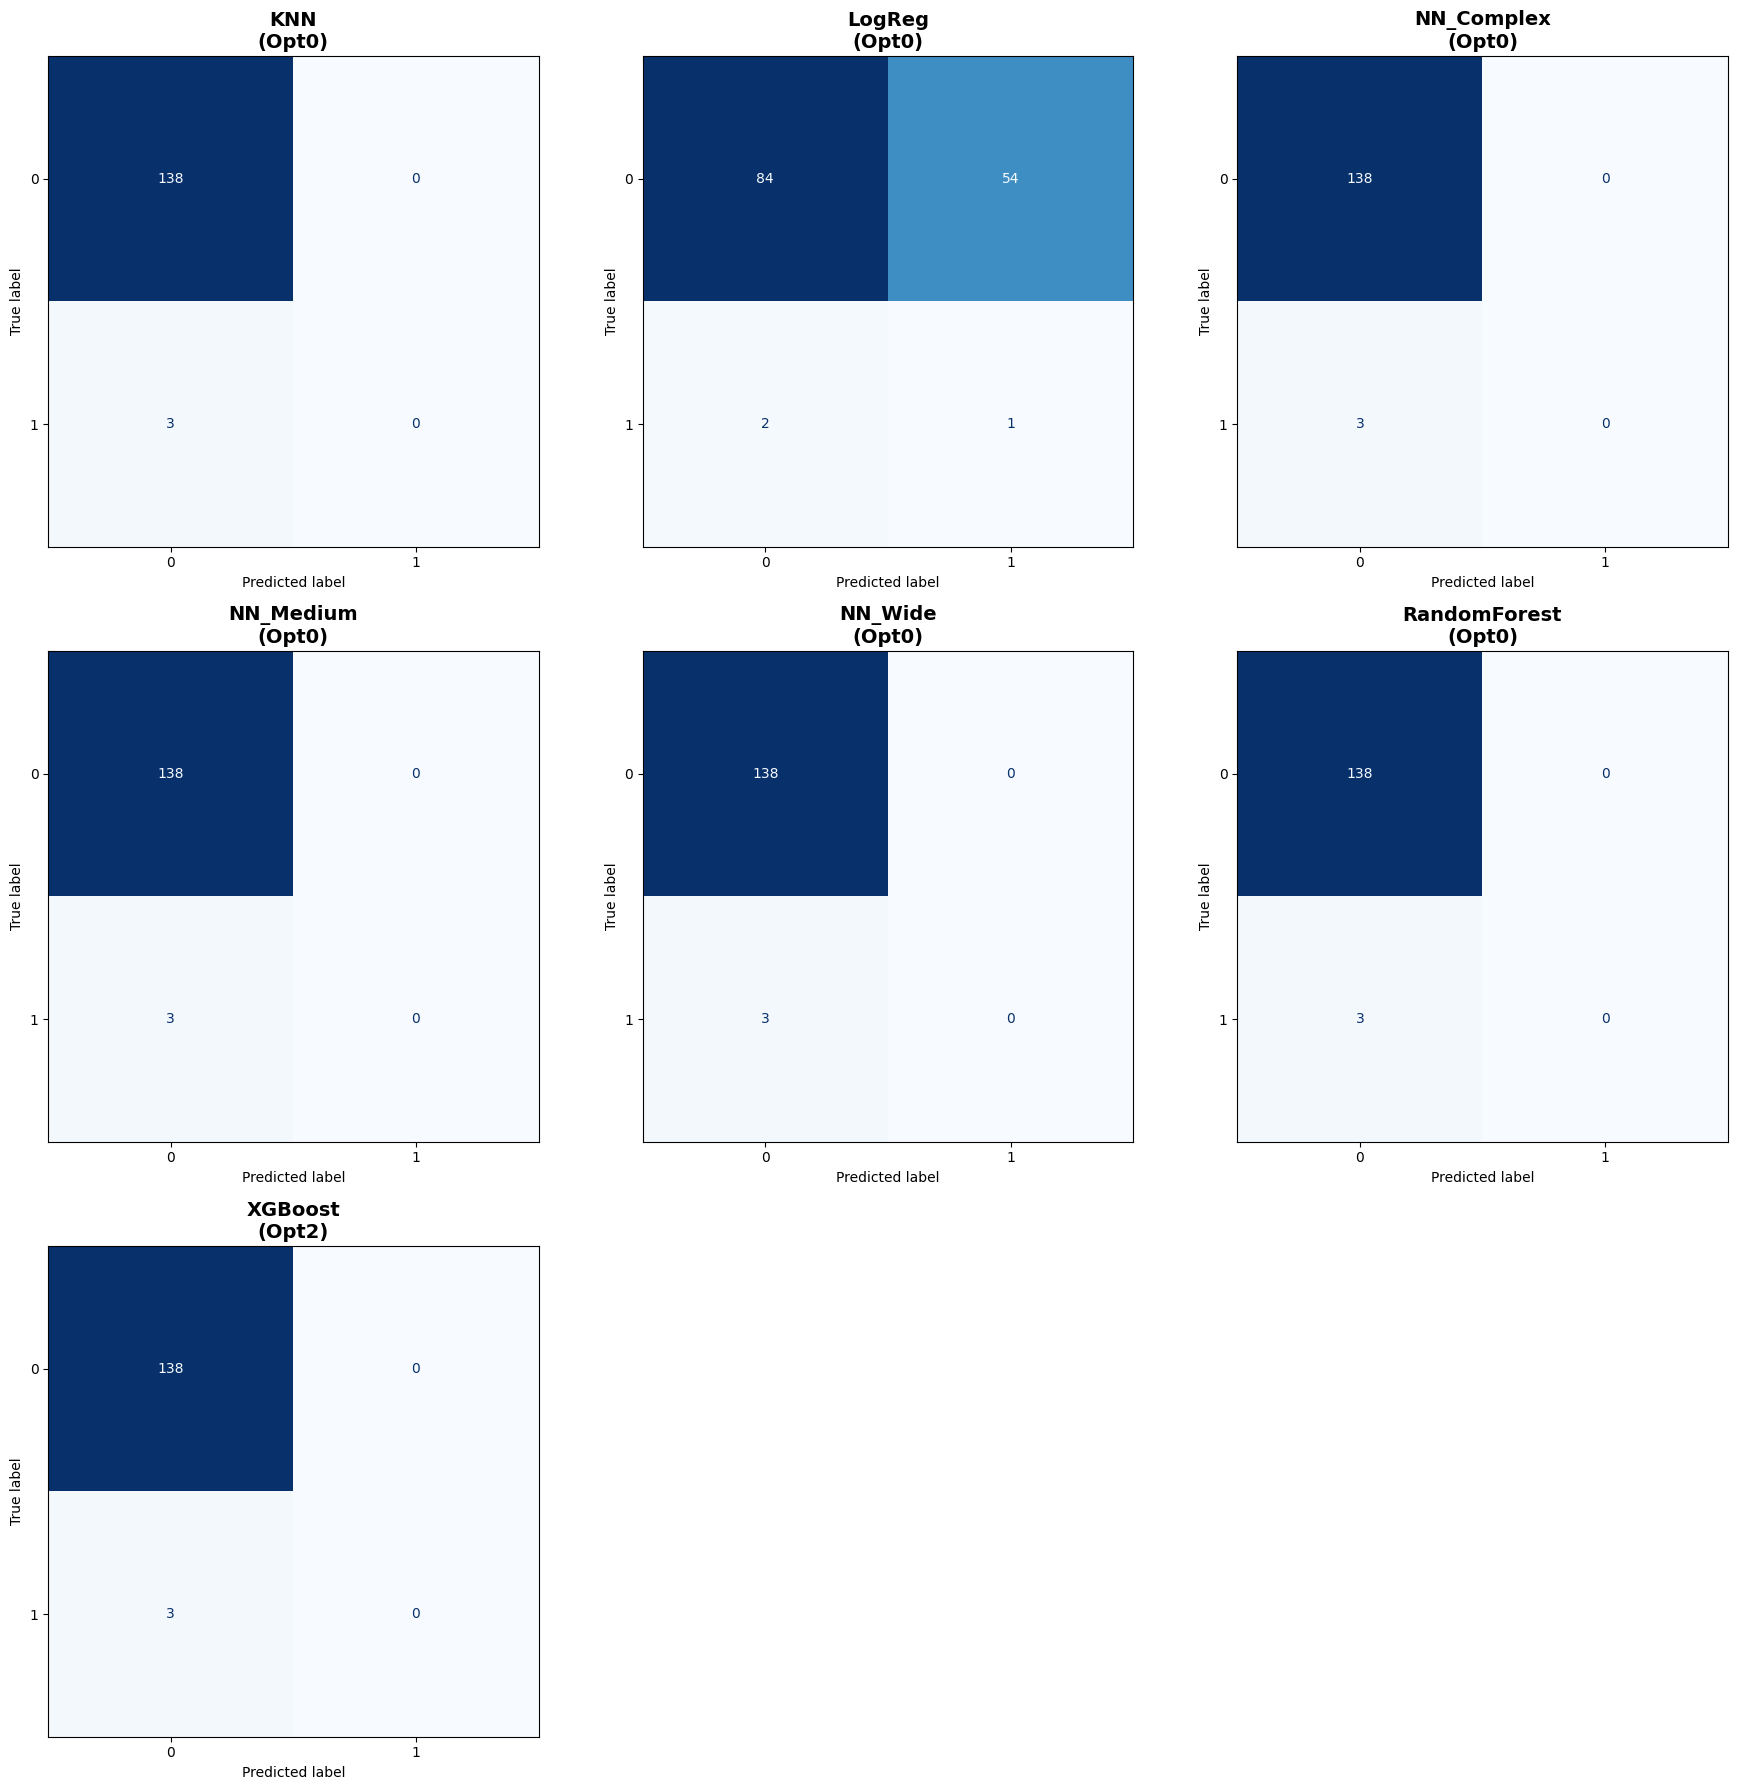


   >> Training Binary Models for: 'bearing-contaminated' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_BEARING-CONTAMINATED
📊 Target Column: 'is_bearing-contaminated'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0347
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0295
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 14)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9645 (Stopped at epoch 8)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0900
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0111
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 19)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch

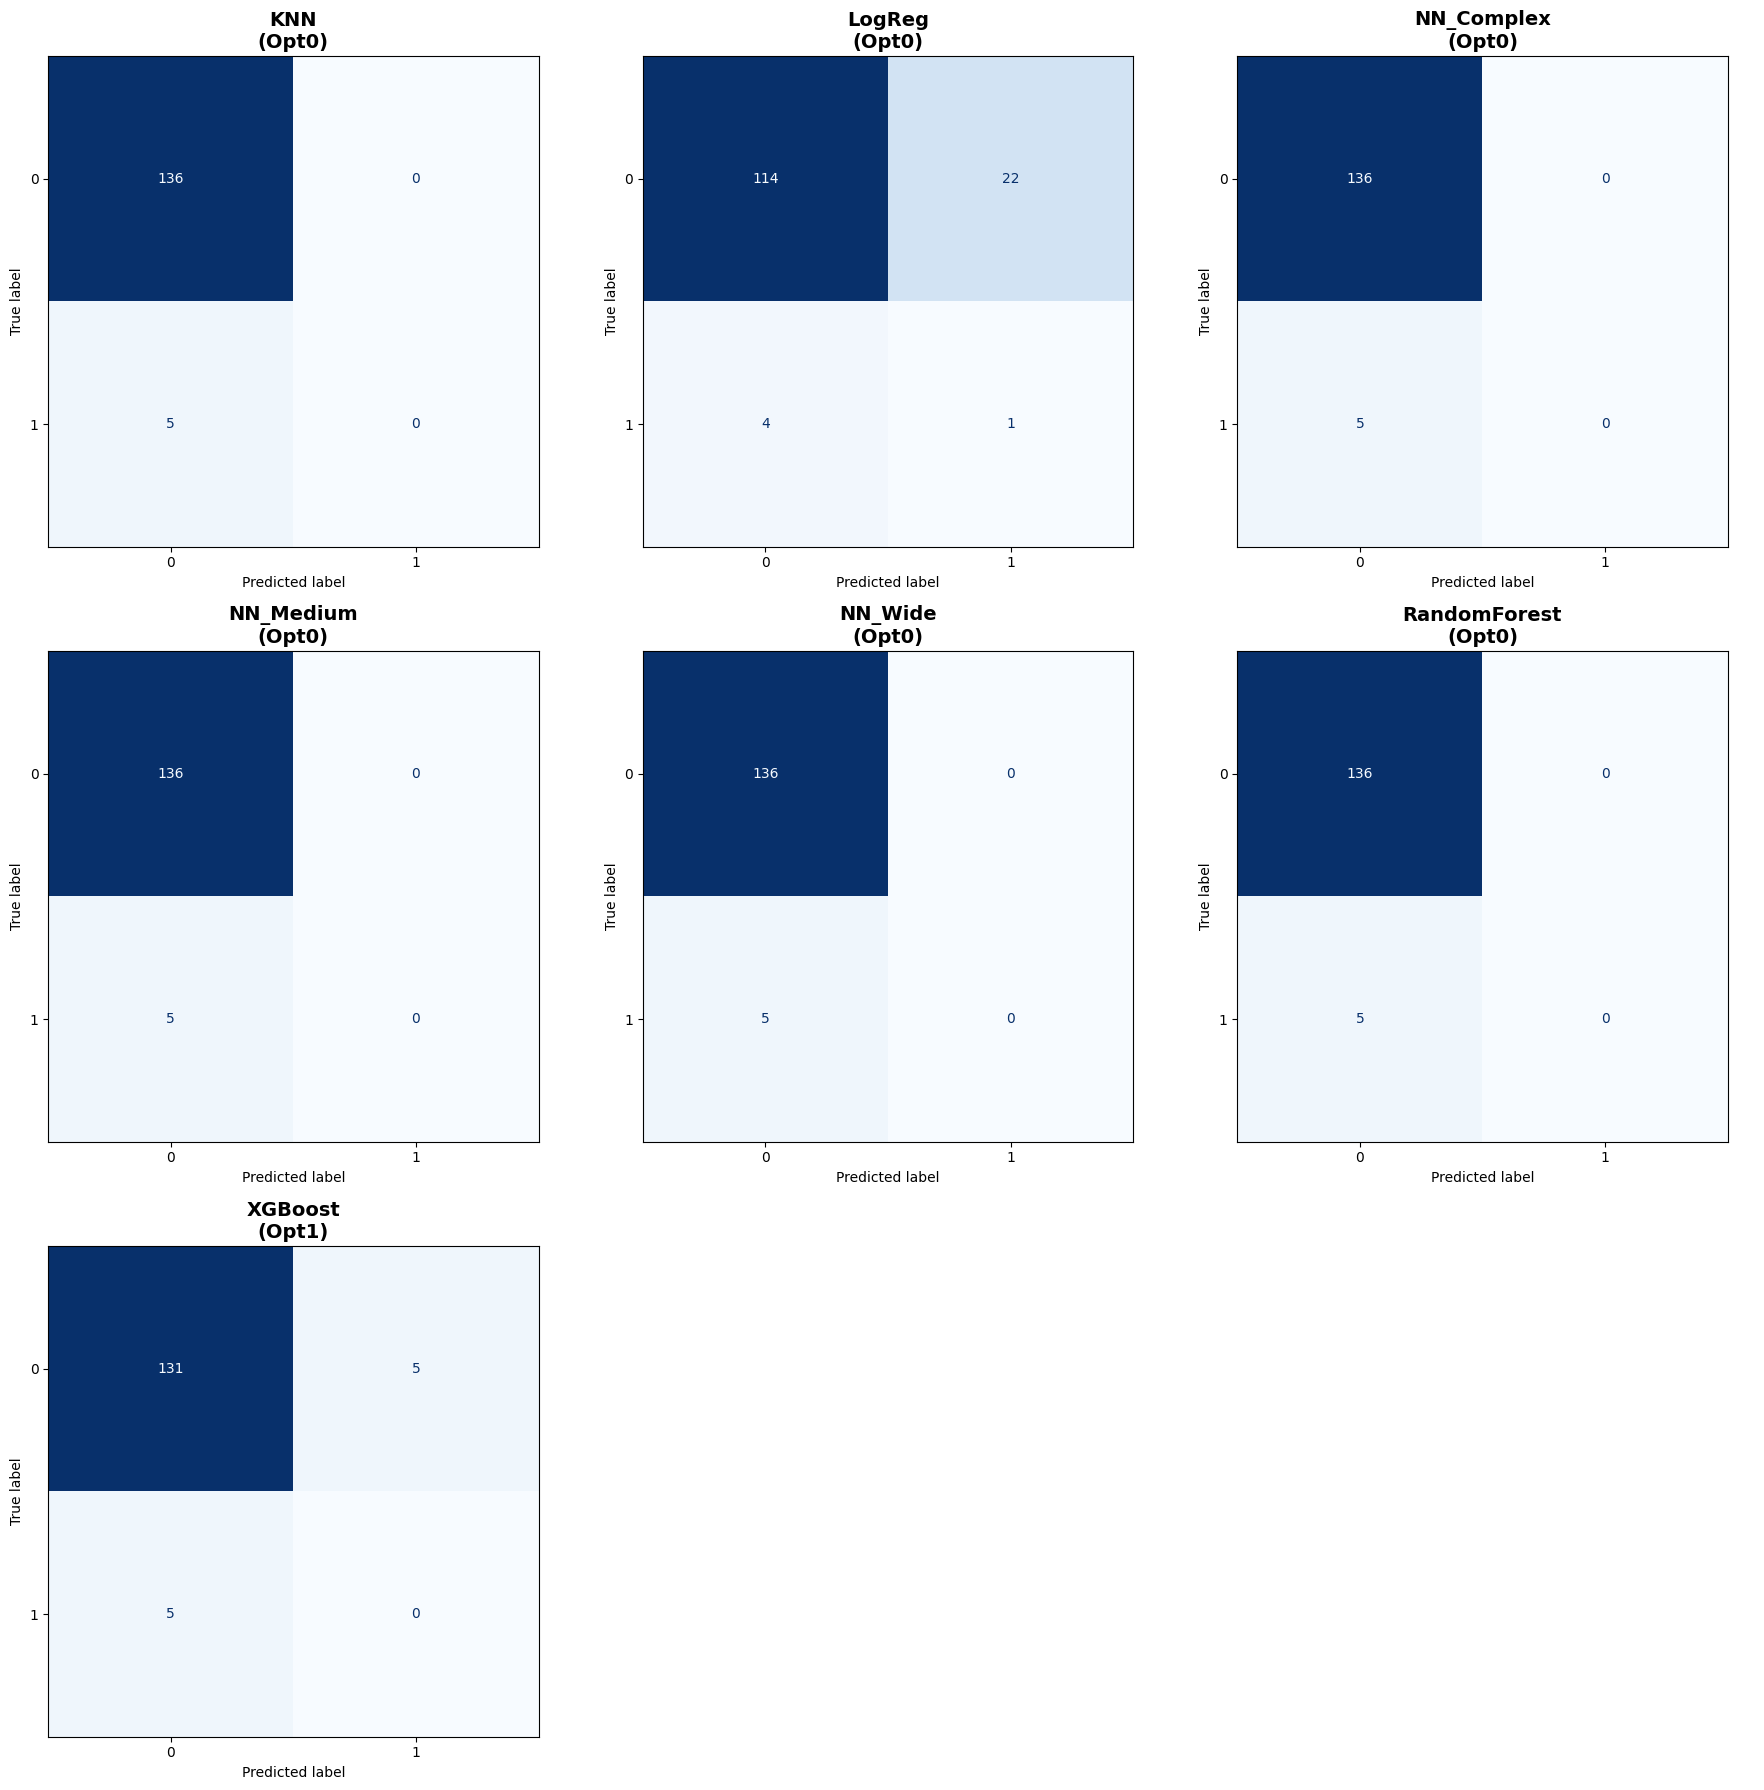


   >> Training Binary Models for: 'bearing-pump' (Optimizing Precision)
      Imbalance Ratio: 1:12.0

🚀 START EXPERIMENT: DETECTION_BEARING-PUMP
📊 Target Column: 'is_bearing-pump'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.1008
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0991
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9007 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9007 (Stopped at epoch 17)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9007 (Stopped at epoch 10)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1139
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1027
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9007 (Stopped at epoch 16)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9007 (Stopped at epoch 11)
   🧠 Training Neu

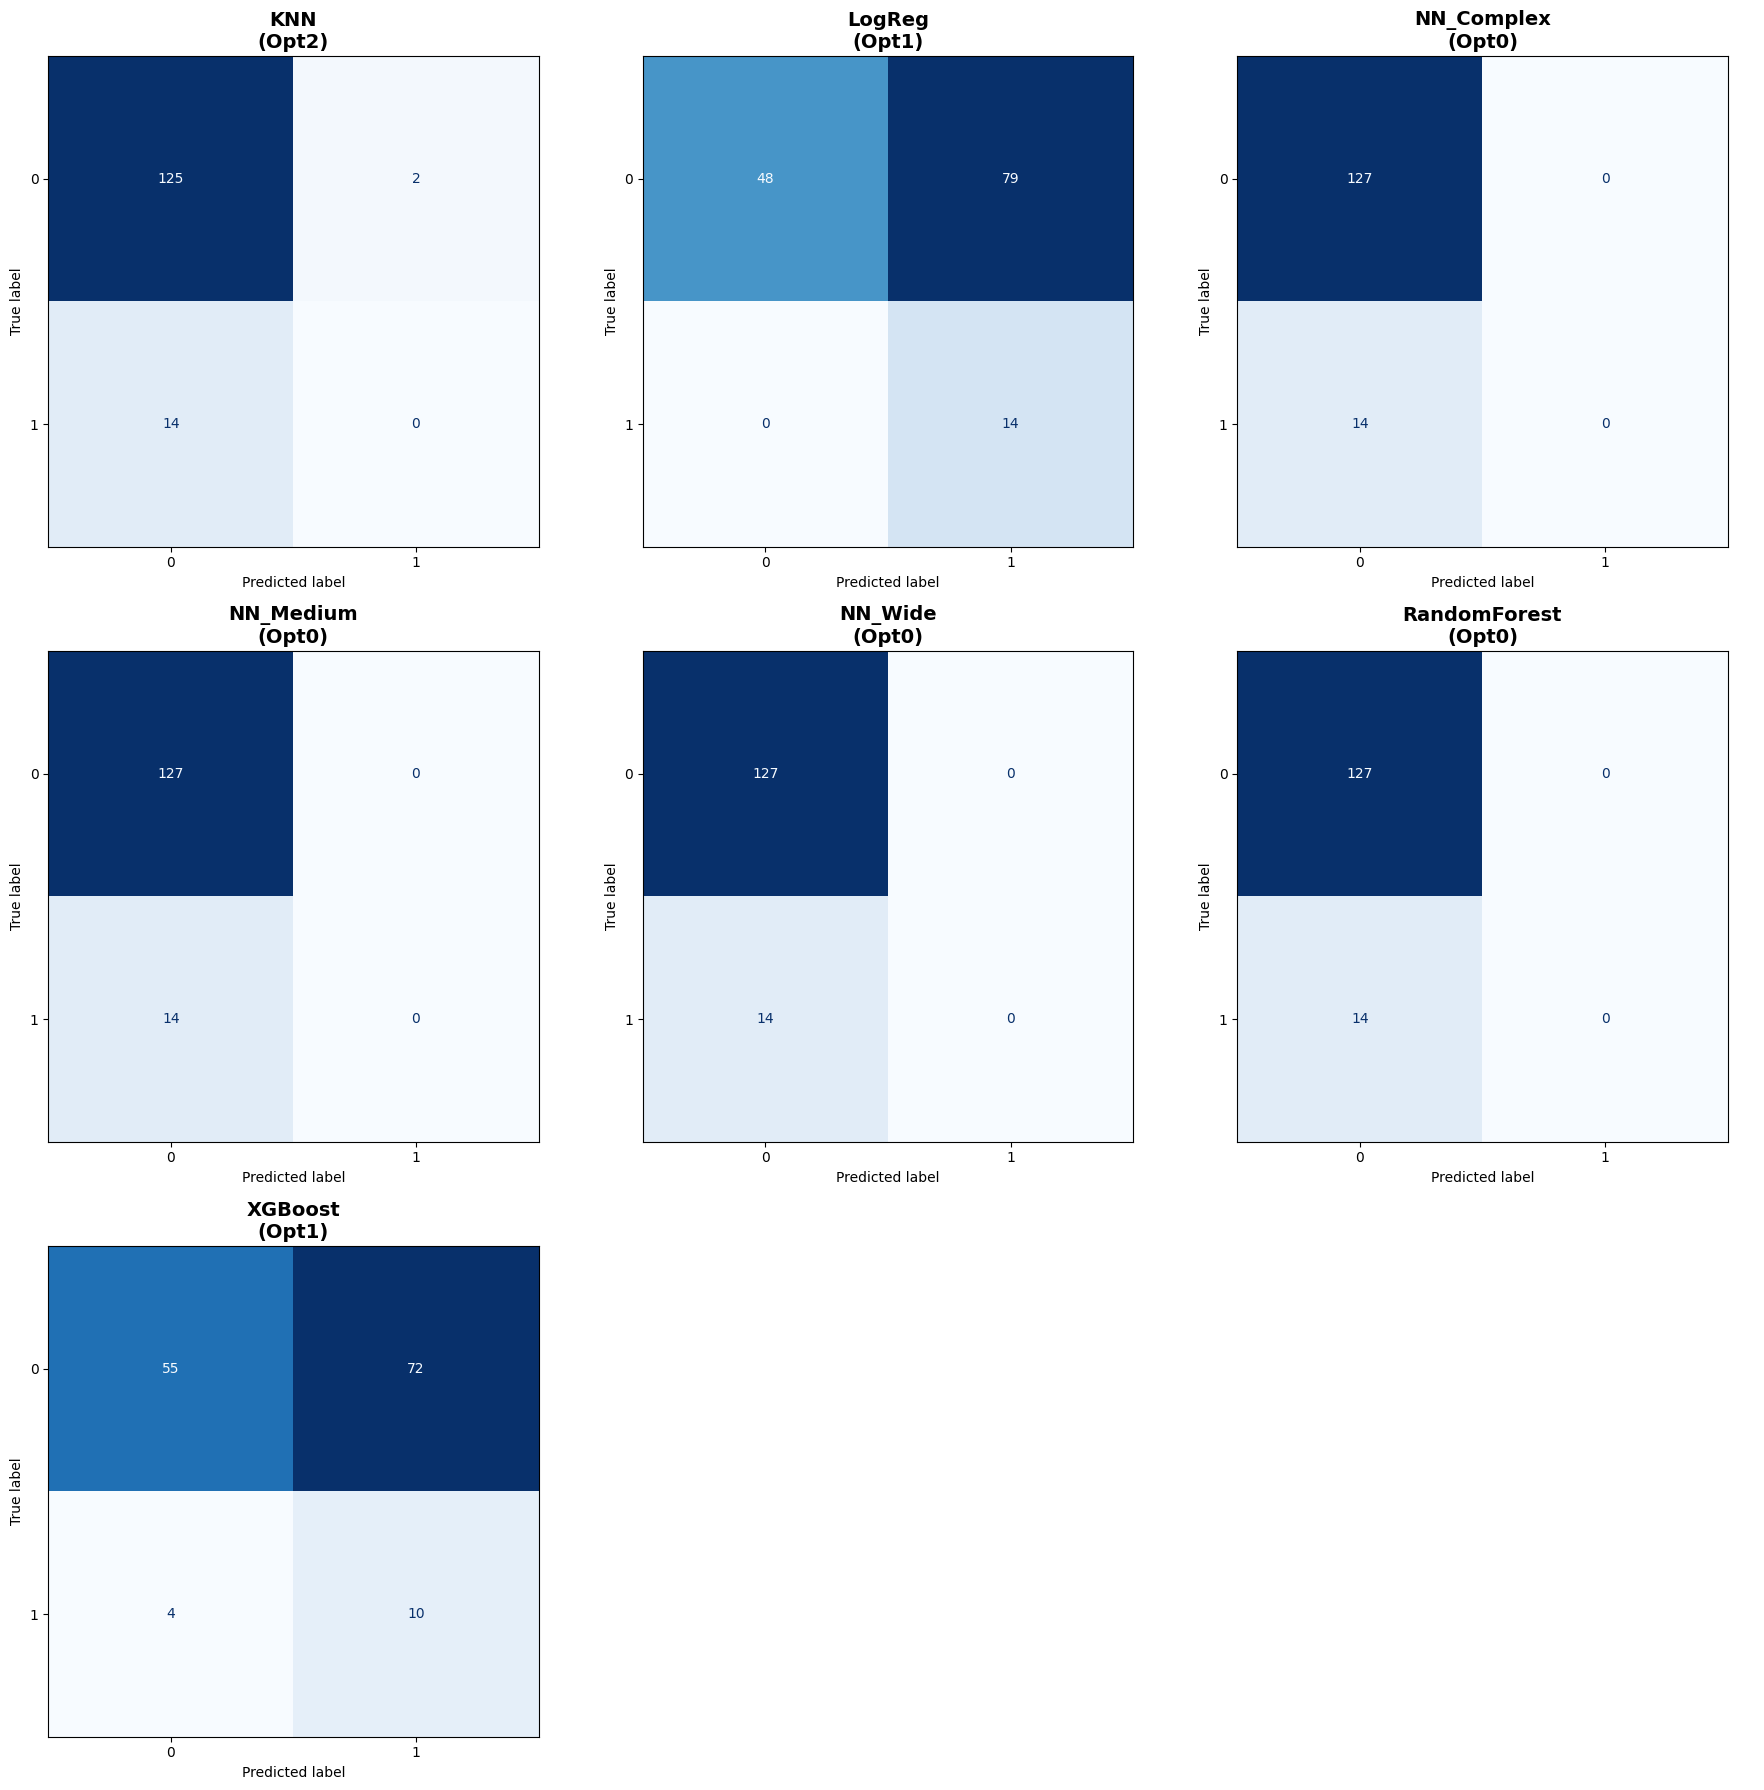


   >> Training Binary Models for: 'broken-rotor-bar' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_BROKEN-ROTOR-BAR
📊 Target Column: 'is_broken-rotor-bar'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0708
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0515
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 13)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 12)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9787 (Stopped at epoch 8)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0219
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0421
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 33)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 28)
   🧠 T

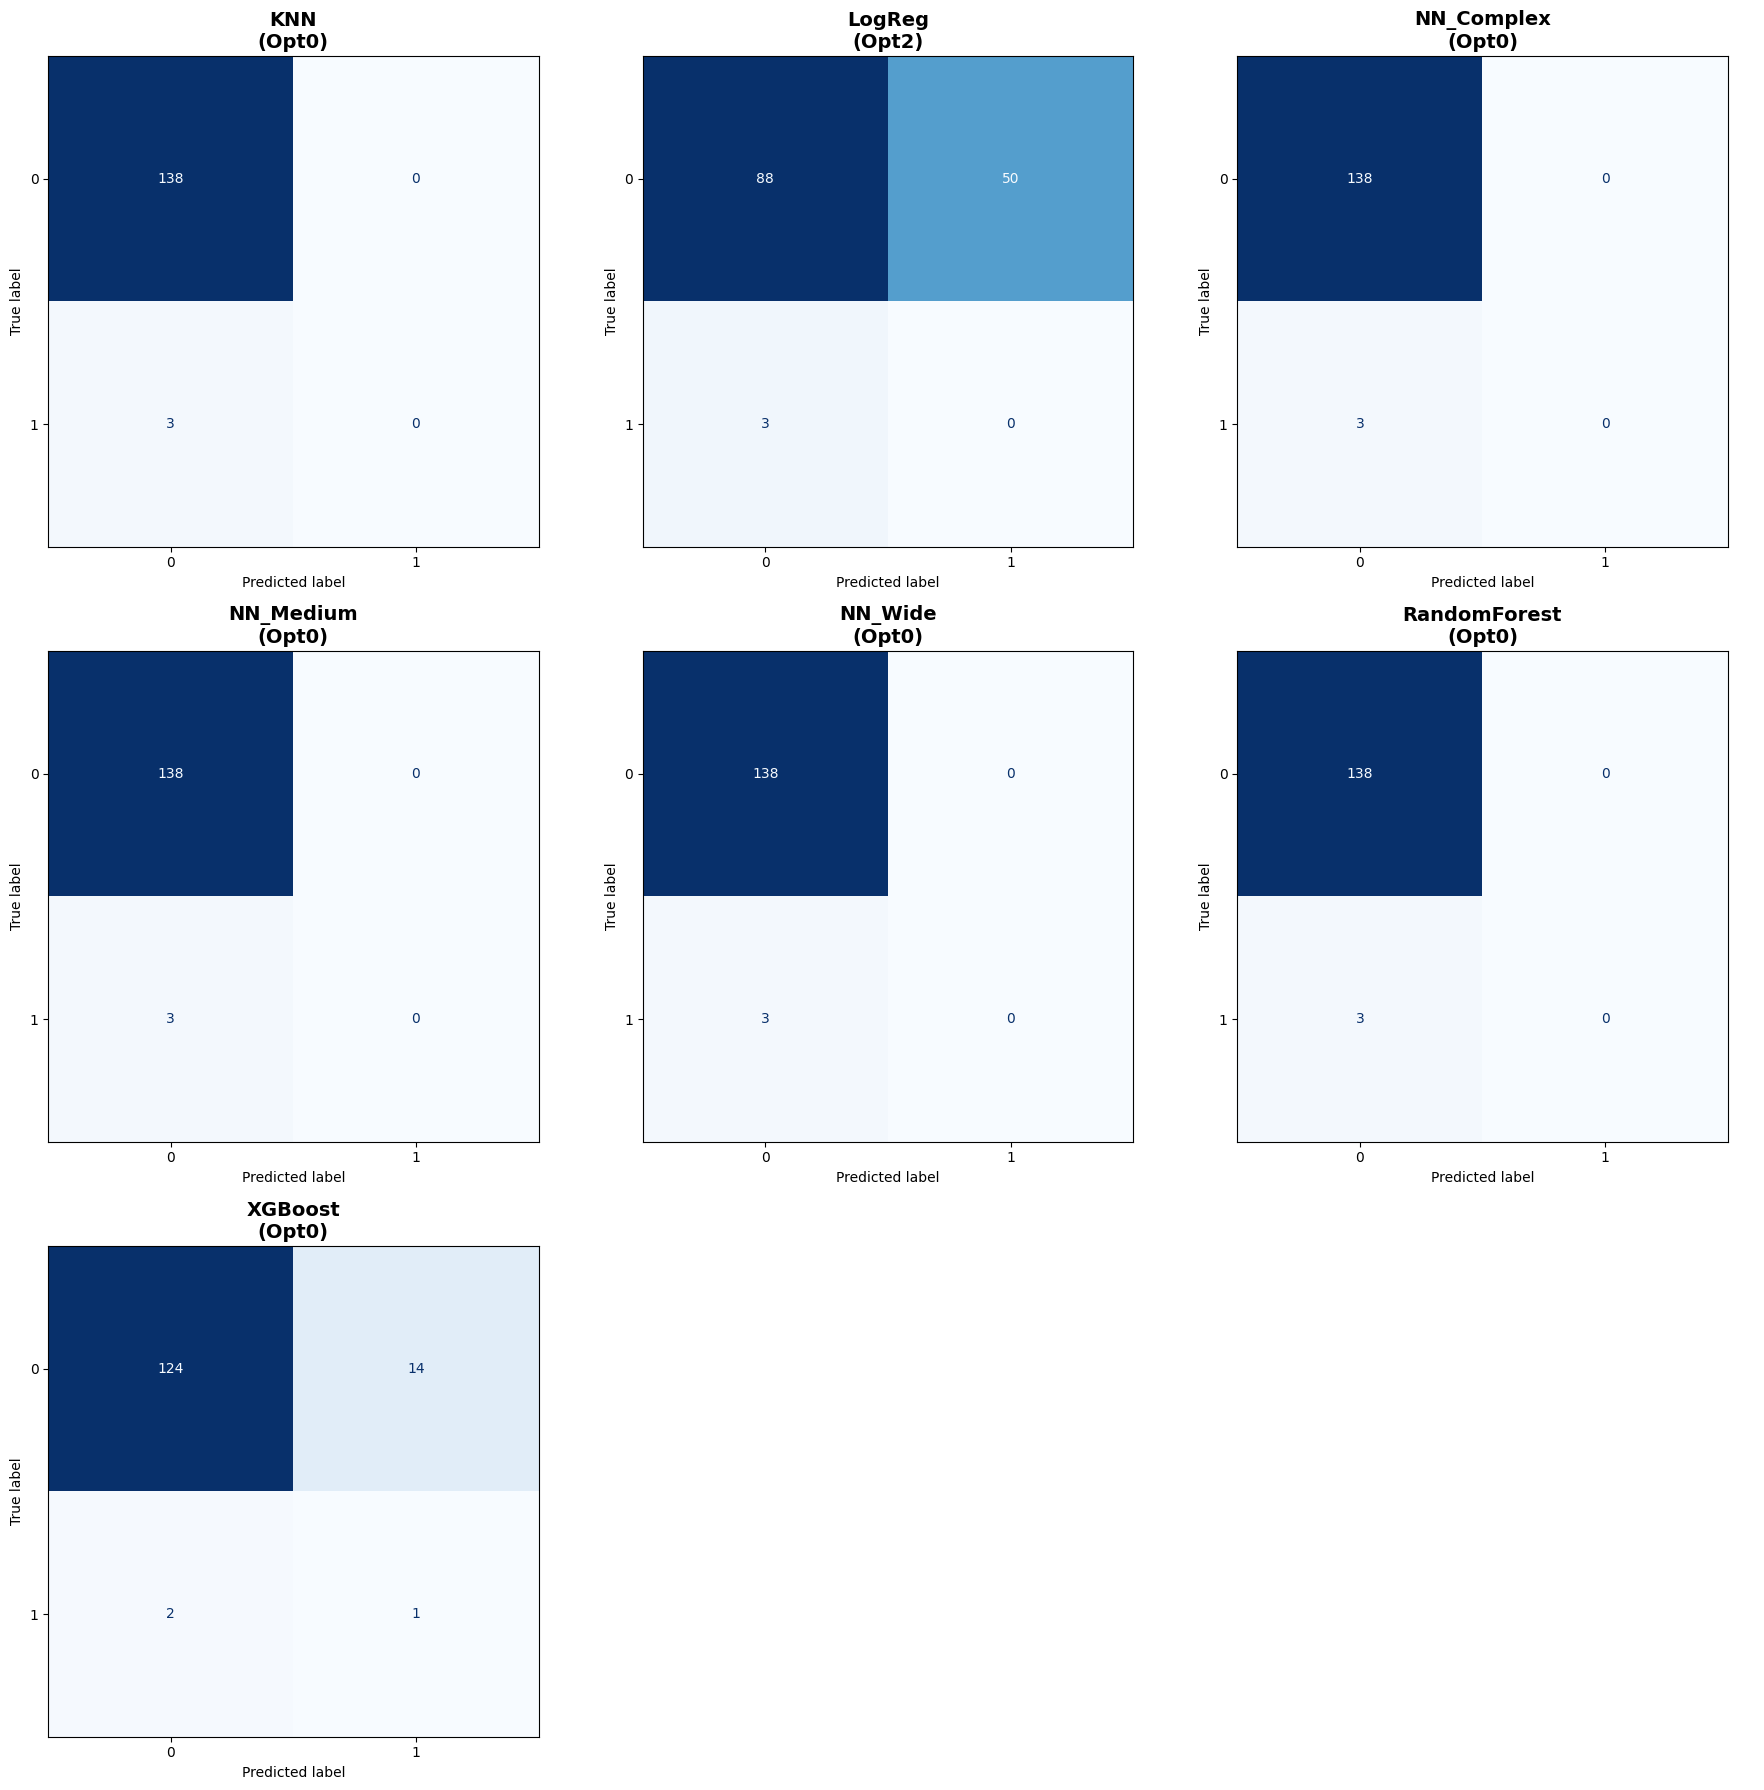


   >> Training Binary Models for: 'impeller' (Optimizing Precision)
      Imbalance Ratio: 1:12.0

🚀 START EXPERIMENT: DETECTION_IMPELLER
📊 Target Column: 'is_impeller'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.1130
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1344
   ✅ KNN: precision=0.0833
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9291 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9291 (Stopped at epoch 13)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9291 (Stopped at epoch 10)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1630
   ✅ RandomForest: precision=0.2400
   ✅ LogReg: precision=0.1080
   ✅ KNN: precision=0.0286
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9291 (Stopped at epoch 16)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9291 (Stopped at epoch 21)
   🧠 Training Neural Network:

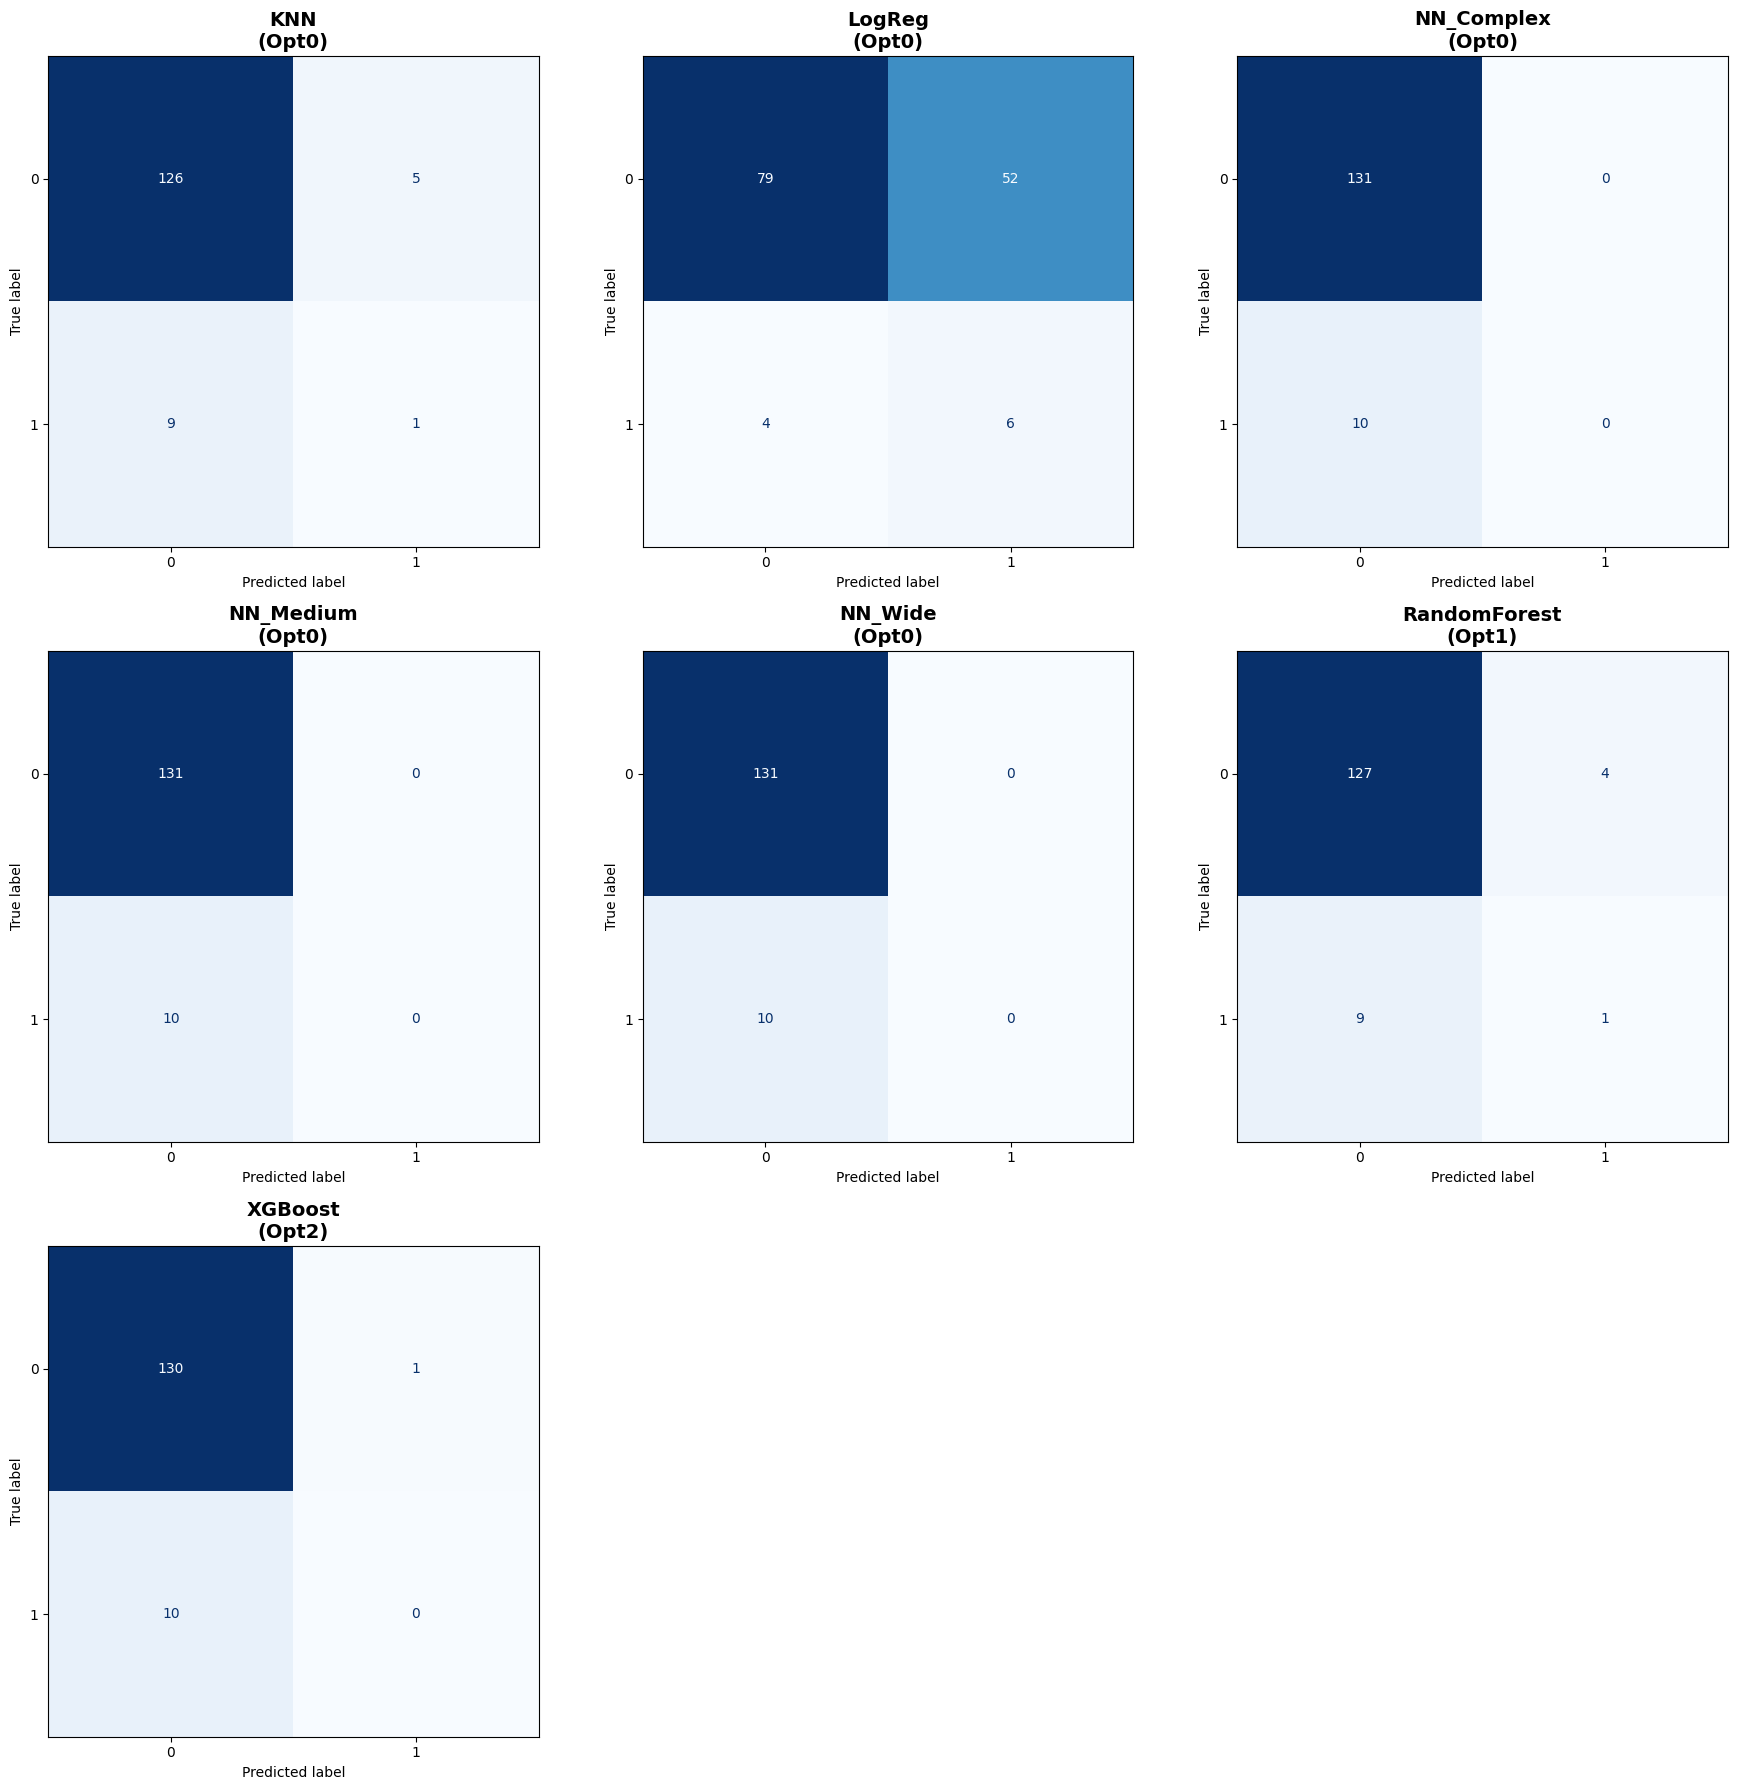


   >> Training Binary Models for: 'loose-foot-motor' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_LOOSE-FOOT-MOTOR
📊 Target Column: 'is_loose-foot-motor'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0619
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0418
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 18)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 14)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9787 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0230
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0326
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 8)
   🧠 T

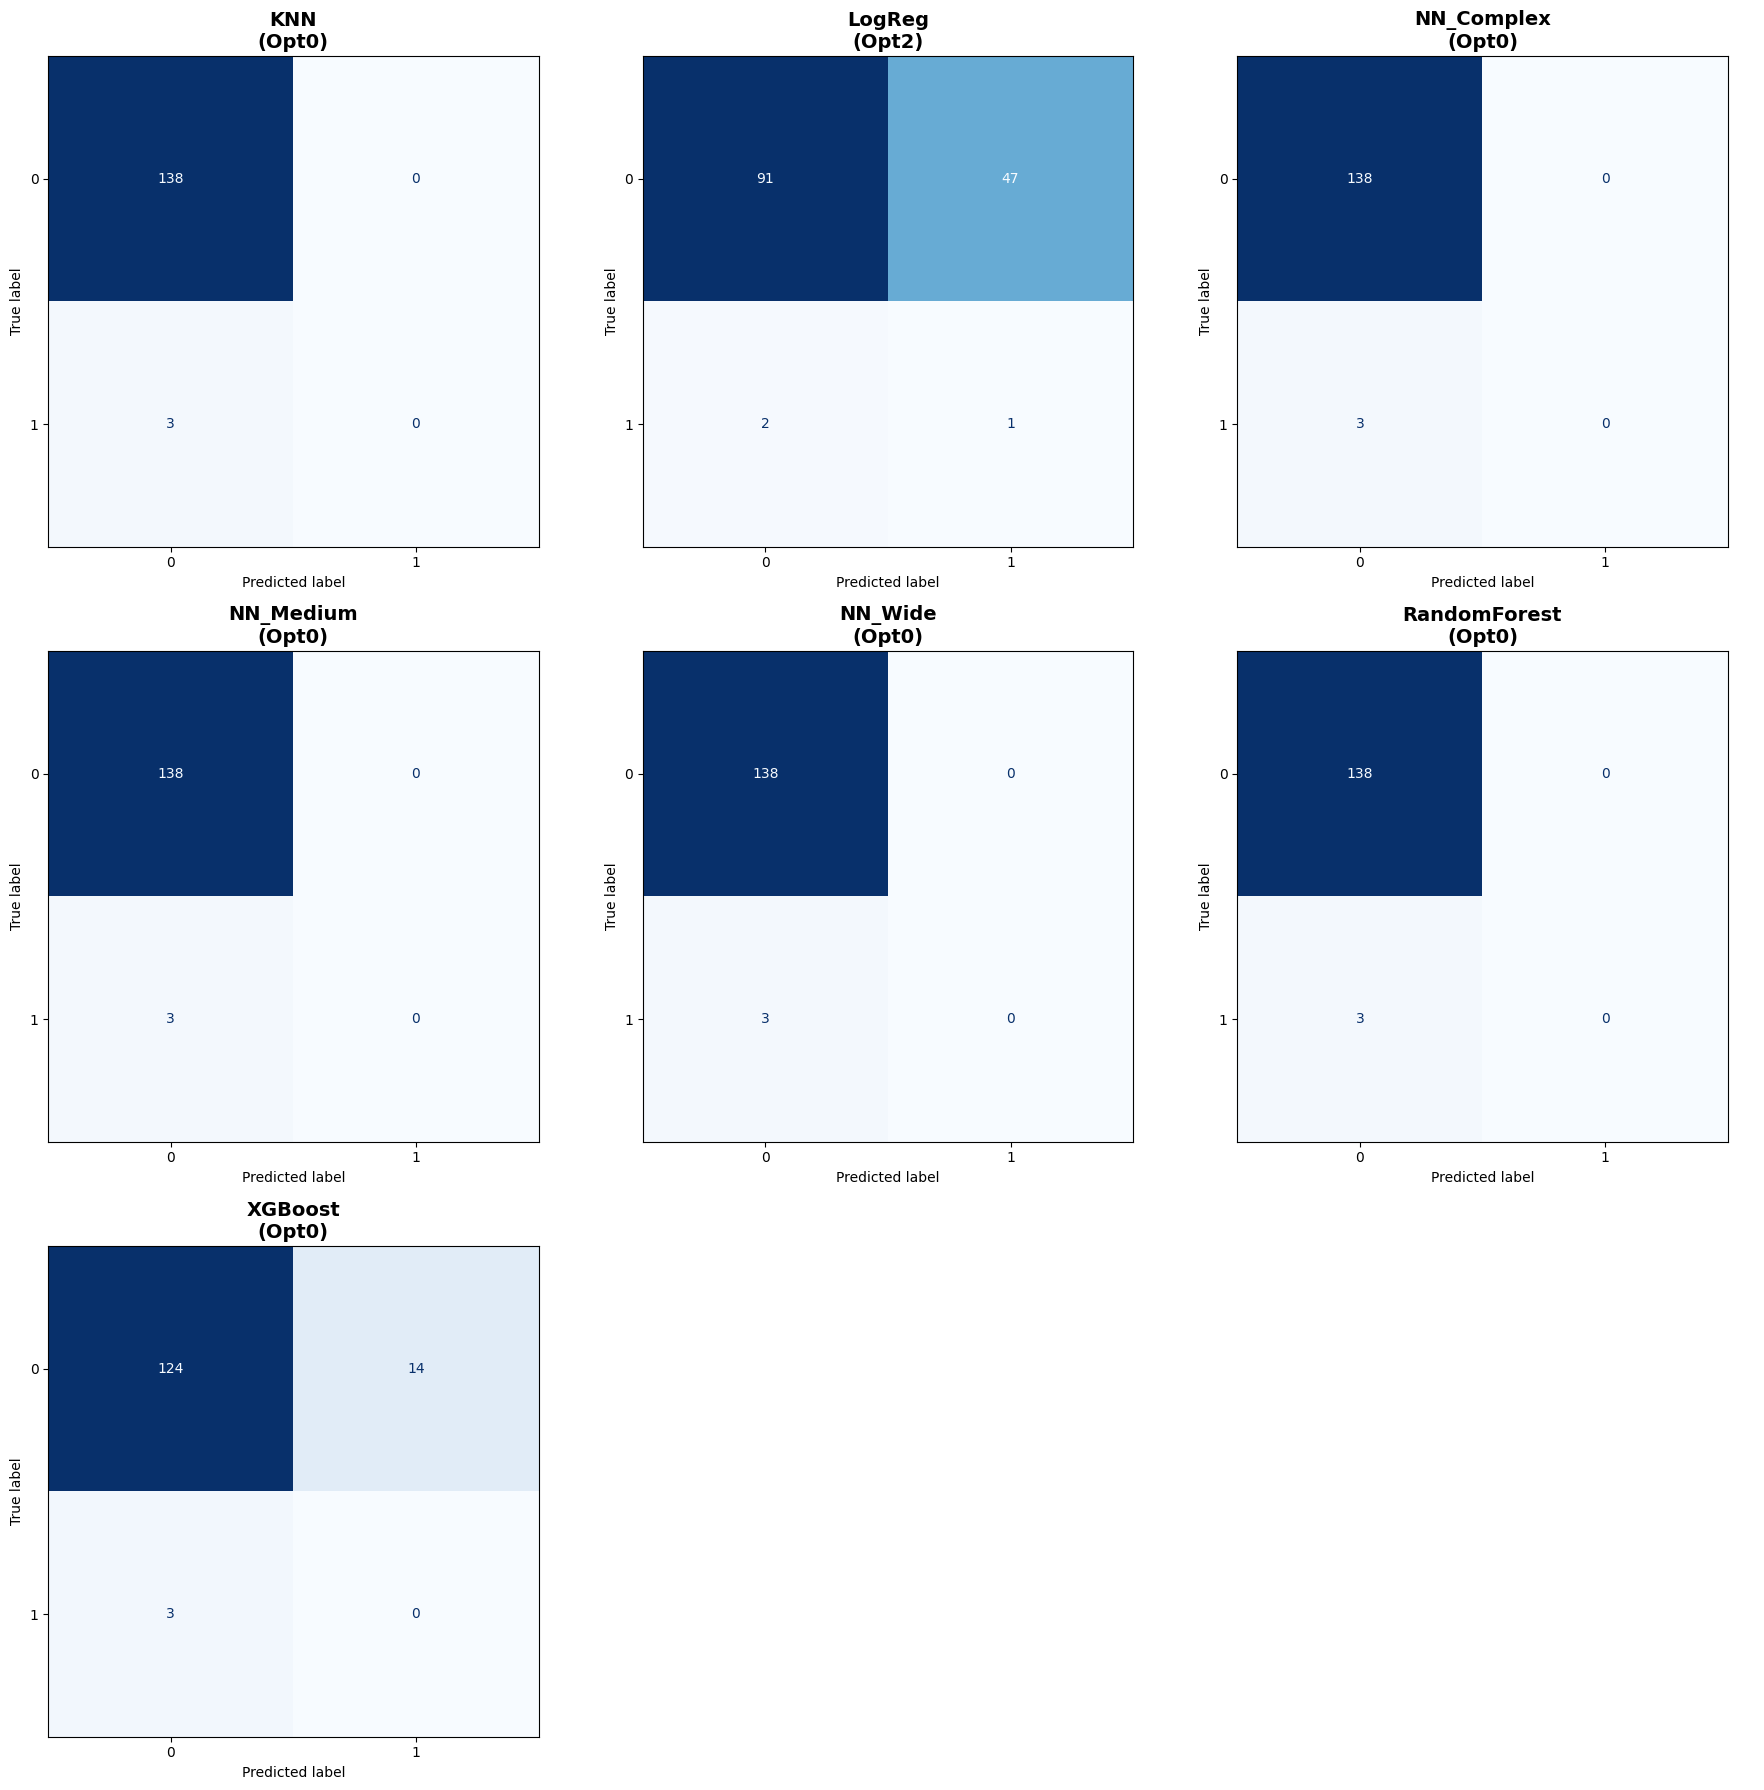


   >> Training Binary Models for: 'loose-foot-pump' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_LOOSE-FOOT-PUMP
📊 Target Column: 'is_loose-foot-pump'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0400
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0201
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9574 (Stopped at epoch 6)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9574 (Stopped at epoch 28)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9574 (Stopped at epoch 20)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0054
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0132
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9574 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9574 (Stopped at epoch 16)
   🧠 Train

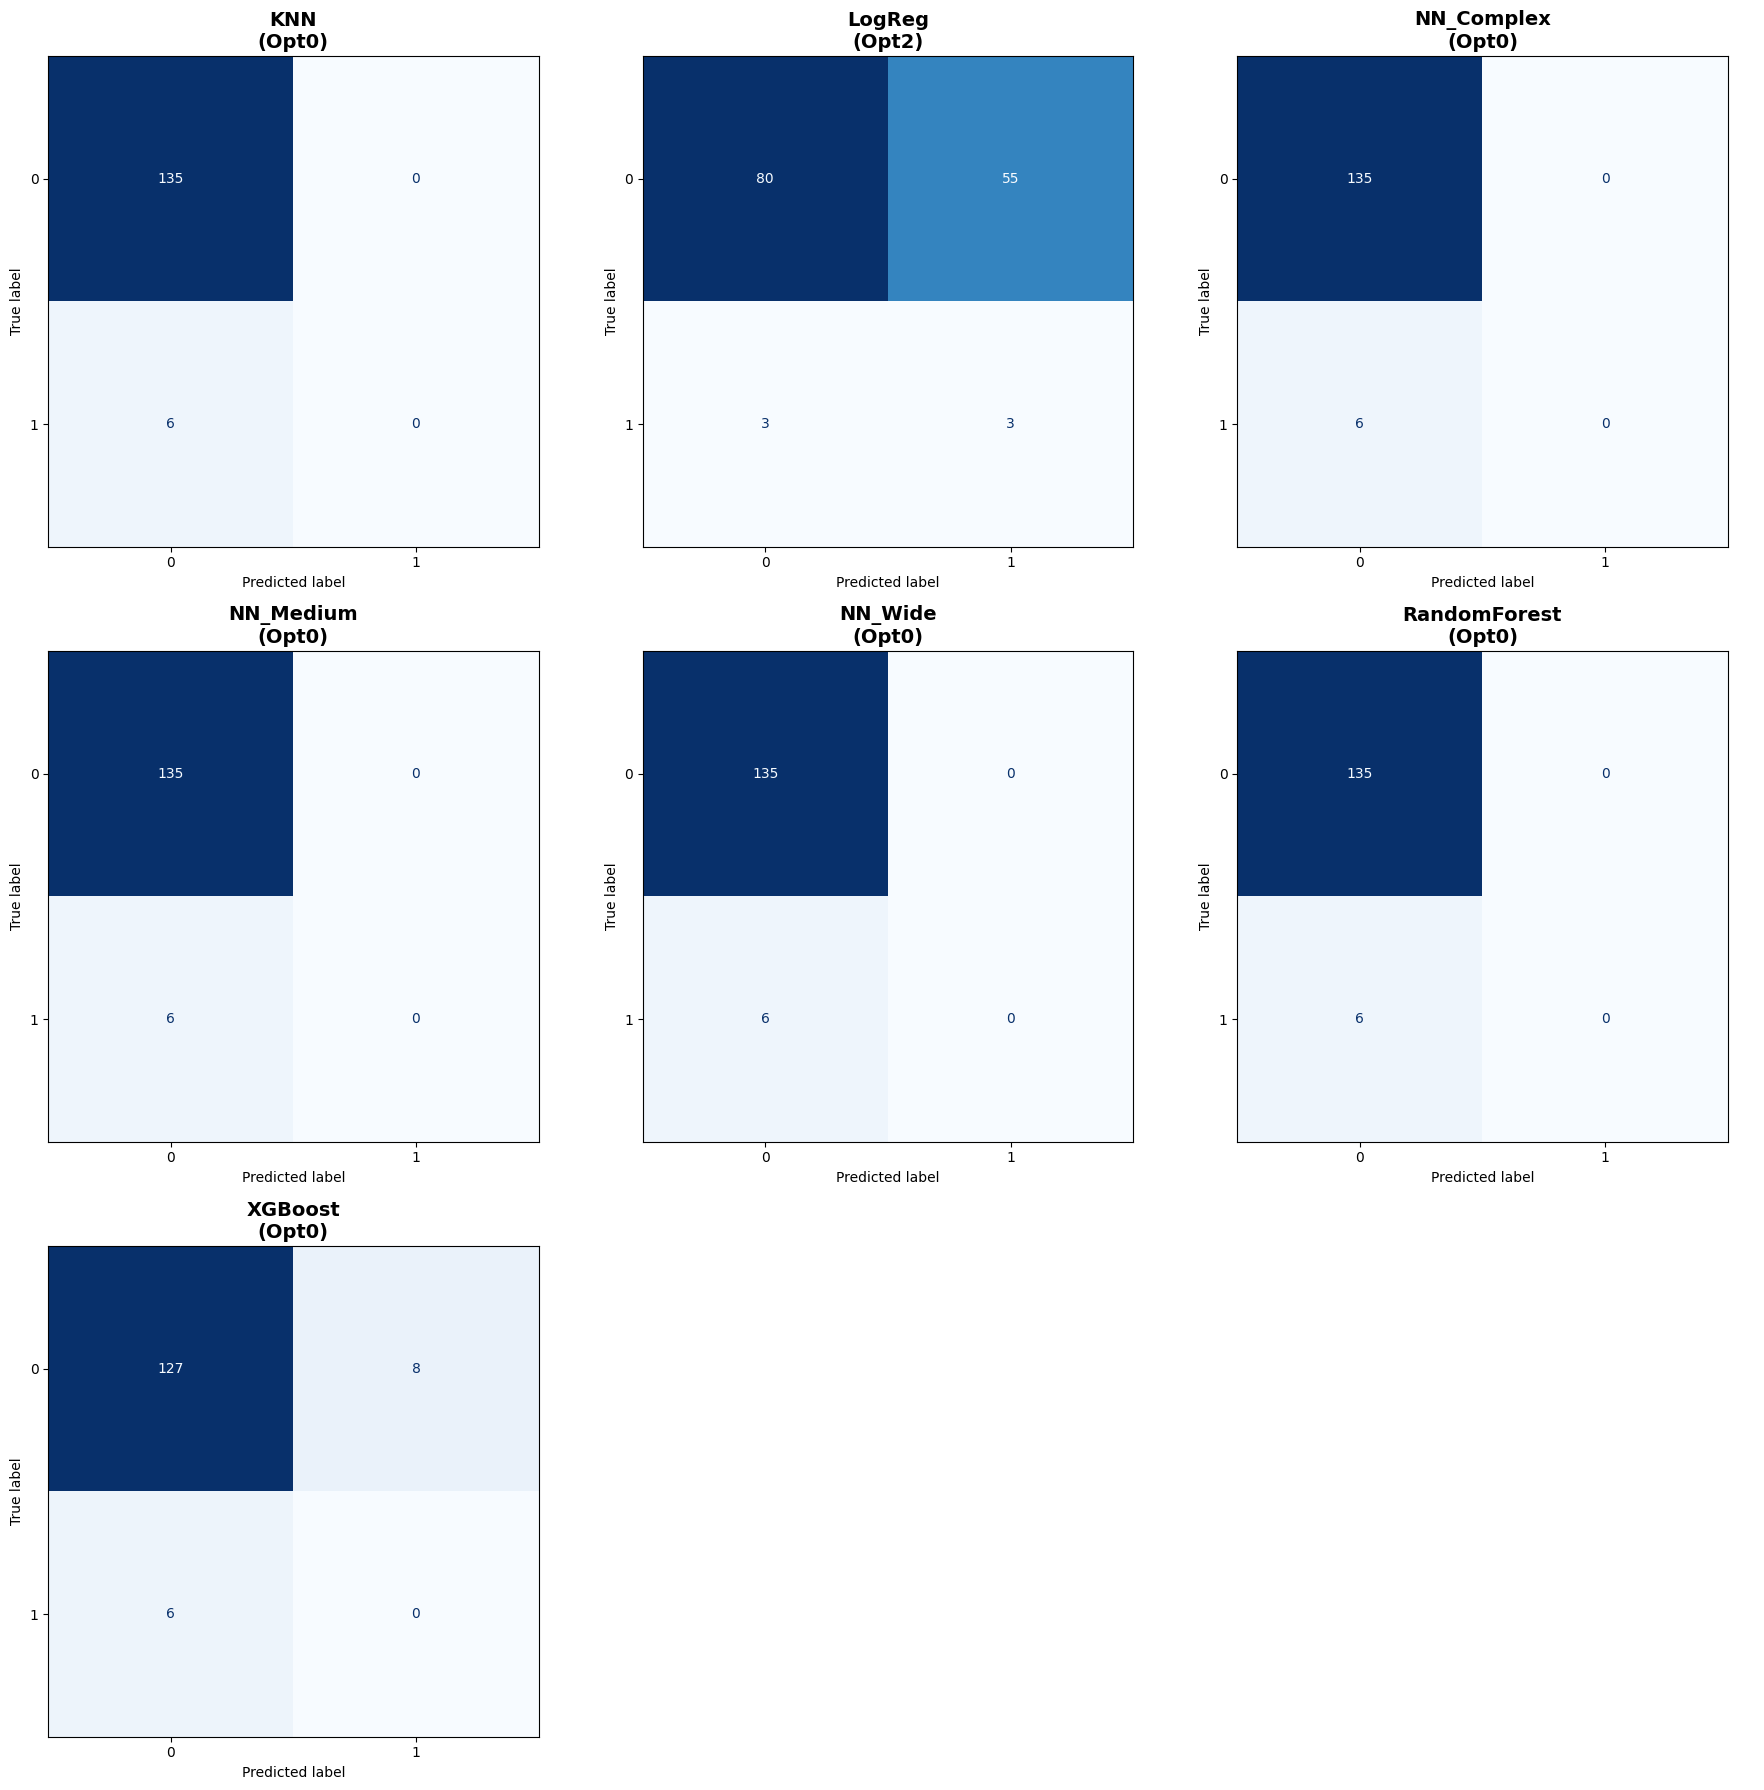


   >> Training Binary Models for: 'new-motor' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_NEW-MOTOR
📊 Target Column: 'is_new-motor'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0500
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0420
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 24)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 13)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9787 (Stopped at epoch 12)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0357
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0407
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 12)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 18)
   🧠 Training Neural Netwo

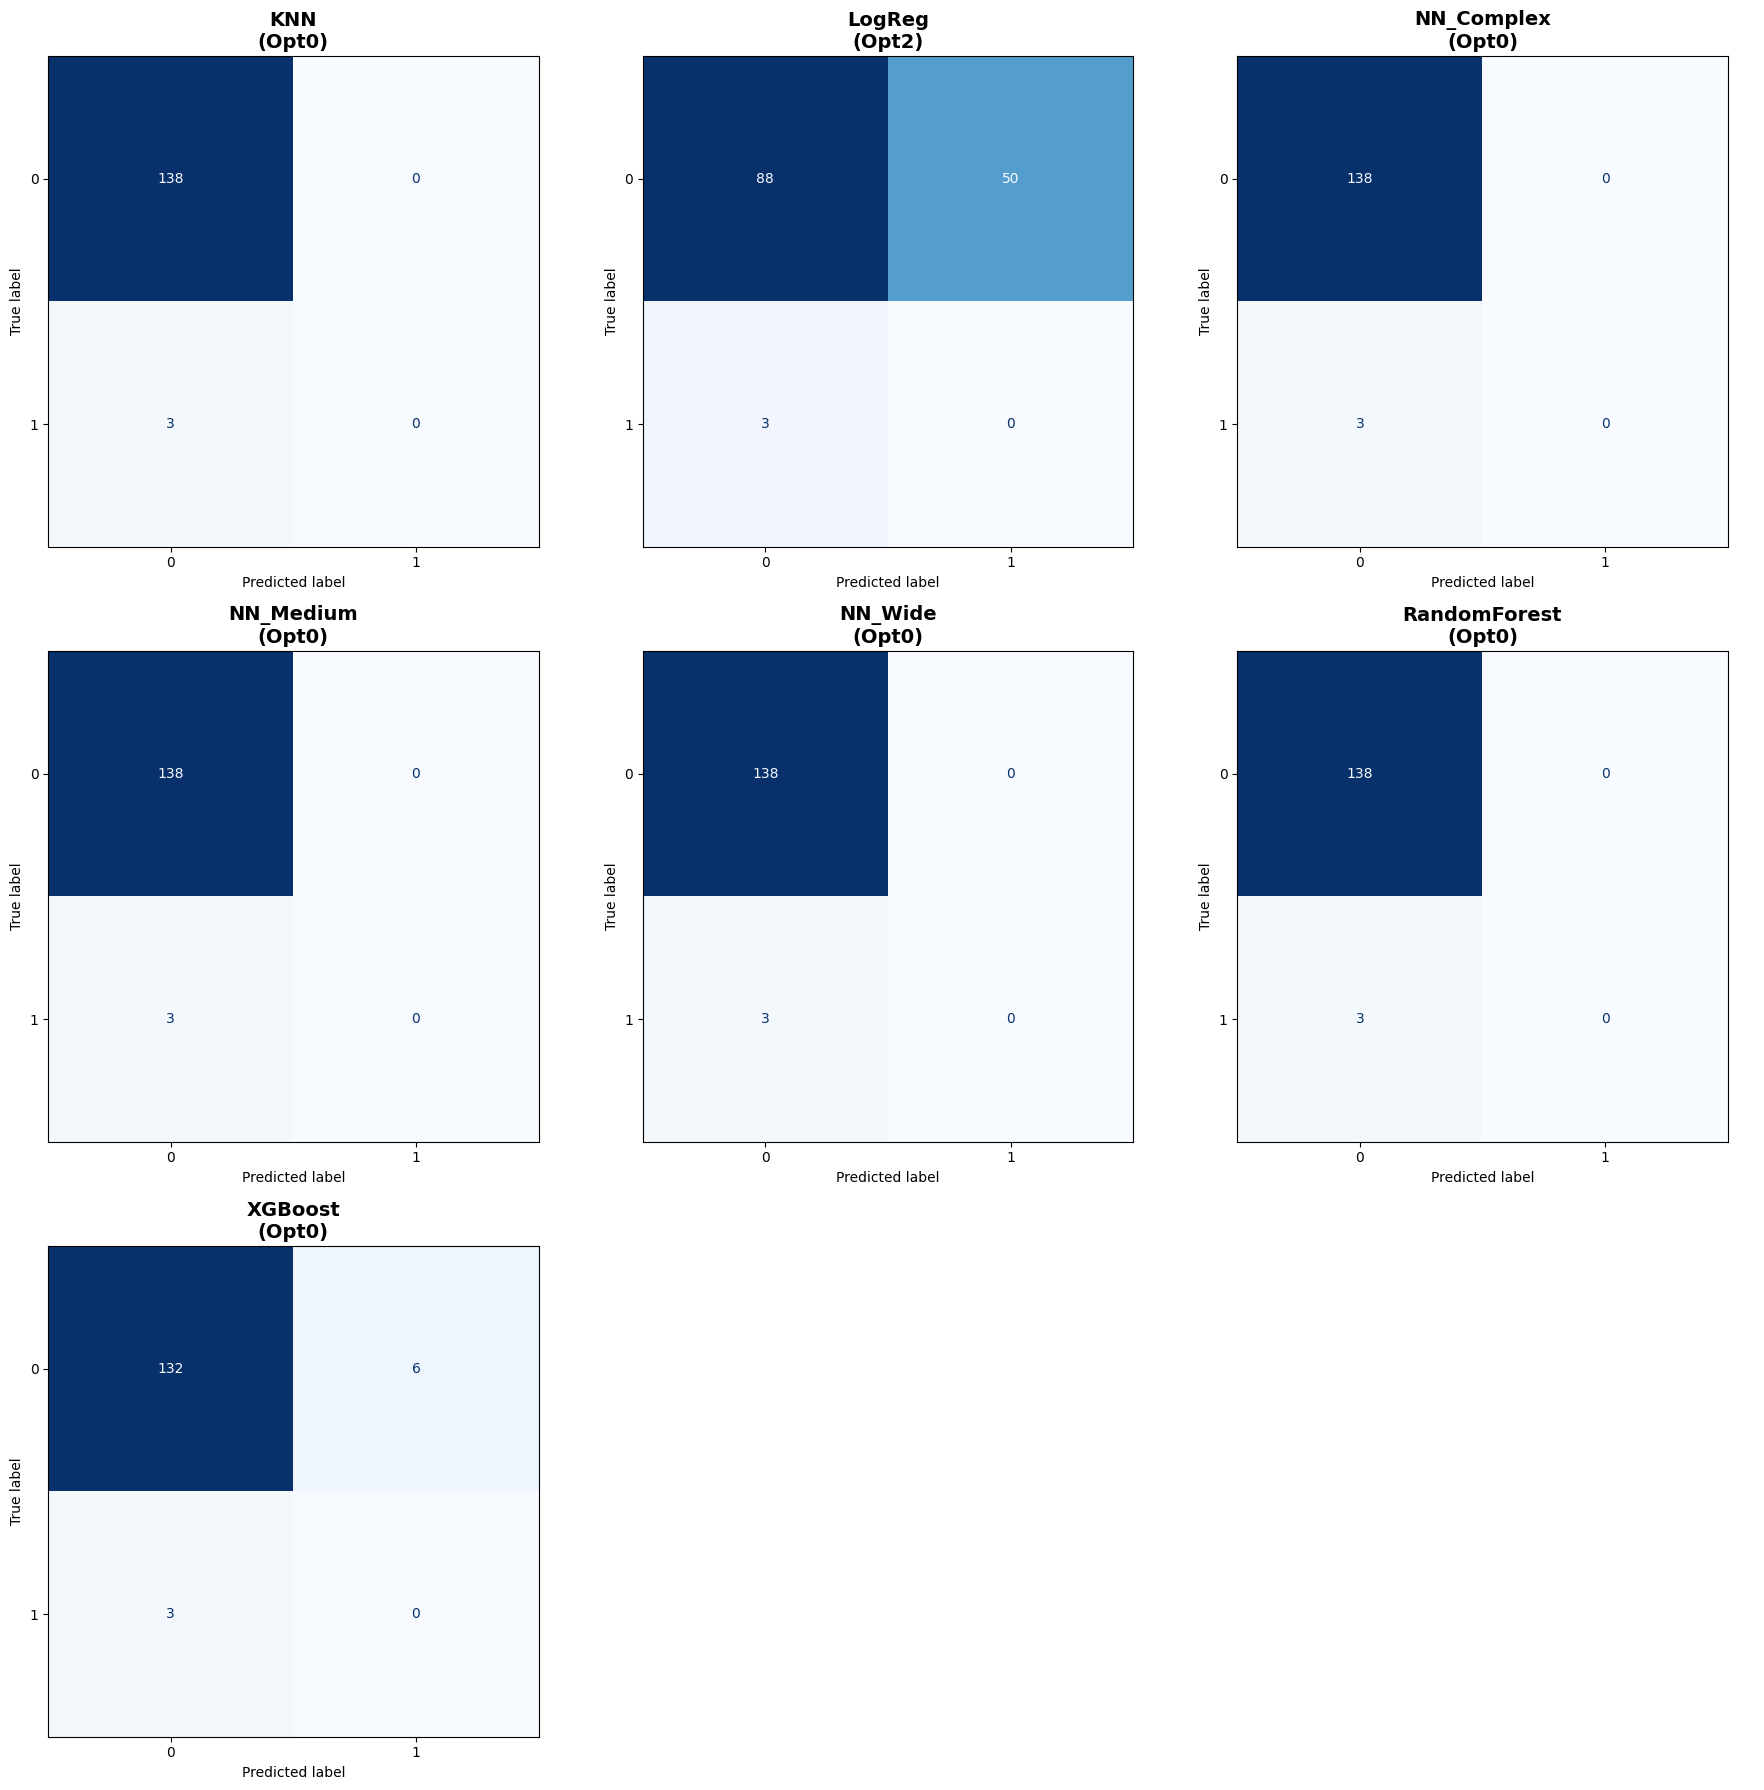


   >> Training Binary Models for: 'soft-foot' (Optimizing Precision)
      Imbalance Ratio: 1:18.5

🚀 START EXPERIMENT: DETECTION_SOFT-FOOT
📊 Target Column: 'is_soft-foot'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0582
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0655
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9504 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9504 (Stopped at epoch 20)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9504 (Stopped at epoch 20)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0459
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0640
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9504 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9504 (Stopped at epoch 21)
   🧠 Training Neural Netwo

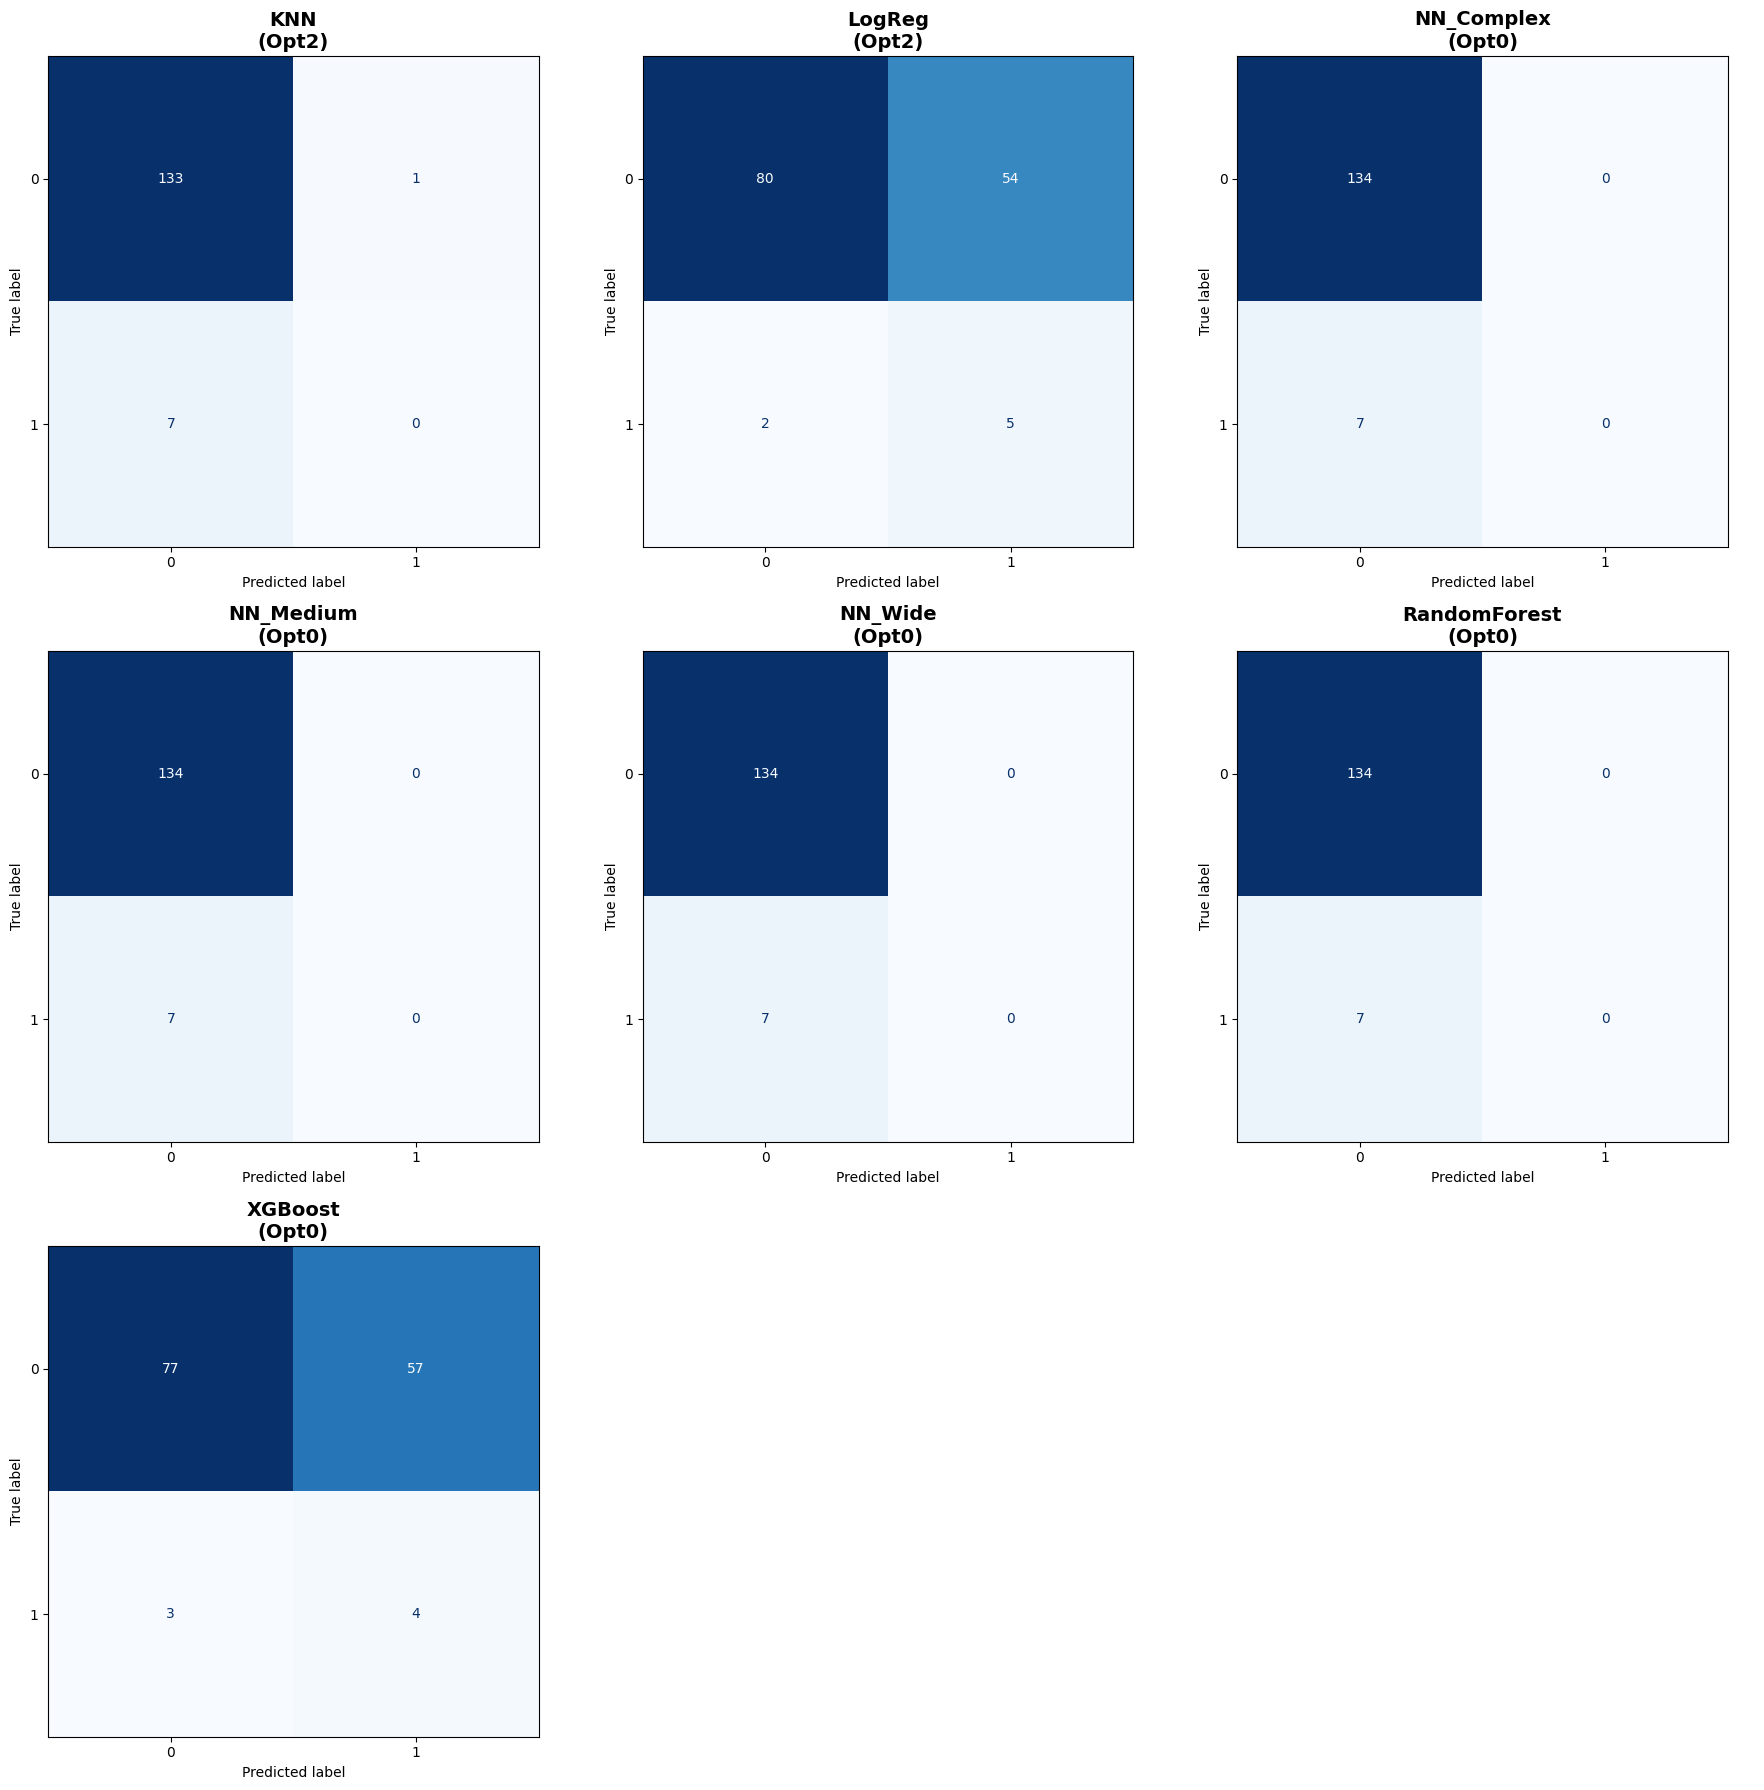


   >> Training Binary Models for: 'stator-short' (Optimizing Precision)
      Imbalance Ratio: 1:22.4

🚀 START EXPERIMENT: DETECTION_STATOR-SHORT
📊 Target Column: 'is_stator-short'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.3833
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0853
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 12)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9645 (Stopped at epoch 8)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.2000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0681
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 17)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 22)
   🧠 Training Neur

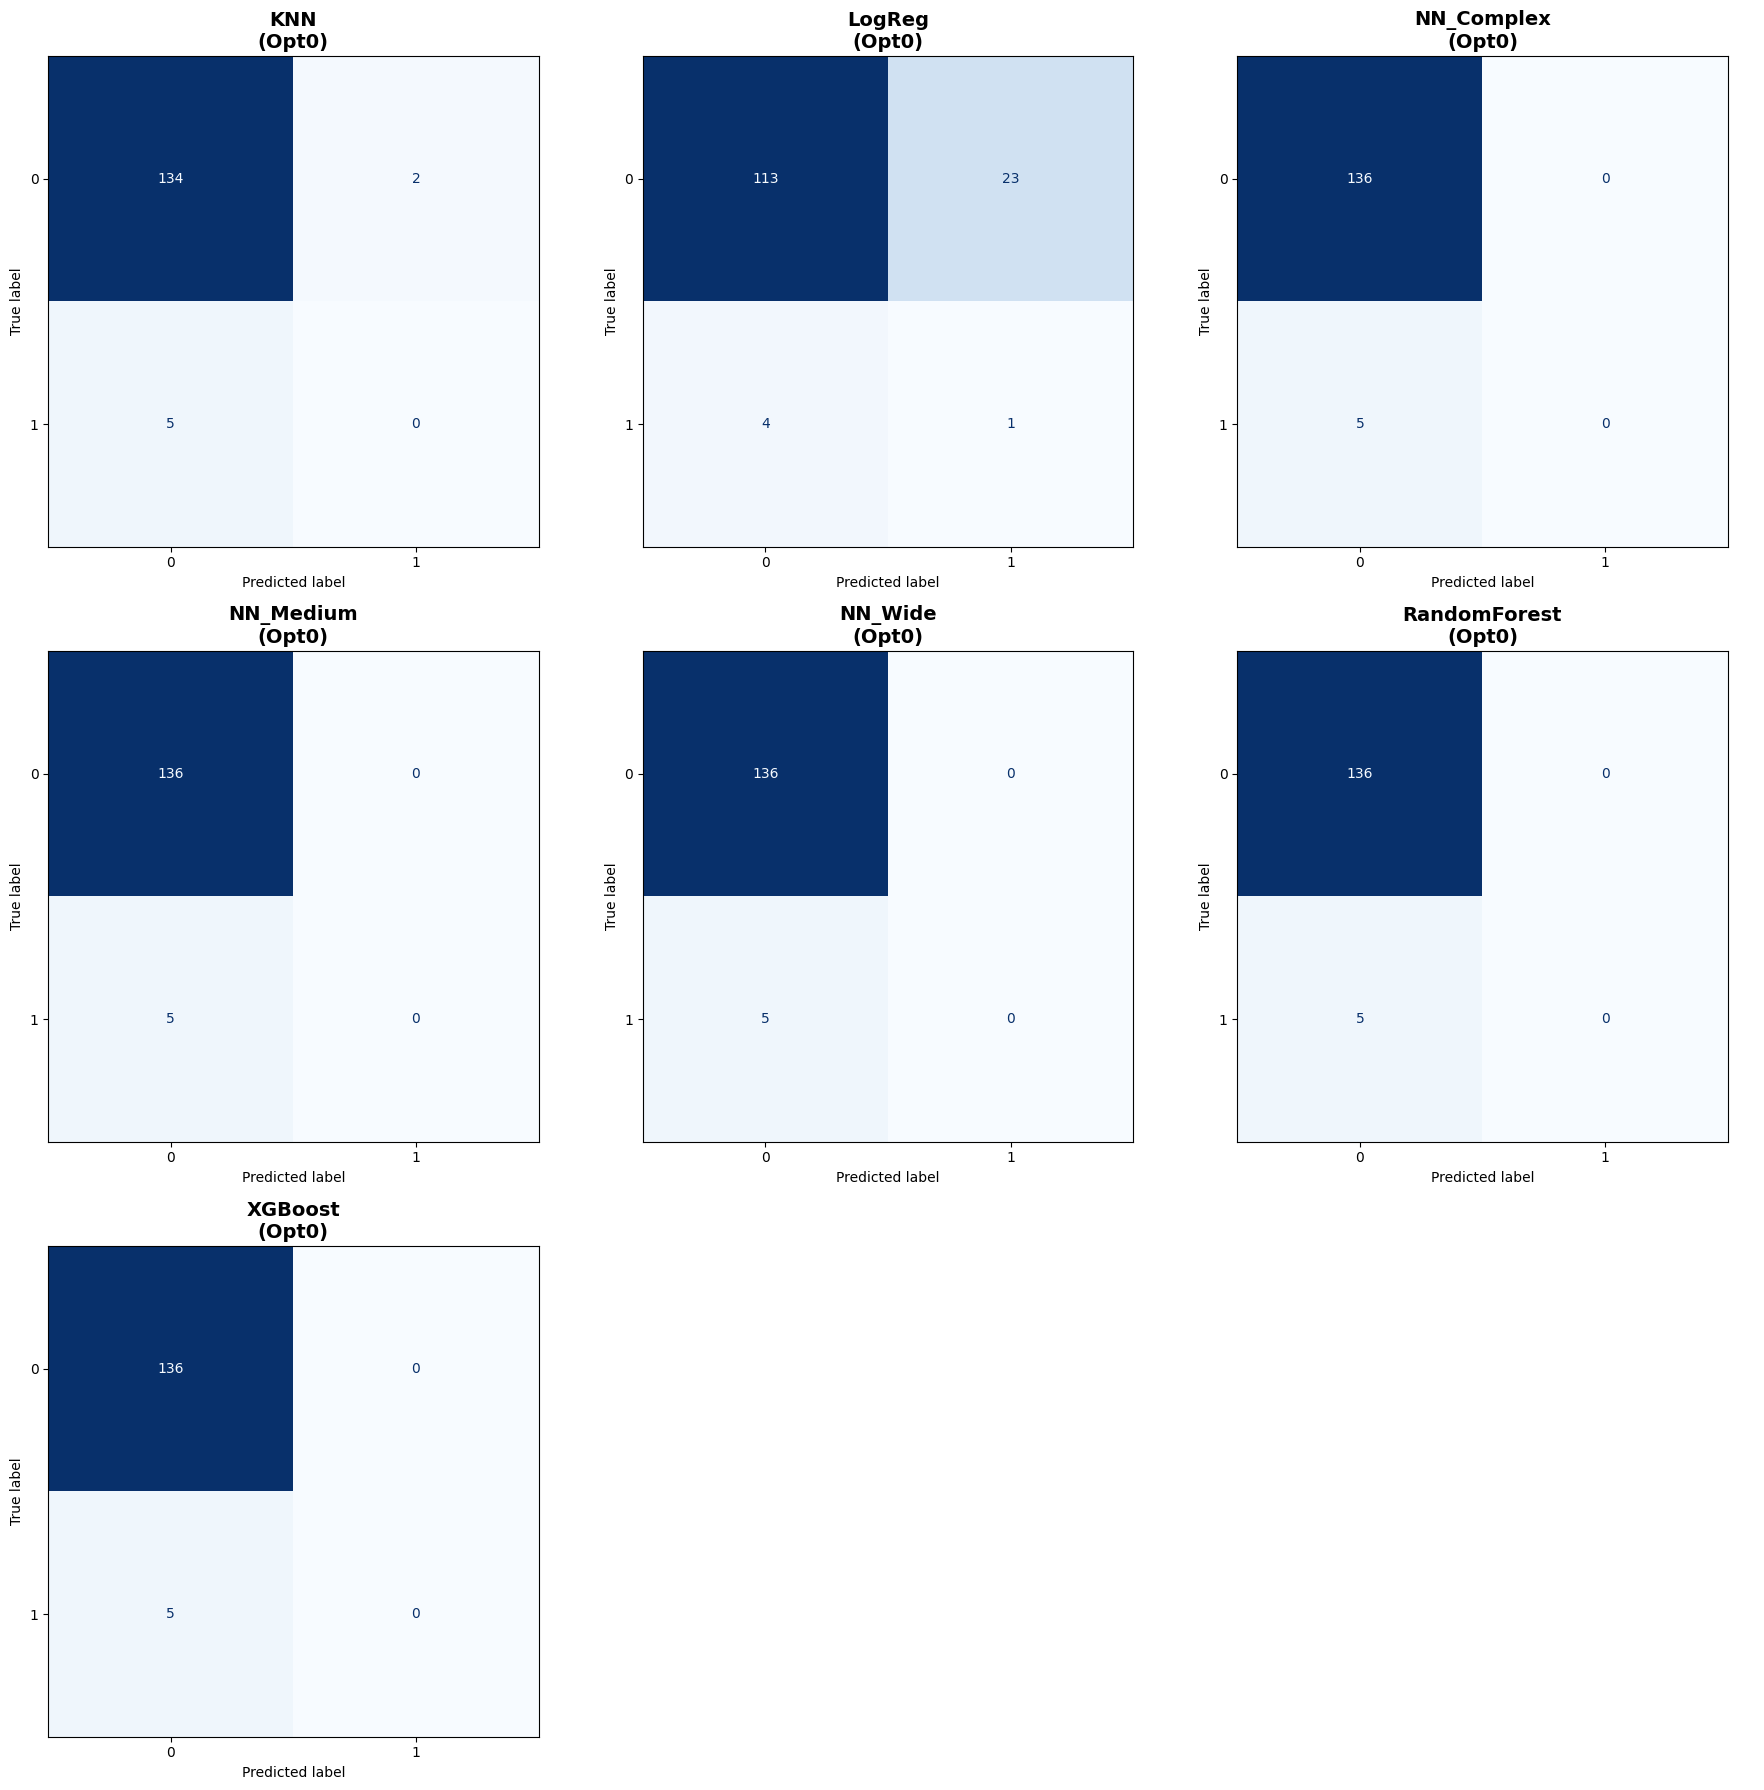


   >> Training Binary Models for: 'align-angular' (Optimizing Precision)
      Imbalance Ratio: 1:22.4

🚀 START EXPERIMENT: DETECTION_ALIGN-ANGULAR
📊 Target Column: 'is_align-angular'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.2200
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1316
   ✅ KNN: precision=0.1000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9716 (Stopped at epoch 6)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9716 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9716 (Stopped at epoch 10)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.2467
   ✅ RandomForest: precision=0.1833
   ✅ LogReg: precision=0.1376
   ✅ KNN: precision=0.3667
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9716 (Stopped at epoch 23)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9716 (Stopped at epoch 17)
   🧠 Training Ne

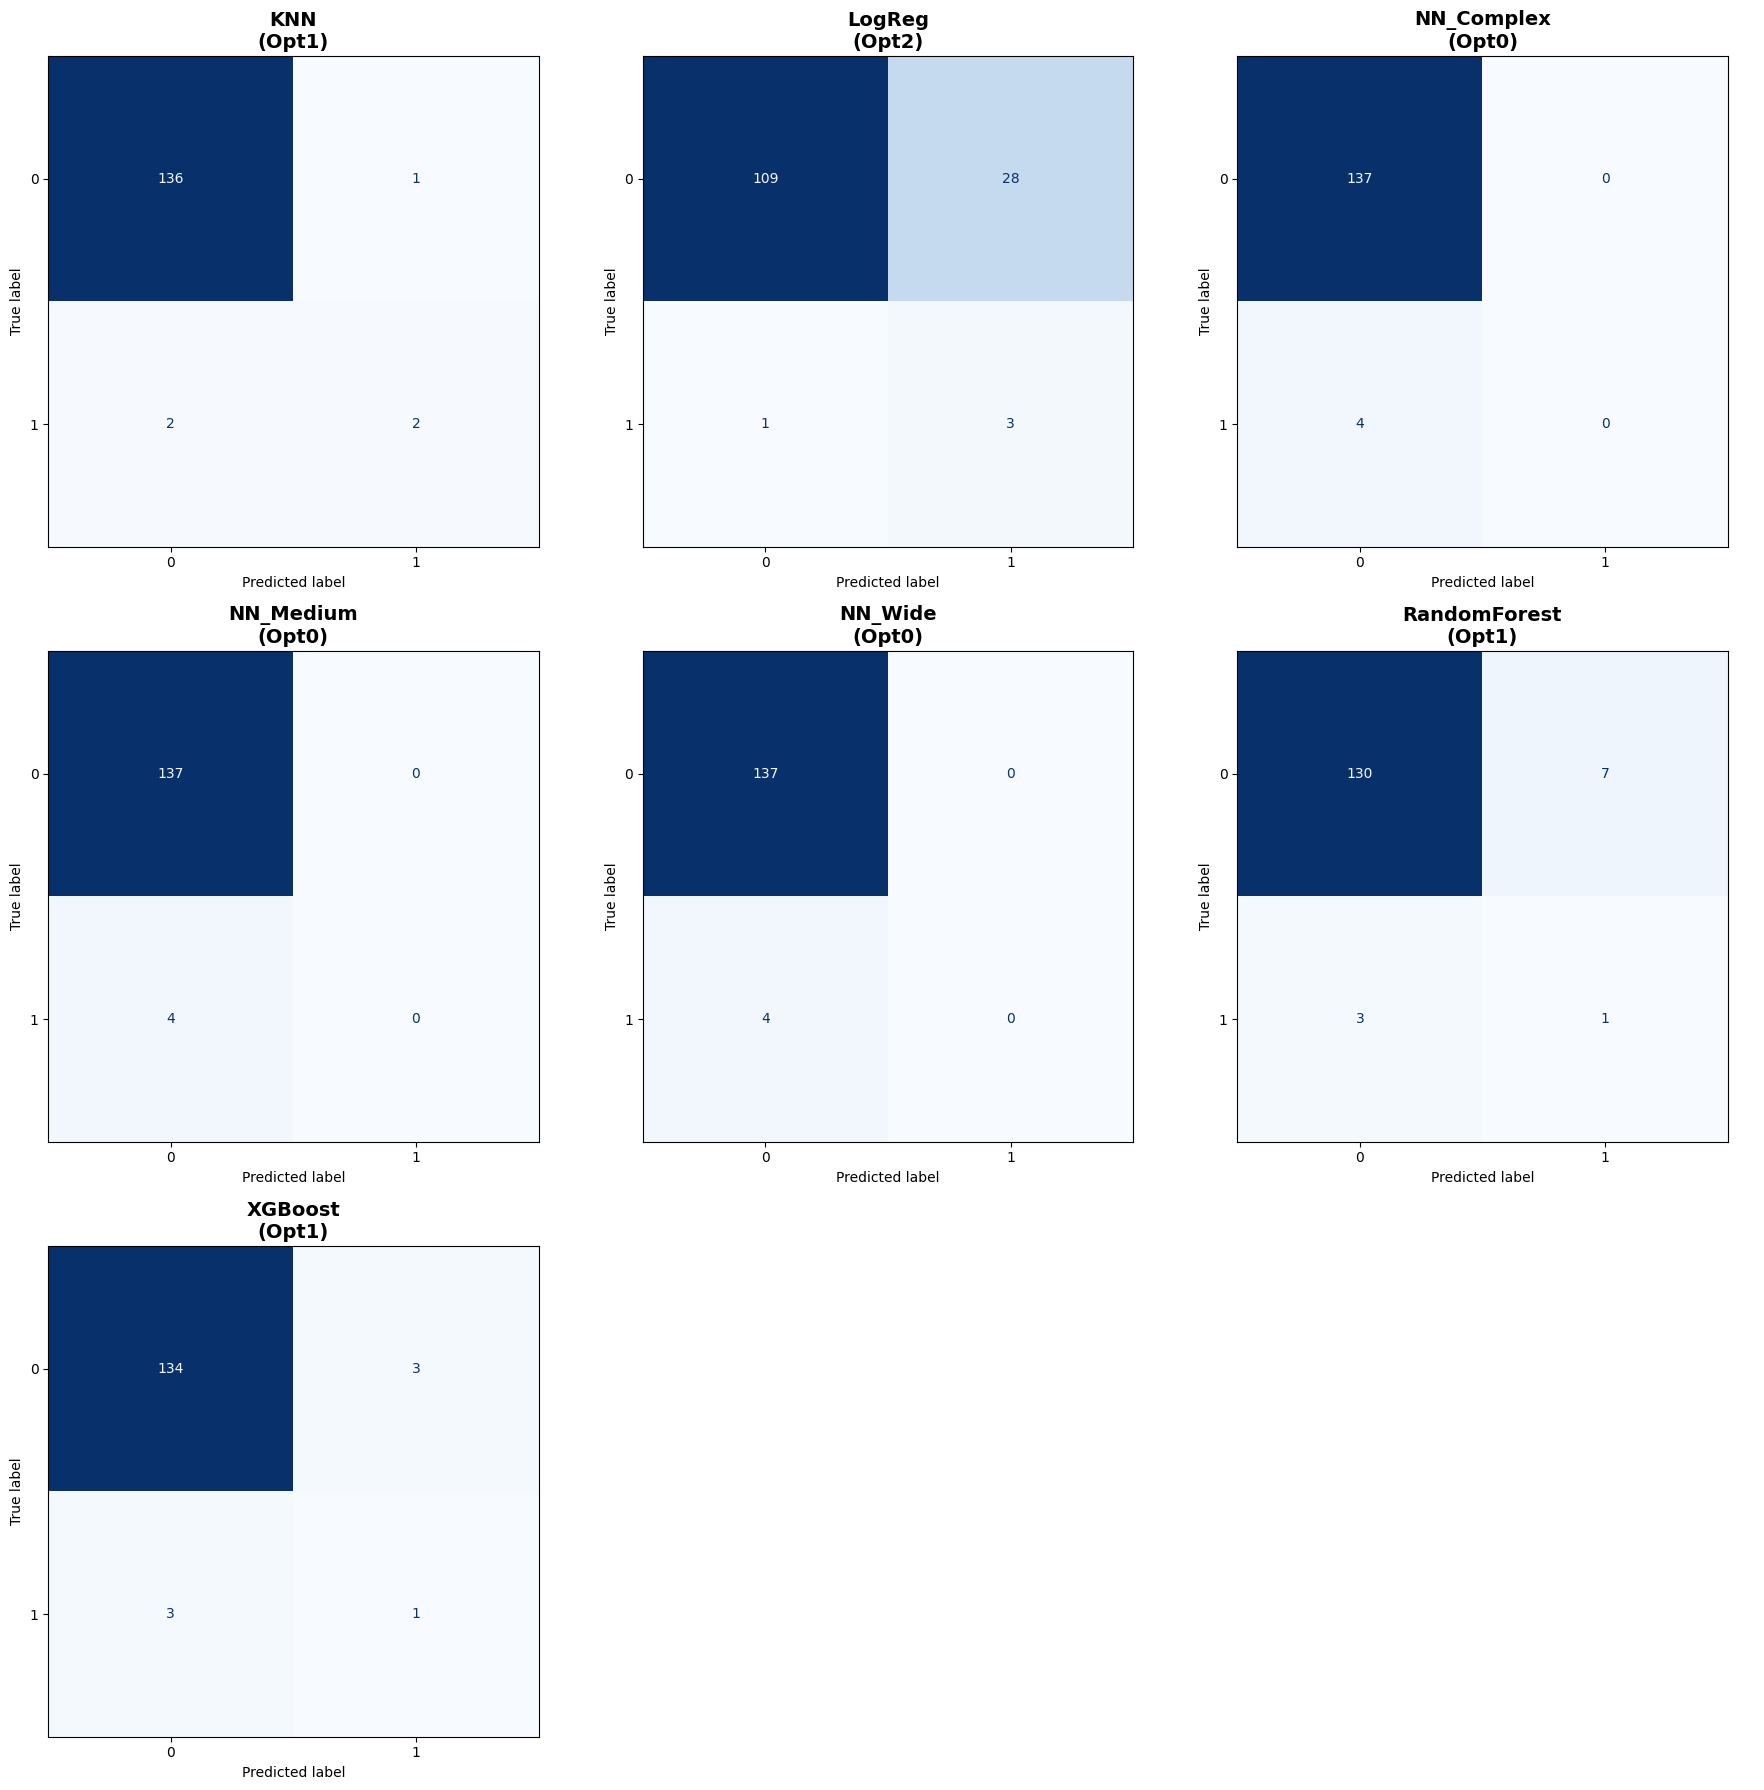


   >> Training Binary Models for: 'align-combination' (Optimizing Precision)
      Imbalance Ratio: 1:28.2

🚀 START EXPERIMENT: DETECTION_ALIGN-COMBINATION
📊 Target Column: 'is_align-combination'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.2150
   ✅ RandomForest: precision=0.3000
   ✅ LogReg: precision=0.0922
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 17)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 17)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9645 (Stopped at epoch 8)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1650
   ✅ RandomForest: precision=0.1238
   ✅ LogReg: precision=0.0993
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 19)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 27)
   

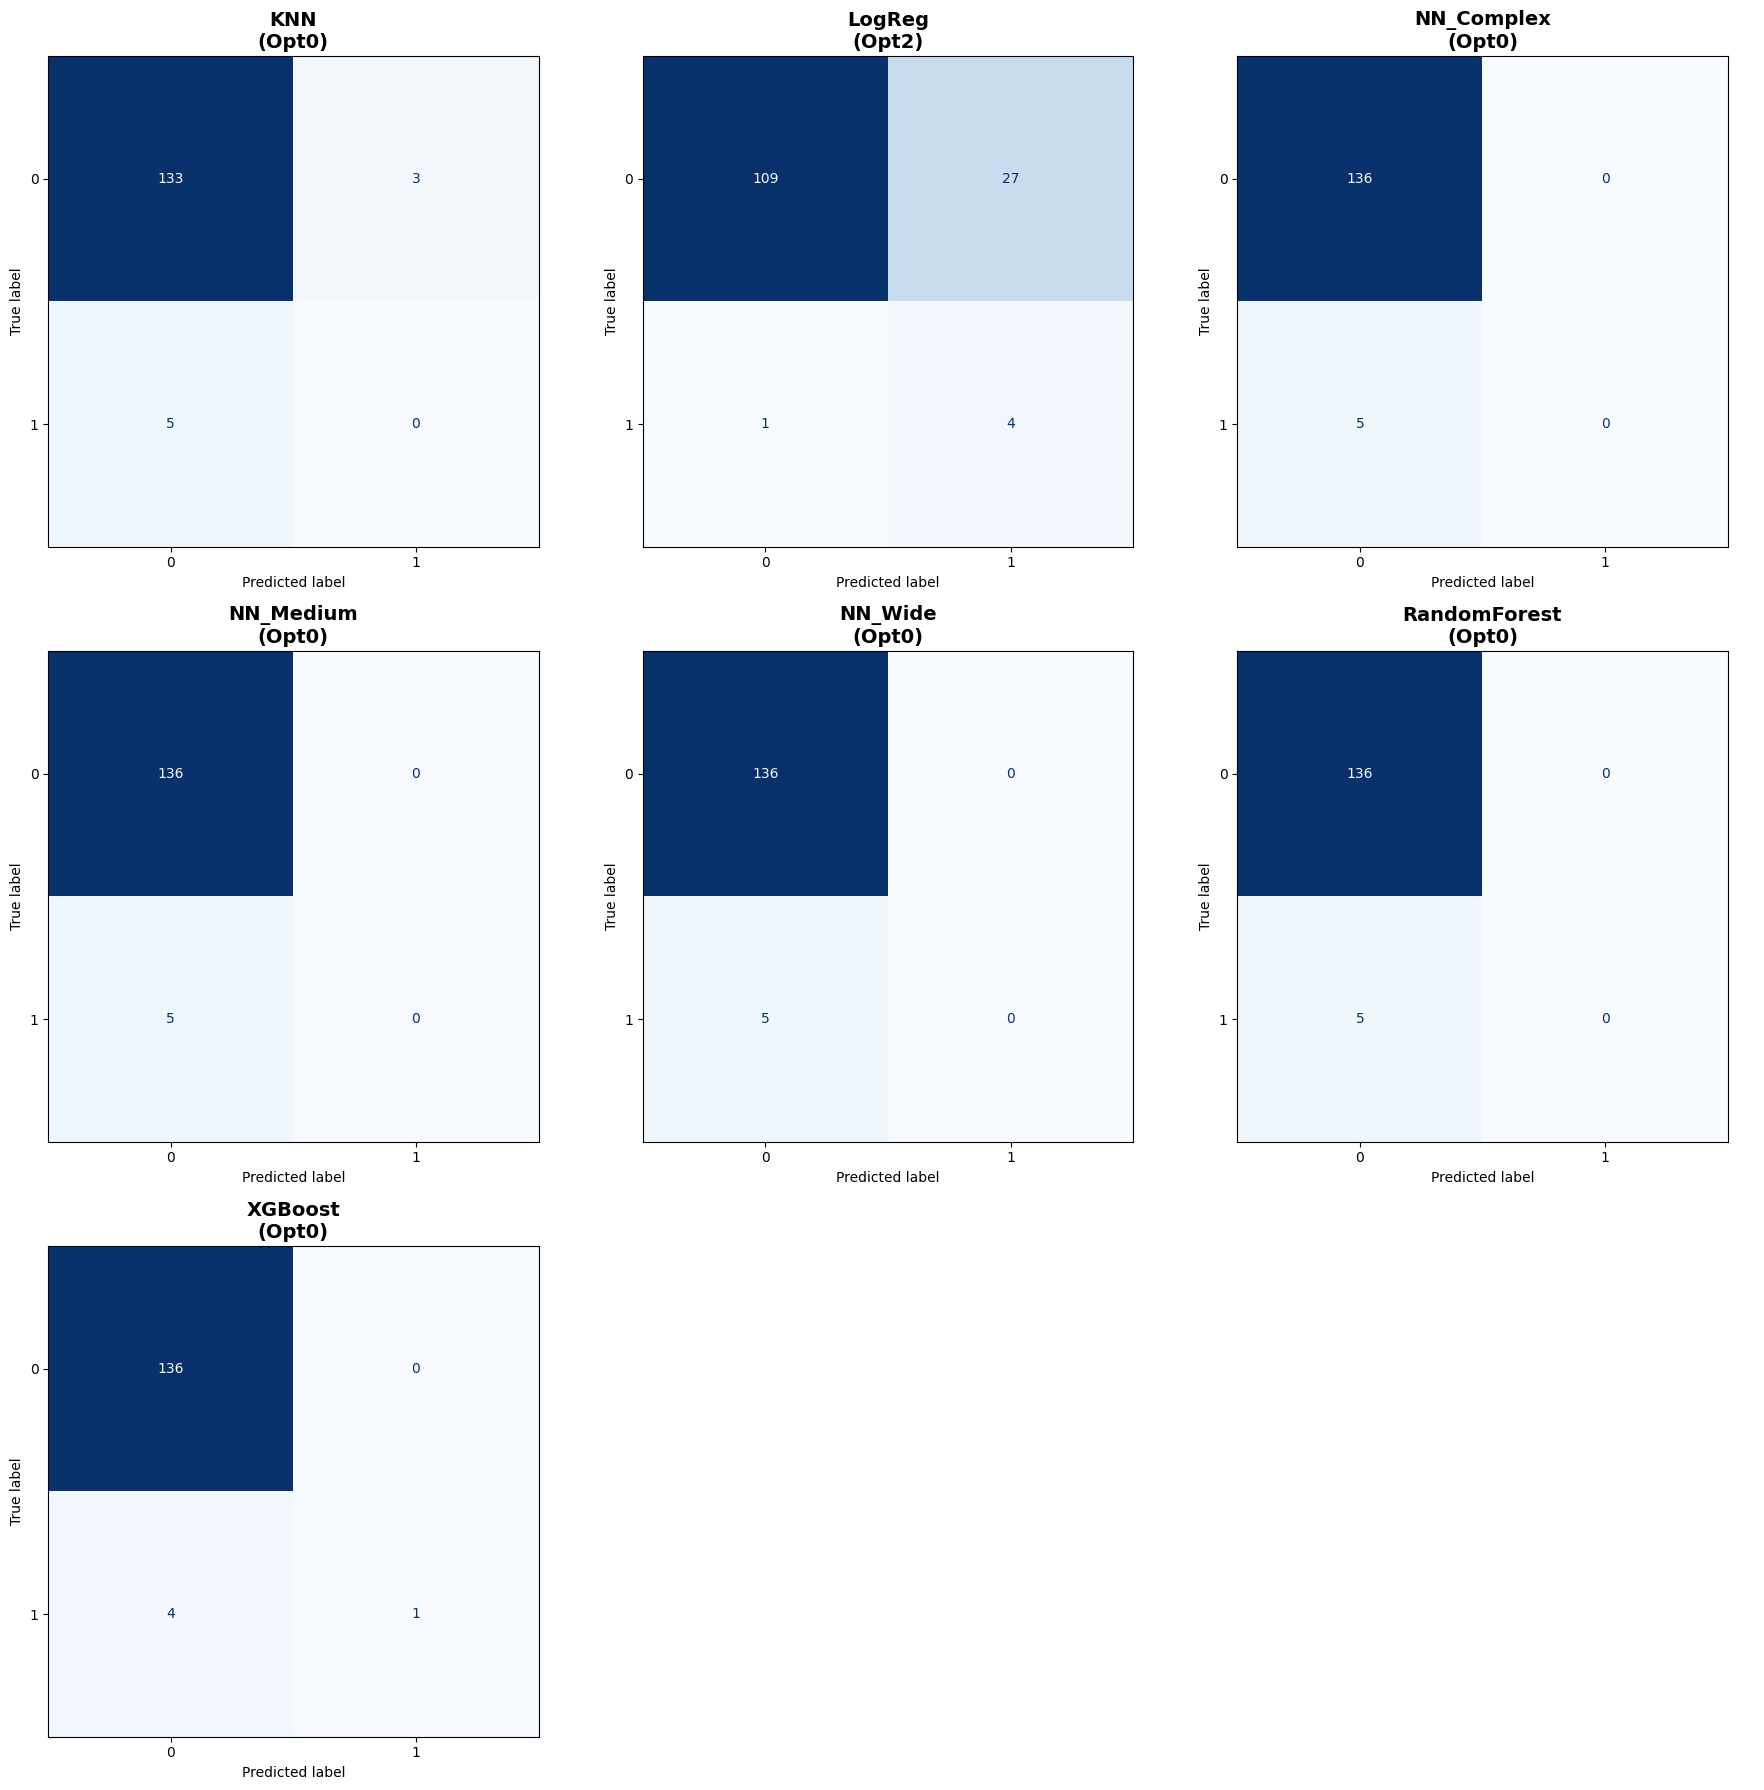


   >> Training Binary Models for: 'align-parallel' (Optimizing Precision)
      Imbalance Ratio: 1:28.2

🚀 START EXPERIMENT: DETECTION_ALIGN-PARALLEL
📊 Target Column: 'is_align-parallel'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0750
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0668
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9645 (Stopped at epoch 6)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1667
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0986
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 16)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 8)
   🧠 Training N

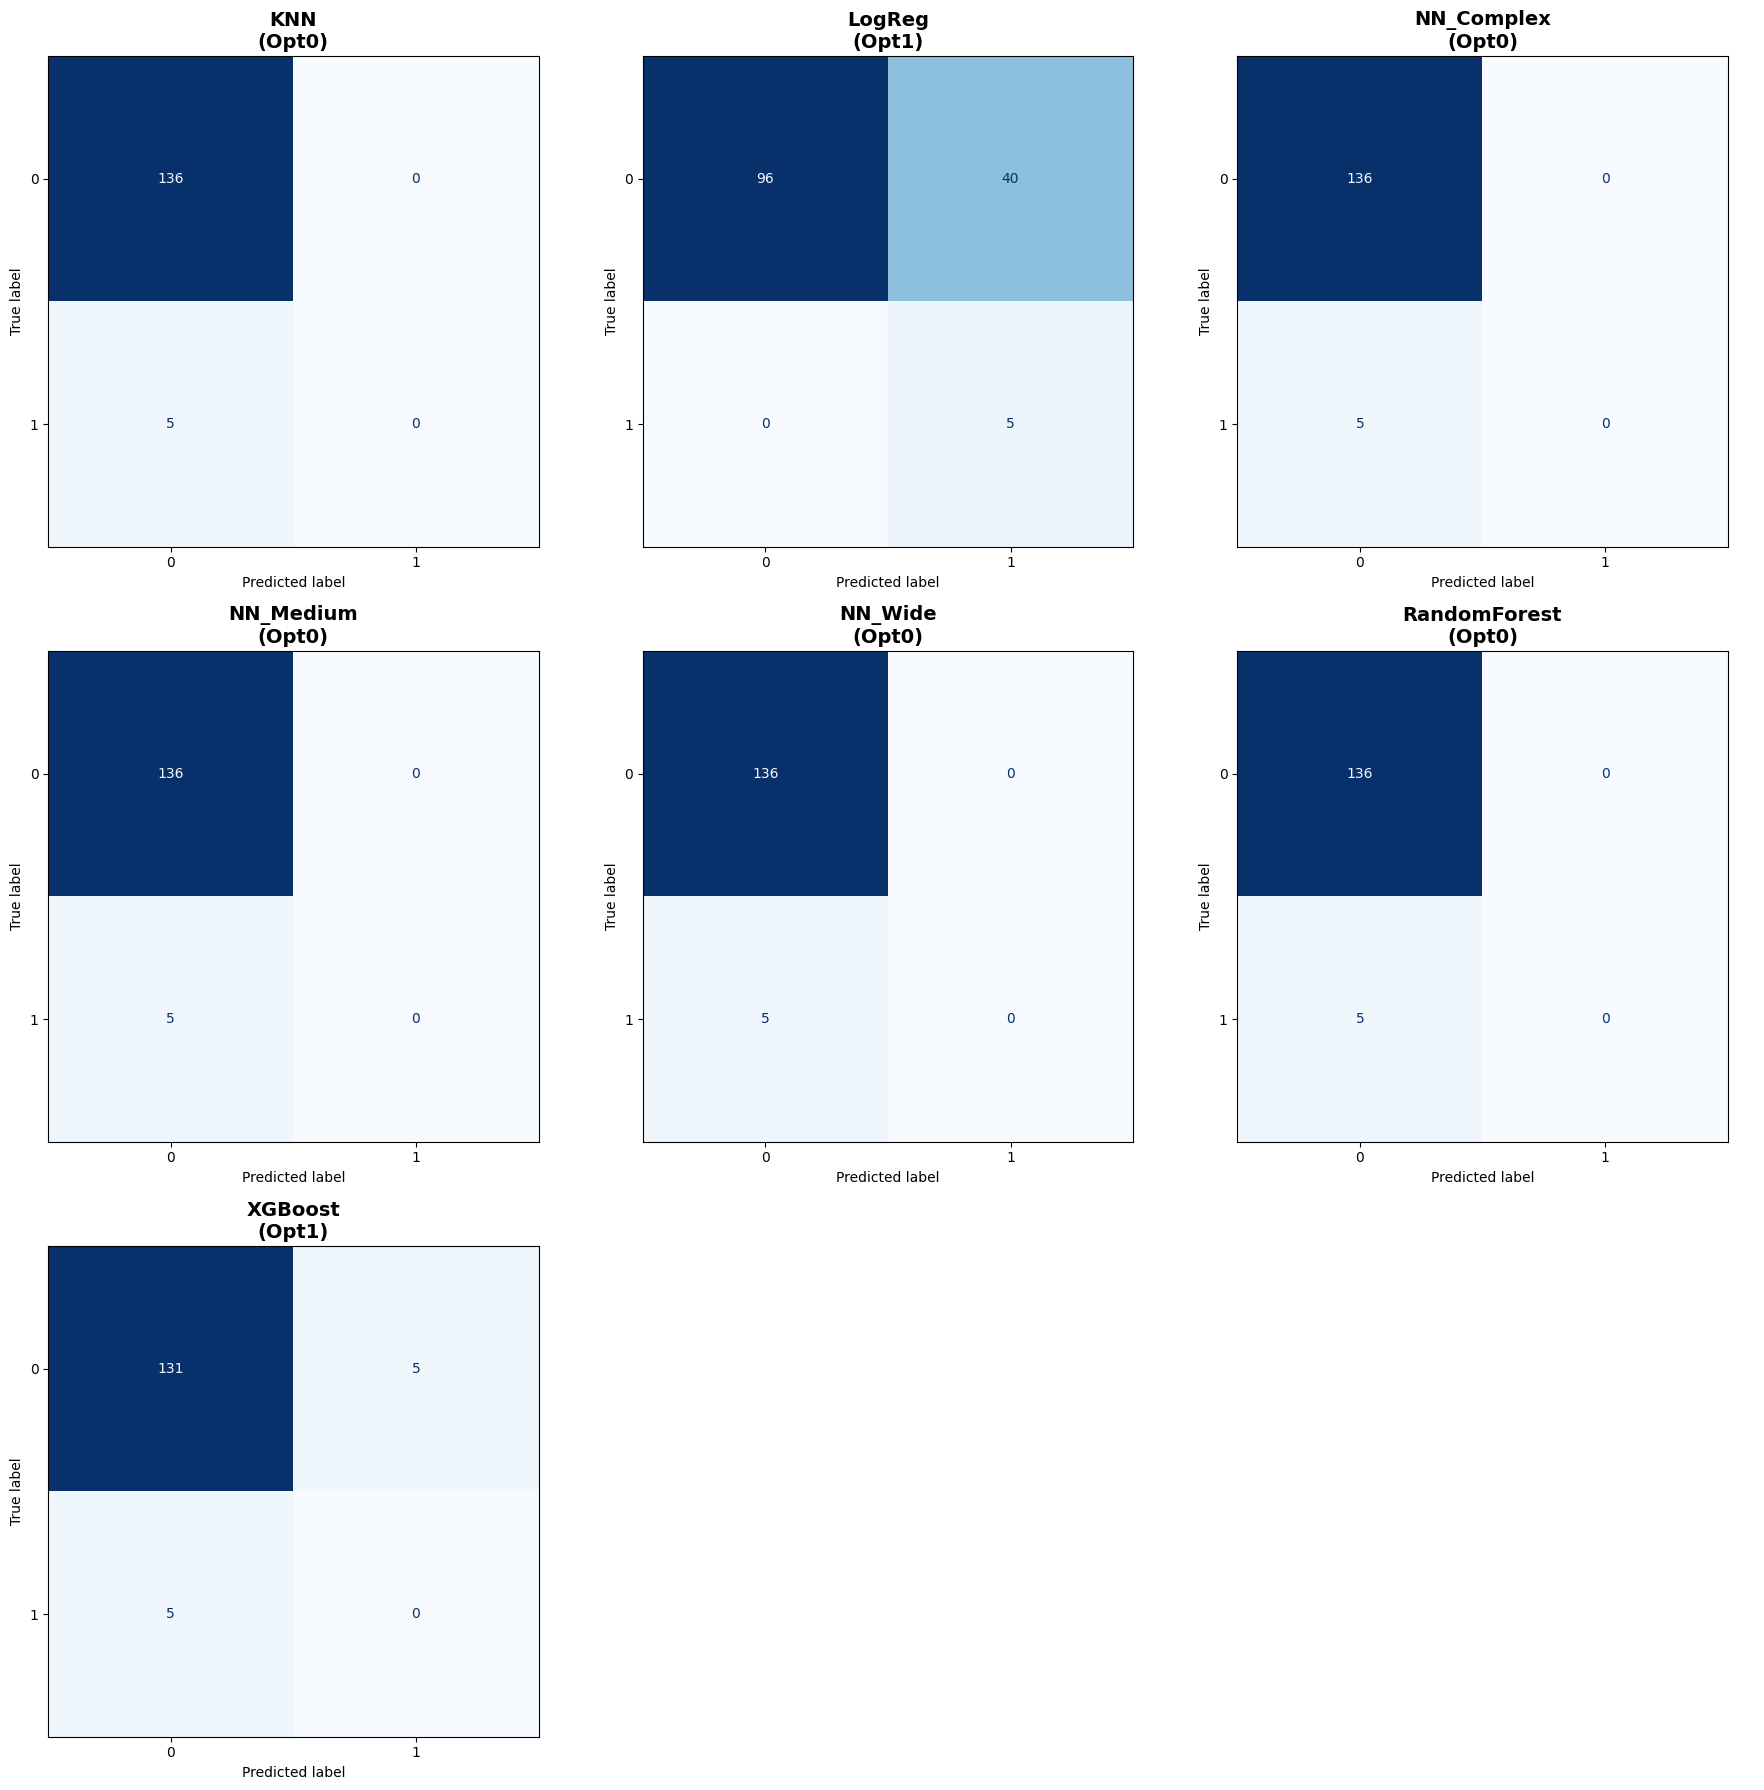


   >> Training Binary Models for: 'bent-shaft' (Optimizing Precision)
      ⚠️ Skipping bent-shaft: Too few positive samples (6)

   >> Training Binary Models for: 'cavitation-discharge' (Optimizing Precision)
      Imbalance Ratio: 1:22.4

🚀 START EXPERIMENT: DETECTION_CAVITATION-DISCHARGE
📊 Target Column: 'is_cavitation-discharge'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.4333
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.3256
   ✅ KNN: precision=0.5000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9645 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9645 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9645 (Stopped at epoch 9)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4733
   ✅ RandomForest: precision=0.6000
   ✅ LogReg: precision=0.1415
   ✅ KNN: precision=0.3667
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: a

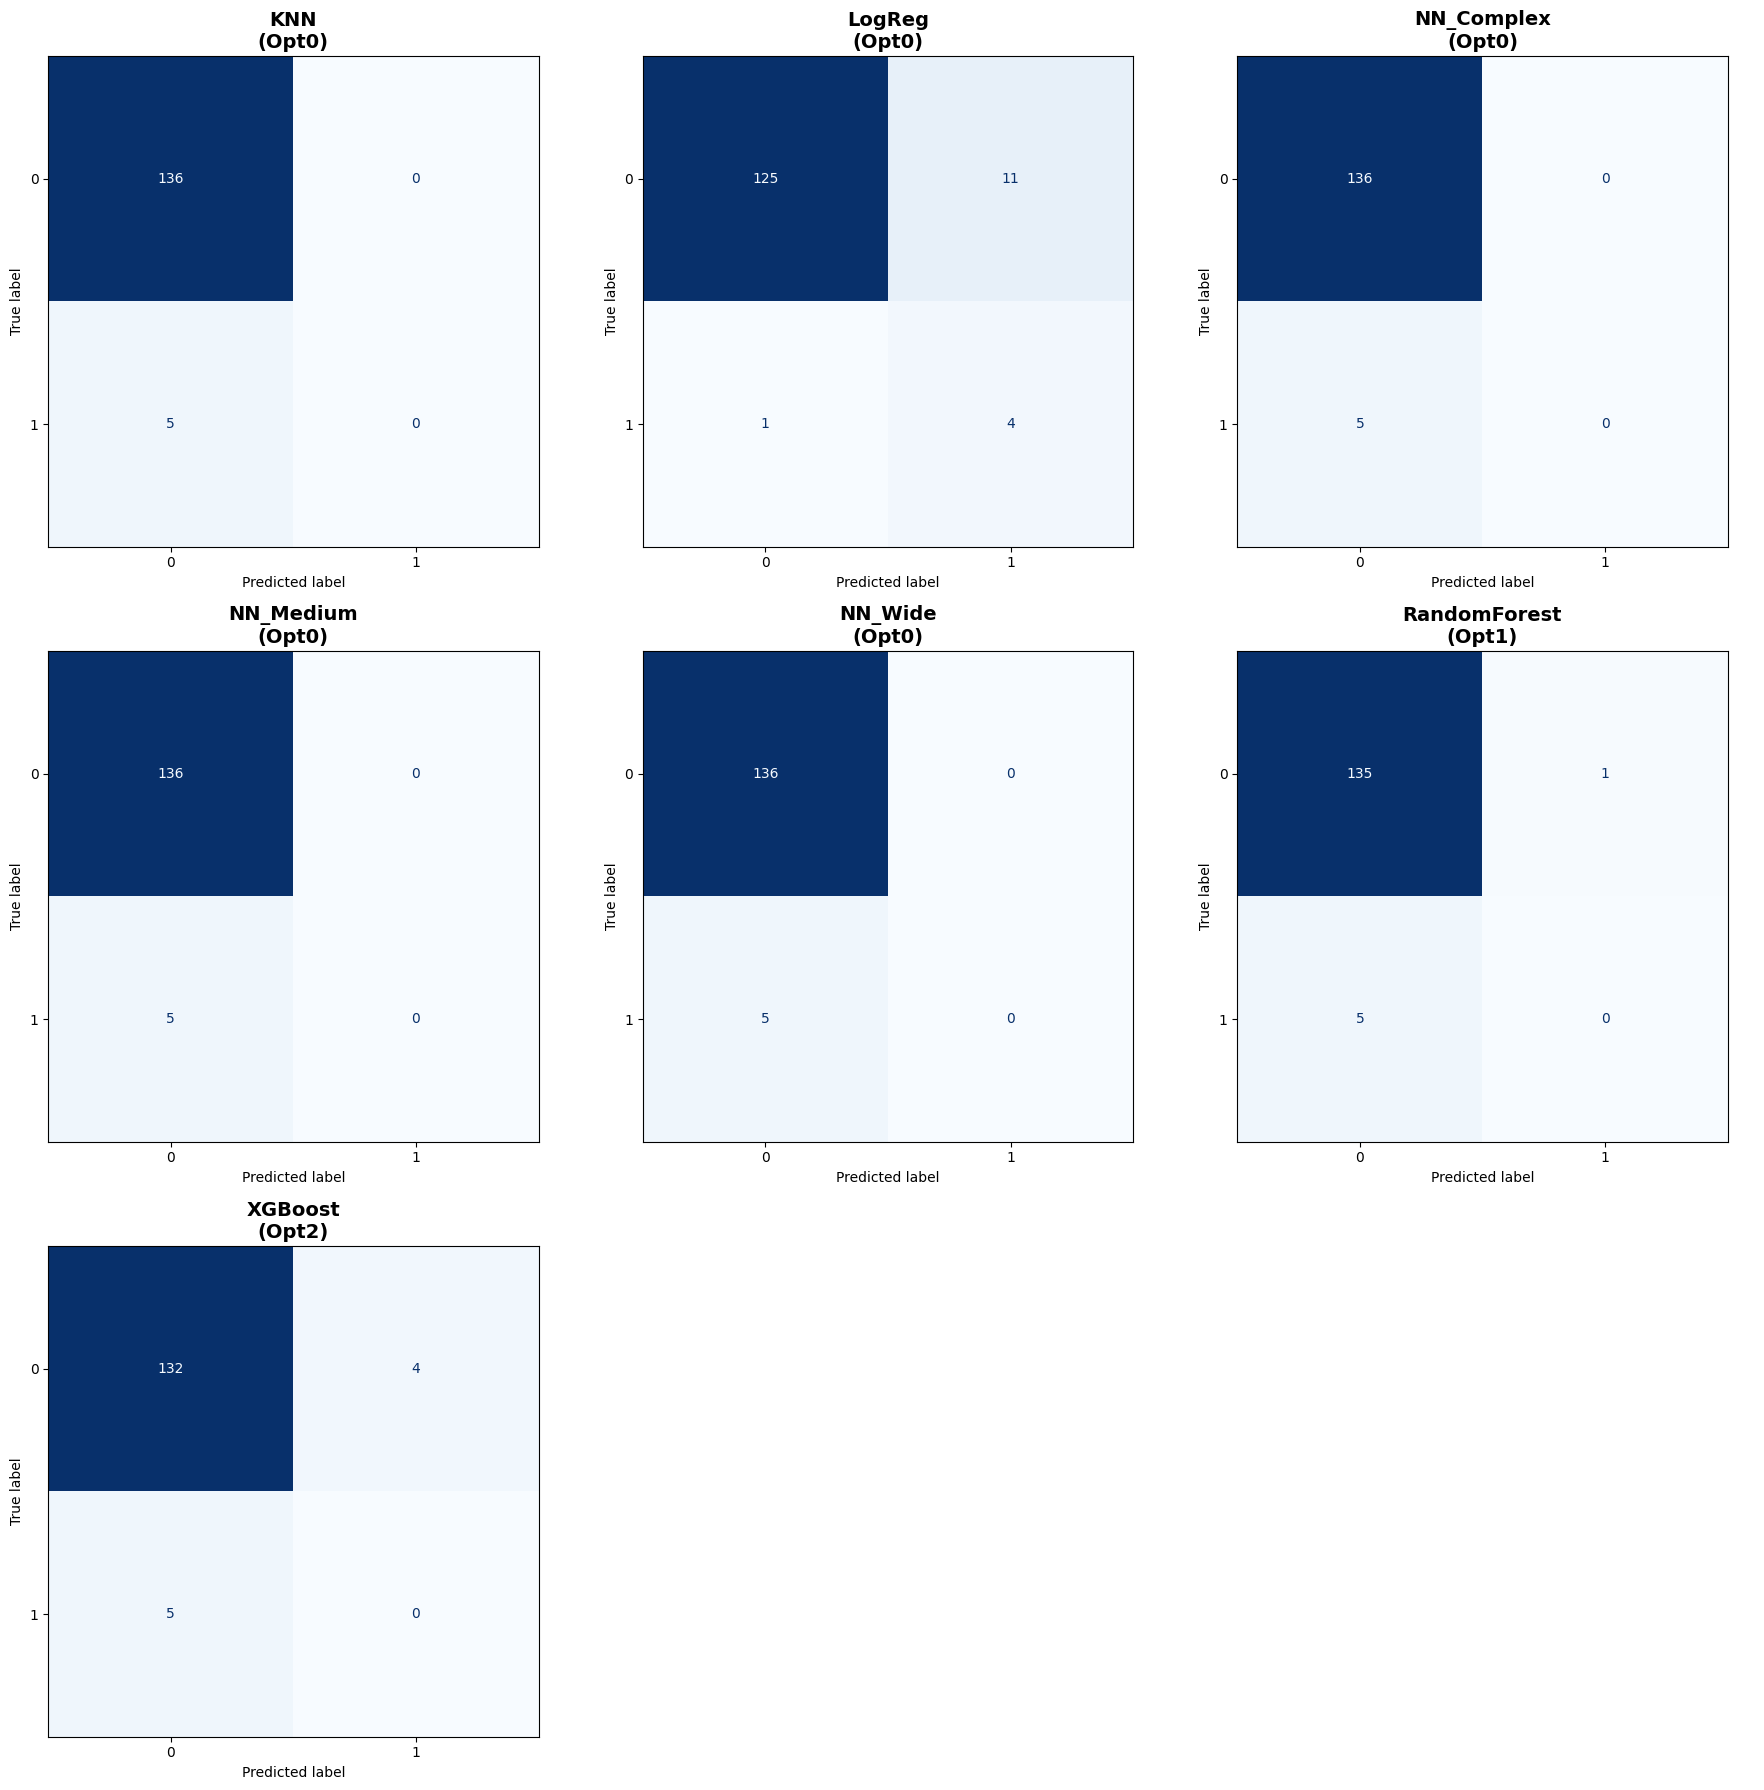


   >> Training Binary Models for: 'cavitation-suction' (Optimizing Precision)
      Imbalance Ratio: 1:28.2

🚀 START EXPERIMENT: DETECTION_CAVITATION-SUCTION
📊 Target Column: 'is_cavitation-suction'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.3000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0826
   ✅ KNN: precision=0.4667
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9574 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9574 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9574 (Stopped at epoch 6)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1833
   ✅ RandomForest: precision=0.1000
   ✅ LogReg: precision=0.0939
   ✅ KNN: precision=0.6000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9574 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9574 (Stopped at epoch 8)
   🧠

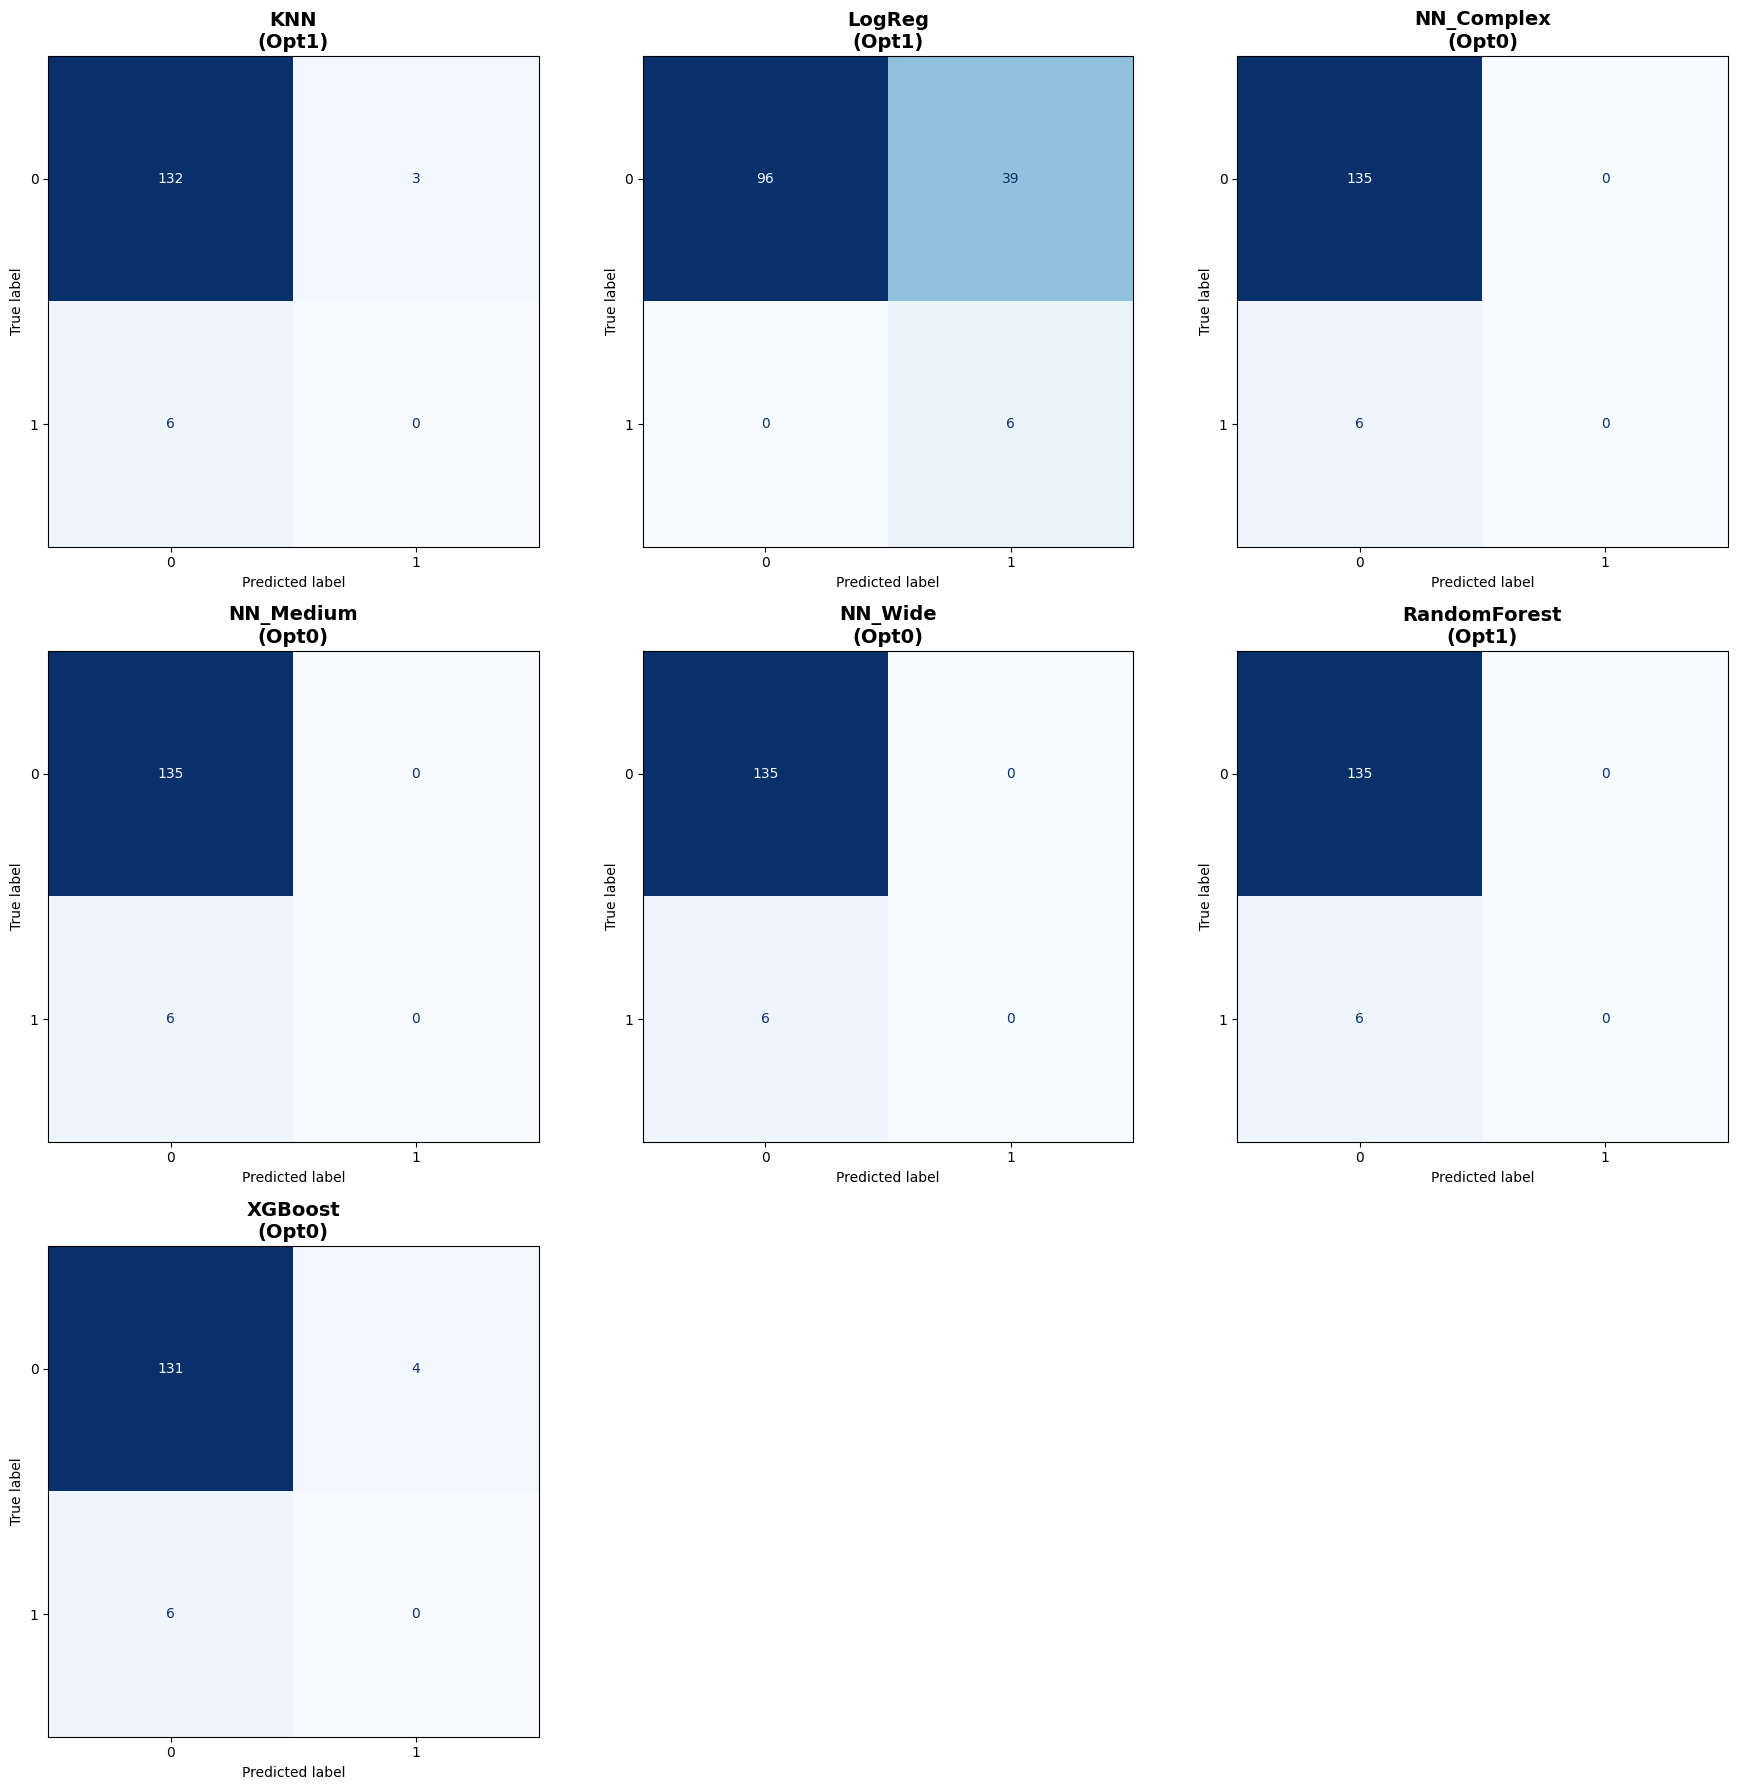


   >> Training Binary Models for: 'coupling' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_COUPLING
📊 Target Column: 'is_coupling'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.1118
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0858
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9858 (Stopped at epoch 17)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9858 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9858 (Stopped at epoch 7)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0820
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0840
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9858 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9858 (Stopped at epoch 16)
   🧠 Training Neural Network: NN

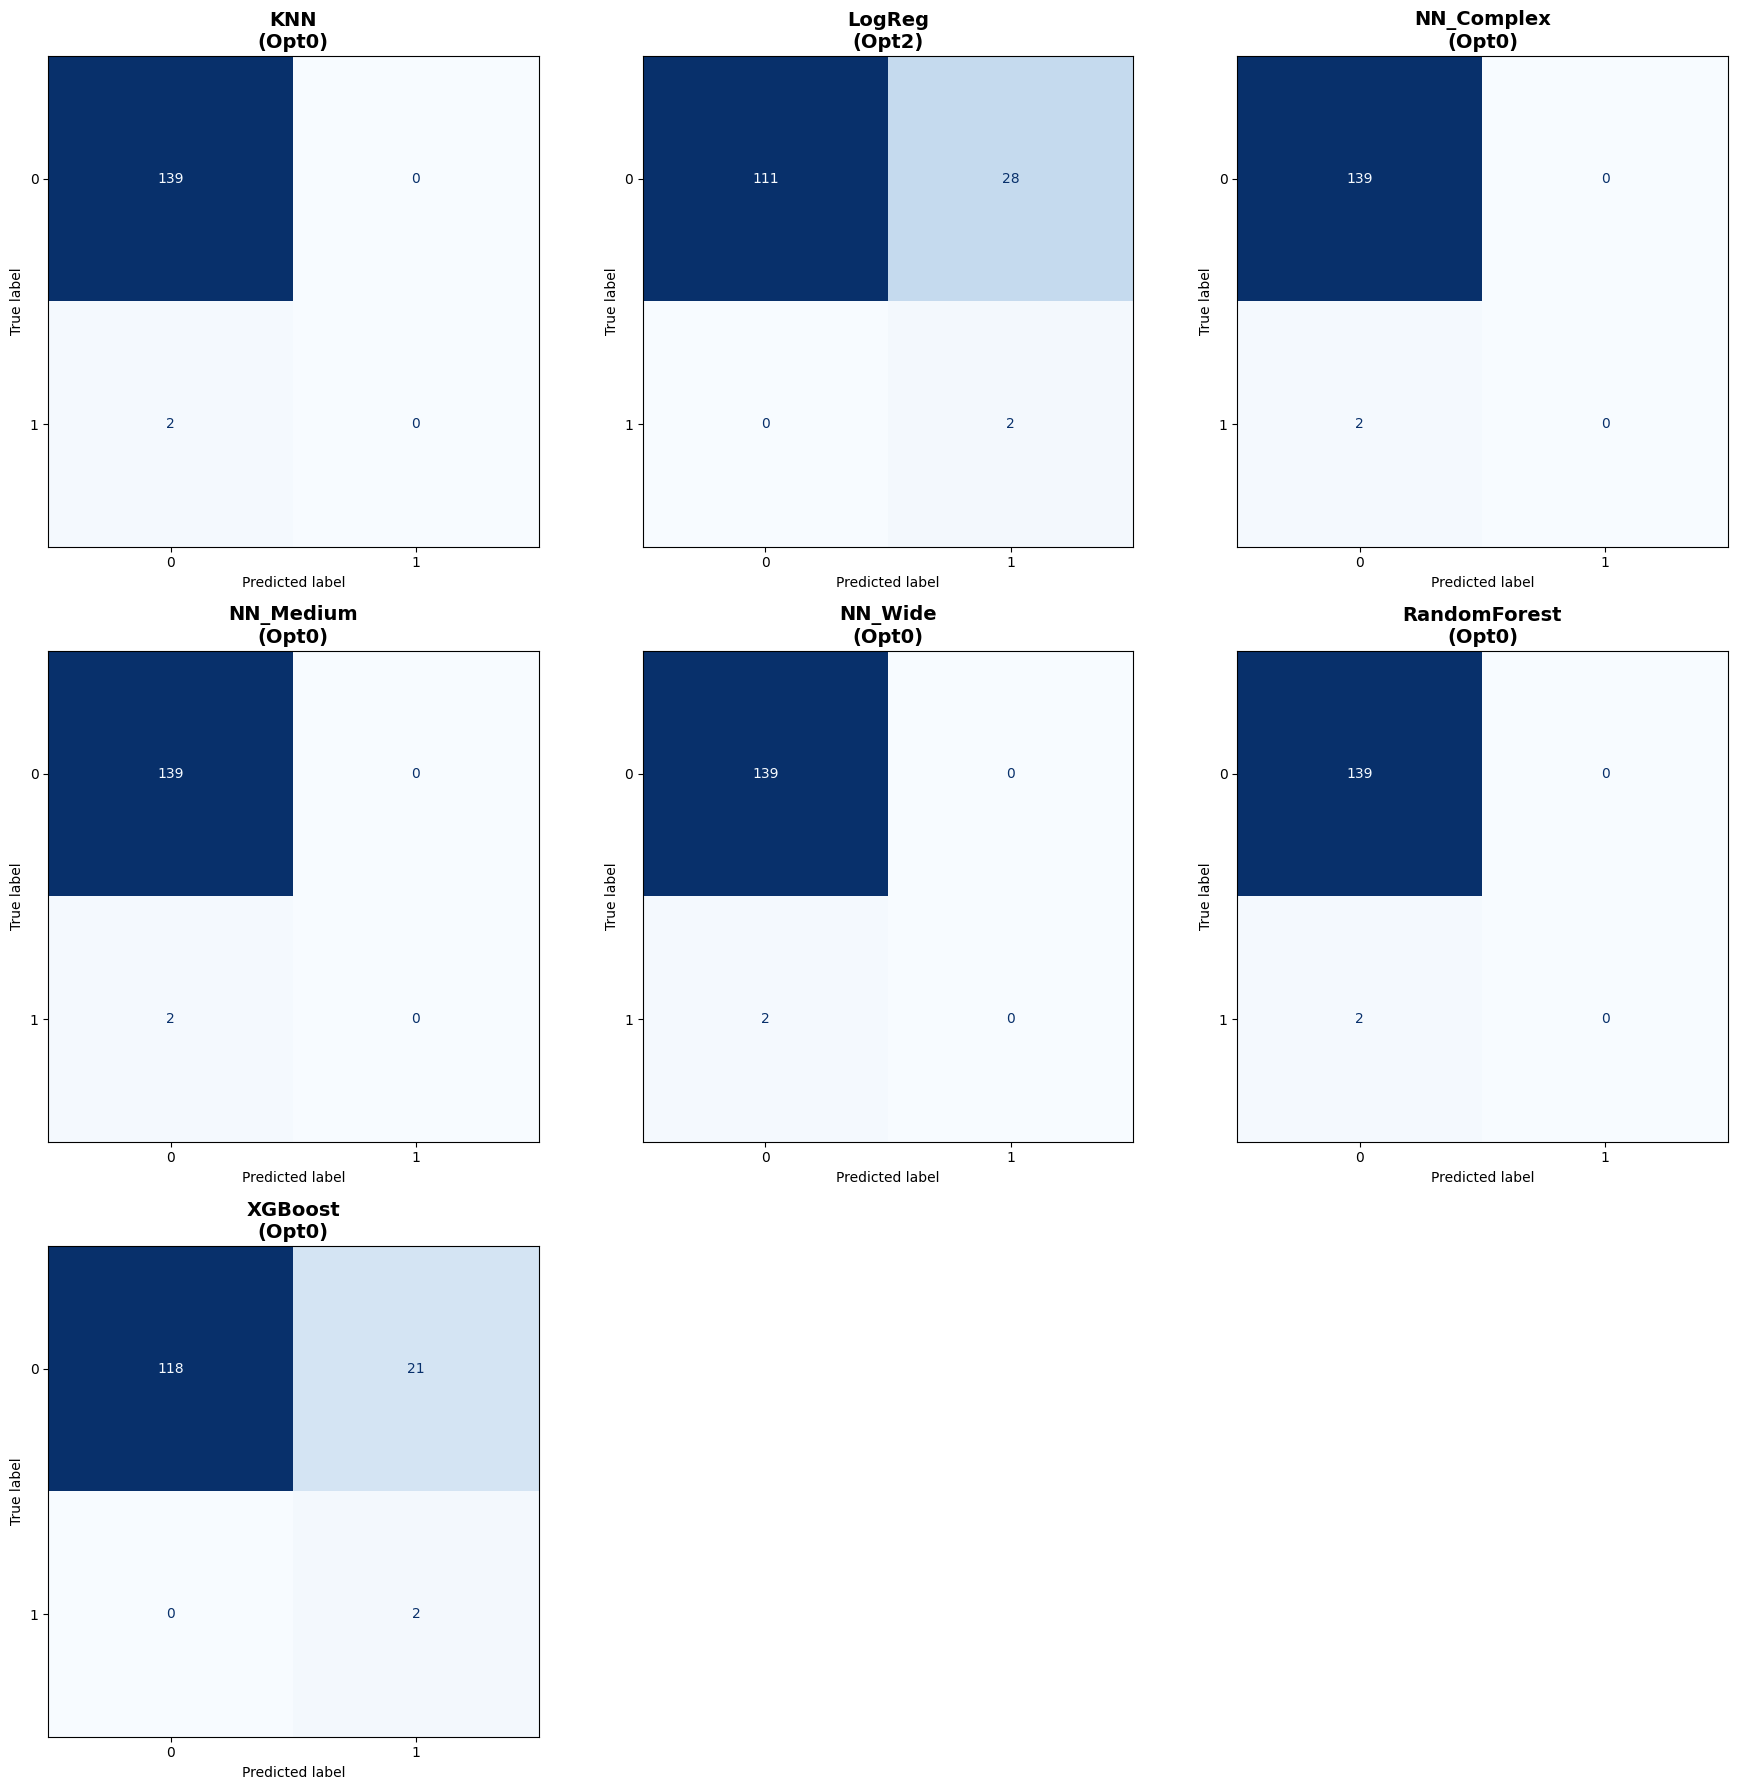


   >> Training Binary Models for: 'coupling-2D' (Optimizing Precision)
      ⚠️ Skipping coupling-2D: Too few positive samples (6)

   >> Training Binary Models for: 'unbalance-motor' (Optimizing Precision)
      Imbalance Ratio: 1:18.5

🚀 START EXPERIMENT: DETECTION_UNBALANCE-MOTOR
📊 Target Column: 'is_unbalance-motor'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.3233
   ✅ RandomForest: precision=0.3667
   ✅ LogReg: precision=0.1674
   ✅ KNN: precision=0.4567
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9574 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9574 (Stopped at epoch 6)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9574 (Stopped at epoch 9)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.3494
   ✅ RandomForest: precision=0.3000
   ✅ LogReg: precision=0.1651
   ✅ KNN: precision=0.2467
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9574

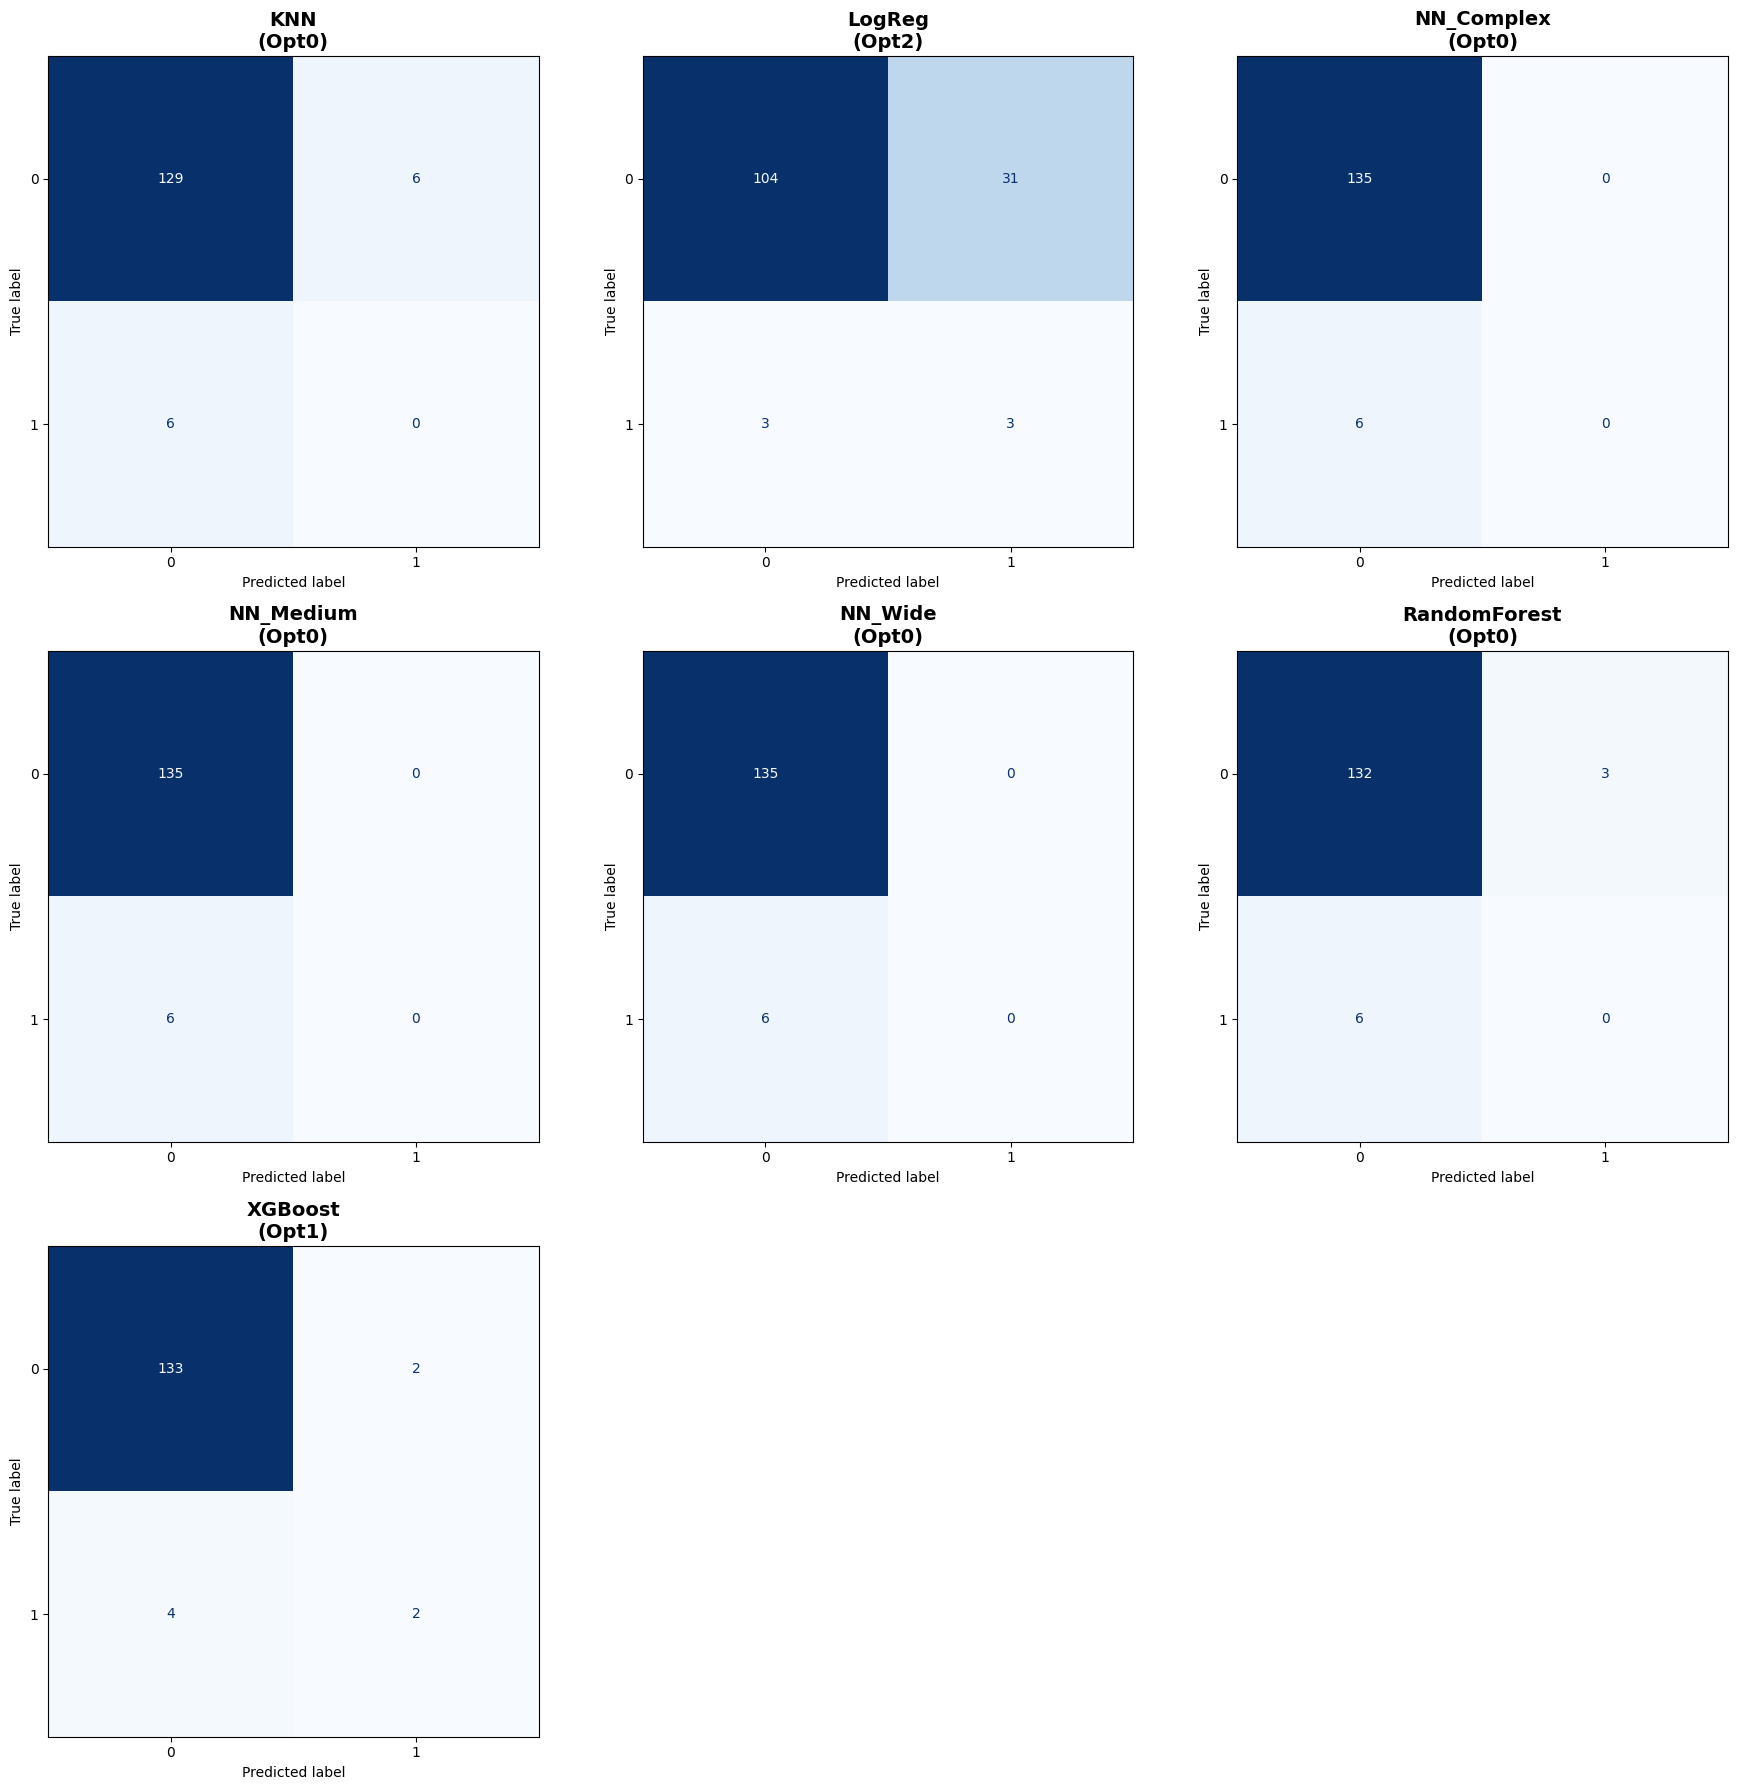


   >> Training Binary Models for: 'unbalance-pump' (Optimizing Precision)
      Imbalance Ratio: 1:38.0

🚀 START EXPERIMENT: DETECTION_UNBALANCE-PUMP
📊 Target Column: 'is_unbalance-pump'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0257
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0611
   ✅ KNN: precision=0.1000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 13)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9787 (Stopped at epoch 9)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.2000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0791
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9787 (Stopped at epoch 21)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9787 (Stopped at epoch 14)
   🧠 Training

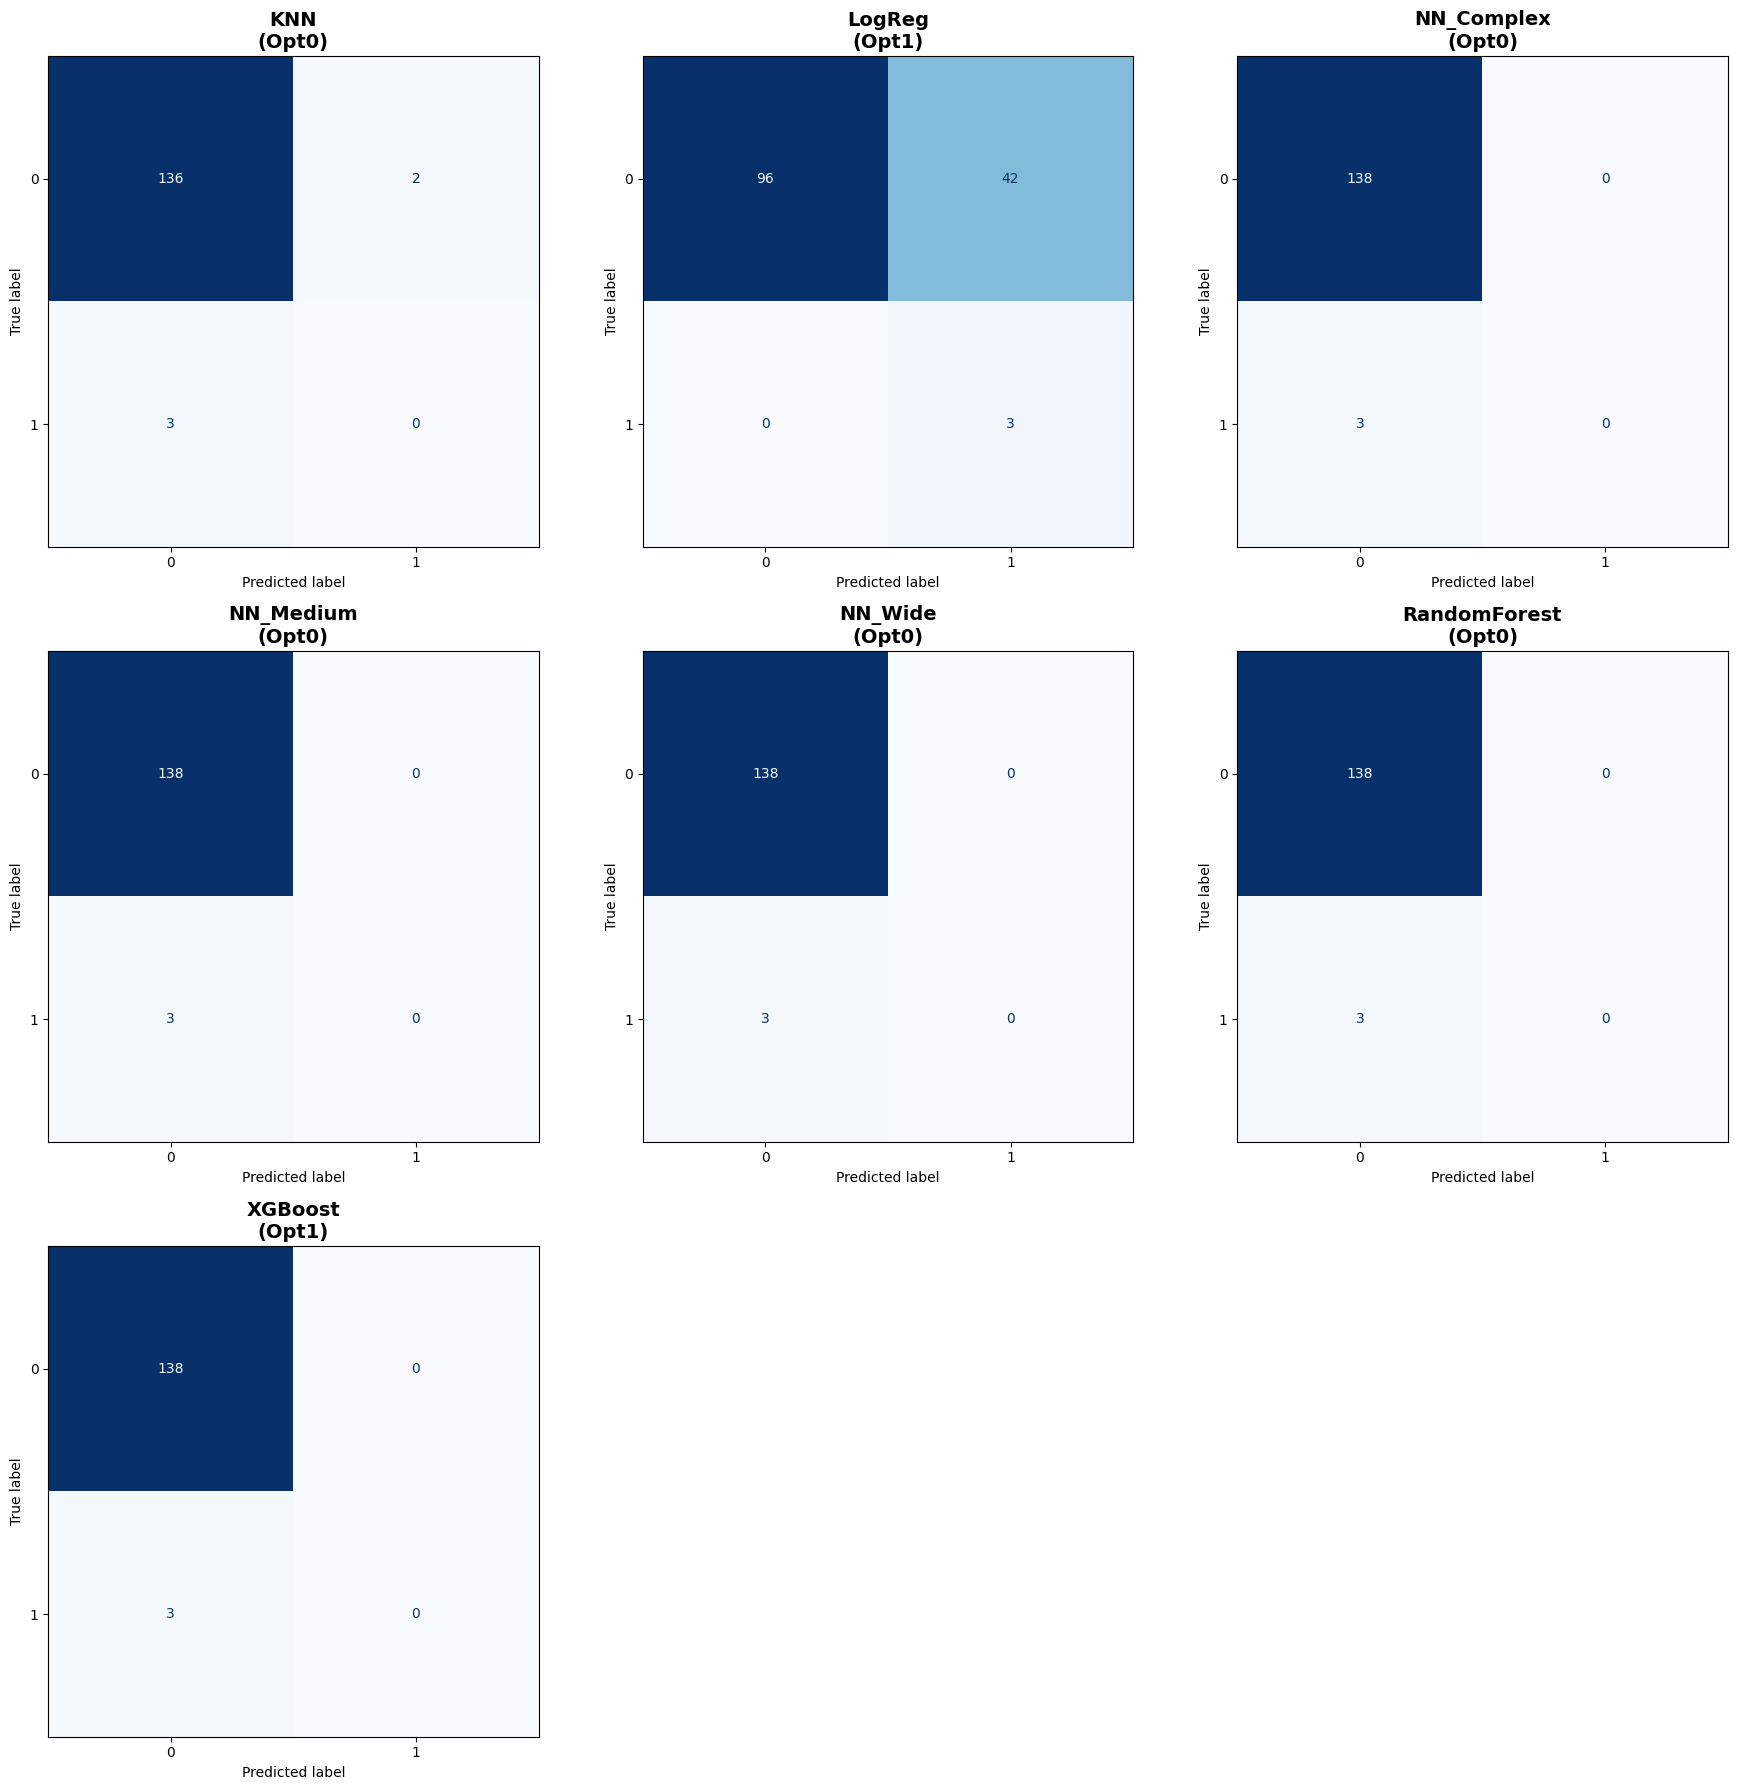


📊 FINAL SUMMARY: ALL EXPERIMENTS FOR ELECTRIC_SIGNALS

--- Top Model per Task (Sorted by F1 Score) ---
                             Task        Model                   Config       f1  precision   recall  accuracy
          Detection_align-angular      XGBoost  Opt1 (Scale:Yes PCA:No) 0.311871   0.246667 0.746667  0.939428
      Detection_align-combination      XGBoost  Opt0 (Scale:Yes PCA:No) 0.267420   0.215000 0.583333  0.950111
         Detection_align-parallel      XGBoost  Opt1 (Scale:Yes PCA:No) 0.213016   0.166667 0.783333  0.942968
           Detection_bearing-bpfi       LogReg Opt2 (Scale:Yes PCA:Yes) 0.196798   0.116949 0.636111  0.627686
           Detection_bearing-bpfo      XGBoost  Opt0 (Scale:Yes PCA:No) 0.220197   0.133378 0.666667  0.889523
            Detection_bearing-bsf      XGBoost Opt2 (Scale:Yes PCA:Yes) 0.080000   0.100000 0.066667  0.969722
   Detection_bearing-contaminated      XGBoost  Opt1 (Scale:Yes PCA:No) 0.116667   0.090000 0.233333  0.964349
        

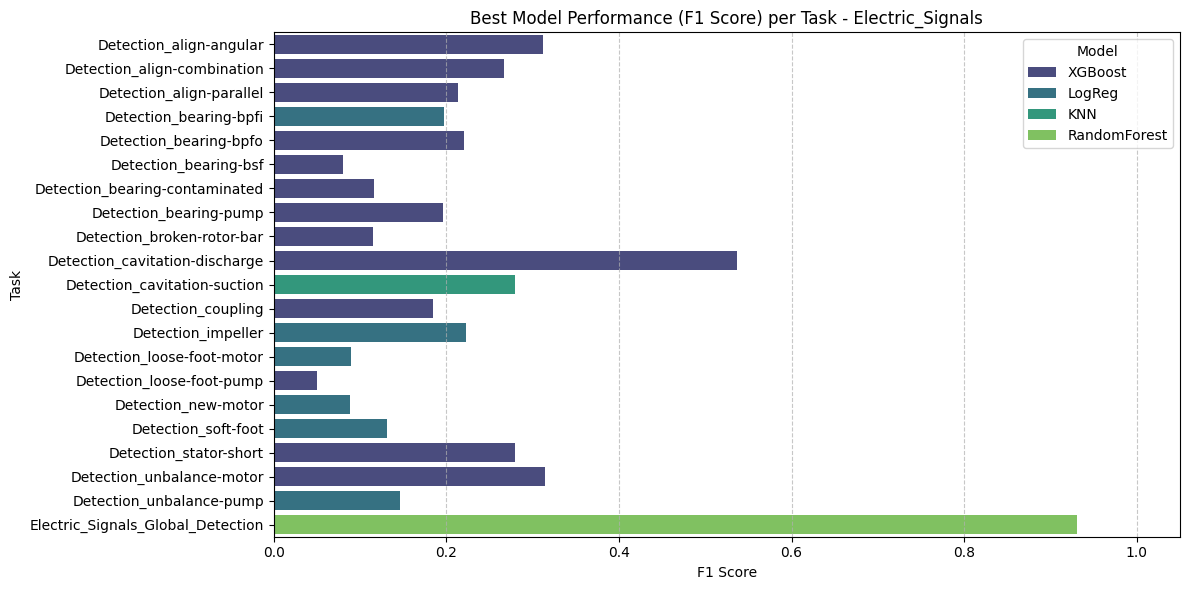

In [11]:
run_full_diagnostic_pipeline(df_elec_feat, dataset_name="Electric_Signals")


############################################################
🏁 START PIPELINE FOR: VIBRATION_SIGNALS
############################################################

--- [Stage 1] Global Detection: Is the machine faulty? ---

🚀 START EXPERIMENT: VIBRATION_SIGNALS_GLOBAL_DETECTION
📊 Target Column: 'is_faulty'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: f1=0.9279
   ✅ RandomForest: f1=0.9271
   ✅ LogReg: f1=0.8620

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: f1=0.9234
   ✅ RandomForest: f1=0.9276
   ✅ LogReg: f1=0.6685

🏁 Experiments for Vibration_Signals_Global_Detection completed!


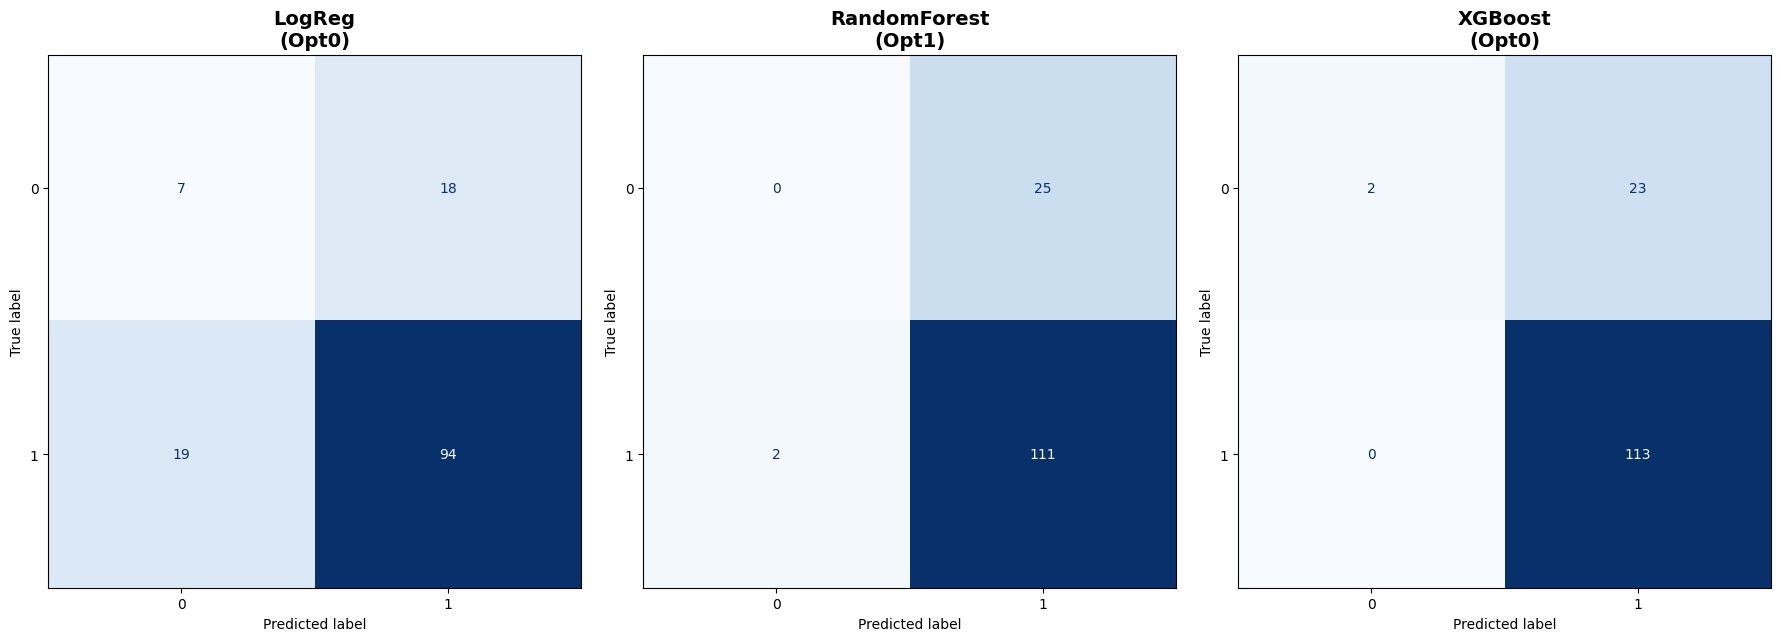


--- [Stage 2] Specific Fault Detection (Per Fault Type) ---
   Identified Fault Types: ['bearing-bpfi', 'bearing-bpfo', 'bearing-bsf', 'bearing-contaminated', 'bearing-pump', 'broken-rotor-bar', 'impeller', 'loose-foot-motor', 'loose-foot-pump', 'new-motor', 'soft-foot', 'stator-short', 'align-angular', 'align-combination', 'align-parallel', 'bent-shaft', 'cavitation-discharge', 'cavitation-suction', 'coupling', 'coupling-2D', 'unbalance-motor', 'unbalance-pump']

   >> Training Binary Models for: 'bearing-bpfi' (Optimizing Precision)
      Imbalance Ratio: 1:11.5

🚀 START EXPERIMENT: DETECTION_BEARING-BPFI
📊 Target Column: 'is_bearing-bpfi'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.8667
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.4379
   ✅ KNN: precision=0.7444
   🧠 Training Neural Network: NN_Medium...


2025-12-10 20:08:25.739508: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:08:25.739633: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:08:26.570179: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_156', 28 bytes spill stores, 28 bytes spill loads

2025-12-10 20:08:26.696375: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

   ✅ NN_Medium: accuracy=0.8986 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Complex...


2025-12-10 20:08:34.347197: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:08:34.347251: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:08:35.267234: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1548', 236 bytes spill stores, 236 bytes spill loads

2025-12-10 20:08:35.298330: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning

   ✅ NN_Complex: accuracy=0.8986 (Stopped at epoch 6)
   🧠 Training Neural Network: NN_Wide...


...

   ✅ NN_Medium: accuracy=0.8986 (Stopped at epoch 12)
   🧠 Training Neural Network: NN_Complex...


2025-12-10 20:09:47.811245: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:09:47.811301: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:09:48.644440: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_191', 464 bytes spill stores, 464 bytes spill loads

2025-12-10 20:09:48.755687: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

   ✅ NN_Complex: accuracy=0.8986 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Wide...


2025-12-10 20:09:57.686252: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:09:57.686311: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-10 20:09:58.352754: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_156', 92 bytes spill stores, 92 bytes spill loads

2025-12-10 20:09:58.414286: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : 

   ✅ NN_Wide: accuracy=0.8986 (Stopped at epoch 8)

🏁 Experiments for Detection_bearing-bpfi completed!
      >> Best results for bearing-bpfi:

=== [Detection_bearing-bpfi] Top 3 Results (Sorted by precision) ===
       Model                  Config Option_ID  precision     f1  recall  accuracy  learning_rate  max_depth  n_estimators  min_samples_leaf   C  n_neighbors weights params
     XGBoost Opt0 (Scale:Yes PCA:No)      Opt0     0.8667 0.5262  0.5861    0.9474            0.1        6.0         200.0               NaN NaN          NaN     NaN    NaN
RandomForest Opt1 (Scale:Yes PCA:No)      Opt1     0.8000 0.4157  0.2944    0.9457            NaN       10.0         100.0               1.0 NaN          NaN     NaN    NaN
         KNN Opt1 (Scale:Yes PCA:No)      Opt1     0.7733 0.5034  0.4167    0.9420            NaN        NaN           NaN               NaN NaN          7.0 uniform    NaN


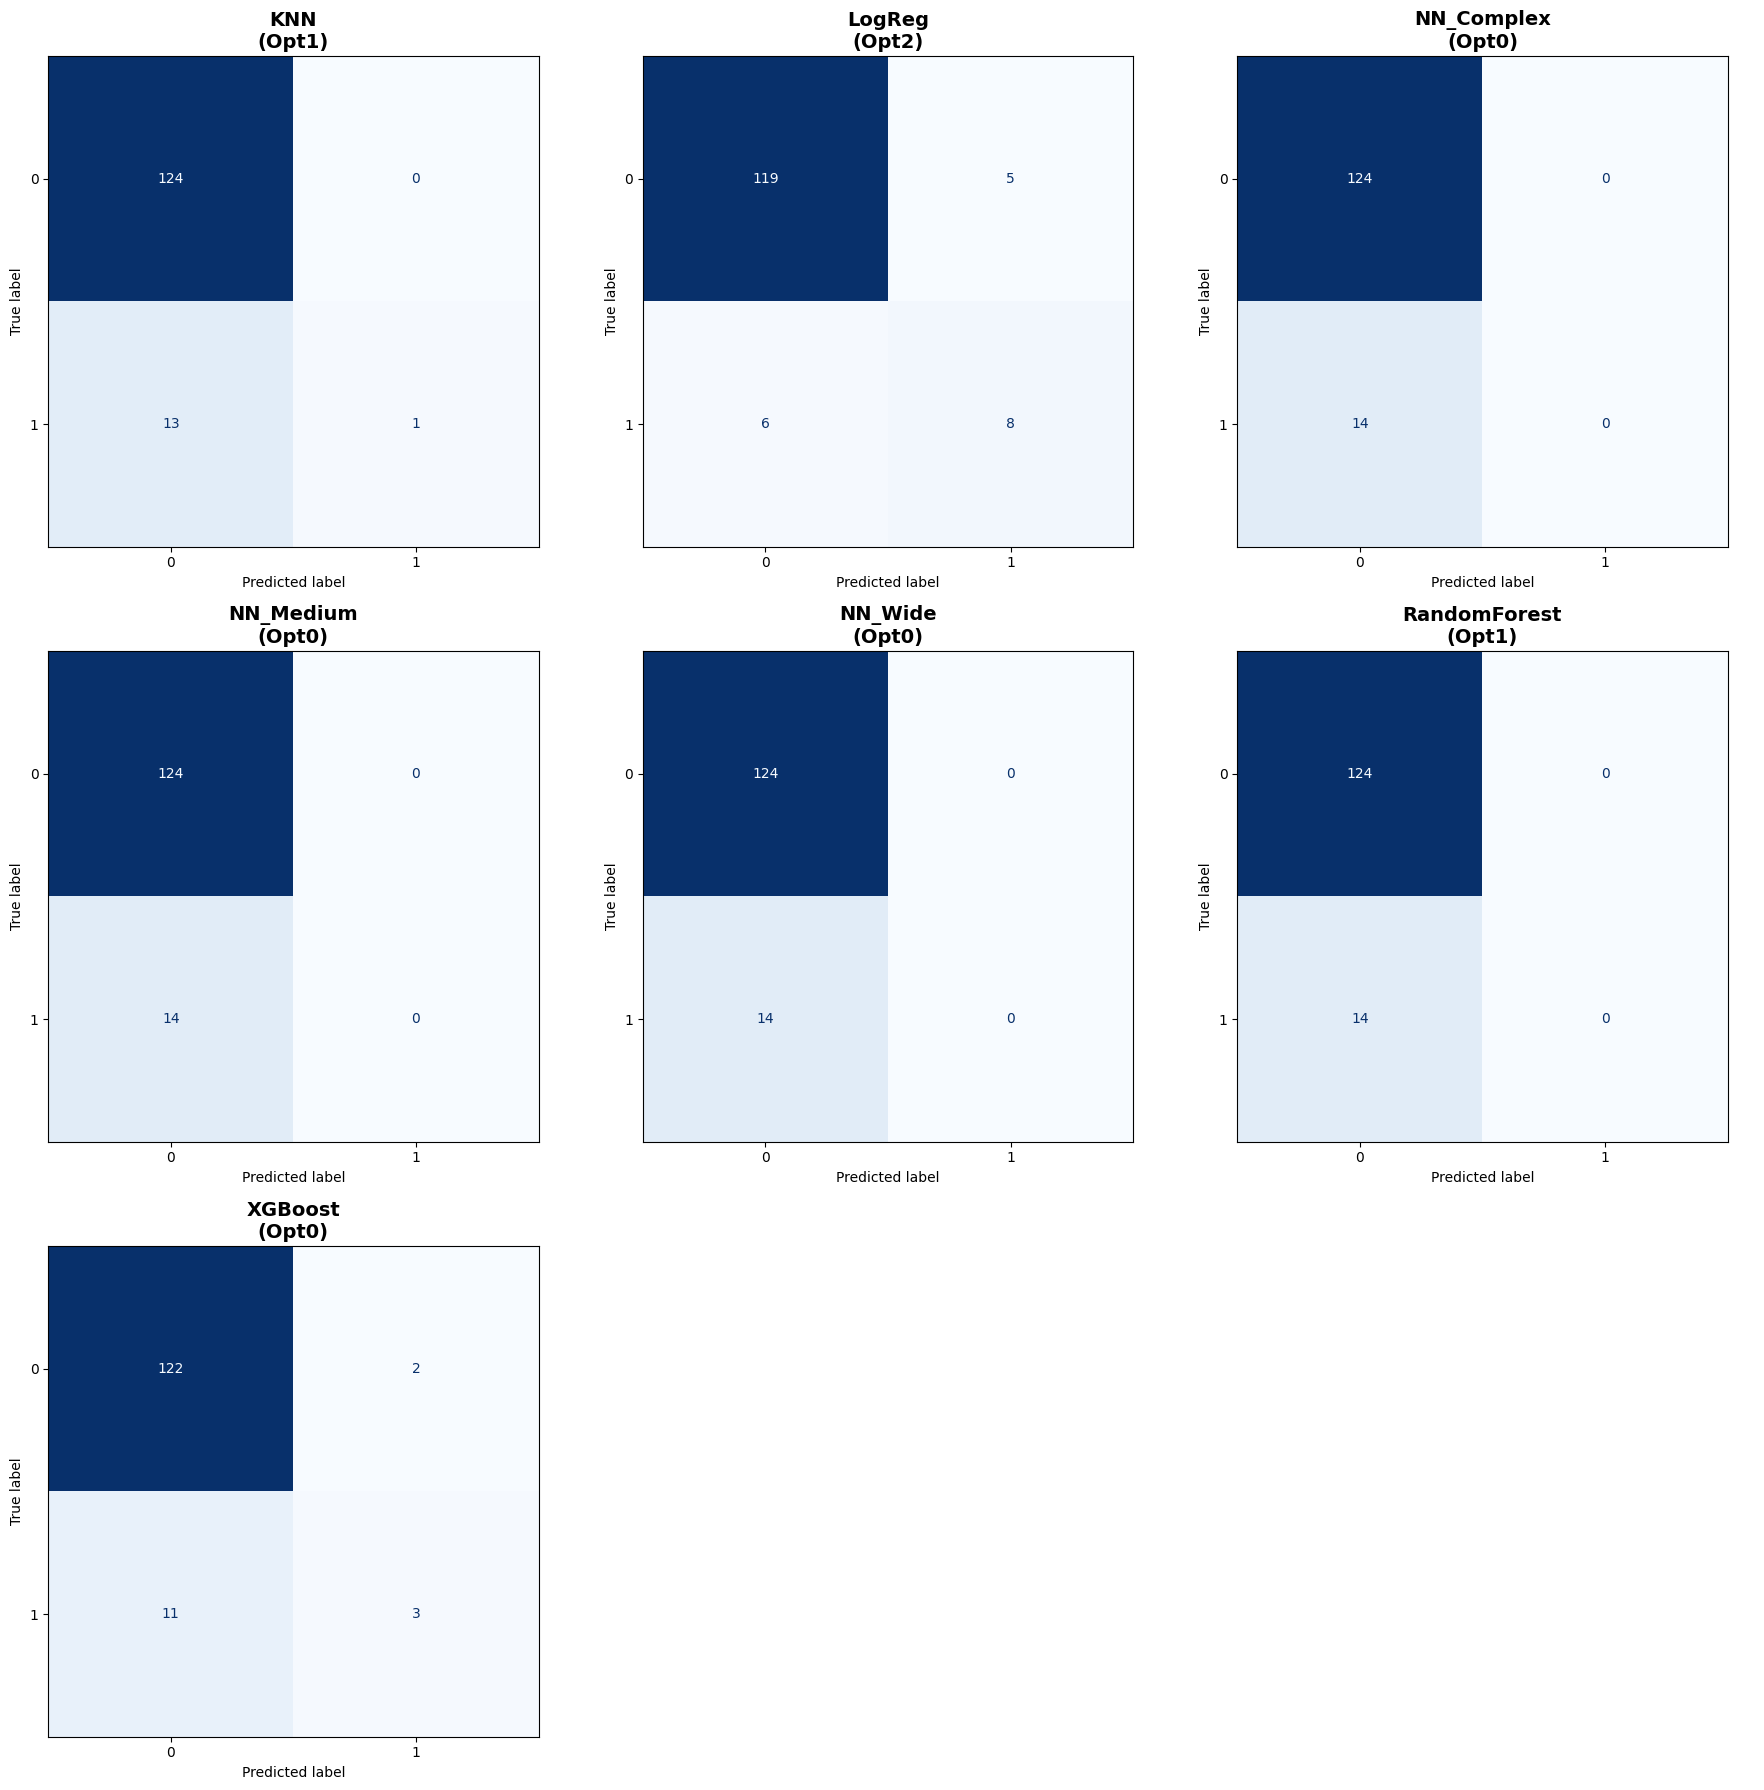


   >> Training Binary Models for: 'bearing-bpfo' (Optimizing Precision)
      Imbalance Ratio: 1:10.5

🚀 START EXPERIMENT: DETECTION_BEARING-BPFO
📊 Target Column: 'is_bearing-bpfo'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.6167
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.2917
   ✅ KNN: precision=0.8333
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9638 (Stopped at epoch 18)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9493 (Stopped at epoch 20)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9493 (Stopped at epoch 18)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4633
   ✅ RandomForest: precision=0.9333
   ✅ LogReg: precision=0.1718
   ✅ KNN: precision=0.6000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9565 (Stopped at epoch 21)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9638 (Stopped at epoch 17)
   🧠 Training Neu

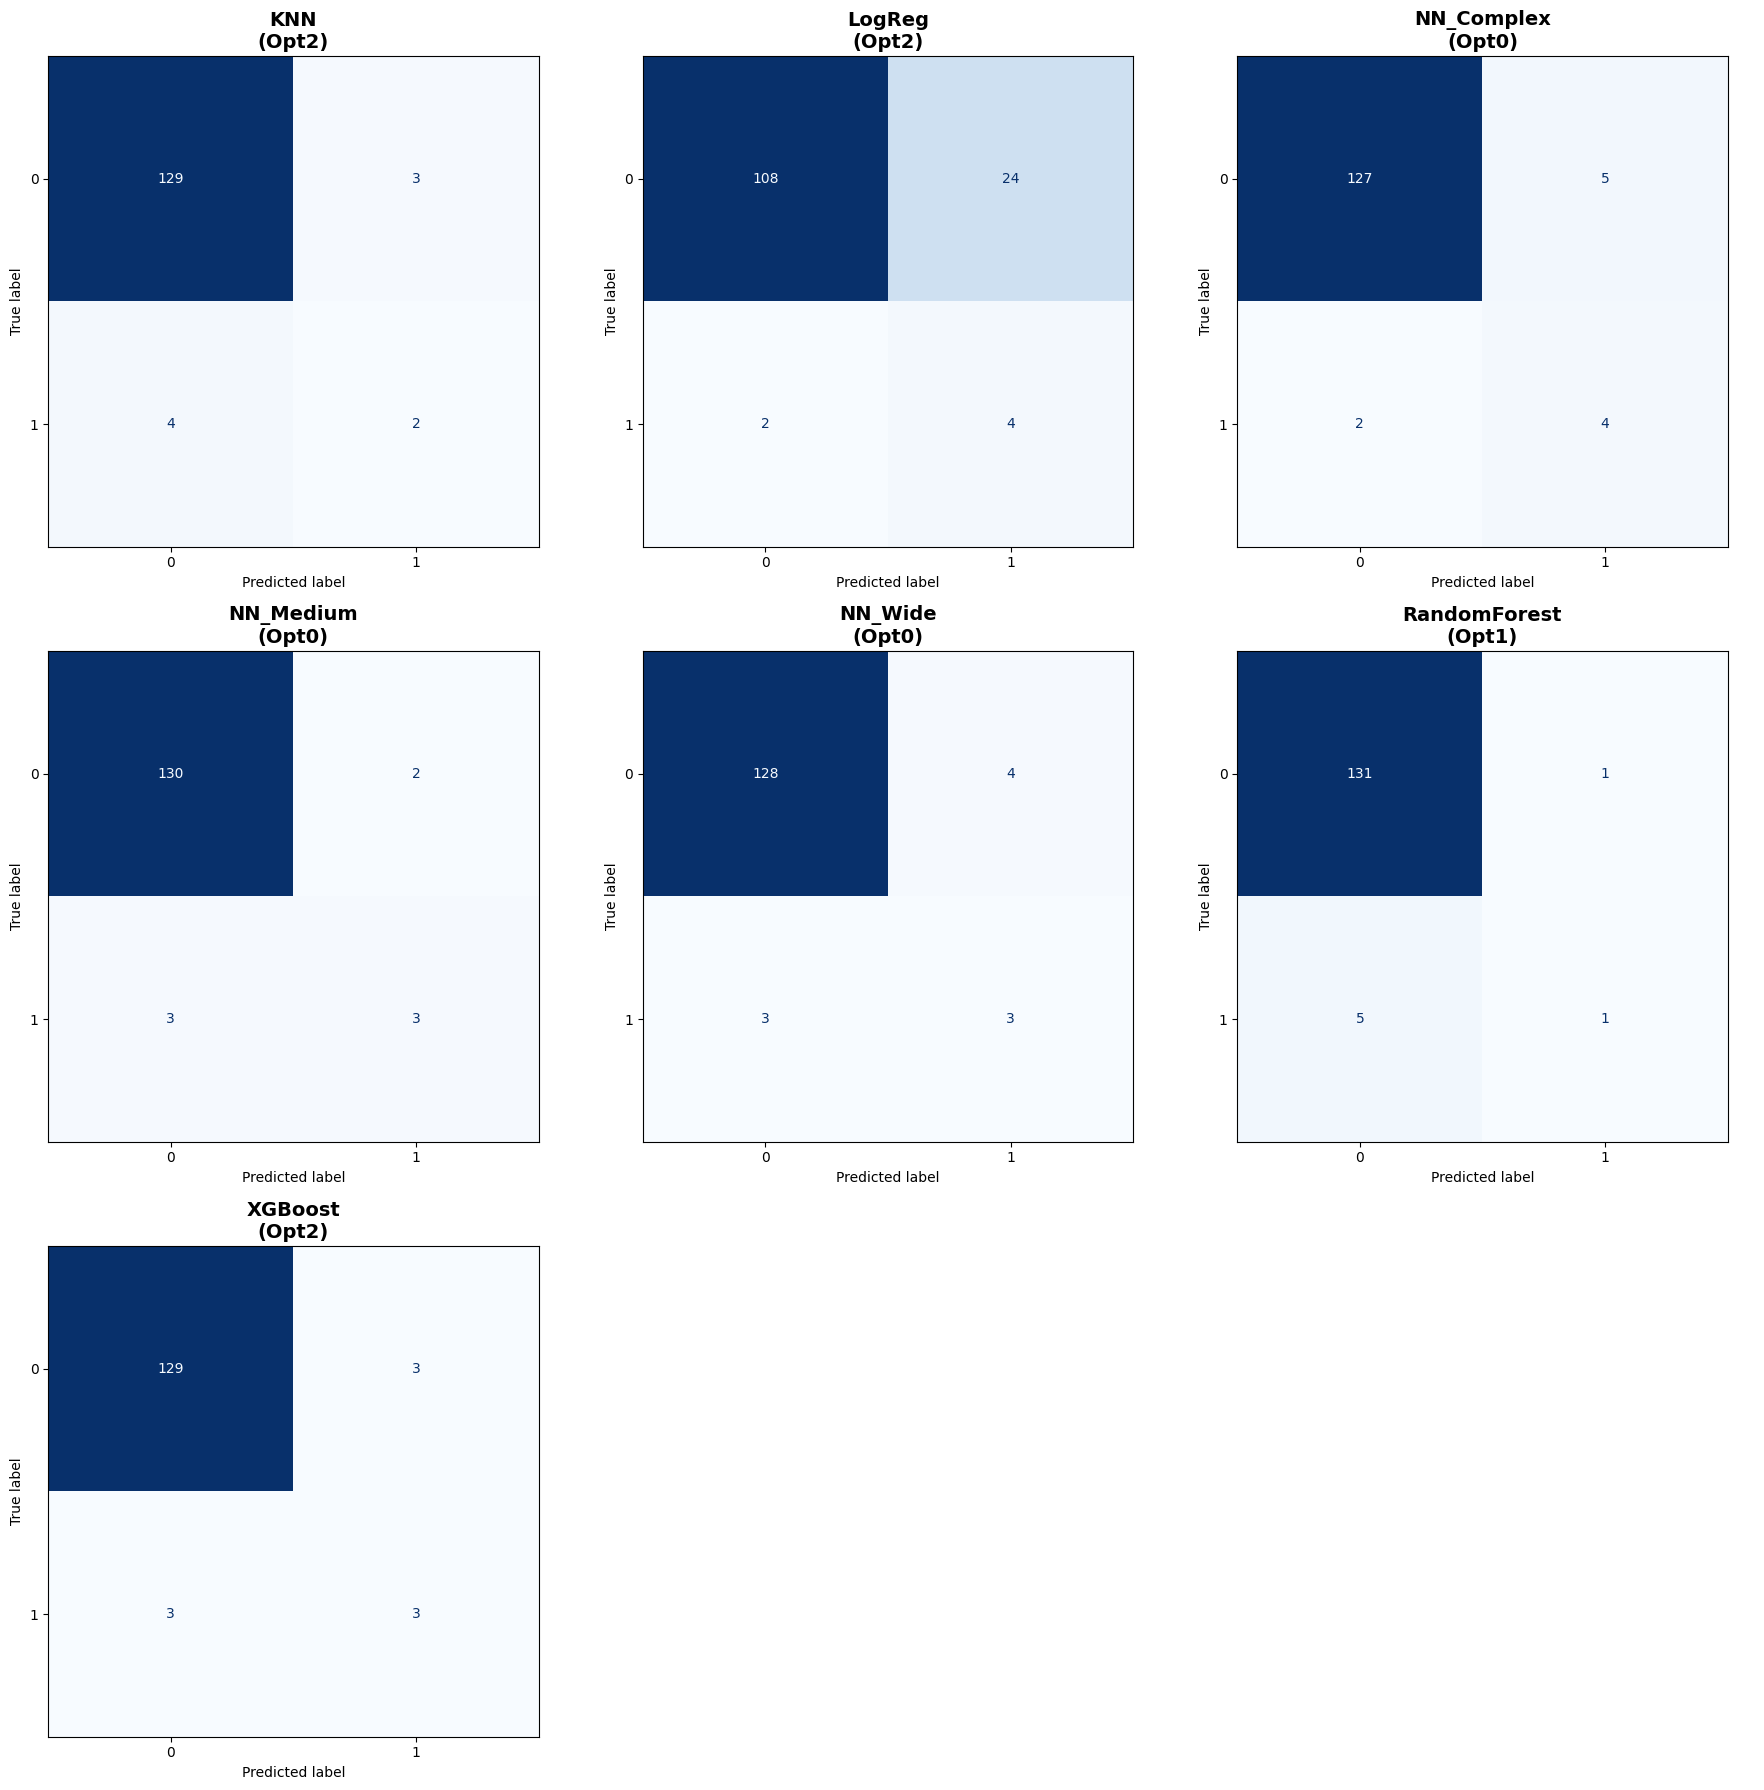


   >> Training Binary Models for: 'bearing-bsf' (Optimizing Precision)
      Imbalance Ratio: 1:33.5

🚀 START EXPERIMENT: DETECTION_BEARING-BSF
📊 Target Column: 'is_bearing-bsf'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.2250
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1167
   ✅ KNN: precision=0.3000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9493 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9493 (Stopped at epoch 6)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9493 (Stopped at epoch 10)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0333
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0254
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9493 (Stopped at epoch 23)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9493 (Stopped at epoch 11)
   🧠 Training Neural N

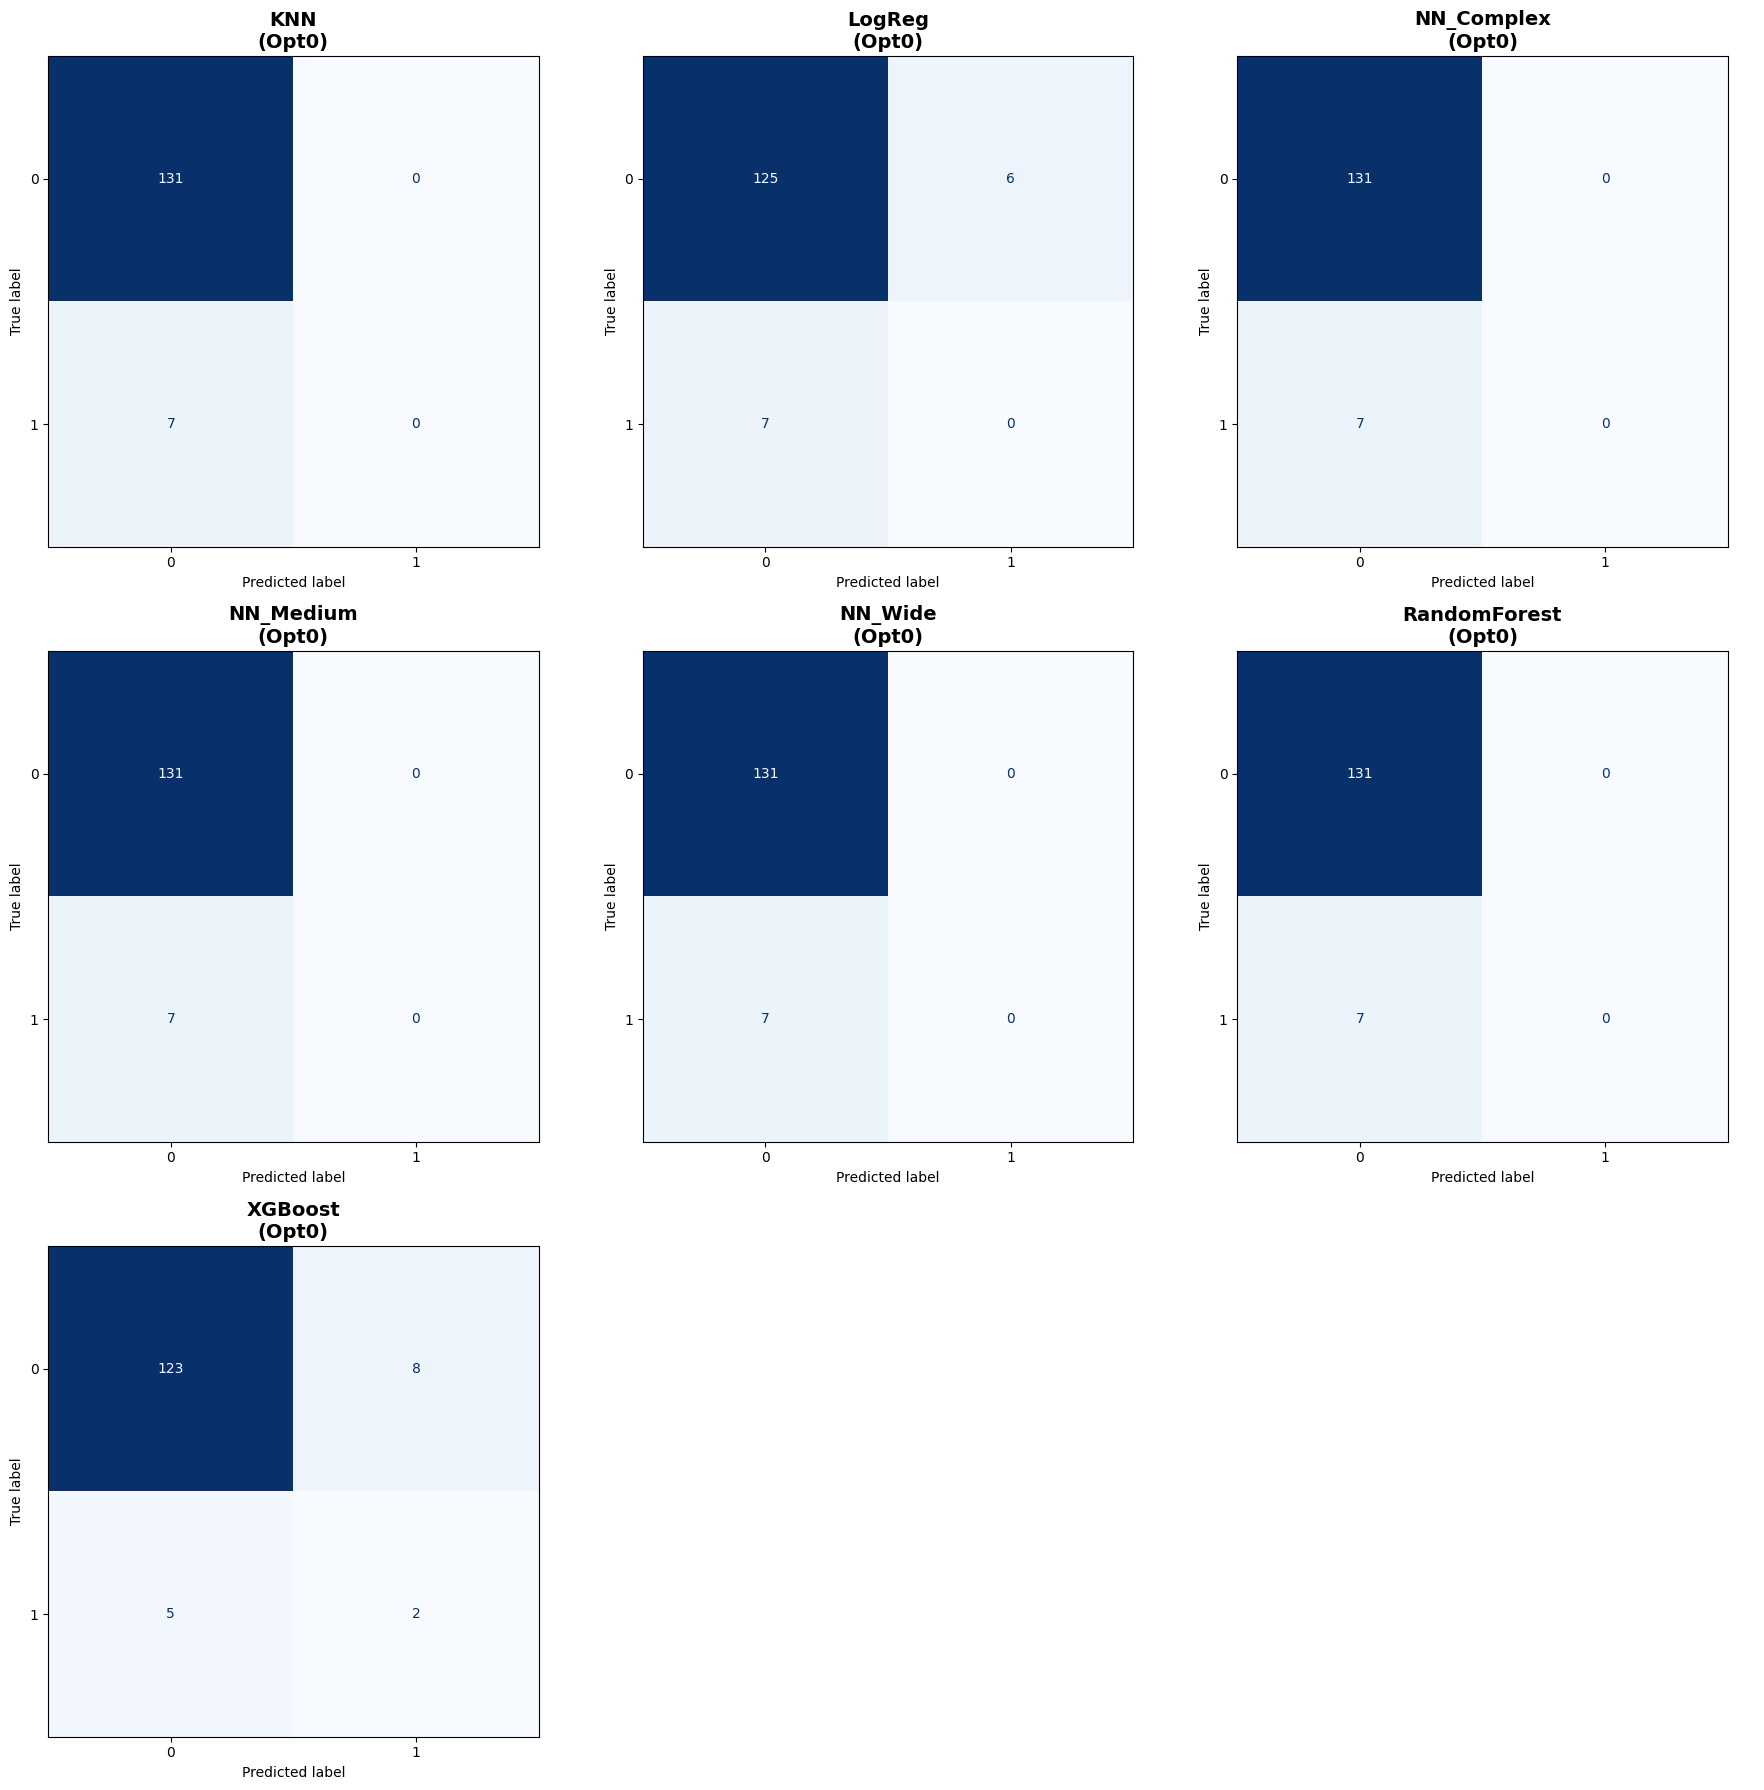


   >> Training Binary Models for: 'bearing-contaminated' (Optimizing Precision)
      Imbalance Ratio: 1:33.5

🚀 START EXPERIMENT: DETECTION_BEARING-CONTAMINATED
📊 Target Column: 'is_bearing-contaminated'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.2000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1500
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9638 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9638 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9638 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0707
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9638 (Stopped at epoch 15)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9638 (Stopped at epoch

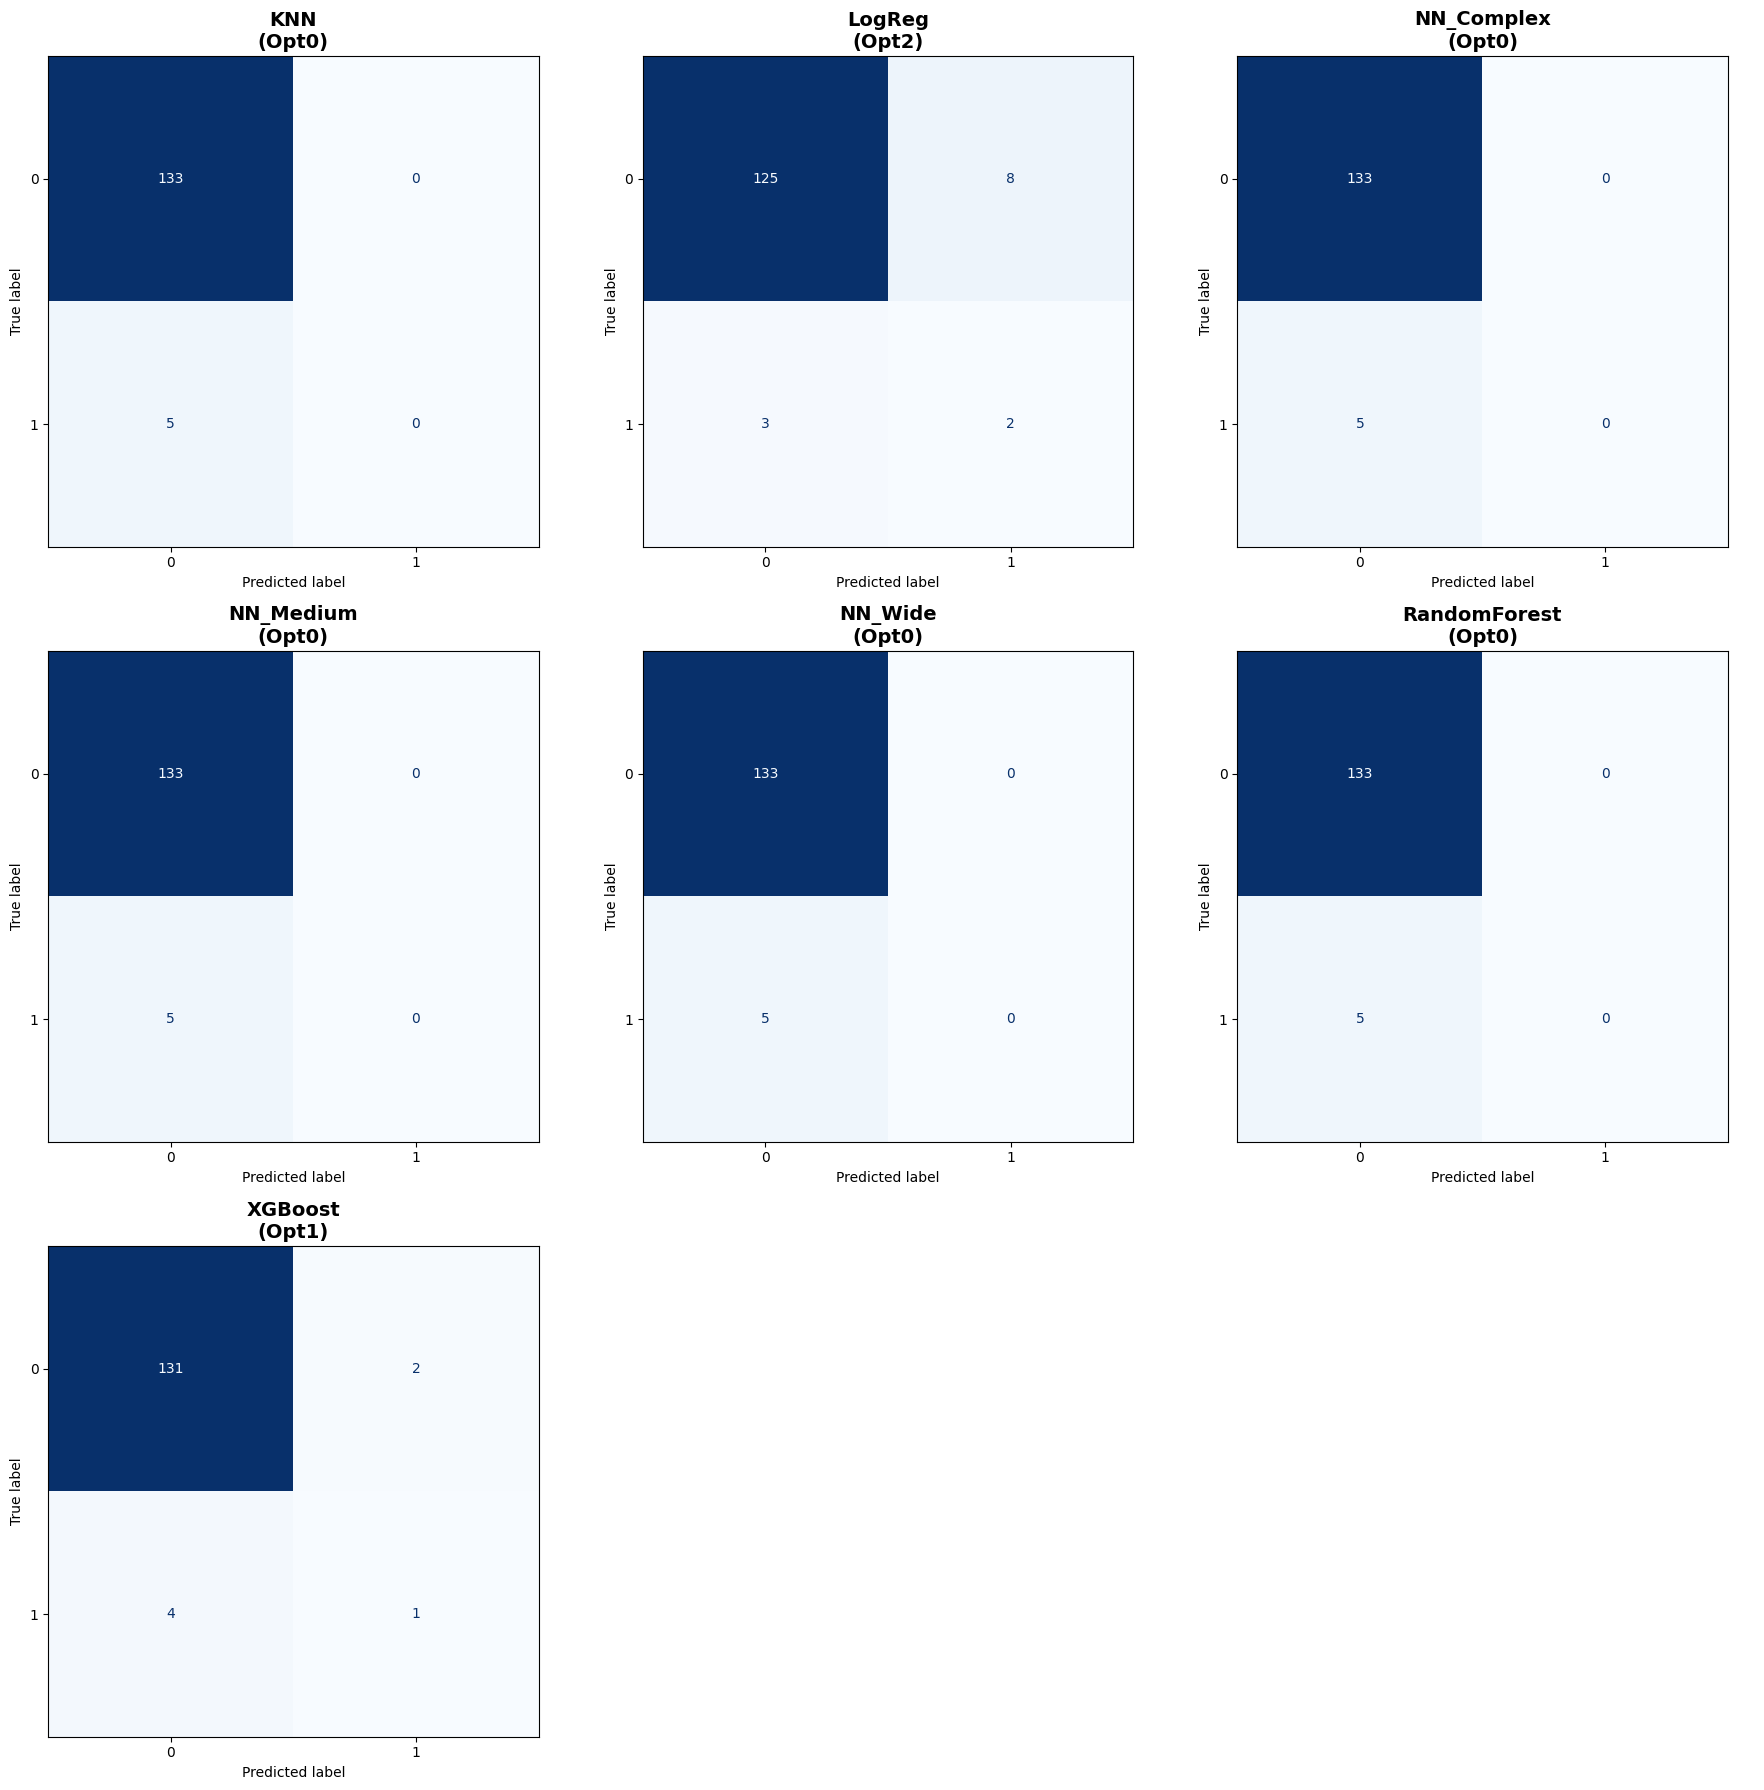


   >> Training Binary Models for: 'bearing-pump' (Optimizing Precision)
      Imbalance Ratio: 1:10.5

🚀 START EXPERIMENT: DETECTION_BEARING-PUMP
📊 Target Column: 'is_bearing-pump'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.6857
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.2483
   ✅ KNN: precision=0.6200
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9058 (Stopped at epoch 14)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9058 (Stopped at epoch 13)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9130 (Stopped at epoch 13)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.5633
   ✅ RandomForest: precision=0.4667
   ✅ LogReg: precision=0.1194
   ✅ KNN: precision=0.6000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9058 (Stopped at epoch 29)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9058 (Stopped at epoch 23)
   🧠 Training Neu

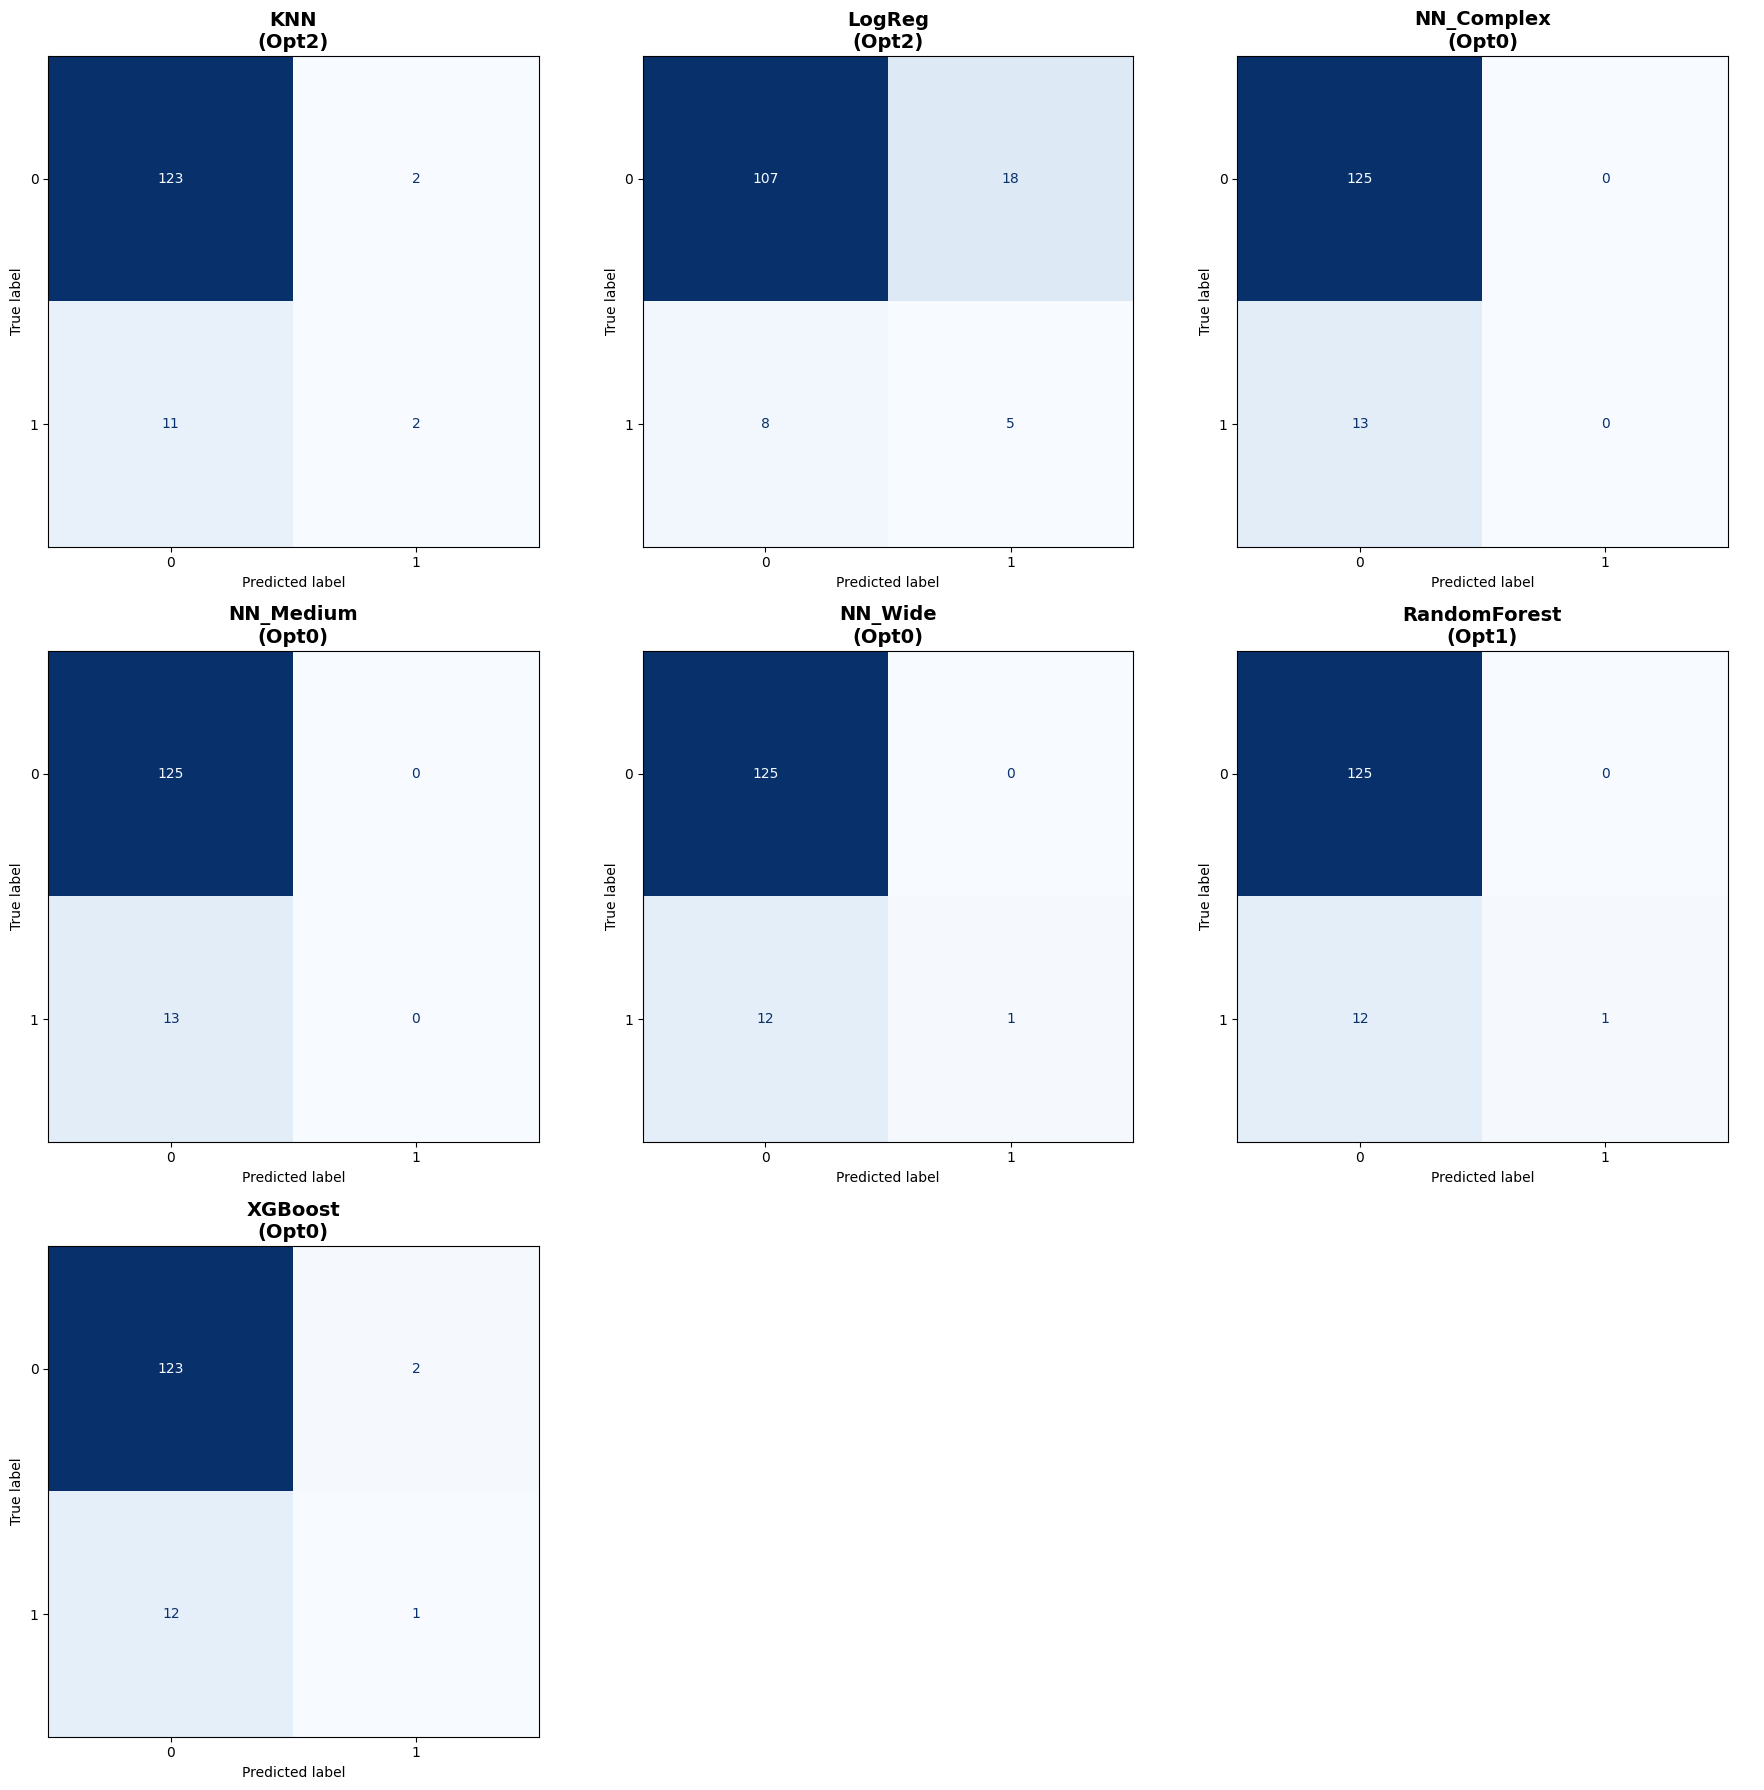


   >> Training Binary Models for: 'broken-rotor-bar' (Optimizing Precision)
      Imbalance Ratio: 1:33.5

🚀 START EXPERIMENT: DETECTION_BROKEN-ROTOR-BAR
📊 Target Column: 'is_broken-rotor-bar'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.0400
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1311
   ✅ KNN: precision=0.1000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9783 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9783 (Stopped at epoch 12)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9783 (Stopped at epoch 14)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0449
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9783 (Stopped at epoch 40)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9710 (Stopped at epoch 36)
   🧠 

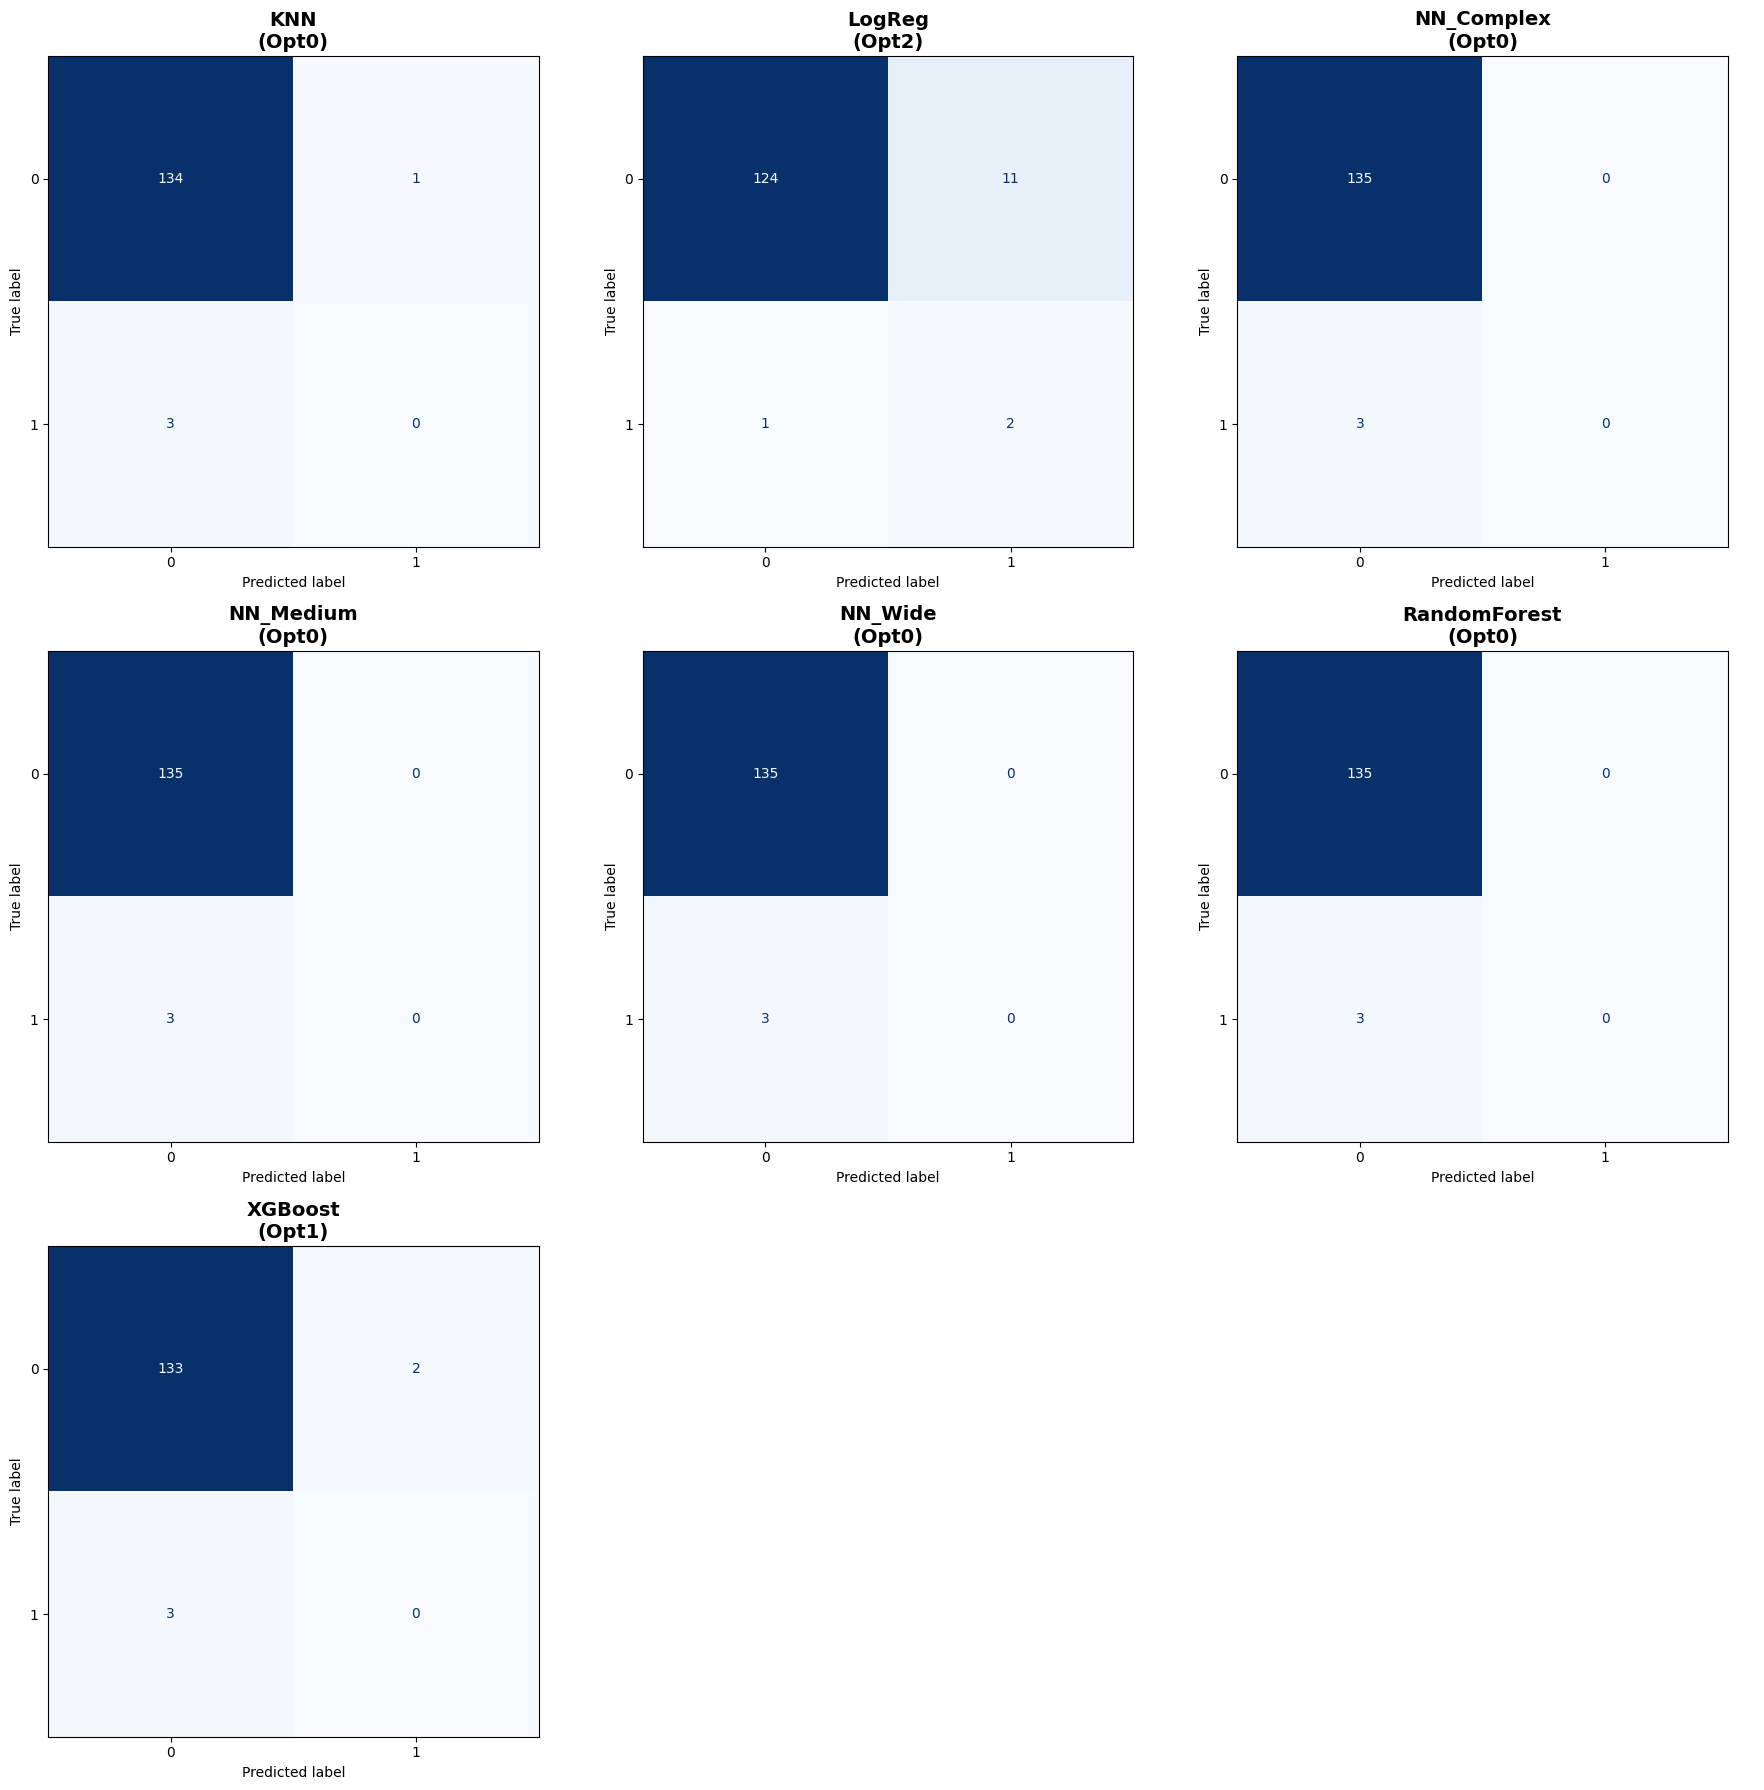


   >> Training Binary Models for: 'impeller' (Optimizing Precision)
      Imbalance Ratio: 1:10.5

🚀 START EXPERIMENT: DETECTION_IMPELLER
📊 Target Column: 'is_impeller'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.3667
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.2195
   ✅ KNN: precision=0.3349
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.8623 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.8623 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.8623 (Stopped at epoch 8)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4238
   ✅ RandomForest: precision=0.8000
   ✅ LogReg: precision=0.1591
   ✅ KNN: precision=0.4500
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.8623 (Stopped at epoch 28)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.8623 (Stopped at epoch 19)
   🧠 Training Neural Network: N

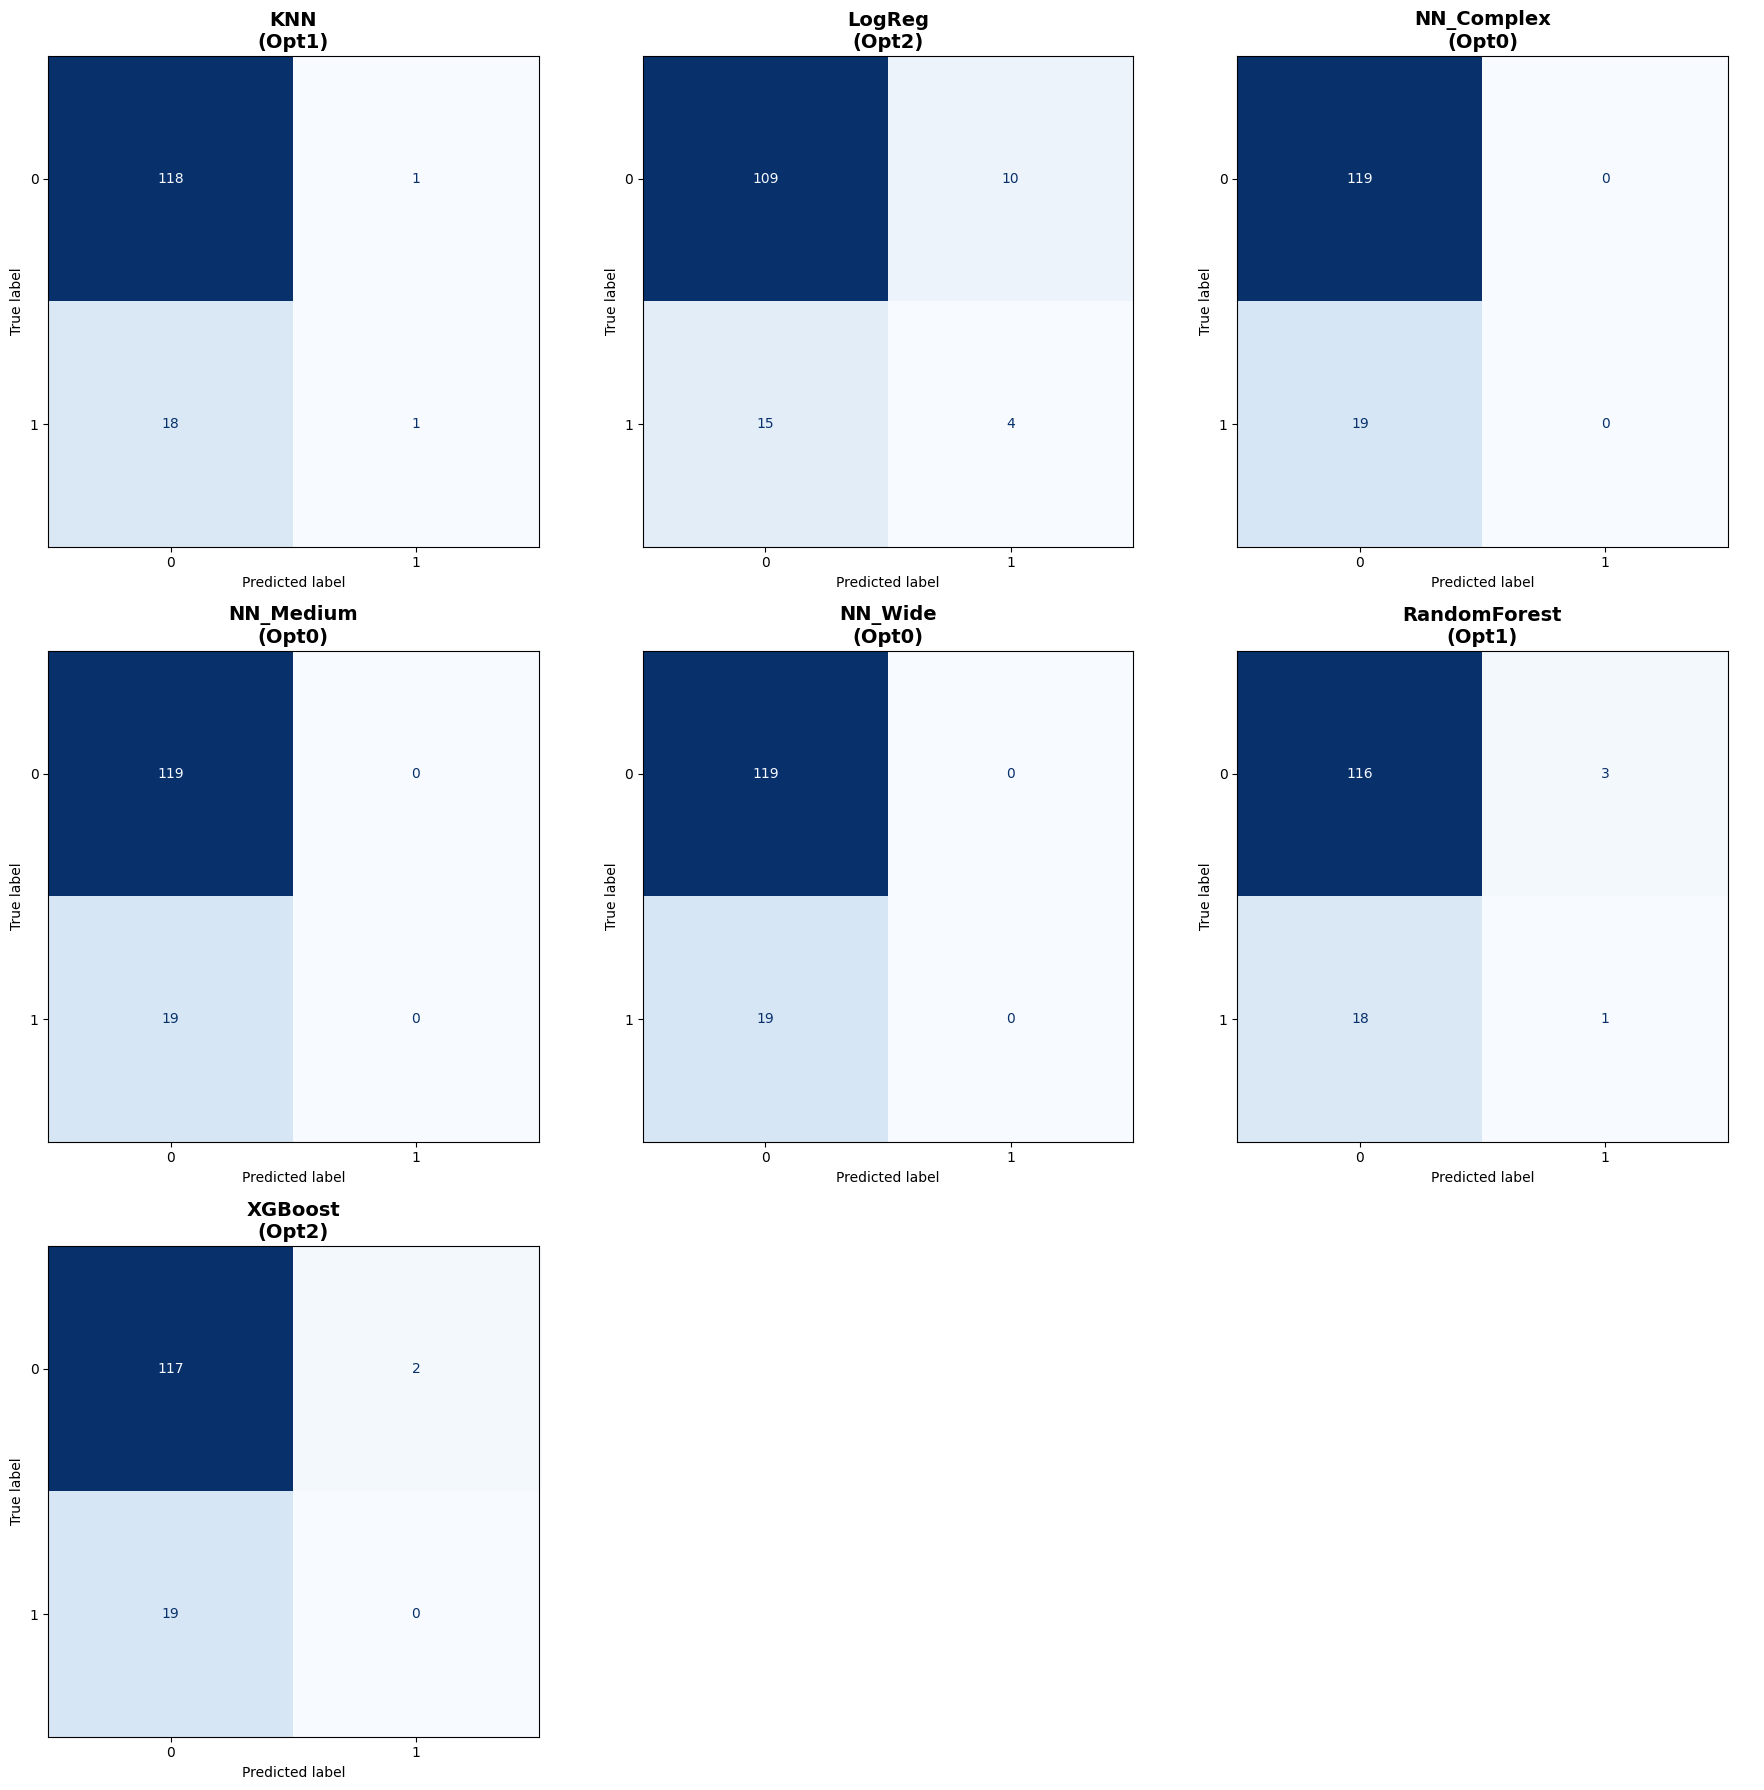


   >> Training Binary Models for: 'loose-foot-motor' (Optimizing Precision)
      Imbalance Ratio: 1:45.0

🚀 START EXPERIMENT: DETECTION_LOOSE-FOOT-MOTOR
📊 Target Column: 'is_loose-foot-motor'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.3000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1019
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9928 (Stopped at epoch 12)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9928 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9928 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.3000
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.0564
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9928 (Stopped at epoch 20)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9928 (Stopped at epoch 15)
   🧠 

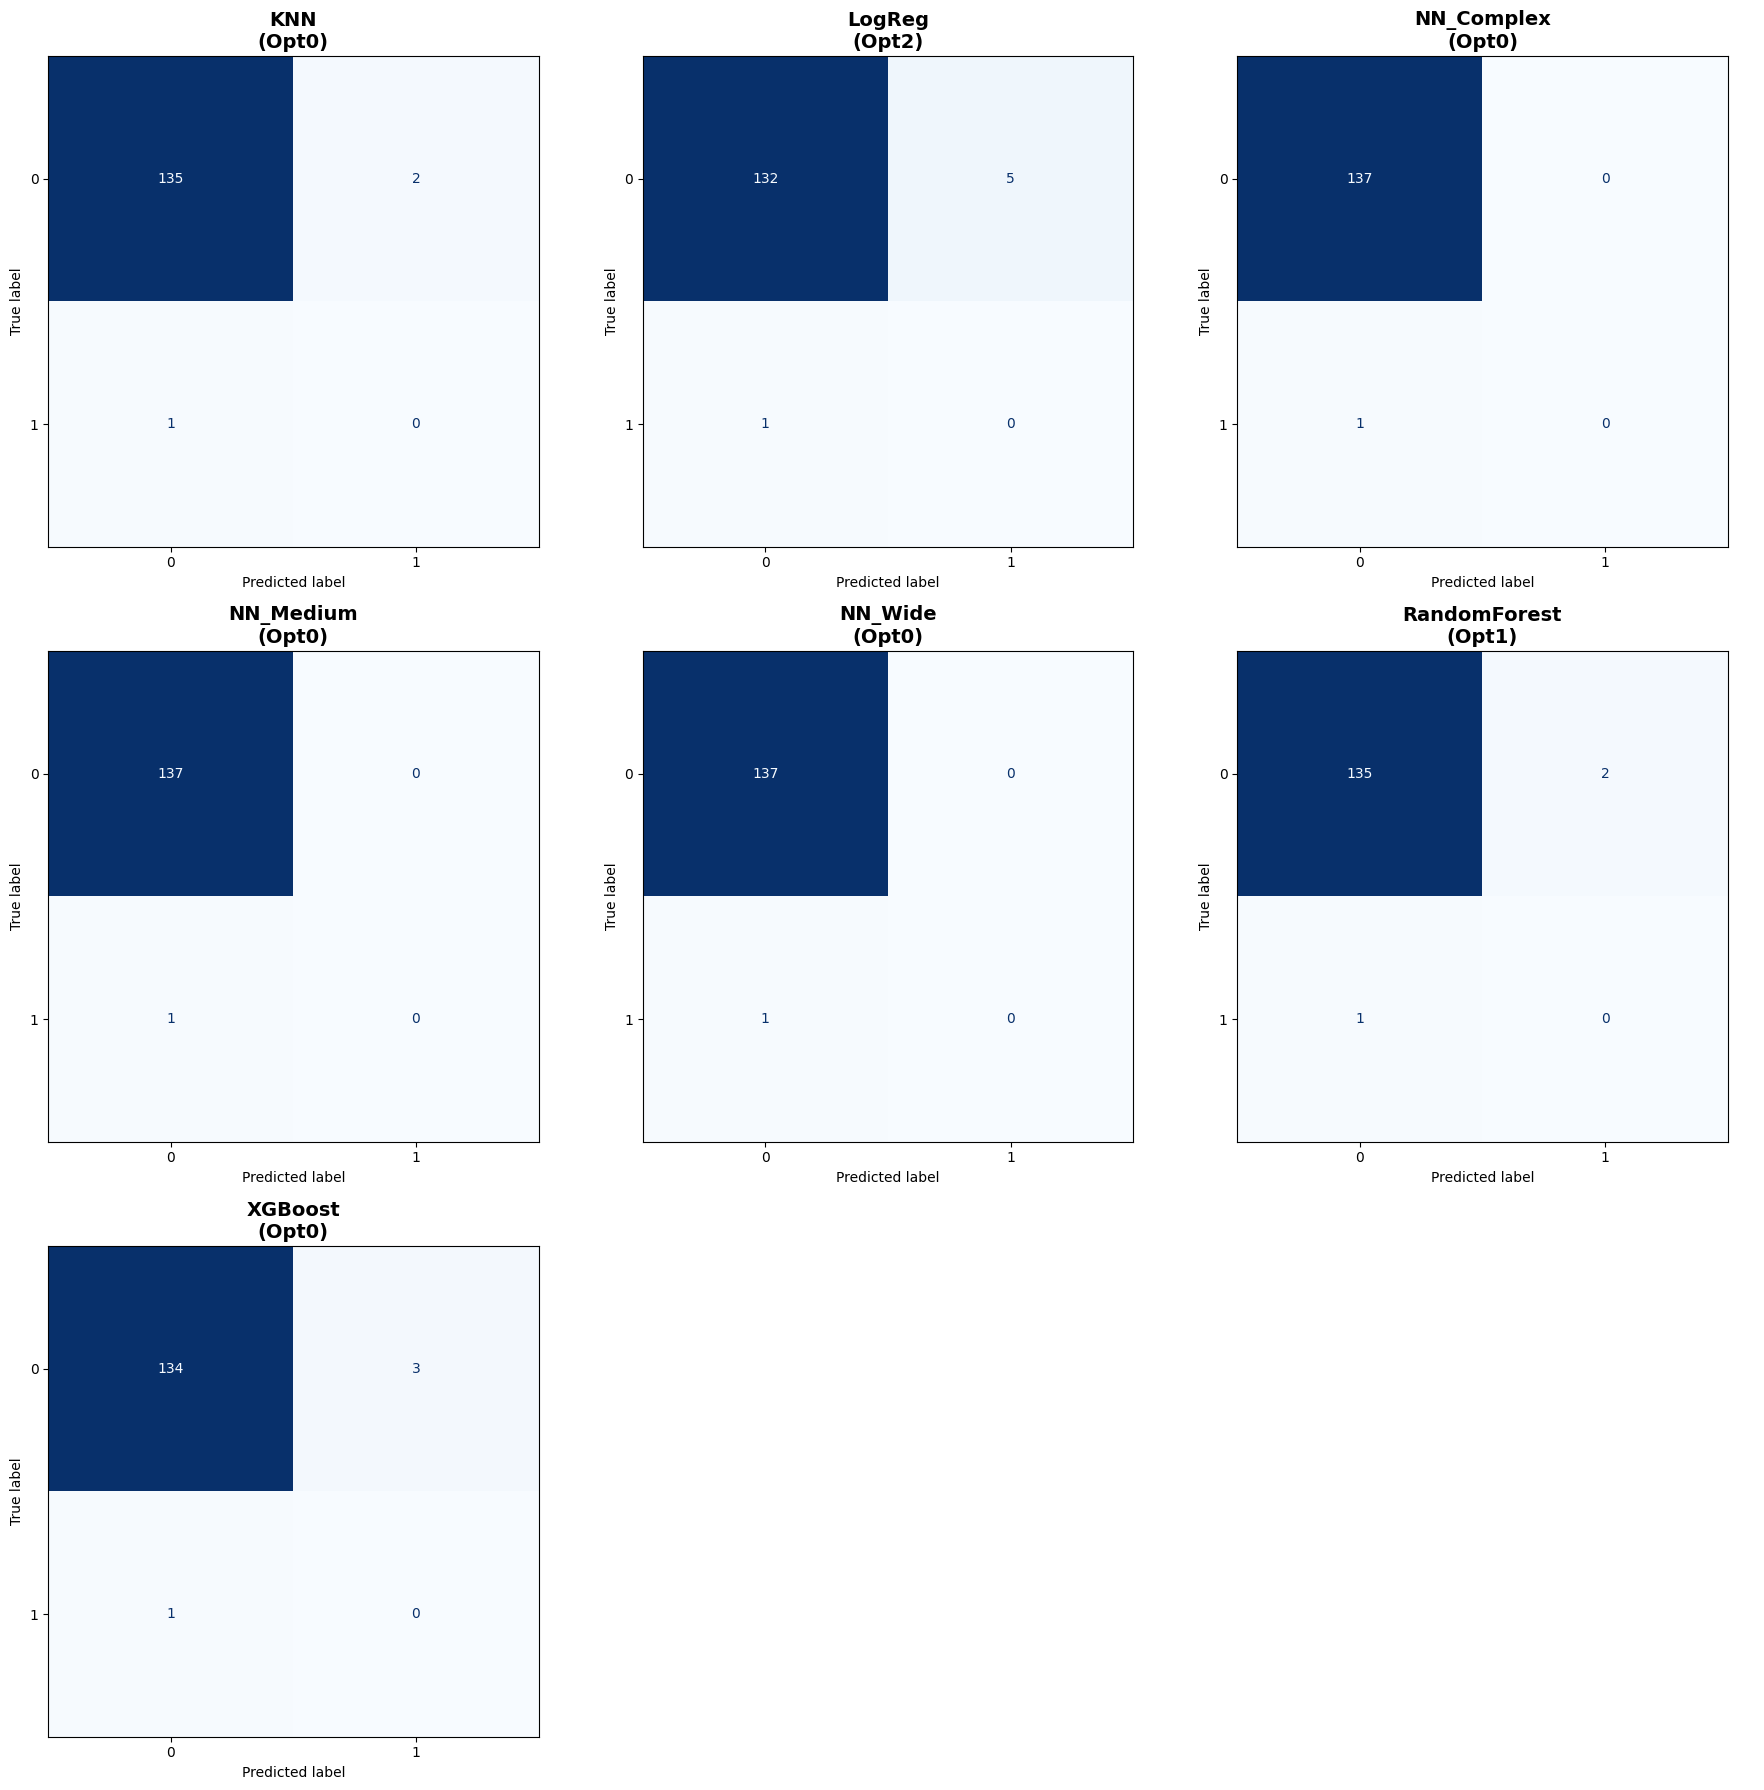


   >> Training Binary Models for: 'loose-foot-pump' (Optimizing Precision)
      Imbalance Ratio: 1:33.5

🚀 START EXPERIMENT: DETECTION_LOOSE-FOOT-PUMP
📊 Target Column: 'is_loose-foot-pump'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.1000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0000
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9493 (Stopped at epoch 20)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9493 (Stopped at epoch 15)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9493 (Stopped at epoch 9)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1167
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0623
   ✅ KNN: precision=0.2000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9493 (Stopped at epoch 40)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9493 (Stopped at epoch 22)
   🧠 Trai

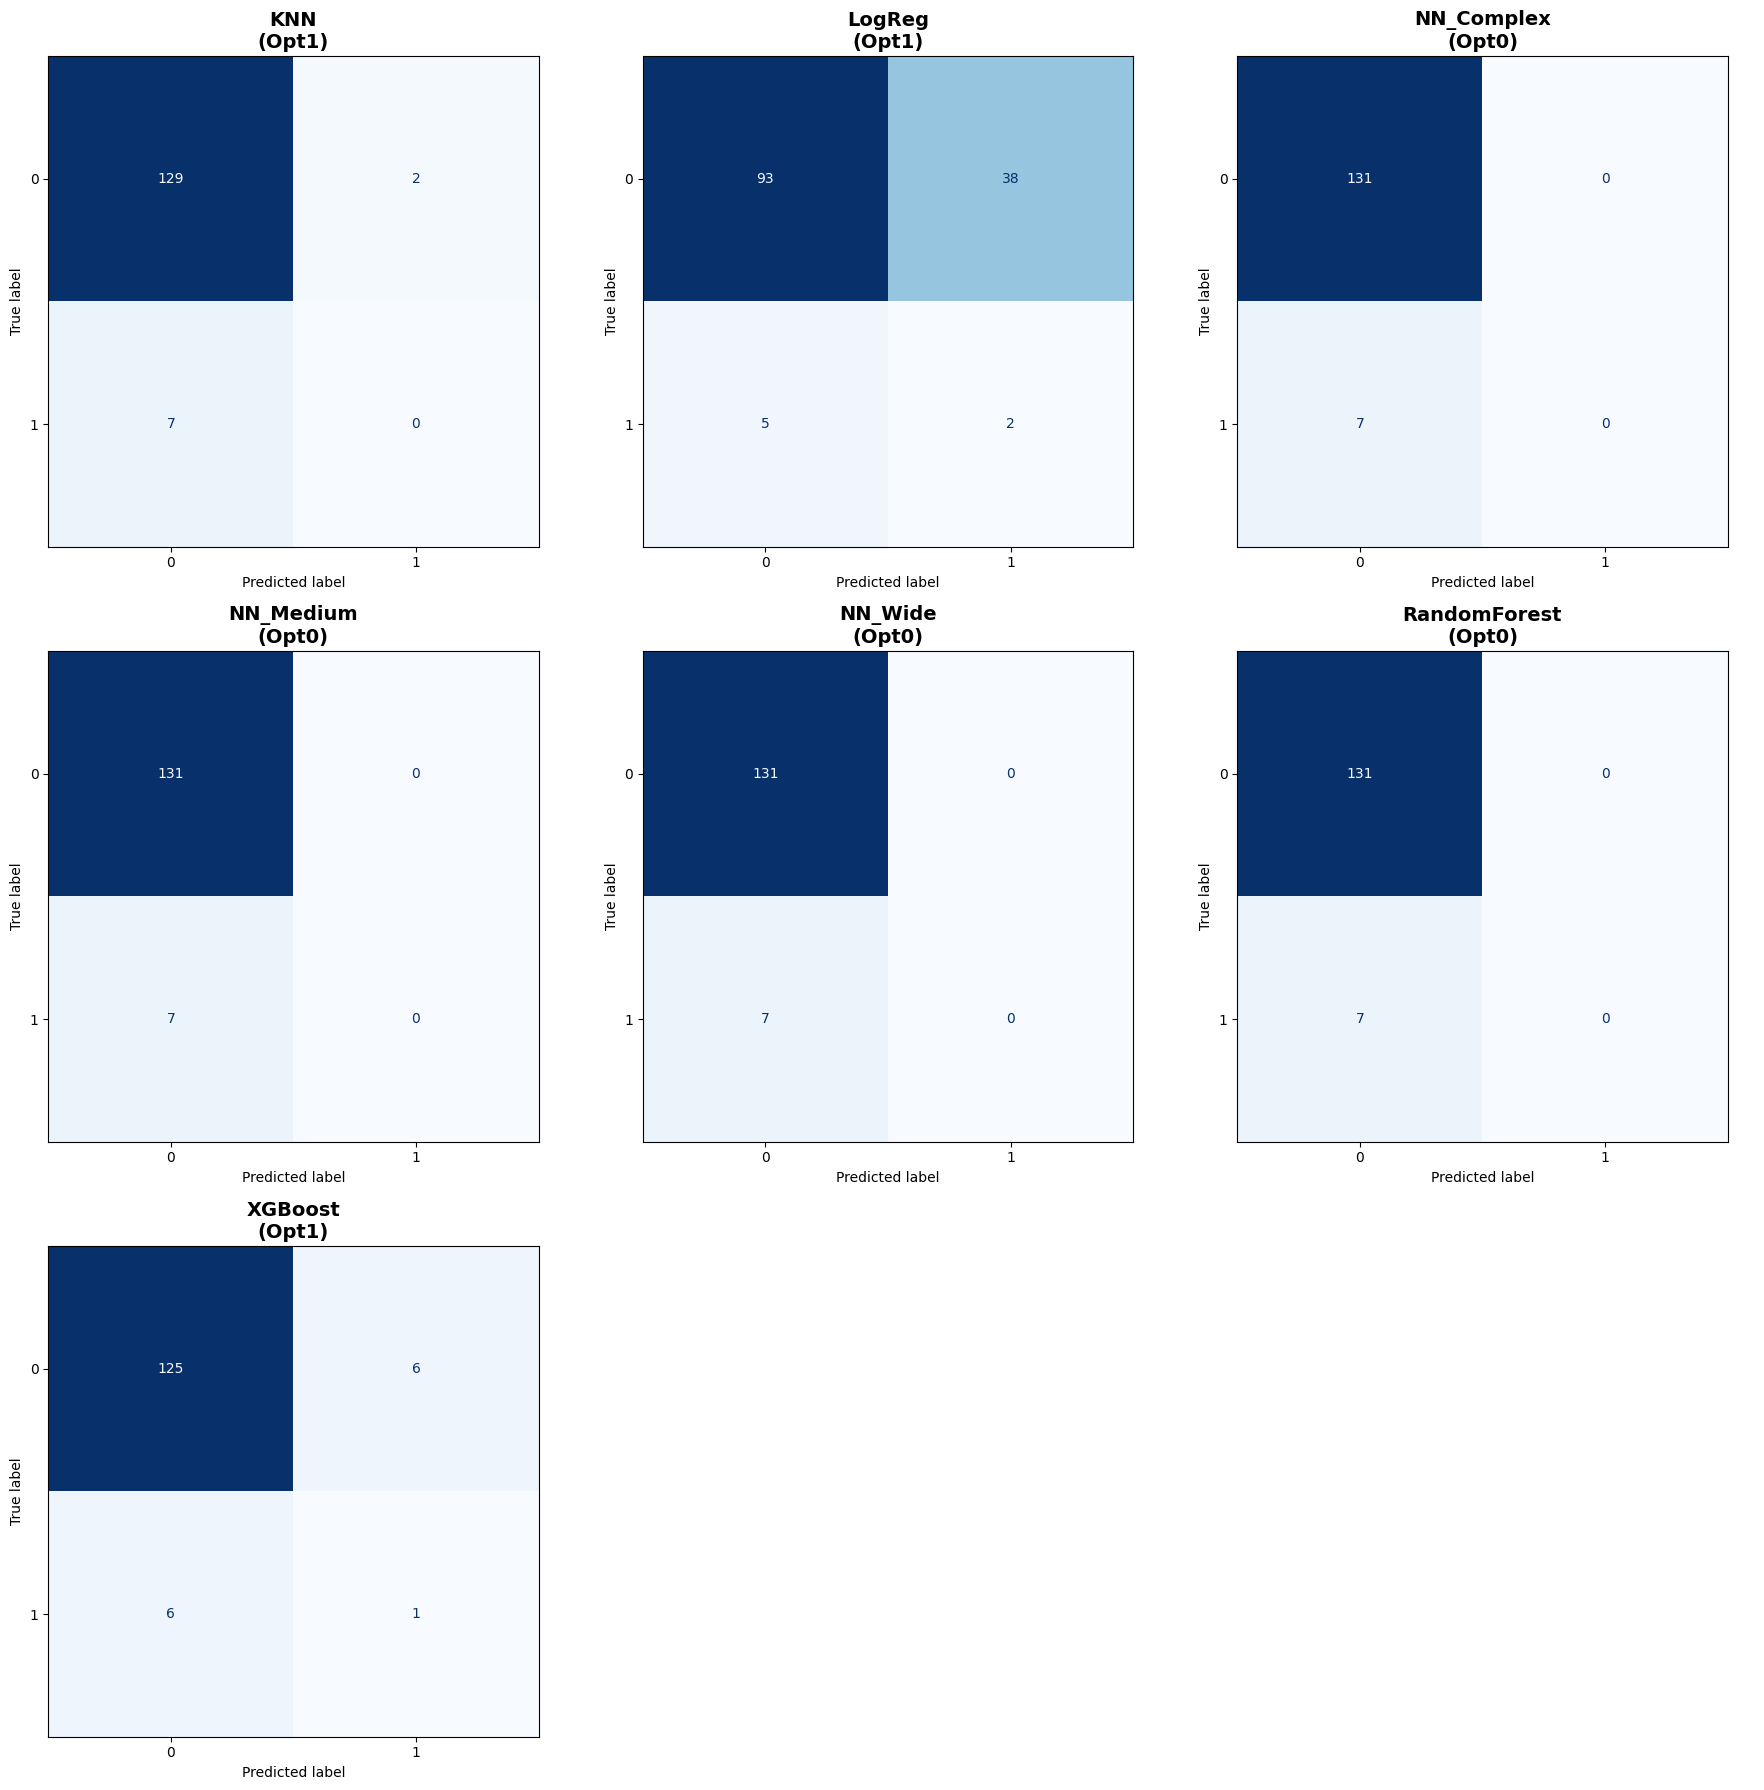


   >> Training Binary Models for: 'new-motor' (Optimizing Precision)
      Imbalance Ratio: 1:33.5

🚀 START EXPERIMENT: DETECTION_NEW-MOTOR
📊 Target Column: 'is_new-motor'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.1500
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1400
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9565 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9565 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9565 (Stopped at epoch 6)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.0604
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0356
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9565 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9565 (Stopped at epoch 9)
   🧠 Training Neural Network: 

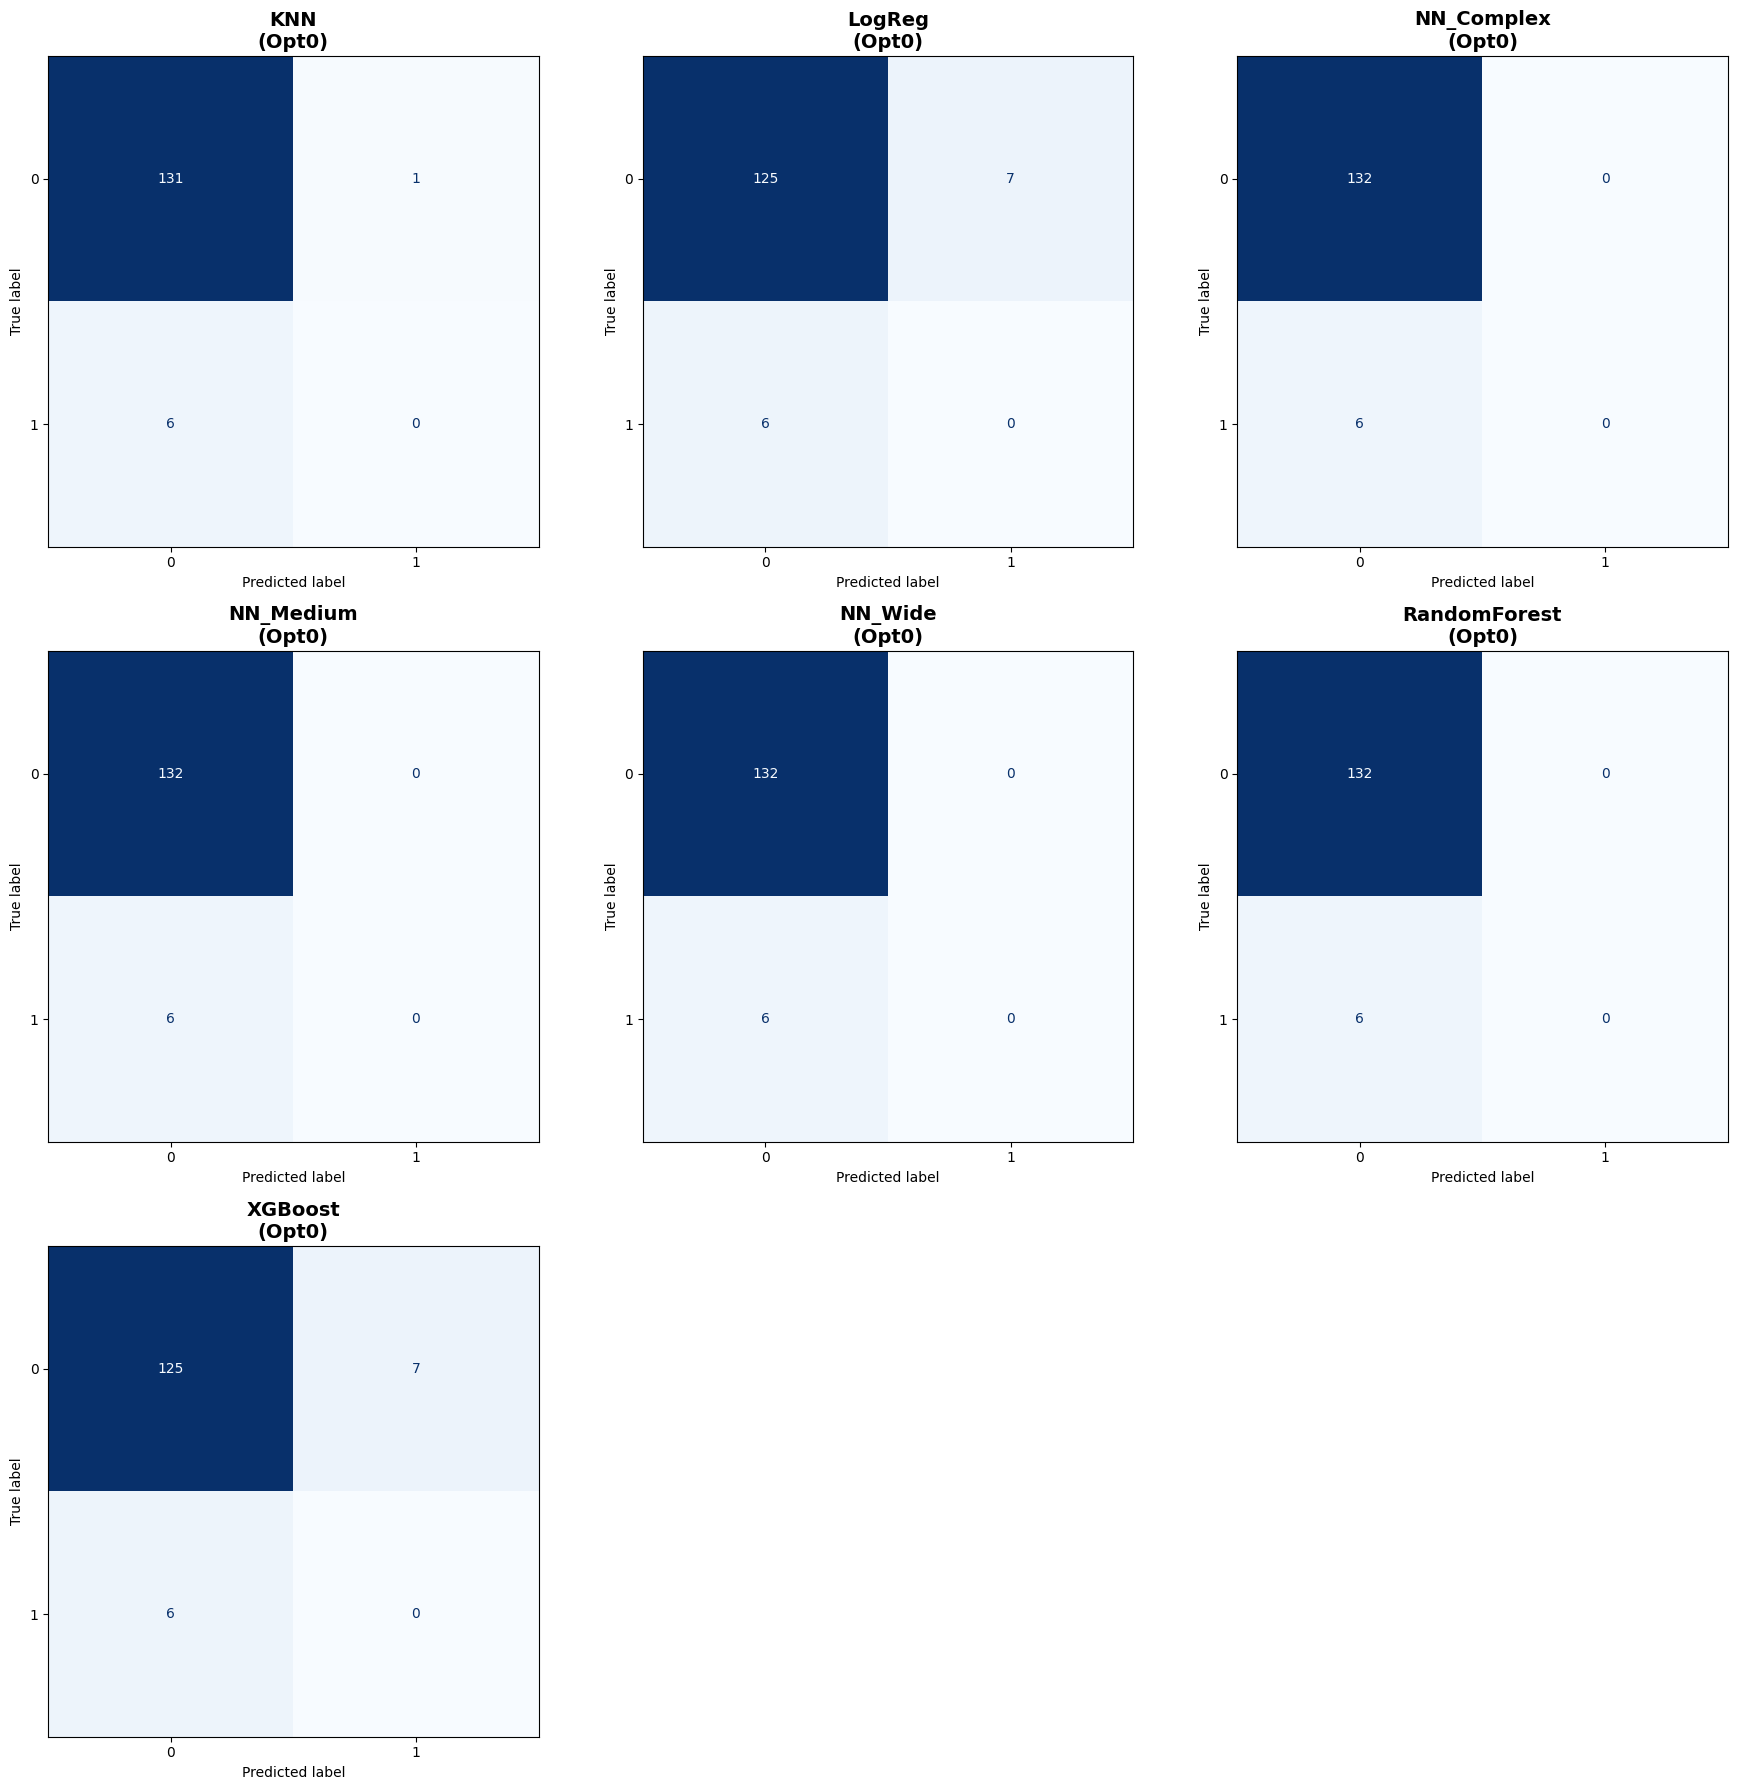


   >> Training Binary Models for: 'soft-foot' (Optimizing Precision)
      Imbalance Ratio: 1:18.7

🚀 START EXPERIMENT: DETECTION_SOFT-FOOT
📊 Target Column: 'is_soft-foot'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.6000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.2283
   ✅ KNN: precision=0.4000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9493 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9493 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9493 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.2333
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.0947
   ✅ KNN: precision=0.2667
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9493 (Stopped at epoch 25)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9493 (Stopped at epoch 15)
   🧠 Training Neural Networ

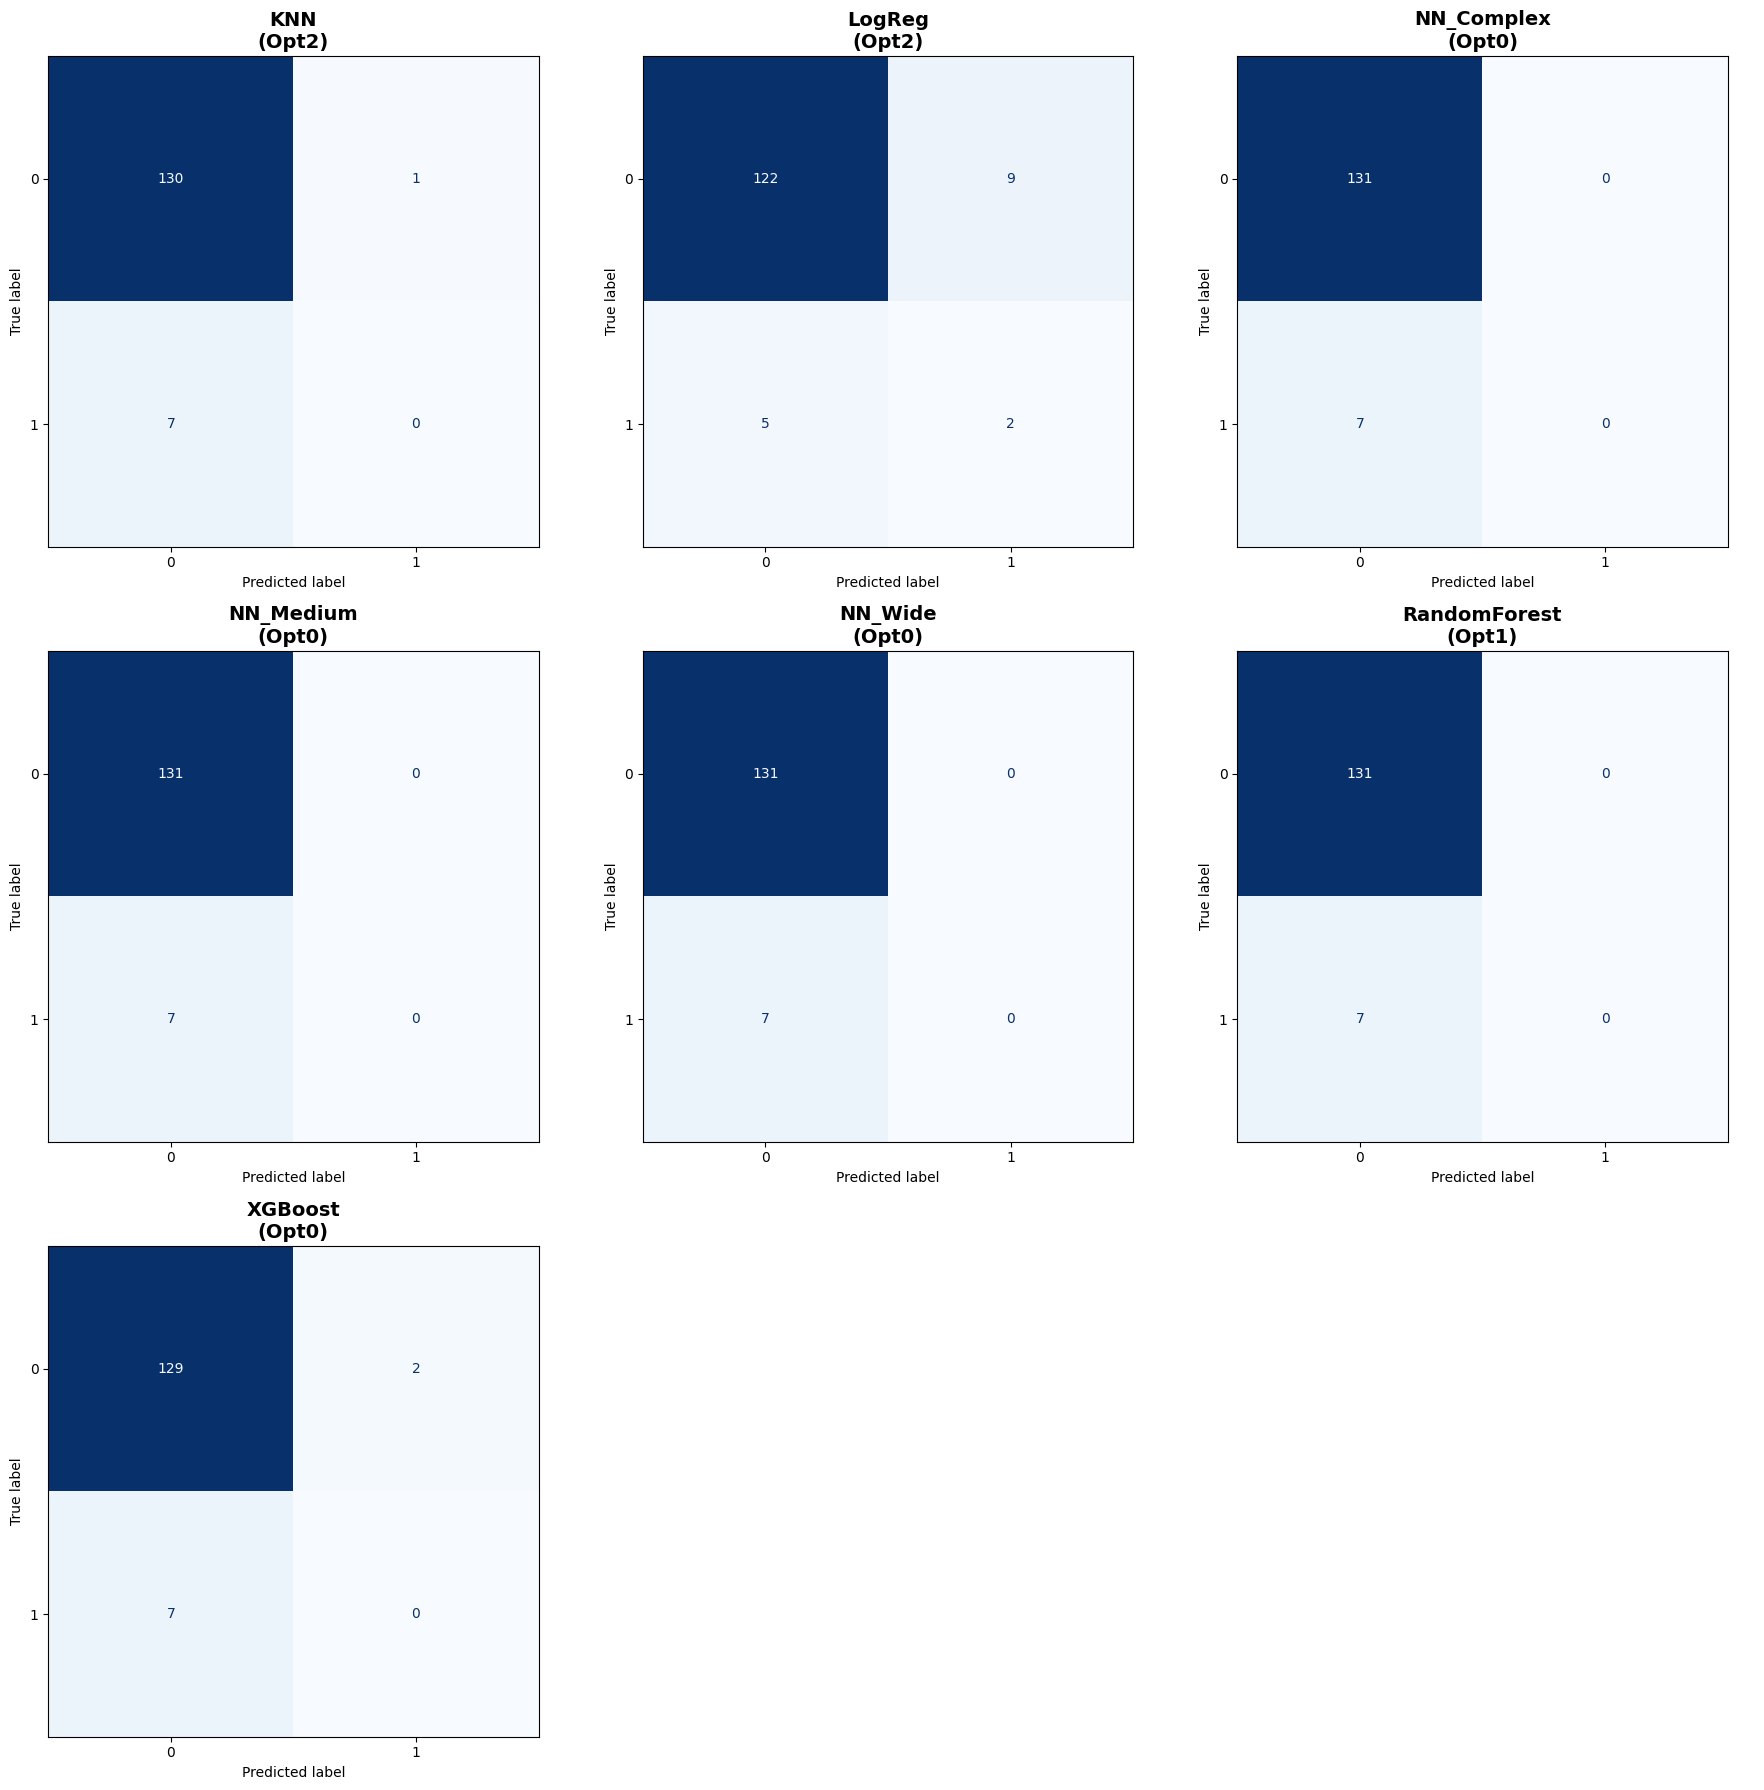


   >> Training Binary Models for: 'stator-short' (Optimizing Precision)
      Imbalance Ratio: 1:22.0

🚀 START EXPERIMENT: DETECTION_STATOR-SHORT
📊 Target Column: 'is_stator-short'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.4000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.5033
   ✅ KNN: precision=0.7500
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9638 (Stopped at epoch 11)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9638 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9638 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1500
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.0820
   ✅ KNN: precision=0.8000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9638 (Stopped at epoch 35)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9638 (Stopped at epoch 17)
   🧠 Training Neur

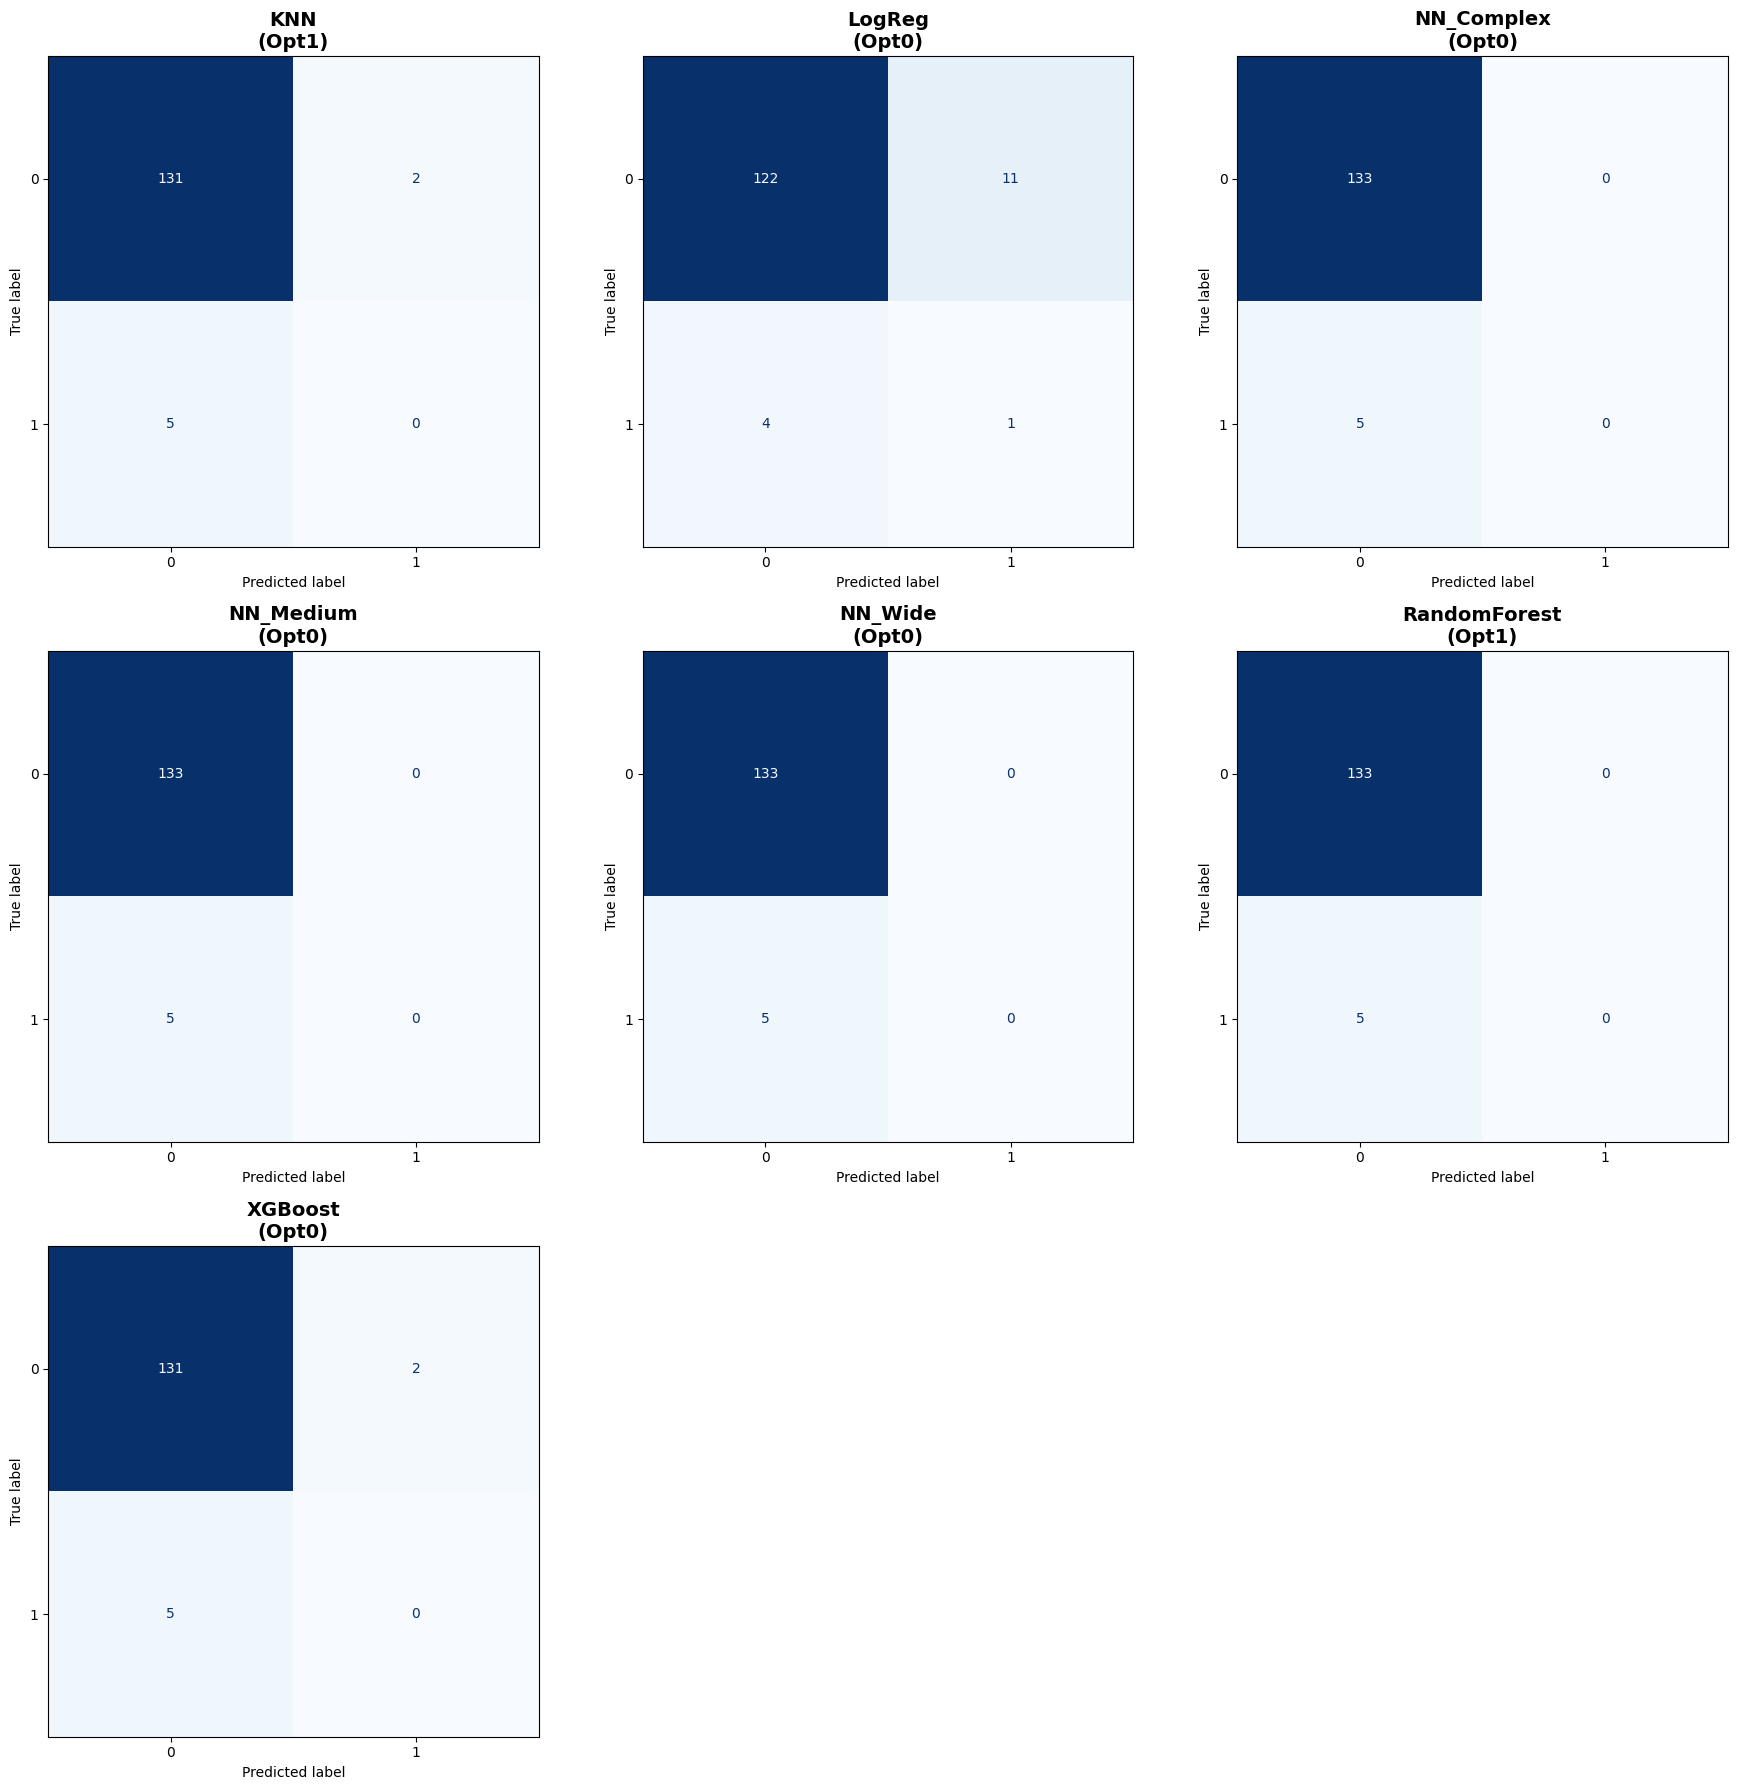


   >> Training Binary Models for: 'align-angular' (Optimizing Precision)
      Imbalance Ratio: 1:26.6

🚀 START EXPERIMENT: DETECTION_ALIGN-ANGULAR
📊 Target Column: 'is_align-angular'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.3917
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.3536
   ✅ KNN: precision=0.7000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9783 (Stopped at epoch 15)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9783 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9783 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4587
   ✅ RandomForest: precision=0.5000
   ✅ LogReg: precision=0.2150
   ✅ KNN: precision=0.4333
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9783 (Stopped at epoch 32)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9783 (Stopped at epoch 20)
   🧠 Training N

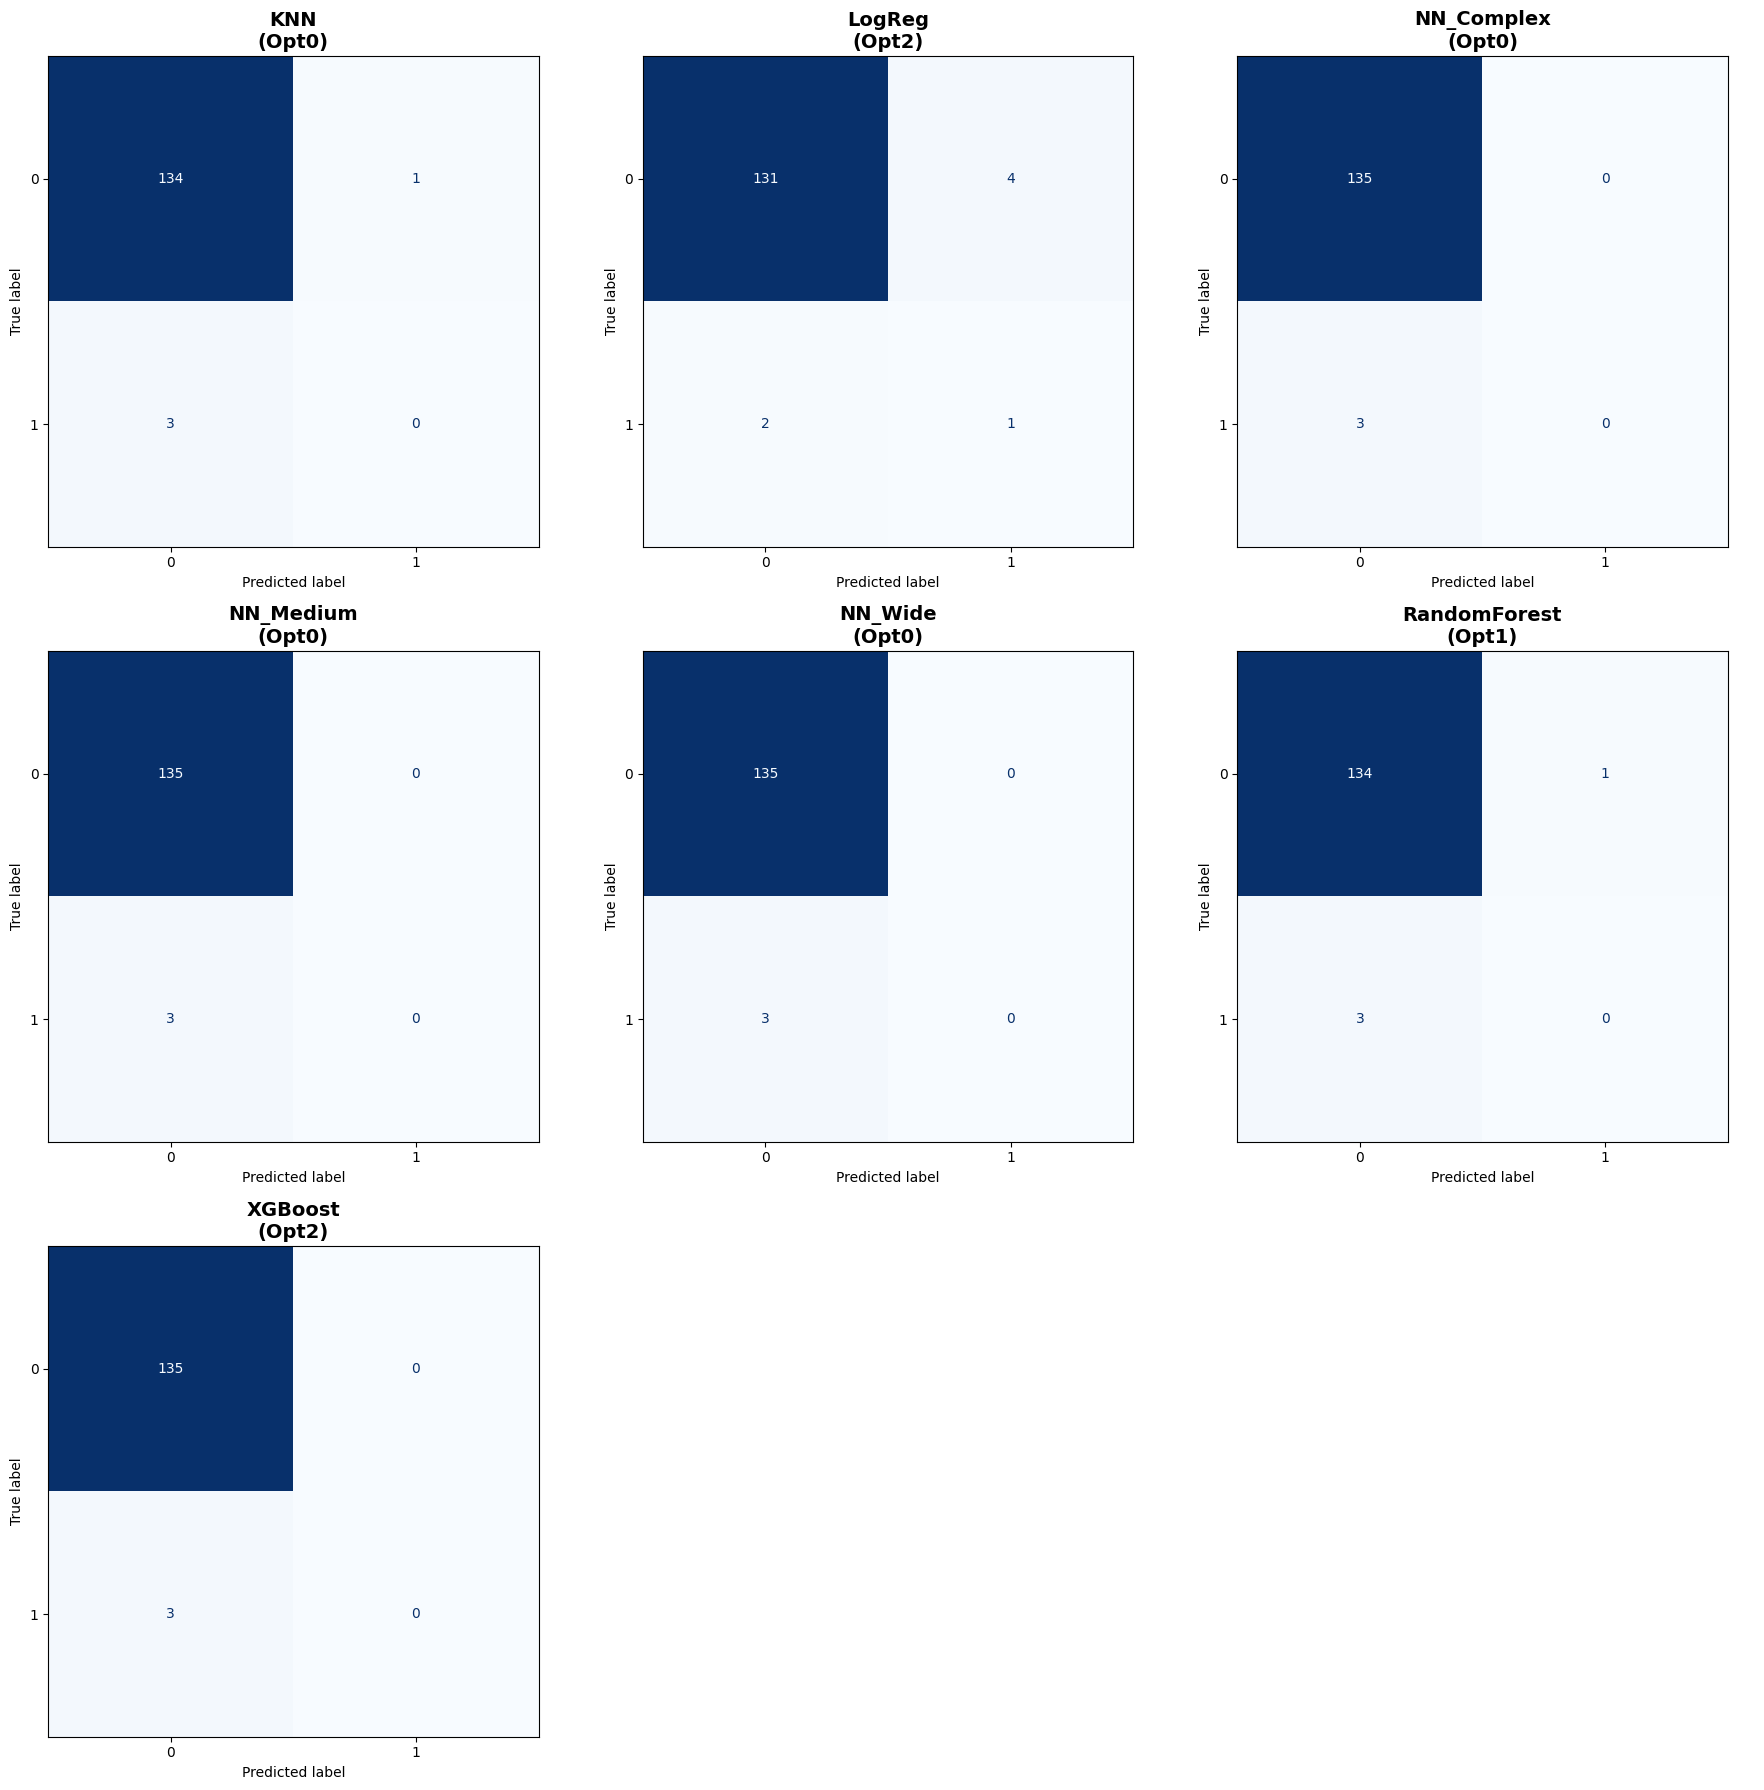


   >> Training Binary Models for: 'align-combination' (Optimizing Precision)
      Imbalance Ratio: 1:33.5

🚀 START EXPERIMENT: DETECTION_ALIGN-COMBINATION
📊 Target Column: 'is_align-combination'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.2439
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1709
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9928 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9928 (Stopped at epoch 8)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9928 (Stopped at epoch 10)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.1667
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.1737
   ✅ KNN: precision=0.3000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9928 (Stopped at epoch 39)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9928 (Stopped at epoch 24)
   🧠

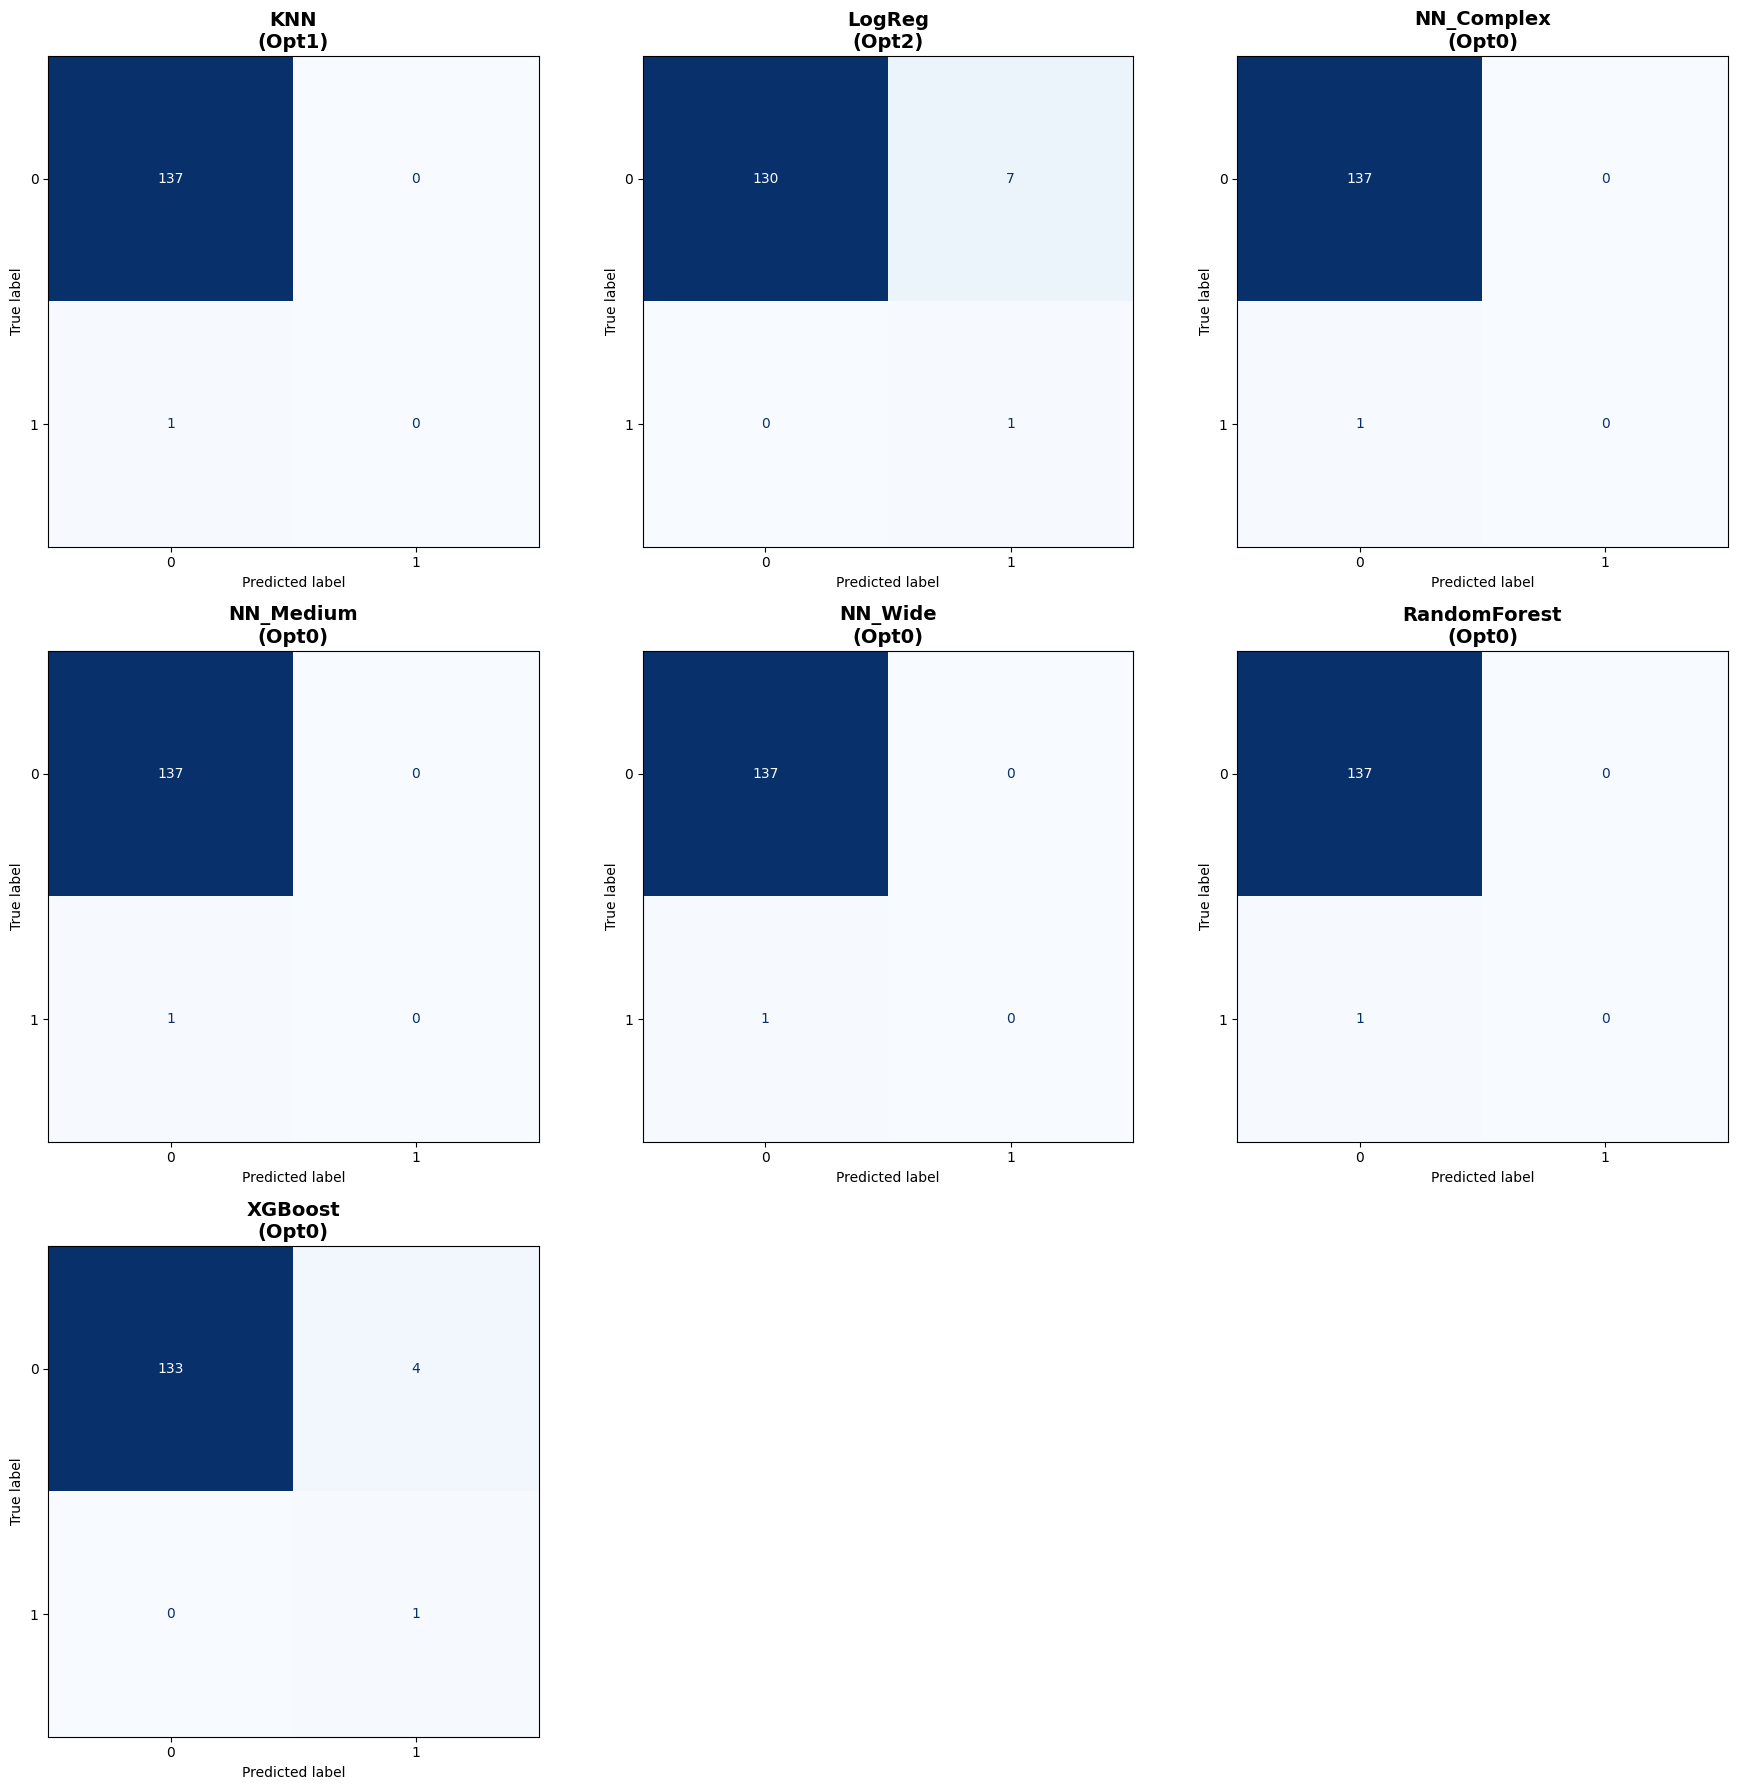


   >> Training Binary Models for: 'align-parallel' (Optimizing Precision)
      Imbalance Ratio: 1:33.5

🚀 START EXPERIMENT: DETECTION_ALIGN-PARALLEL
📊 Target Column: 'is_align-parallel'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.6667
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.3238
   ✅ KNN: precision=0.6000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=1.0000 (Stopped at epoch 21)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=1.0000 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=1.0000 (Stopped at epoch 16)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.3700
   ✅ RandomForest: precision=0.5000
   ✅ LogReg: precision=0.1547
   ✅ KNN: precision=0.6000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=1.0000 (Stopped at epoch 40)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=1.0000 (Stopped at epoch 23)
   🧠 Traini

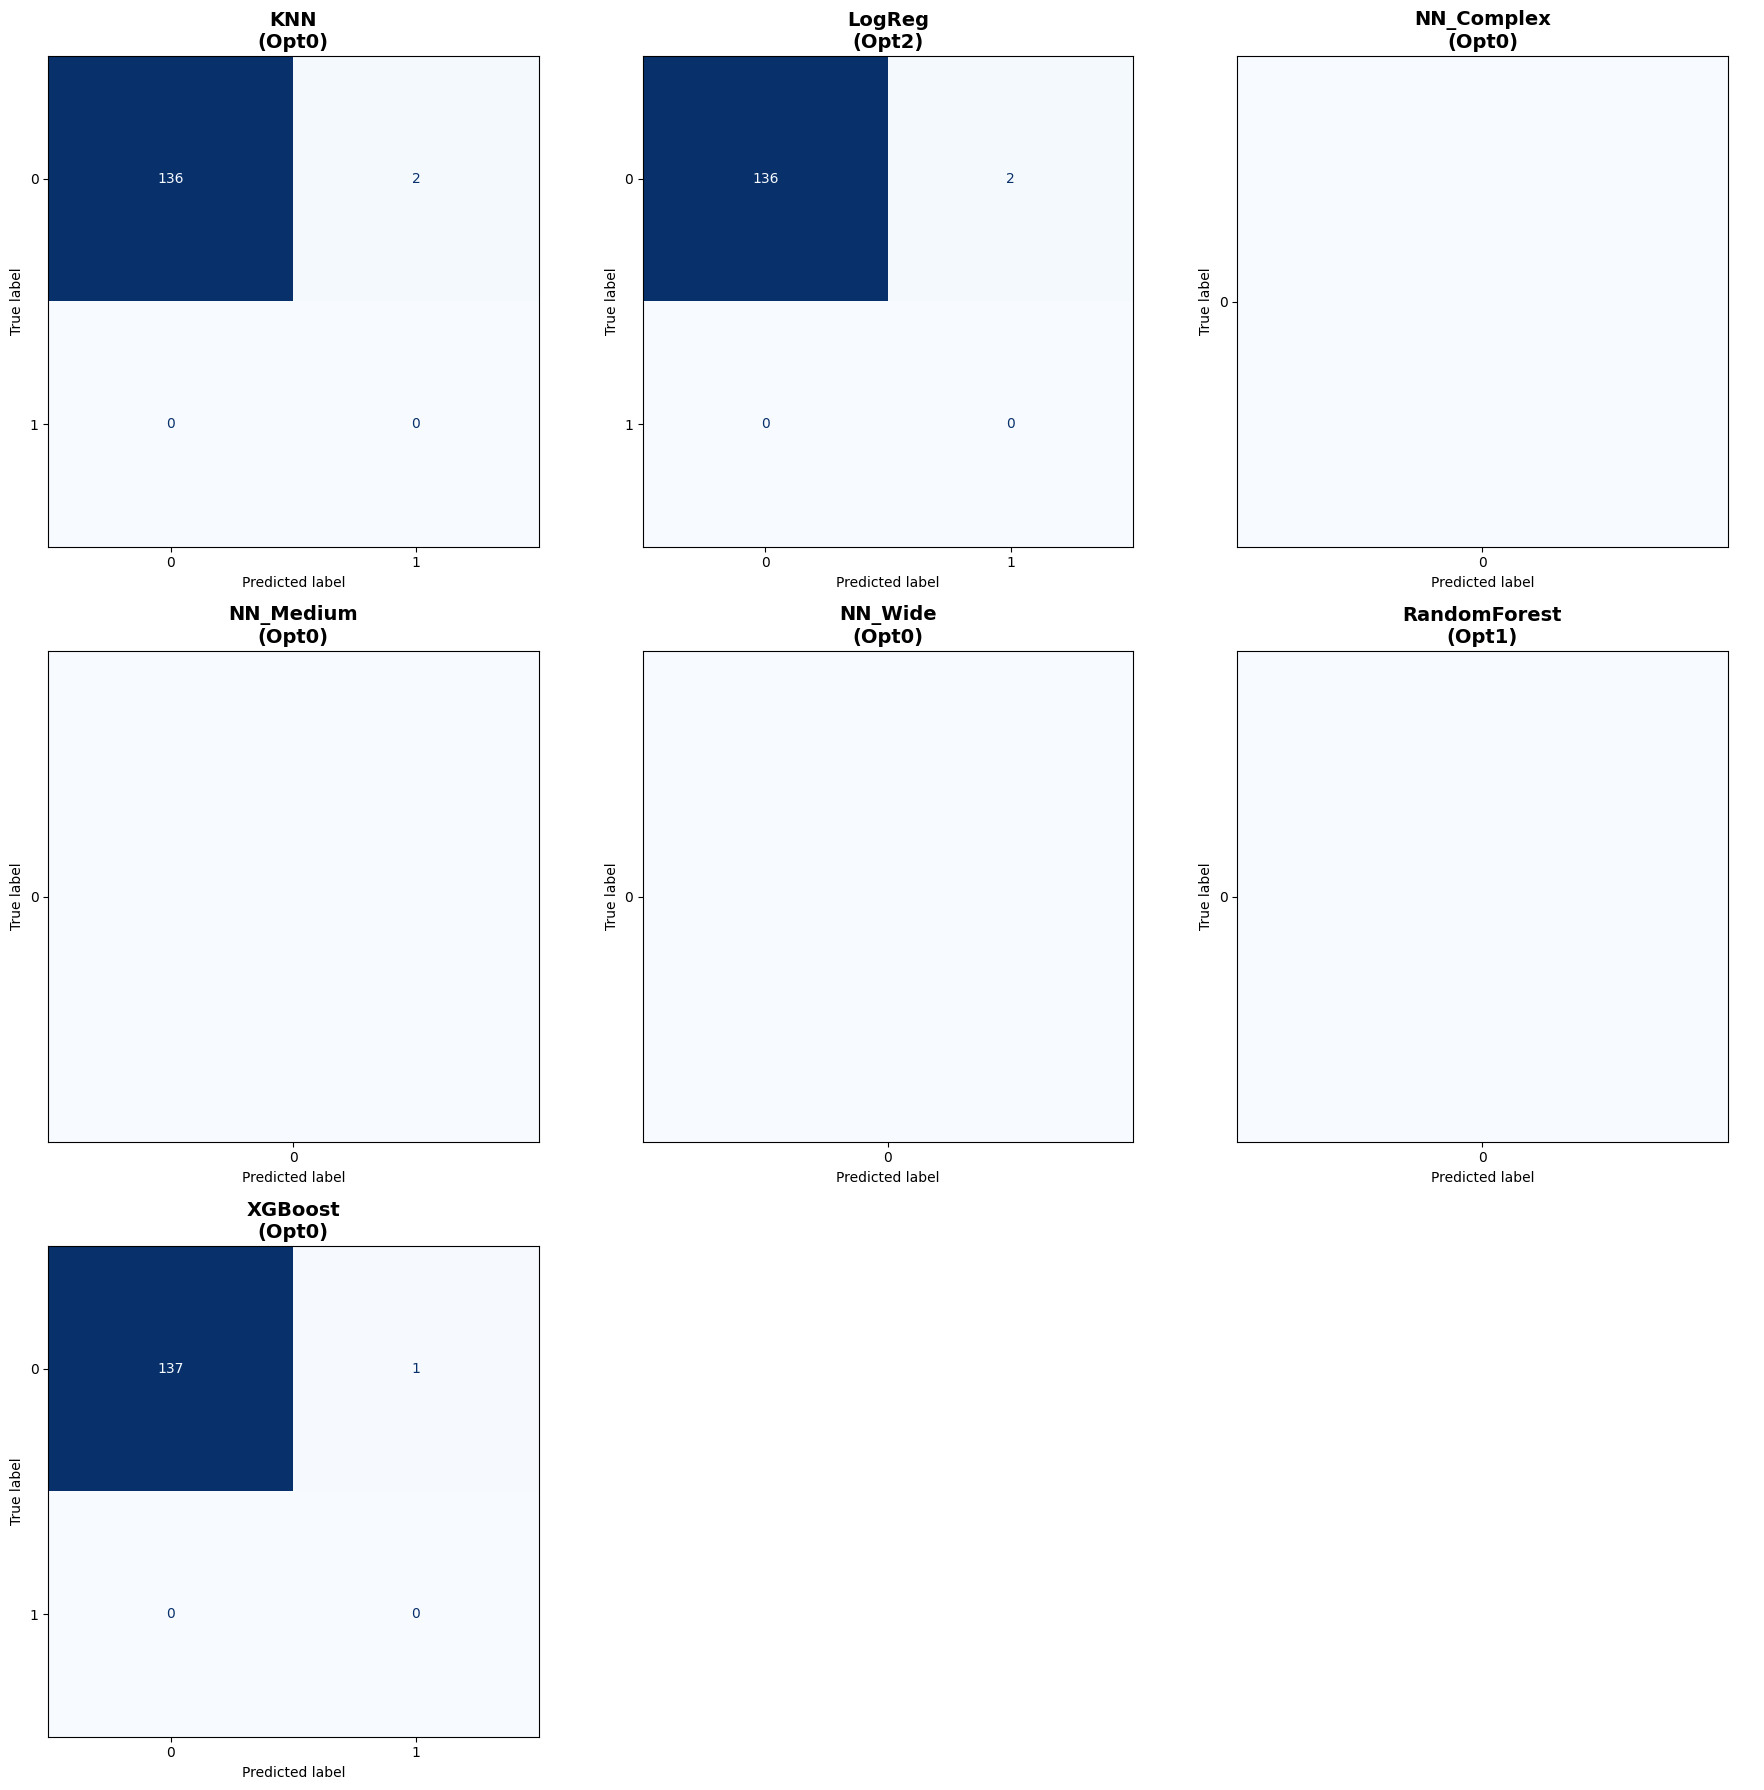


   >> Training Binary Models for: 'bent-shaft' (Optimizing Precision)
      ⚠️ Skipping bent-shaft: Too few positive samples (5)

   >> Training Binary Models for: 'cavitation-discharge' (Optimizing Precision)
      Imbalance Ratio: 1:26.6

🚀 START EXPERIMENT: DETECTION_CAVITATION-DISCHARGE
📊 Target Column: 'is_cavitation-discharge'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.5667
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.3800
   ✅ KNN: precision=0.6500
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9855 (Stopped at epoch 15)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9855 (Stopped at epoch 9)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9855 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4833
   ✅ RandomForest: precision=0.5000
   ✅ LogReg: precision=0.2496
   ✅ KNN: precision=0.5833
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: a

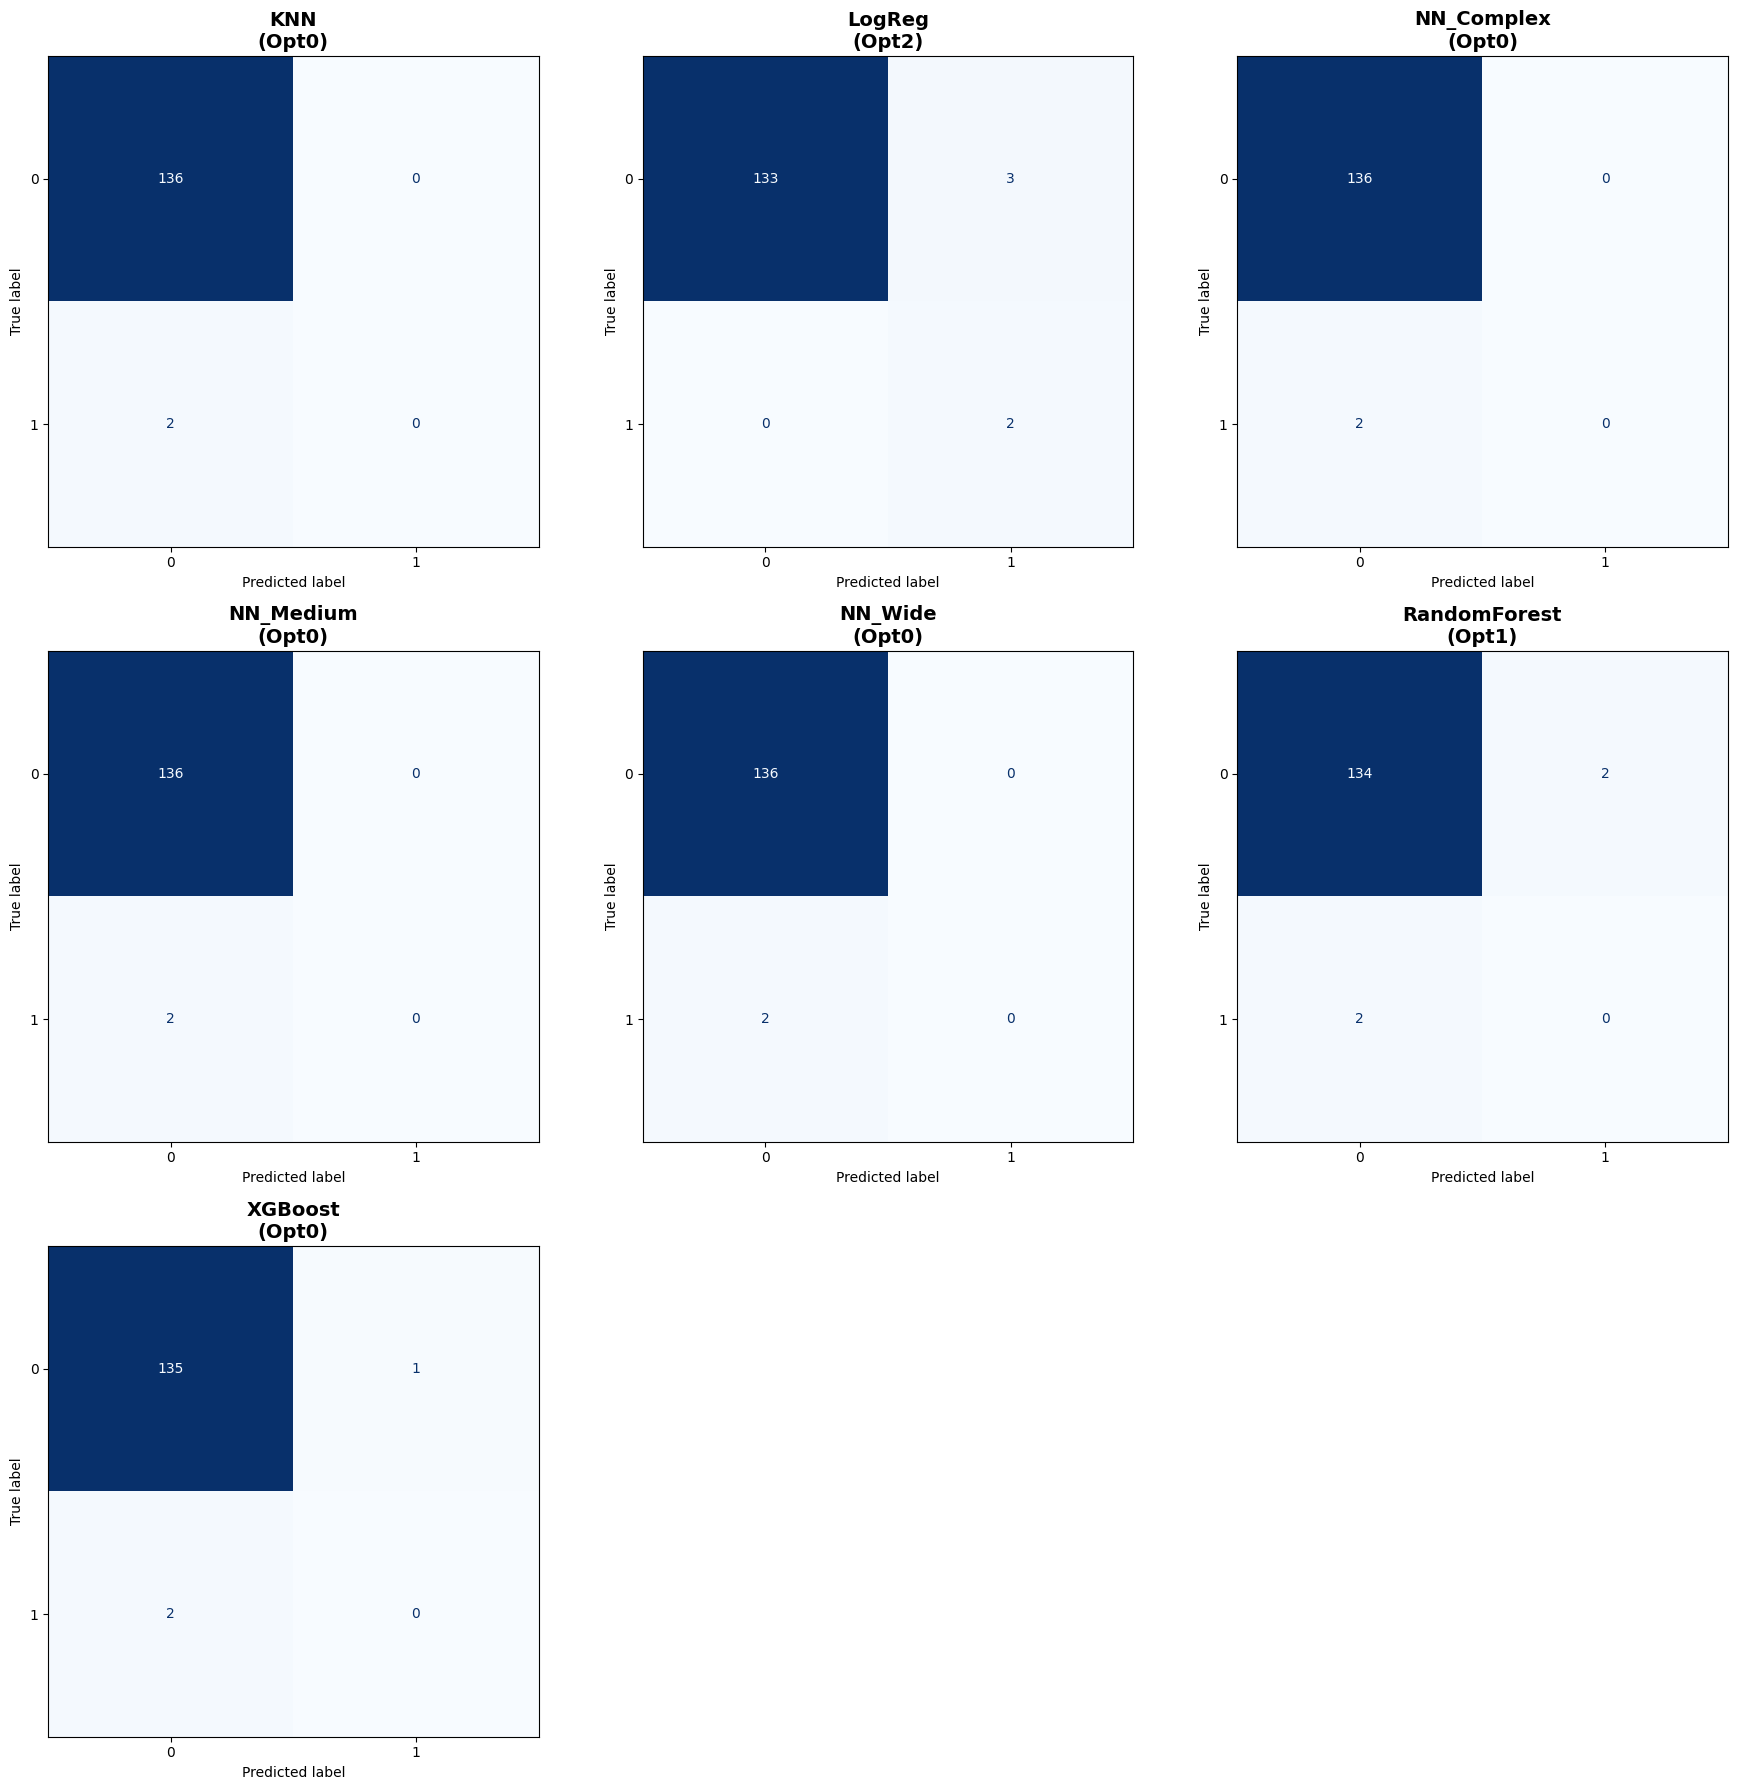


   >> Training Binary Models for: 'cavitation-suction' (Optimizing Precision)
      Imbalance Ratio: 1:45.0

🚀 START EXPERIMENT: DETECTION_CAVITATION-SUCTION
📊 Target Column: 'is_cavitation-suction'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.3500
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.3405
   ✅ KNN: precision=0.6000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9928 (Stopped at epoch 15)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9928 (Stopped at epoch 12)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9928 (Stopped at epoch 24)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.3708
   ✅ RandomForest: precision=0.2000
   ✅ LogReg: precision=0.0961
   ✅ KNN: precision=0.1000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9928 (Stopped at epoch 27)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9928 (Stopped at epoch 15)

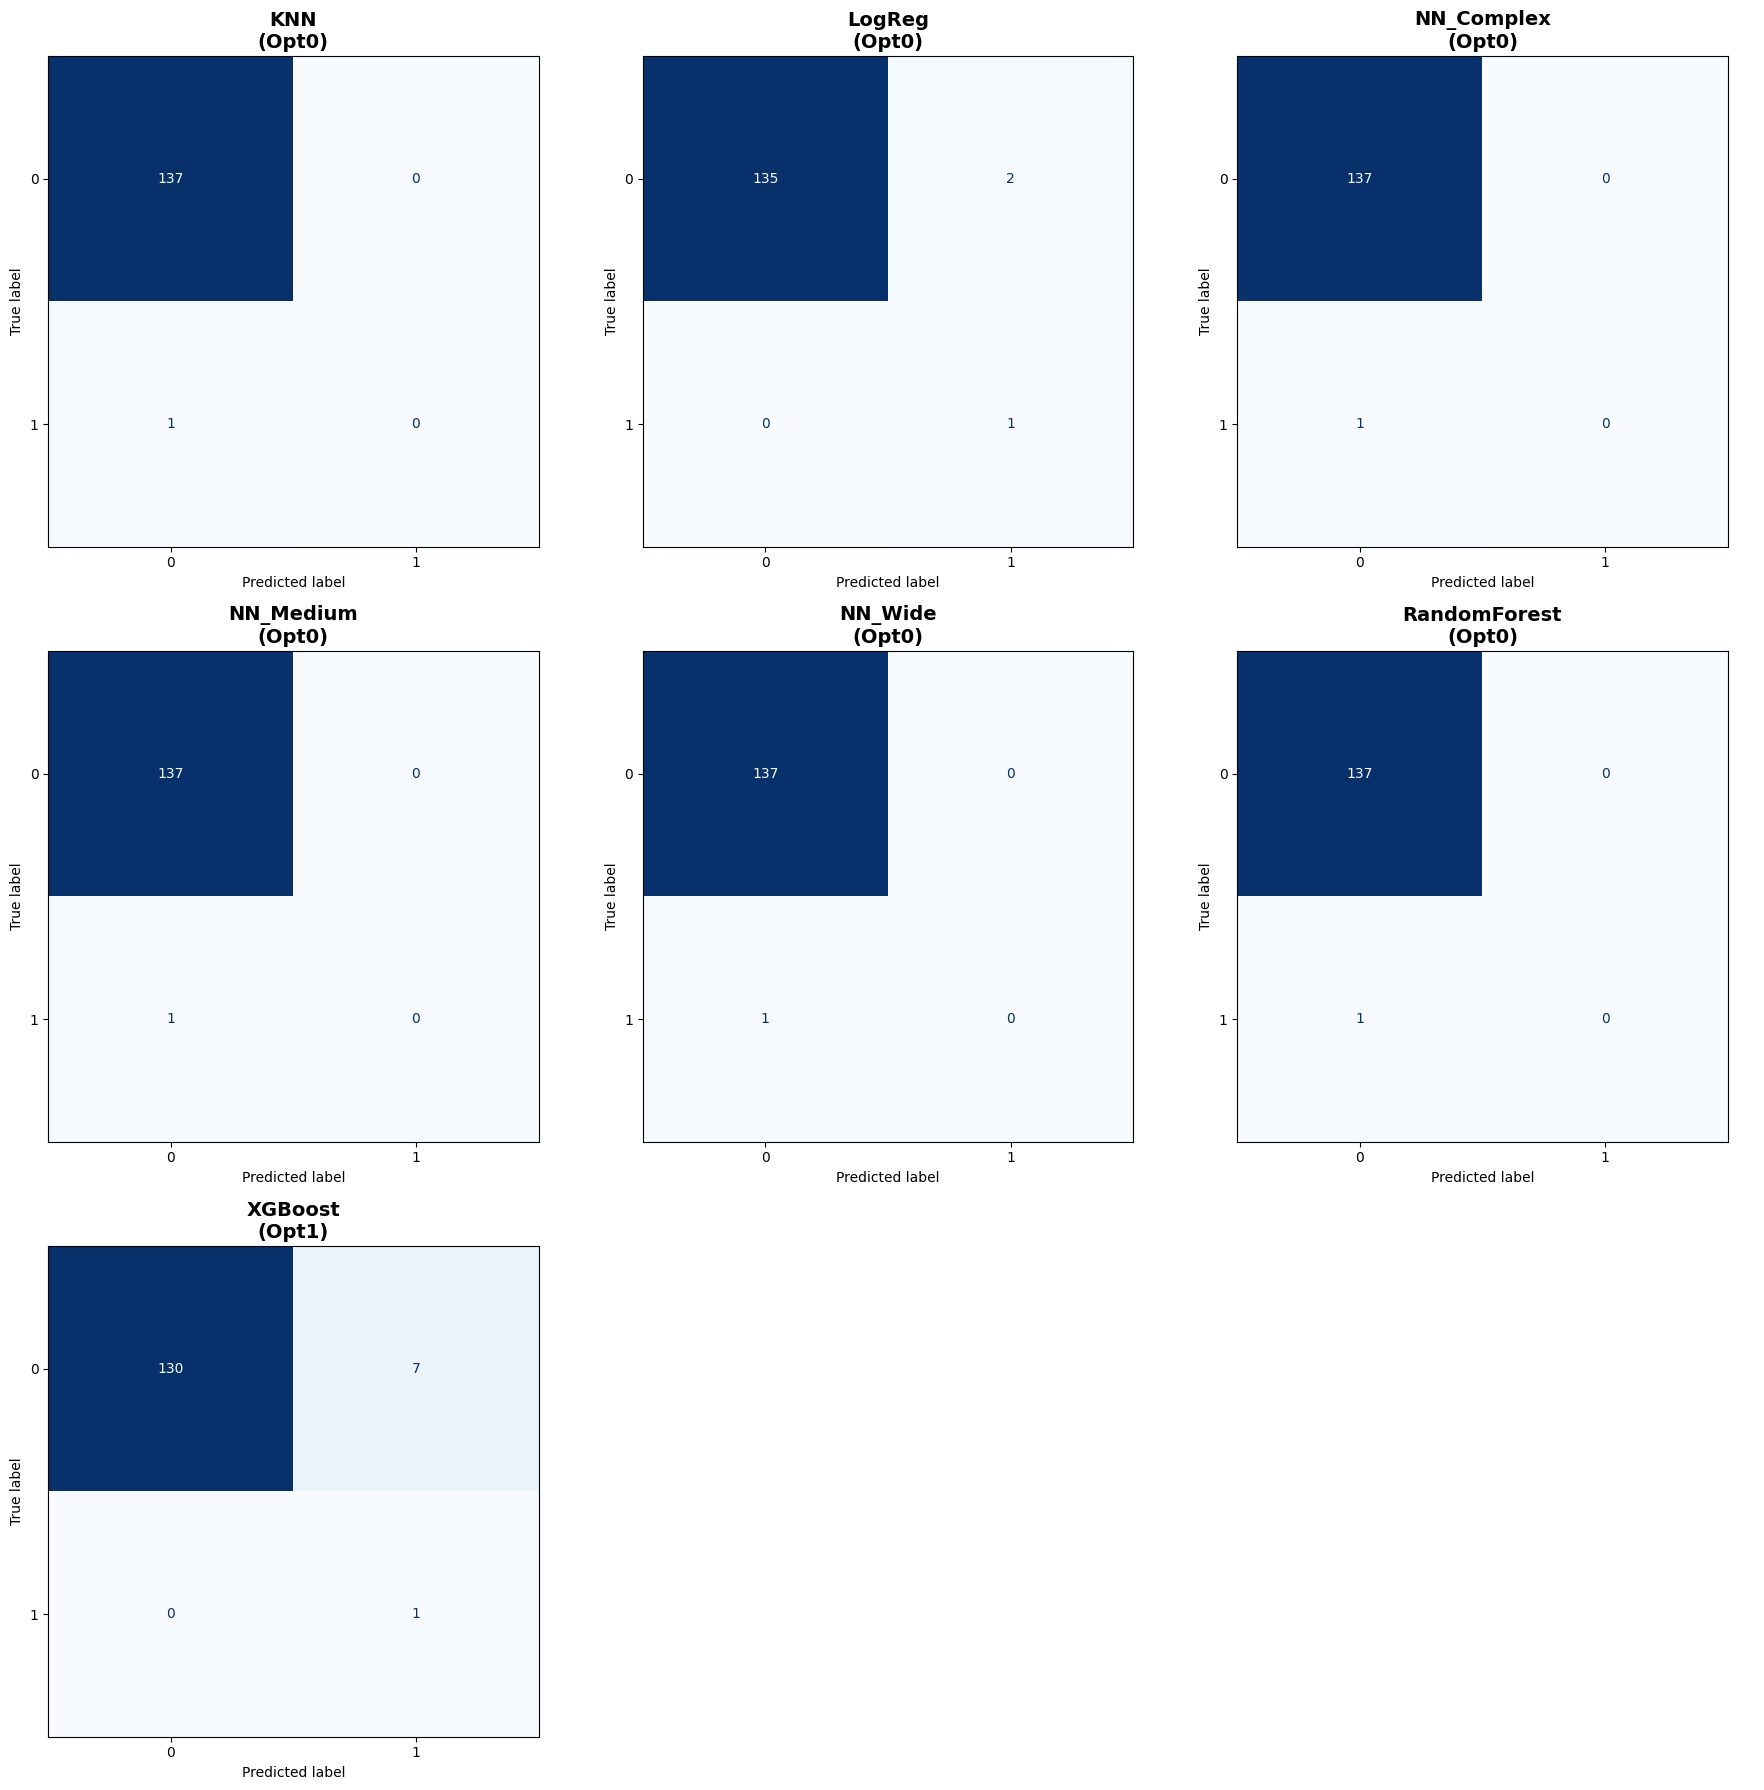


   >> Training Binary Models for: 'coupling' (Optimizing Precision)
      Imbalance Ratio: 1:45.0

🚀 START EXPERIMENT: DETECTION_COUPLING
📊 Target Column: 'is_coupling'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.1700
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.2400
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9710 (Stopped at epoch 14)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9710 (Stopped at epoch 7)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9710 (Stopped at epoch 10)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4500
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.0988
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9710 (Stopped at epoch 23)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9710 (Stopped at epoch 12)
   🧠 Training Neural Network: 

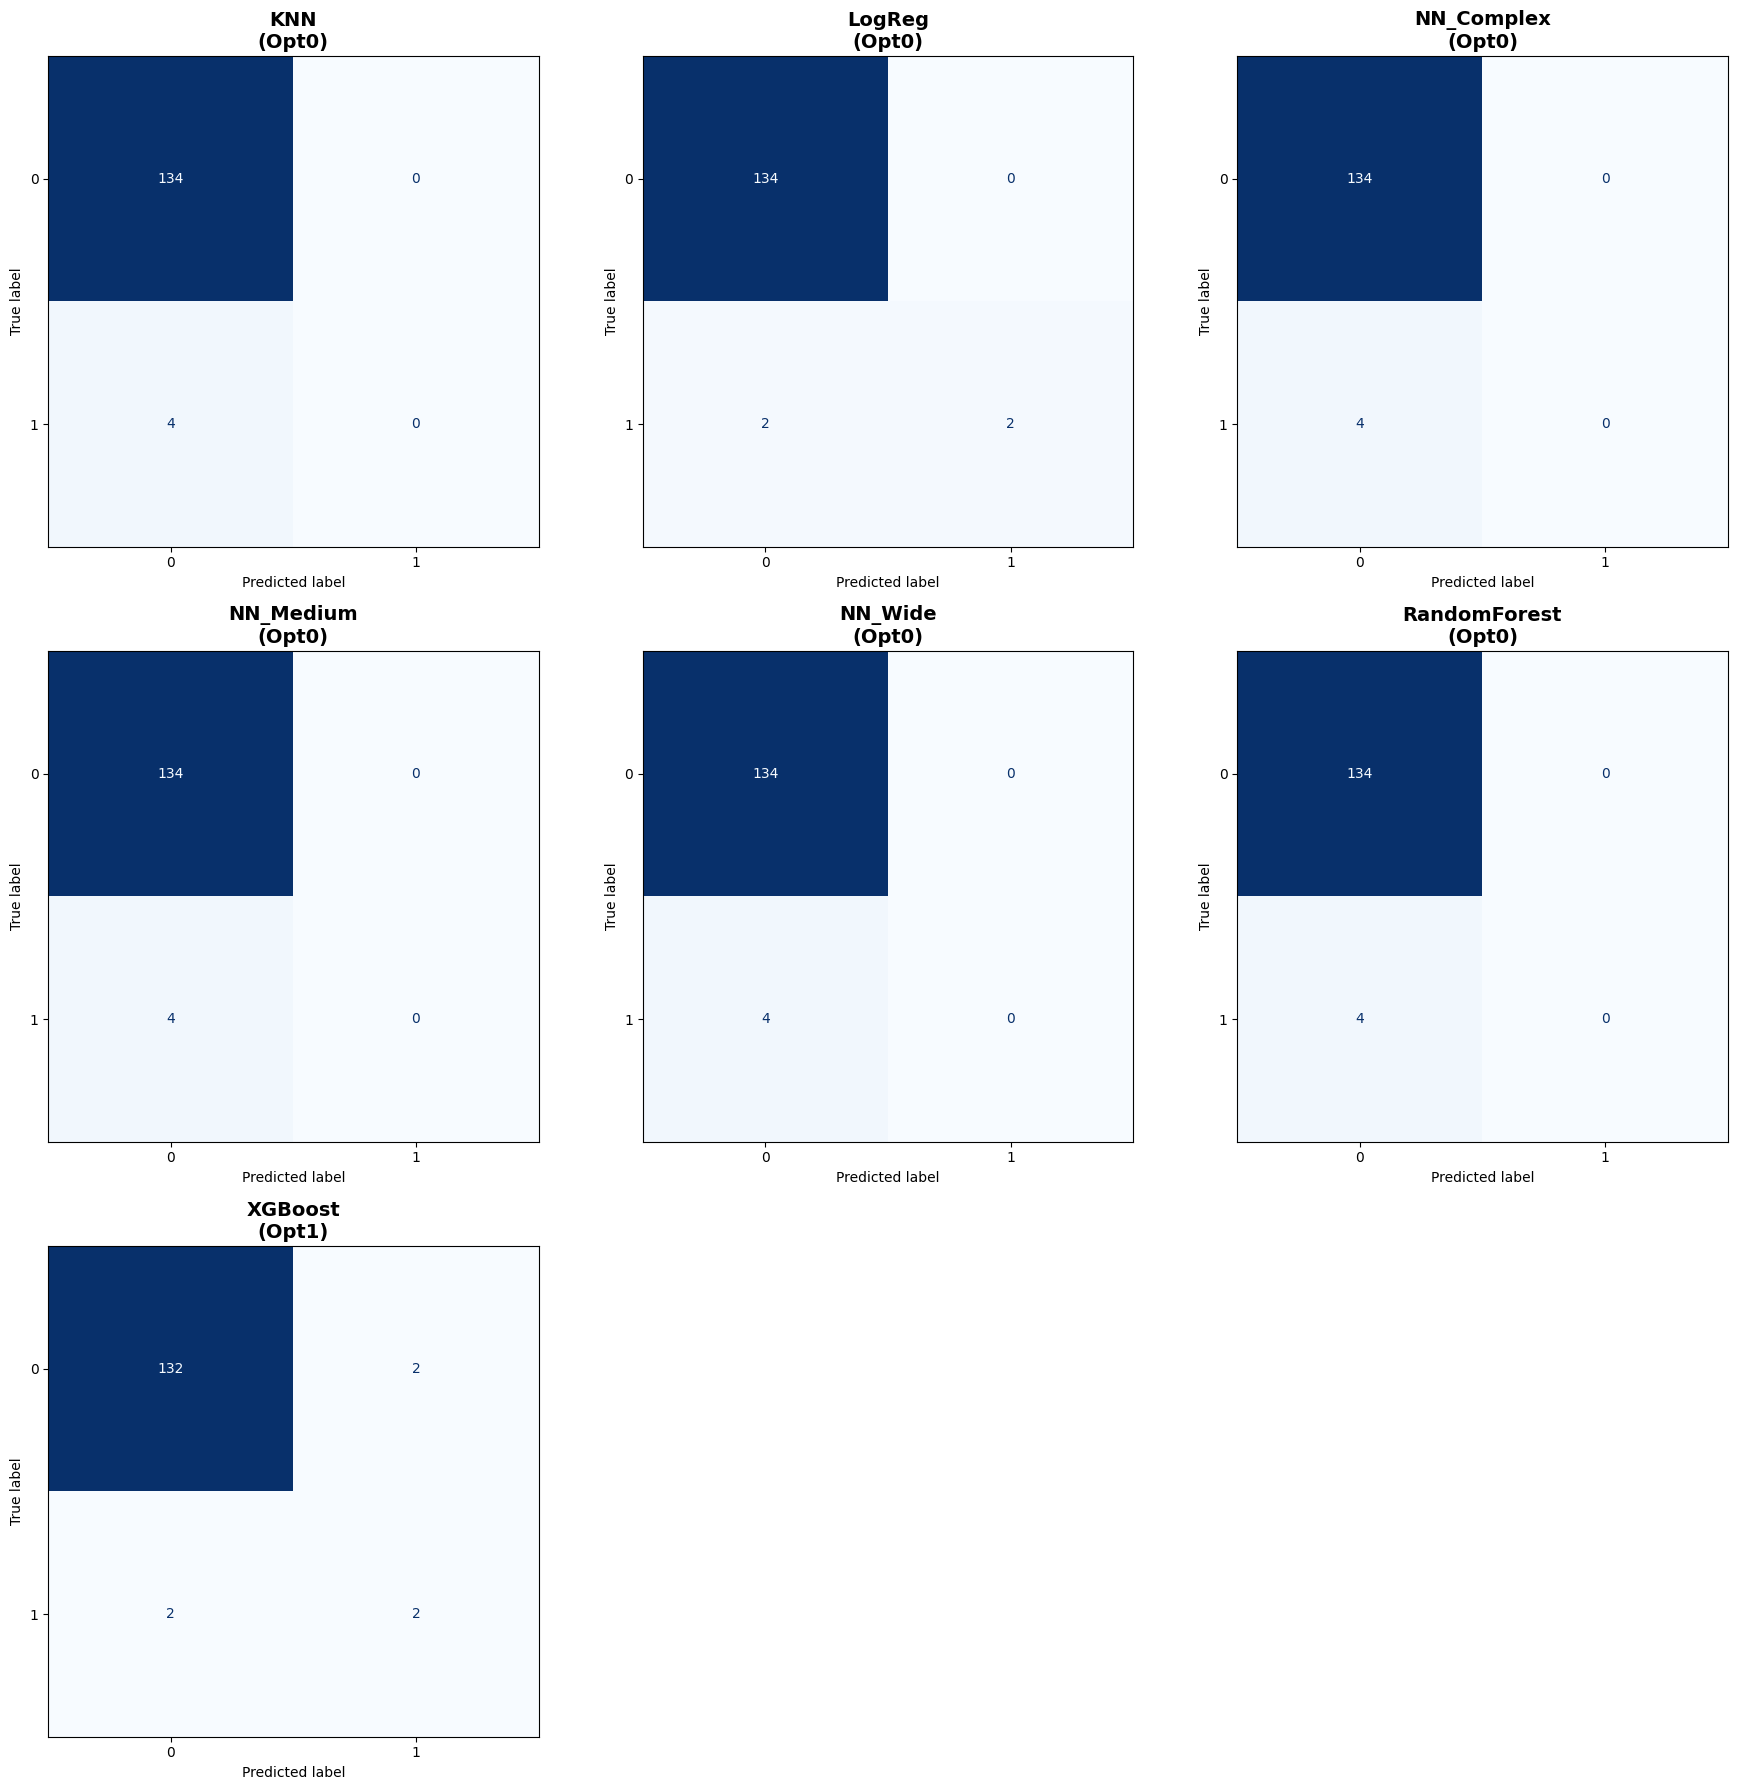


   >> Training Binary Models for: 'coupling-2D' (Optimizing Precision)
      ⚠️ Skipping coupling-2D: Too few positive samples (5)

   >> Training Binary Models for: 'unbalance-motor' (Optimizing Precision)
      Imbalance Ratio: 1:22.0

🚀 START EXPERIMENT: DETECTION_UNBALANCE-MOTOR
📊 Target Column: 'is_unbalance-motor'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.8000
   ✅ RandomForest: precision=0.4000
   ✅ LogReg: precision=0.4407
   ✅ KNN: precision=0.5500
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9638 (Stopped at epoch 22)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9710 (Stopped at epoch 13)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9638 (Stopped at epoch 7)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.4657
   ✅ RandomForest: precision=0.5833
   ✅ LogReg: precision=0.3313
   ✅ KNN: precision=0.5524
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.963

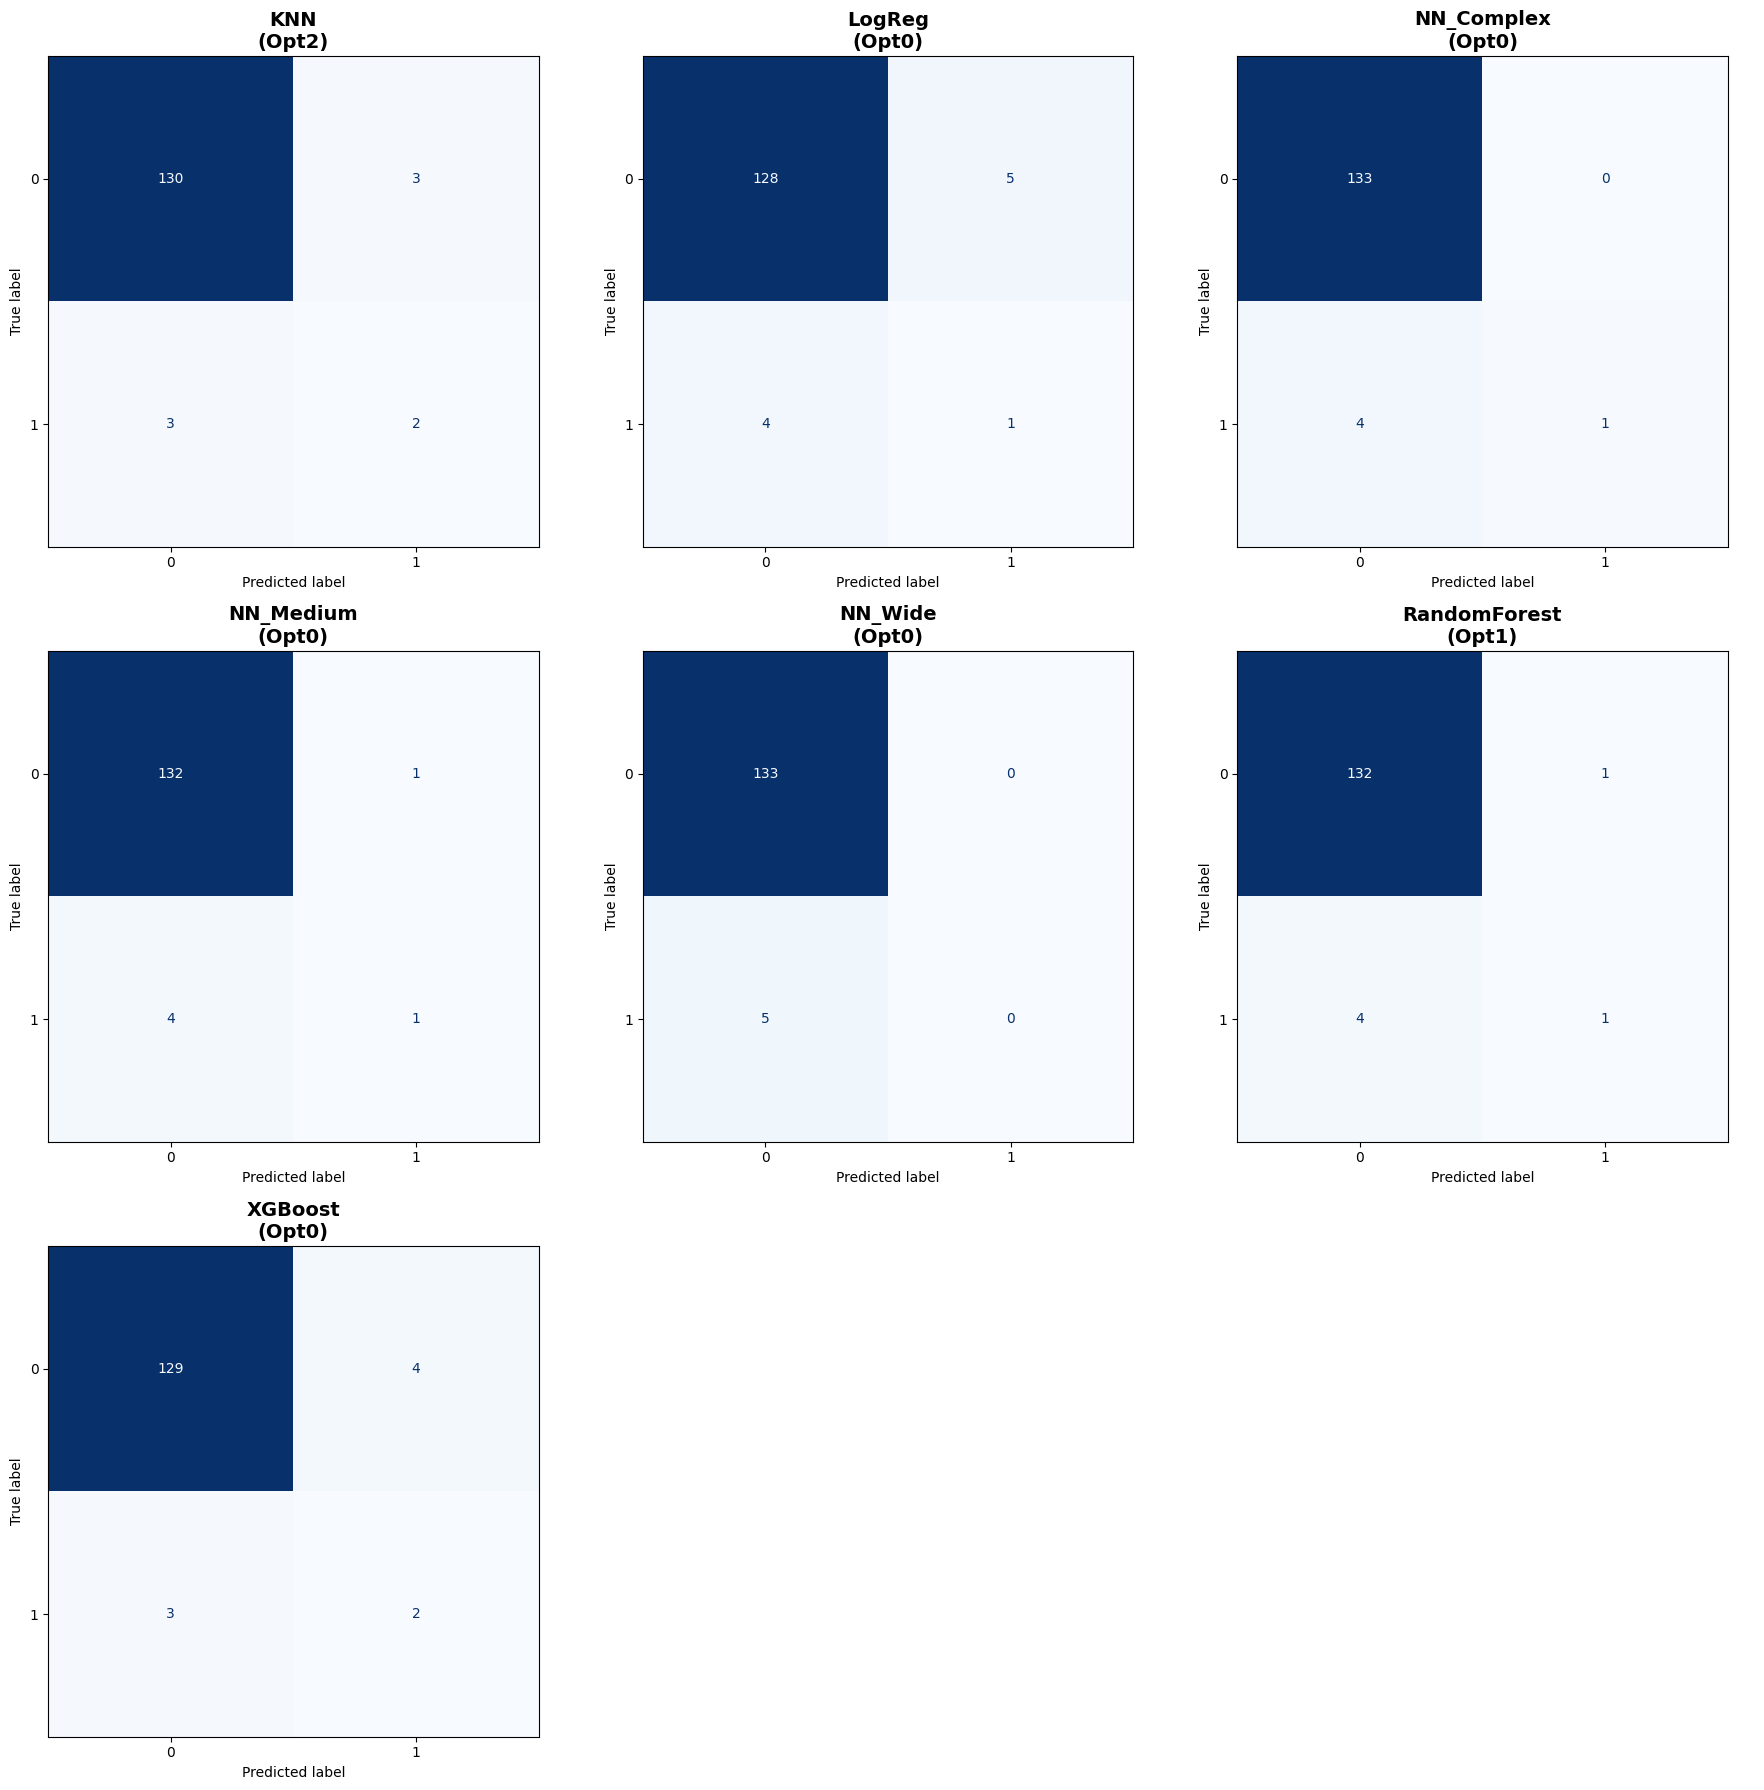


   >> Training Binary Models for: 'unbalance-pump' (Optimizing Precision)
      Imbalance Ratio: 1:45.0

🚀 START EXPERIMENT: DETECTION_UNBALANCE-PUMP
📊 Target Column: 'is_unbalance-pump'

--- ⚙️ Processing Opt0_S1_D1 ---
   ✅ XGBoost: precision=0.2000
   ✅ RandomForest: precision=0.0000
   ✅ LogReg: precision=0.2156
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9783 (Stopped at epoch 13)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9783 (Stopped at epoch 6)
   🧠 Training Neural Network: NN_Wide...
   ✅ NN_Wide: accuracy=0.9783 (Stopped at epoch 11)

--- ⚙️ Processing Opt1_S1_D1 ---
   ✅ XGBoost: precision=0.2367
   ✅ RandomForest: precision=0.1000
   ✅ LogReg: precision=0.0852
   ✅ KNN: precision=0.0000
   🧠 Training Neural Network: NN_Medium...
   ✅ NN_Medium: accuracy=0.9783 (Stopped at epoch 10)
   🧠 Training Neural Network: NN_Complex...
   ✅ NN_Complex: accuracy=0.9783 (Stopped at epoch 7)
   🧠 Training

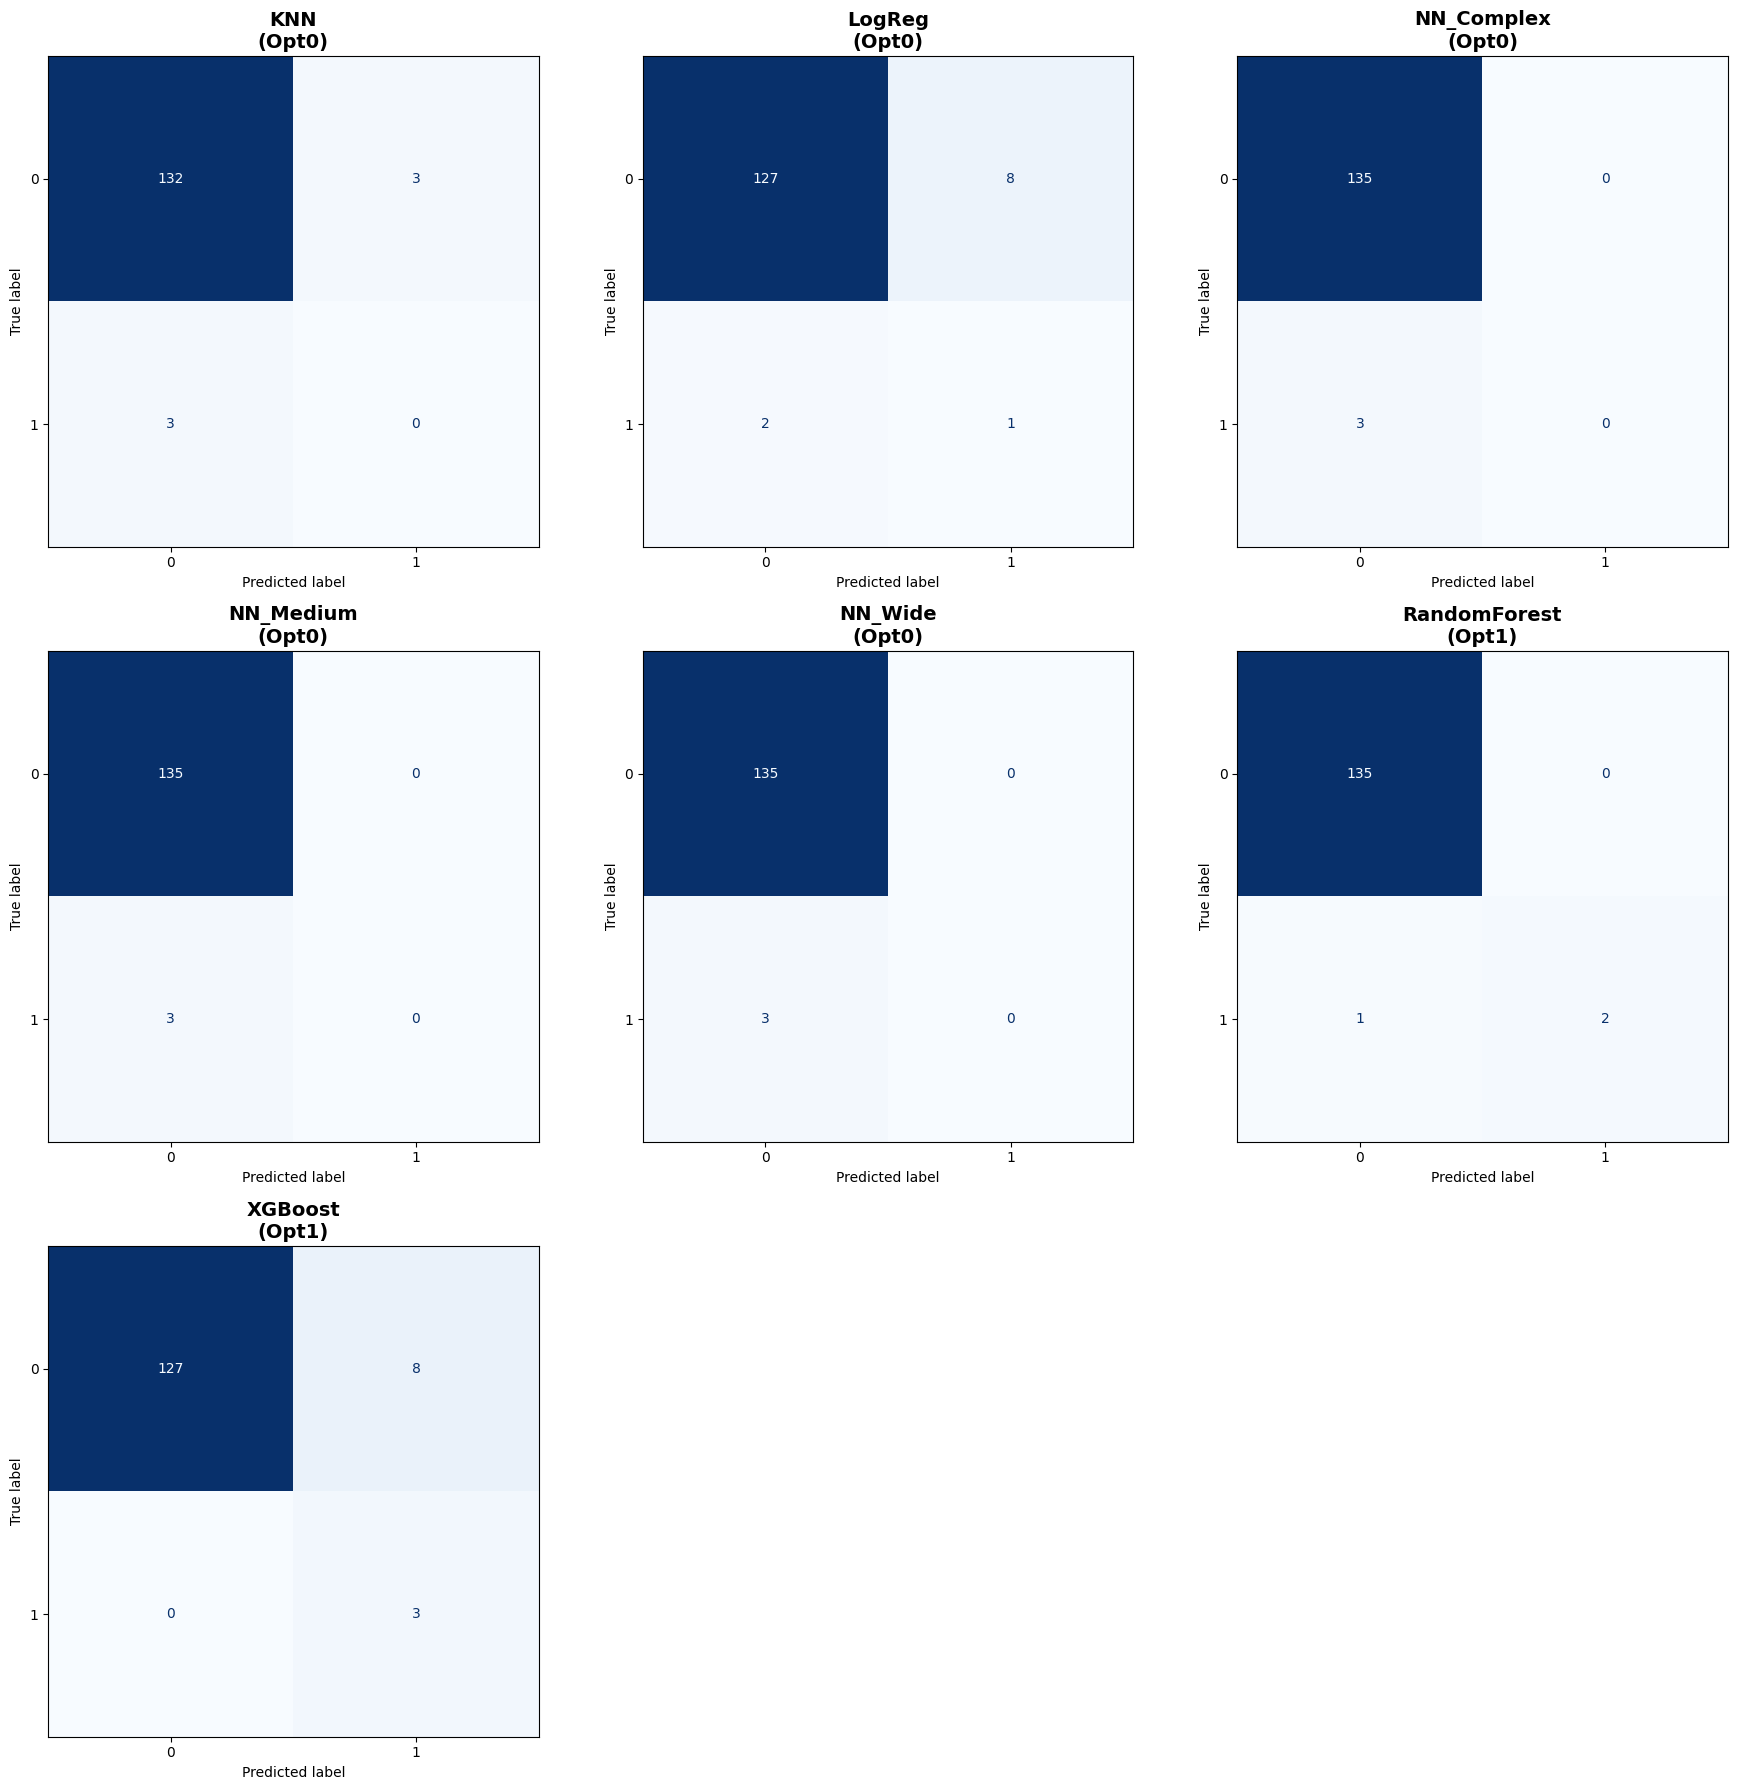


📊 FINAL SUMMARY: ALL EXPERIMENTS FOR VIBRATION_SIGNALS

--- Top Model per Task (Sorted by F1 Score) ---
                              Task   Model                   Config       f1  precision   recall  accuracy
           Detection_align-angular XGBoost  Opt1 (Scale:Yes PCA:No) 0.568272   0.458730 0.860000  0.956560
       Detection_align-combination XGBoost  Opt0 (Scale:Yes PCA:No) 0.366027   0.243881 0.783333  0.952891
          Detection_align-parallel  LogReg Opt2 (Scale:Yes PCA:Yes) 0.459264   0.411111 0.800000  0.943817
            Detection_bearing-bpfi     KNN  Opt0 (Scale:Yes PCA:No) 0.543773   0.744444 0.513889  0.936544
            Detection_bearing-bpfo     KNN Opt2 (Scale:Yes PCA:Yes) 0.464444   0.900000 0.370909  0.918509
             Detection_bearing-bsf     KNN  Opt0 (Scale:Yes PCA:No) 0.180000   0.300000 0.133333  0.976462
    Detection_bearing-contaminated  LogReg Opt2 (Scale:Yes PCA:Yes) 0.278788   0.200000 0.533333  0.940229
            Detection_bearing-pump     

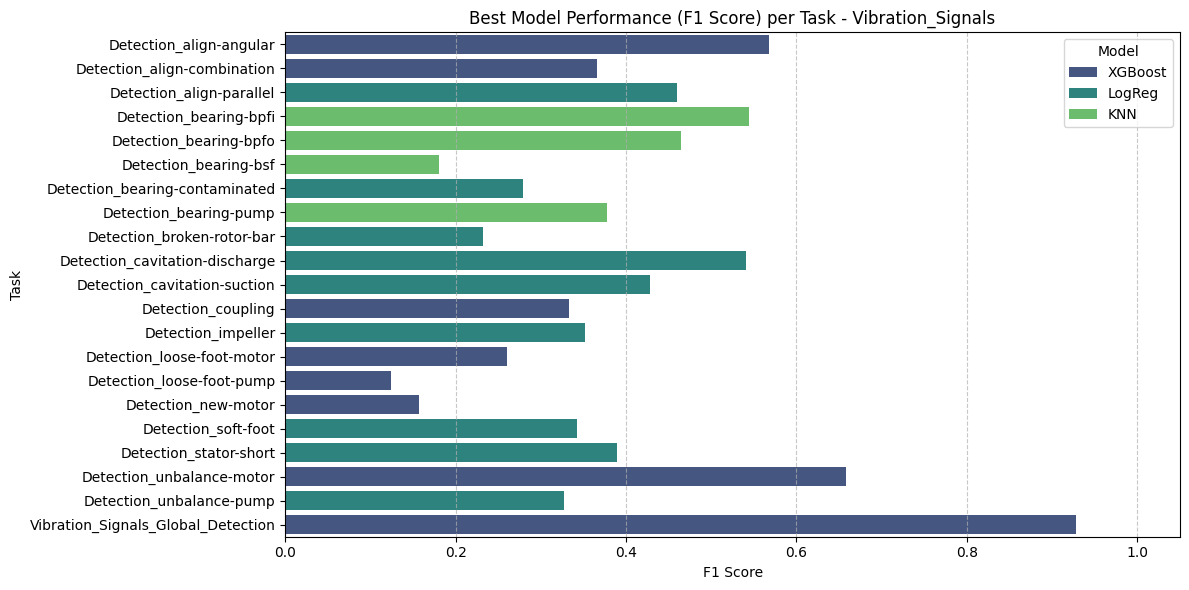

In [12]:
# 2. Run for Vibration Data
# (Assuming df_vibration_final is your processed dataframe)
run_full_diagnostic_pipeline(df_vib_feat, dataset_name="Vibration_Signals")

## gessing everything as a falt is a bad strategy IDK how to change
